# Notebook 02 (_r1): CEEMDAN + iTransformer and SHAP, causal decomposition without the boundary extension

The proposed model (per-city causal CEEMDAN channels appended to the 12 pollutant inputs of a city-conditioned
iTransformer), its baselines, KernelSHAP attribution and the Revision 1 sensitivity analyses, on the causal
decomposition **without** the boundary extension. The revised manuscript's main results come from notebook 02 _r1_ext
(with the extension). This notebook is the sensitivity analysis without it, and its Sections 18 and 19 are the
diagnostics that led to the final pipeline:

- **Section 18 (I-13):** KernelSHAP without the library's default limit of 10 non-zero values per window, one value
  per (day, channel) input and one value per channel. The per-channel method is used for all attribution in
  notebook 02 _r1_ext.
- **Section 19 (I-14):** the causal decomposition with an autoregressive boundary extension (each history extended
  by 30 forecast days before decomposing, then cut back), chosen on training dates before the run and adopted under a
  validation rule fixed in advance. Its decompositions (`models/c5_decompositions_ext_ar/`) are the main
  decomposition of notebook 02 _r1_ext.

**How this notebook was run.** Sections 1 to 18 ran top to bottom. Section 19 was added later and run at the
end of the same session: a first attempt stopped with an error because the session held an earlier version of the
decomposition helper. The first two code cells under the Section 19 heading therefore run the updated decomposition
helper (Section 4's helper cell) and the Section 18 cell again, and Section 19's own two cells follow. Those two cells
repeat definitions given earlier and are left as run.

**Evaluation protocol (Revision 1).** Every city's series is placed on a continuous daily calendar. Input
gaps of at most 3 days are filled from the last observed day, pollutant gaps from the city's own past readings only,
and targets are never filled. A window is kept only if its last input day has at least 180 available days of history.
All cities share one calendar split by target date: training before 1 Apr 2019, validation from 1 Apr to 30 Jun 2019,
test from 1 Jul 2019 to 1 Jul 2020. Every accuracy is also reported for the pre-lockdown period and for
lockdown/Unlock (targets from 25 Mar 2020). 18 cities have training windows under these rules.

**Results folder.** Every result is written to the Drive folder `MyDrive/phase4_v2_results_r1` (models, reports,
plots). `city_day.csv` is read from `MyDrive/city_day.csv`.

Run order of the repository: `01_phase1_baselines_r1`, `02_ceemdan_itransformer_shap_r1`, `02_ceemdan_itransformer_shap_r1_ext`, `03_shap_background_check_r1_ext`. The README explains the decision tags used in comments and printed output (for example R1.13 or I-15).

## Sections and reviewer comments

| Section | Produces | Reviewer comments |
|---|---|---|
| 1 to 3 Setup, data, preprocessing | daily calendar, own-past fill, minimum history, common-date split | R1.9, R1.10, R1.11, R3.3 |
| 4 Causal CEEMDAN | per-day decompositions, 5 channels (IMF1 to IMF4, slow), channel periods per city | R1.1, R1.2, R1.14 |
| 5 to 6 Model, training | proposed model at lookbacks 7, 14, 21, 30, lookback chosen on validation | R1.13 |
| 7 to 8 Baselines, comparison | plain iTransformer, CEEMDAN+LSTM, plain LSTM, comparison table | R2 (baseline comparison), R1.10 |
| 8b City conditioning | scalar bias against no term, scale and bias, city vector, rule fixed in advance | R1.16 |
| 9 KernelSHAP | attribution of Delhi, Mumbai, Bengaluru at the main lookback | R1.3, R3.1 |
| 11 Lookback robustness | attribution at the second lookback | R1.13 |
| 12 Ablation | 12 pollutants + lagged AQI instead of the decomposition, accuracy and attribution | R1.3, R3.1 |
| 13 Multi-seed, decomposition stability | 5 model seeds, mean +/- s.d., CEEMDAN seed stability | R1.3, R1.1 |
| 14 Eight-city attribution | attribution set chosen by a data-quality rule | R1.15 |
| 15 PM2.5 target | PM2.5 model, 5 seeds, attribution | R3.6, R1.3, R3.1 |
| 16 Window construction | three window constructions retrained over 5 seeds | R3.3 |
| 17 Decomposition seed | whole decomposition repeated with a second seed, model retrained, attribution | R1.1, R1.3 |

## 1 — Setup

Installs, imports, GPU detection, and reproducibility seeding.

**Config value provenance.** The proposed model uses `config_phase4_v2.py` throughout. The plain iTransformer and
CEEMDAN+LSTM baselines take their hyperparameters from `config_phase4.py`, the configuration of the earlier
generation of the code, which their training scripts import. All baselines run at lookbacks 7, 14, 21 and 30
(`LOOKBACK_PERIODS_BASELINE`).

In [ ]:
# Colab GPU runtime check reminder:
#   Runtime -> Change runtime type -> Hardware accelerator -> GPU (T4 is fine)
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-3d4ae7cf-4be8-5c5c-f257-9eed3abbb232)


In [ ]:
# Minimal installs — Colab already ships GPU-linked torch/numpy/pandas/sklearn/matplotlib/seaborn.
# Only these two are unlikely to be preinstalled:
#   EMD-signal  -> imported as `from PyEMD import CEEMDAN`  (verified in utils/ceemdan_utils.py
#                  and utils/augmented_features.py — both do `from PyEMD import CEEMDAN`)
#   shap        -> imported as `import shap`                (verified in utils/shap_utils.py)
!pip install -q "EMD-signal==1.9.0" "shap==0.51.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 6.0 MB/s eta 0:00:00


In [ ]:
import sys
import time
import json
import pickle
import random
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
logger = logging.getLogger('phase4_v2_notebook')

print(f"torch version   : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

torch version   : 2.11.0+cu130
CUDA available  : True


In [ ]:
# ── GPU detection (KNOWN FACT #1) ───────────────────────────────────────────
# CEEMDANFeatureTrainer / iTransformerTrainer / GroupLSTMTrainer all default to
# device='cpu' in the original .py files and none of the original train_*.py scripts
# ever override this. We detect the device once, here, and pass it explicitly into
# every trainer constructor throughout this notebook.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cpu':
    print("WARNING: No GPU detected. Go to Runtime -> Change runtime type -> GPU.")

Using device: cuda


### Reproducibility seeding

`RANDOM_SEED` (123) seeds numpy, Python's `random` and PyTorch (CPU and CUDA) before every training. The split is by
target date, so it carries no randomness. KernelSHAP is seeded per city (Section 9). The CEEMDAN seed of a city is
123 plus the city's index in the sorted list of all cities in the data.

In [ ]:
RANDOM_SEED = 123  # from config_phase4_v2.py

def set_all_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Deterministic cuDNN kernels — slightly slower, but removes one more source of
    # run-to-run variance on GPU. Not present in the original (CPU-only) code, added here
    # since this notebook is GPU-specific.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds(RANDOM_SEED)
print(f"All RNGs seeded with {RANDOM_SEED}")

All RNGs seeded with 123


In [ ]:
# ── Local (Colab-session) output directories ────────────────────────────────
# Mirrors phase4_advanced/results/{models,plots,reports} from the source repo, but rooted
# under /content so the notebook is self-contained. These are ephemeral in a plain Colab
# session — mount Google Drive first (Cell below, optional) if you want them to persist.
RESULTS_DIR = Path('/content/phase4_v2_results_r1')   # Revision 1, I-9: apart from the submitted run's files
MODELS_DIR  = RESULTS_DIR / 'models'
PLOTS_DIR   = RESULTS_DIR / 'plots'
REPORTS_DIR = RESULTS_DIR / 'reports'
for d in (MODELS_DIR, PLOTS_DIR, REPORTS_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f"Results will be written under: {RESULTS_DIR}")

Results will be written under: /content/phase4_v2_results_r1


In [ ]:
# OPTIONAL — uncomment to persist results/models across Colab sessions via Google Drive.
from google.colab import drive
drive.mount('/content/drive')
# Revision 1, I-9: a new folder, so the submitted run's files in phase4_v2_results stay untouched as its record
RESULTS_DIR = Path('/content/drive/MyDrive/phase4_v2_results_r1')
MODELS_DIR, PLOTS_DIR, REPORTS_DIR = RESULTS_DIR / 'models', RESULTS_DIR / 'plots', RESULTS_DIR / 'reports'
for d in (MODELS_DIR, PLOTS_DIR, REPORTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


## 2 — Data

`city_day.csv` (26 Indian cities, daily pollutant concentrations and AQI, 2015 to 2020, CPCB source, included in this
repository under `data/`). The cell below looks in `/content/` and in Drive (`MyDrive/city_day.csv`) and asks for an
upload only if the file is not found.

In [ ]:
CANDIDATE_PATHS = [
    Path('/content/city_day.csv'),
    Path('/content/drive/MyDrive/city_day.csv'),
    Path('/content/drive/MyDrive/phase4_v2_data/city_day.csv'),
]

DATA_FILE = next((p for p in CANDIDATE_PATHS if p.exists()), None)

if DATA_FILE is None:
    print("city_day.csv not found in common locations.")
    print("Please upload Implementation/Datasets/kaggle/2/city_day.csv now.")
    from google.colab import files
    uploaded = files.upload()
    # Take whichever file was uploaded (should be city_day.csv)
    uploaded_name = next(iter(uploaded.keys()))
    DATA_FILE = Path('/content') / uploaded_name

print(f"Using data file: {DATA_FILE}")
assert DATA_FILE.exists(), f"Data file not found at {DATA_FILE}"

city_day.csv not found in common locations.
Please upload Implementation/Datasets/kaggle/2/city_day.csv now.


Saving city_day.csv to city_day.csv
Using data file: /content/city_day.csv


## 3 — Preprocessing

`load_clean_data` reads the CSV and parses dates. Calendar, gap filling, minimum history, split and period labels are
applied by the helper cells that follow.

**Evaluation protocol (Revision 1).** Every city's series is placed on a continuous daily calendar. Input
gaps of at most 3 days are filled from the last observed day, pollutant gaps from the city's own past readings only,
and targets are never filled. A window is kept only if its last input day has at least 180 available days of history.
All cities share one calendar split by target date: training before 1 Apr 2019, validation from 1 Apr to 30 Jun 2019,
test from 1 Jul 2019 to 1 Jul 2020. Every accuracy is also reported for the pre-lockdown period and for
lockdown/Unlock (targets from 25 Mar 2020). 18 cities have training windows under these rules.

`FEATURE_COLUMNS` / `TARGET_COLUMN` are the 12 pollutants and AQI (`config_phase1.py`).

In [ ]:
# From phase1_baselines/config_phase1.py
FEATURE_COLUMNS = [
    "PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3",
    "Benzene", "Toluene", "Xylene"
]
TARGET_COLUMN = "AQI"

# From config_phase4_v2.py
N_POLLUTANTS   = 12
N_IMFS         = 5    # Revision 1, R1.2 a1: IMF1-IMF4 + one slow channel (C5_N_CHANNELS in the C5 helper)
N_FEATURES_V2  = N_POLLUTANTS + N_IMFS   # 17
# Split and modelled cities: Revision 1, R1.9/R1.10, common target dates for every city and one city
# rule (at least one training window), in the R1.9 helper cell. Replaces TRAIN_RATIO = 0.7,
# VAL_RATIO = 0.1 and MIN_CITY_SAMPLES = 300.
LOOKBACK_PERIODS_V2 = [7, 14, 21, 30]
# CEEMDAN settings: the C5 helper cell (Revision 1, R1.1). CEEMDAN_V2_PARAMS removed: its noise_std_factor
# was never applied by PyEMD (N4).
ITRANSFORMER_V2_PARAMS = {'d_model': 128, 'nhead': 8, 'ff_dim': 512, 'n_layers': 4, 'dropout': 0.1}
EPOCHS_V2        = 150
BATCH_SIZE_V2    = 32
PATIENCE_V2      = 15
LEARNING_RATE_V2 = 0.0005
WEIGHT_DECAY_V2  = 1e-06
WARMUP_EPOCHS_V2 = 10
H1_TARGET        = 0.92  # research-proposal hypothesis threshold, from train_ceemdan_itransformer_v2.py


def load_clean_data(data_file, target_col=TARGET_COLUMN):
    '''Transcribed from train_ceemdan_itransformer_v2.py::load_clean_data.
    Revision 1: pollutant filling moved to the window builders (N1/R1.11). R3.6 (T2): the target is a parameter,
    and the rows kept are the days with a target value (PM2.5 for the PM2.5 check, Section 15).'''
    logger.info(f"Loading data from {data_file}...")
    df = pd.read_csv(data_file)
    df = df.dropna(subset=[target_col])
    # Revision 1, N1/R1.11 (P3): pollutant gaps are no longer filled here. The submitted
    # ffill().bfill() back-filled from later dates and, being ungrouped, from other cities, and the
    # mean fill used the whole dataset. Each window builder now fills them on the daily calendar
    # (n1_pollutant_calendar, n1_fill_constant).

    logger.info(f"Cleaned data: {df.shape}, Cities: {df['City'].nunique()}")
    return df

In [ ]:
# Revision 1, reviewer comment R3.3, decision D1 option (b): calendar-based windows.
#
# Each city's series is placed on a continuous daily calendar running from its first to its last
# observed day. A run of at most D1_MAX_FILL_DAYS consecutive missing days is filled by copying the
# last observed day (past values only). Longer runs stay missing. A forecast window is used only if
# every one of its input days is observed or filled AND its target day is observed. Targets are
# never filled, so every evaluated target is a real observation, and a window of length L always
# spans exactly L calendar days followed by the next calendar day as its target.
D1_MAX_FILL_DAYS = 3


def d1_calendar_city(df_c, value_cols, max_fill_days=D1_MAX_FILL_DAYS):
    '''
    Place one city's rows on a daily calendar and forward-fill short gaps.

    df_c        : rows of a single city, one row per observed day, with a 'Date' column.
    value_cols  : columns to carry onto the calendar.
    Returns (frame, observed, available):
      frame     : DataFrame with 'Date' plus value_cols, one row per calendar day. Days in a gap of
                  at most max_fill_days hold an exact copy of the last observed day. Days in longer
                  gaps hold NaN.
      observed  : bool ndarray, True where df_c has a row for that day.
      available : bool ndarray, True where the day is observed or filled.
    '''
    dates = pd.to_datetime(df_c['Date'])
    if dates.duplicated().any():
        raise ValueError('d1_calendar_city: duplicate dates within one city')
    vals = df_c[list(value_cols)].set_index(dates).sort_index()
    calendar = pd.date_range(vals.index[0], vals.index[-1], freq='D')
    frame = vals.reindex(calendar)
    observed = np.asarray(calendar.isin(vals.index), dtype=bool)
    missing = ~observed

    # Length of the missing run each day belongs to. run_id increases at every observed day, so all
    # days of one missing run share the run_id of the observed day that precedes them.
    run_id = np.cumsum(observed)
    run_len = pd.Series(missing.astype(np.int64)).groupby(run_id).transform('sum').to_numpy()
    fill = missing & (run_len <= max_fill_days)

    # Copy the last observed day. The calendar starts on an observed day, so one always exists.
    last_obs = np.maximum.accumulate(np.where(observed, np.arange(len(observed)), -1))
    if fill.any():
        frame.iloc[np.flatnonzero(fill)] = frame.iloc[last_obs[fill]].to_numpy()

    available = observed | fill
    frame = frame.rename_axis('Date').reset_index()
    return frame, observed, available


def d1_window_starts(observed, available, seq_len):
    '''
    Start indices of usable windows on the calendar.

    Window i uses input days i .. i+seq_len-1 and target day i+seq_len. It is usable when every
    input day is available (observed or filled) and the target day is observed.
    '''
    observed = np.asarray(observed, dtype=bool)
    available = np.asarray(available, dtype=bool)
    n = len(observed)
    if n <= seq_len:
        return np.array([], dtype=np.int64)
    csum = np.concatenate([[0], np.cumsum(available.astype(np.int64))])
    starts = np.arange(n - seq_len, dtype=np.int64)
    inputs_ok = (csum[starts + seq_len] - csum[starts]) == seq_len
    target_ok = observed[starts + seq_len]
    return starts[inputs_ok & target_ok]


def d1_train_row_mask(n_rows, train_starts, seq_len, available):
    '''
    Calendar rows used to fit scalers: available days up to and including the target day of the
    last training window. No validation or test day is included.
    '''
    mask = np.zeros(n_rows, dtype=bool)
    if len(train_starts) == 0:
        return mask
    mask[: int(train_starts[-1]) + seq_len + 1] = True
    return mask & np.asarray(available, dtype=bool)


In [ ]:
# ── Revision 1, N1 / R1.11 (decision P3, gaps after the forward fill by option (c)): pollutant gaps filled from the city's own past ──
# Replaces groupby('City').ffill().bfill() + full-dataset mean fill in the loaders. Each window builder,
# on the daily calendar from d1_calendar_city:
#   1. n1_pollutant_calendar: a pollutant value is the last real reading within N1_MAX_FILL_DAYS
#      calendar days. A gap still open after the city's first reading of that pollutant gets the median
#      of the city's own readings in the previous N1_HISTORY_DAYS available days (the history of the
#      causal decomposition, R1.1 C5), or of all its earlier readings if there are none in that span.
#      No backward fill, nothing from another city, nothing from a later date.
#   2. n1_fill_constant: days before the city's first reading of a pollutant (or every day, if never
#      measured) get one constant per pollutant, the same for every city and date: the median of all
#      cities' real readings on training rows (the D1 scaler rows, d1_train_row_mask). Each builder
#      keeps the readings from n1_readings for this, since filled values cannot be told apart later.
N1_MAX_FILL_DAYS = 3     # same limit as D1_MAX_FILL_DAYS
N1_HISTORY_DAYS = 365    # same history cap as the causal decomposition (R1.1, C5)


def n1_readings(values, observed):
    '''Real pollutant readings on the daily calendar: values on observed days, NaN elsewhere.

    values: (n_days, n_pollutants) from d1_calendar_city, whose rows on non-observed days are D1 copies.
    '''
    return np.where(np.asarray(observed, dtype=bool)[:, None], values, np.nan)


def n1_pollutant_calendar(values, observed, available, max_fill_days=N1_MAX_FILL_DAYS,
                          history_days=N1_HISTORY_DAYS):
    '''Pollutant array on the daily calendar, filled from the city's own past readings only.

    values: (n_days, n_pollutants) from d1_calendar_city. Only rows of observed days are real readings,
    so the rows D1 copied into short AQI gaps are discarded and rebuilt by the same rule. Unavailable
    days stay NaN. Available days before the city's first reading of a pollutant stay NaN, for
    n1_fill_constant.
    '''
    available = np.asarray(available, dtype=bool)
    real = n1_readings(values, observed)
    out = pd.DataFrame(real).ffill(limit=max_fill_days).to_numpy(dtype=np.float64, copy=True)
    out[~available] = np.nan

    # Longer gaps after the first reading: median of the readings in the history_days available days
    # before day t. Unavailable days are skipped, as gaps are joined in the decomposition history (G1).
    avail_days = np.flatnonzero(available)
    avail_rank = np.cumsum(available) - 1
    days = np.arange(len(out))
    for j in range(out.shape[1]):
        read = np.isfinite(real[:, j])
        if not read.any():
            continue
        first = int(np.argmax(read))
        for t in np.flatnonzero(available & np.isnan(out[:, j]) & (days > first)):
            start = avail_days[max(int(avail_rank[t]) - history_days, 0)]
            past = real[start:t, j]
            past = past[np.isfinite(past)]
            if past.size == 0:                       # no reading in that span: all earlier readings
                past = real[:t, j][read[:t]]
            out[t, j] = np.median(past)
    return out


def n1_fill_constant(city_raw, key, city_splits, seq_len):
    '''Fill the days before each city's first reading of a pollutant with one pooled constant per pollutant.

    city_raw[c][key]: (n_days, n_pollutants) from n1_pollutant_calendar, filled in place. city_raw[c]
    also holds 'n', 'available', 'starts' and 'n1_readings' (from n1_readings). city_splits[c][0] is the
    number of training windows. The constant is the median of all cities' real readings on training rows.
    Returns the constant per pollutant.
    '''
    readings = []
    for c in city_raw:
        d = city_raw[c]
        rows = d1_train_row_mask(d['n'], d['starts'][:city_splits[c][0]], seq_len, d['available'])
        readings.append(d['n1_readings'][rows])
    readings = np.vstack(readings)
    if not np.isfinite(readings).any(axis=0).all():
        raise ValueError("N1: a pollutant has no training reading in any city")
    constant = np.nanmedian(readings, axis=0)
    for c in city_raw:
        x = city_raw[c][key]
        gap = np.isnan(x) & np.asarray(city_raw[c]['available'], dtype=bool)[:, None]
        x[gap] = np.broadcast_to(constant, x.shape)[gap]
    return constant

In [ ]:
# ── Revision 1, R1.9/R1.10 (decision P4 on common dates) with the R1.1 minimum history (C5): windows, split, cities ──
# Replaces the per-city 70/10/20 split and the per-builder city thresholds (300 + L rows, L + 10 rows, none).
# Every builder takes a city's windows from r19_city_windows:
#   1. D1 windows (d1_window_starts).
#   2. R1.1 minimum history: a window is kept only if its last input day has at least R11_MIN_HISTORY_DAYS
#      available days up to and including it, counted from the start of the record (gaps joined, G1).
#   3. Split by the target date, the same dates for every city: training targets before R19_VAL_START,
#      validation targets before R19_TEST_START, test targets up to R19_DATA_END.
# A city is modelled only if it has at least one training window. r19_check_cities then makes every builder
# call of a run model the same cities, in the same order, per target (R3.6: the PM2.5 check has its own cities).
R19_VAL_START = np.datetime64('2019-04-01')    # first validation target date
R19_TEST_START = np.datetime64('2019-07-01')   # first test target date
R19_DATA_END = np.datetime64('2020-07-01')     # last day of the data set, last test target date
R11_MIN_HISTORY_DAYS = 180                     # R1.1 decision C5


def r19_city_windows(dates, observed, available, seq_len, min_history=R11_MIN_HISTORY_DAYS):
    '''Usable windows of one city and its split by target date.

    dates, observed, available: the daily calendar from d1_calendar_city.
    Returns (starts, (n_train, n_train + n_val, n_windows)). starts are in date order, so the first n_train
    windows are training windows, the next n_val validation windows and the rest test windows.
    '''
    available = np.asarray(available, dtype=bool)
    starts = d1_window_starts(observed, available, seq_len)
    history = np.cumsum(available)                      # available days up to and including each day
    starts = starts[history[starts + seq_len - 1] >= min_history]
    target = pd.to_datetime(pd.Series(dates)).to_numpy(dtype='datetime64[D]')[starts + seq_len]
    if len(target) and (np.any(np.diff(target) <= np.timedelta64(0, 'D')) or target[-1] > R19_DATA_END):
        raise ValueError('R1.9: window targets must be increasing and end by R19_DATA_END')
    n_train = int(np.searchsorted(target, R19_VAL_START, side='left'))
    n_train_val = int(np.searchsorted(target, R19_TEST_START, side='left'))
    return starts, (n_train, n_train_val, len(starts))


_r19_cities_in_run = {}


def r19_check_cities(valid_cities, builder, target='AQI'):
    '''Every builder call of a run for the same target must model the same cities in the same order (decision
    R1.9/R1.10).

    The first call per target records the list. A later call with a different list raises. Re-running this cell
    resets it. Revision 1, R3.6 (T2): the PM2.5 check models the cities with a PM2.5 training window, so the lists
    are kept per target. Every builder except the main model's is AQI-only and uses the default.
    '''
    cities = tuple(valid_cities)
    if not cities:
        raise ValueError(f'R1.9: {builder} has no city with a training window ({target})')
    first = _r19_cities_in_run.setdefault(target, (cities, builder))
    if cities != first[0]:
        raise ValueError(f'R1.9: {builder} models {list(cities)} for {target}, but {first[1]} modelled {list(first[0])}')

In [ ]:
# ── Revision 1, R1.9/R1.10 (decision P4) and R3.3 D3 S1: accuracy per lockdown period, and the filled-day flag ──
# Every headline accuracy is also reported for the two periods of the common test year, a window assigned by its
# target date (decided 3 Oct 2026, step 6d):
#   pre-lockdown       targets 1 Jul 2019 to 24 Mar 2020
#   lockdown/Unlock    targets 25 Mar 2020 (first day of the national lockdown) to 1 Jul 2020 (Unlock 1.0)
# Each result row keeps its full-year metrics and gains n, r2, rmse, mae and mape per period, suffixed _pre and _lock,
# computed with the notebook's own Evaluator. S1 (R3.3 D3): a test window is "filled" if at least one input day was
# filled by D1 (available but not observed). N1 pollutant gaps are not counted.
R110_LOCKDOWN_START = np.datetime64('2020-03-25')   # first lockdown/Unlock target date
R110_COLUMNS = [f'{k}_{p}' for p in ('pre', 'lock') for k in ('n', 'r2', 'rmse', 'mae', 'mape')]


def r110_test_dates(dates, starts, split, seq_len):
    '''Target dates of one city's test windows (from r19_city_windows), in window order.'''
    dates = pd.to_datetime(pd.Series(dates)).to_numpy(dtype='datetime64[D]')
    return dates[np.asarray(starts, dtype=np.int64)[split[1]:] + seq_len]


def r110_filled_windows(observed, starts, seq_len):
    '''Per window: True if at least one input day was filled by D1 (S1).'''
    n_filled = np.concatenate([[0], np.cumsum(~np.asarray(observed, dtype=bool))])
    starts = np.asarray(starts, dtype=np.int64)
    return (n_filled[starts + seq_len] - n_filled[starts]) > 0


def r110_metrics(y_true, y_pred):
    '''n, r2, rmse, mae and mape by the Evaluator's definitions. NaN when fewer than 2 windows.'''
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
    if len(y_true) < 2:
        return {'n': len(y_true), 'r2': np.nan, 'rmse': np.nan, 'mae': np.nan, 'mape': np.nan}
    return {'n': len(y_true), 'r2': float(Evaluator.r2(y_true, y_pred)), 'rmse': float(Evaluator.rmse(y_true, y_pred)),
            'mae': float(Evaluator.mae(y_true, y_pred)), 'mape': float(Evaluator.mape(y_true, y_pred))}


def r110_period_columns(y_true, y_pred, target_dates):
    '''The pre-lockdown and lockdown/Unlock metrics of a test set, as columns n_pre, r2_pre, ..., mape_lock.'''
    dates = np.asarray(target_dates, dtype='datetime64[D]')
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
    if not len(dates) == len(y_true) == len(y_pred):
        raise ValueError(f'R1.10: {len(dates)} target dates for {len(y_true)} targets and {len(y_pred)} predictions')
    if len(dates) and (dates.min() < R19_TEST_START or dates.max() > R19_DATA_END):
        raise ValueError('R1.10: the period breakdown is for test windows only')
    lock = dates >= R110_LOCKDOWN_START
    out = {}
    for period, m in (('pre', ~lock), ('lock', lock)):
        out.update({f'{k}_{period}': v for k, v in r110_metrics(y_true[m], y_pred[m]).items()})
    return out


In [ ]:
# ── Revision 1, R3.3 D3 S2 (step 6e): window construction of the S2 sensitivity arms ──
# Decided 30 Sep (D3) and 3 Oct 2026 (S2 details). The arms vary only how windows are cut:
#   'd1b'    D1(b), the main pipeline: daily calendar, gaps of at most D1_MAX_FILL_DAYS days filled from the last
#            observed day
#   'd1a'    D1(a), exclude: daily calendar with nothing filled, so every input day and target is an observed day
#   'steps'  observation steps, the submitted procedure: L consecutive observed rows, whatever calendar gaps lie
#            between them, and the next observed row as target. Per-day values as in 'd1a' (N1 on the daily
#            calendar, then the observed rows are kept)
# 'd1a' and 'steps' share the causal decomposition of the observed days only (I-6), made by c5_decompose_all with
# max_fill_days=0.
S2_ARMS = ('d1b', 'd1a', 'steps')


def s2_calendar(df_c, value_cols, gap_arm):
    '''Daily calendar of one city for an S2 arm: (cal, observed, available, rows). rows marks the calendar days the
    arm cuts its windows over: every day, or the observed days for 'steps'.'''
    if gap_arm not in S2_ARMS:
        raise ValueError(f'S2: unknown arm {gap_arm!r}, expected one of {S2_ARMS}')
    cal, observed, available = d1_calendar_city(df_c, value_cols,
                                                max_fill_days=D1_MAX_FILL_DAYS if gap_arm == 'd1b' else 0)
    rows = observed.copy() if gap_arm == 'steps' else np.ones(len(cal), dtype=bool)
    return cal, observed, available, rows


def s2_decomposition(dec, rows):
    '''A saved decomposition indexed by the kept rows instead of calendar days (unchanged when every day is kept).'''
    rows = np.asarray(rows, dtype=bool)
    if rows.all():
        return dec
    if not rows[dec['days']].all():
        raise ValueError('S2: a decomposed day is not among the kept rows (the steps arm needs the observed-days '
                         'decomposition)')
    return dict(dec, days=(np.cumsum(rows) - 1)[dec['days']].astype(np.int64))


In [ ]:
# ── Revision 1, R1.1 (decision C5) and R1.2 (decision a1): causal CEEMDAN with sifting-order channels ──
# Replaces the full-record, energy-ranked decomposition (extract_city_imf_features).
# For every available day t of a city with at least C5_MIN_HISTORY available days so far, CEEMDAN runs on the
# last min(C5_W_MAX, available days so far) available AQI values up to and including t, joined across longer
# gaps (D2 = G1). Nothing after t enters. A window whose last input day is t takes all its channel values from
# the decomposition at t (its last L values).
# Each decomposition uses a fresh CEEMDAN instance seeded with the city's seed, so a result does not depend on
# which other days were decomposed, in which order, or on how many processes ran.
# Channels (a1): IMF1 to IMF4 in sifting order, plus one slow channel = IMF5 onwards + the residue.
# Saved per city and day: the last C5_KEEP values of every component (a1 channels and CEEMDAN+LSTM groups are
# derived from them), the number of components, the history length and each channel's zero-crossing period
# over the history (I-5). The noise amplitude is passed as `epsilon`, the argument PyEMD reads. The submitted
# code passed `noise_std`, which PyEMD ignores, so the submitted runs used PyEMD's default of 0.005.
import hashlib
import os

C5_W_MAX = 365                      # history cap, available days
C5_MIN_HISTORY = R11_MIN_HISTORY_DAYS   # 180, from the R1.9 helper cell
C5_TRIALS = 100
C5_EPSILON = 0.2                    # noise amplitude, as stated in Methods
C5_MAX_IMF = 8                      # PyEMD max_imf: at most max_imf + 1 IMFs plus the residue
C5_SEED_BASE = 123                  # city seed = C5_SEED_BASE + index of the city among all cities in the data
C5_KEEP = 30                        # values kept per decomposition: the longest lookback
C5_N_CHANNELS = 5
C5_MAX_COMPONENTS = C5_MAX_IMF + 2
C5_CHANNEL_NAMES = ['IMF1', 'IMF2', 'IMF3', 'IMF4', 'IMF5+ (slow)']


def c5_params(trials=C5_TRIALS, epsilon=C5_EPSILON, max_imf=C5_MAX_IMF, w_max=C5_W_MAX,
              min_history=C5_MIN_HISTORY, keep=C5_KEEP):
    '''Every setting that determines a saved decomposition. A saved file must match these exactly.'''
    import PyEMD
    return {'trials': int(trials), 'epsilon': float(epsilon), 'max_imf': int(max_imf), 'w_max': int(w_max),
            'min_history': int(min_history), 'keep': int(keep), 'pyemd': str(PyEMD.__version__)}


def c5_decompose(history, seed, trials=C5_TRIALS, epsilon=C5_EPSILON, max_imf=C5_MAX_IMF):
    '''CEEMDAN components of one history, in sifting order (last row = residue). No fallback: errors raise.

    Fewer than C5_N_CHANNELS components is allowed here and recorded, so a long run is never lost. Such a day
    cannot give a1 channels: c5_channels raises when a window needs it (decision for the authors).
    '''
    from PyEMD import CEEMDAN
    x = np.asarray(history, dtype=np.float64)
    comps = CEEMDAN(trials=trials, epsilon=epsilon, max_imf=max_imf, seed=seed, parallel=False)(x)
    if not np.allclose(comps.sum(axis=0), x, rtol=0, atol=1e-6 * max(1.0, float(np.abs(x).max()))):
        raise ValueError('C5: CEEMDAN components do not reconstruct the history')
    if len(comps) > C5_MAX_COMPONENTS:
        raise ValueError(f'C5: {len(comps)} components, more than the {C5_MAX_COMPONENTS} that max_imf allows')
    return comps


def c5_channels(comps):
    '''a1 channels (5, n) from components (K, n): IMF1..IMF4, and the sum of IMF5 onwards and the residue.'''
    comps = np.asarray(comps, dtype=np.float64)
    if len(comps) < C5_N_CHANNELS:
        raise ValueError(f'C5: {len(comps)} components, a1 needs at least {C5_N_CHANNELS}')
    return np.vstack([comps[:C5_N_CHANNELS - 1], comps[C5_N_CHANNELS - 1:].sum(axis=0, keepdims=True)])


def c5_period(x):
    '''Zero-crossing period in days (as period_zero_crossing in the submitted notebook). NaN below 2 crossings.'''
    x = np.asarray(x, dtype=np.float64) - np.mean(x)
    s = np.sign(x)
    s[s == 0] = 1
    n = int(np.sum(s[:-1] != s[1:]))
    return 2.0 * (len(x) - 1) / n if n >= 2 else np.nan


def c5_days(available, min_history=C5_MIN_HISTORY):
    '''Calendar days decomposed: available days with at least min_history available days up to and including them.'''
    available = np.asarray(available, dtype=bool)
    return np.flatnonzero(available & (np.cumsum(available) >= min_history))


def c5_history(aqi, available, t, w_max=C5_W_MAX):
    '''The last min(w_max, available days so far) available AQI values up to and including day t (gaps joined).'''
    idx = np.flatnonzero(np.asarray(available, dtype=bool)[:t + 1])[-w_max:]
    return np.asarray(aqi, dtype=np.float64)[idx]


def _c5_job(args):
    '''One decomposition. Top-level so that worker processes can run it.'''
    history, seed, trials, epsilon, max_imf, keep = args
    comps = c5_decompose(history, seed, trials, epsilon, max_imf)
    tail = np.full((C5_MAX_COMPONENTS, keep), np.nan)
    tail[:len(comps)] = comps[:, -keep:]
    periods = (np.array([c5_period(ch) for ch in c5_channels(comps)]) if len(comps) >= C5_N_CHANNELS
               else np.full(C5_N_CHANNELS, np.nan))
    return tail, len(comps), periods


def c5_decompose_city(aqi, available, seed, n_jobs=1, trials=C5_TRIALS, epsilon=C5_EPSILON,
                      max_imf=C5_MAX_IMF, w_max=C5_W_MAX, min_history=C5_MIN_HISTORY, keep=C5_KEEP):
    '''Causal decompositions of one city on its D1 calendar (aqi, available from d1_calendar_city).

    Returns {'days', 'tail' (n, C5_MAX_COMPONENTS, keep), 'n_components', 'periods' (n, 5), 'history_len'}.
    '''
    days = c5_days(available, min_history)
    jobs = [(c5_history(aqi, available, t, w_max), seed, trials, epsilon, max_imf, keep) for t in days]
    if n_jobs > 1:
        from multiprocessing import Pool
        with Pool(n_jobs) as pool:
            out = pool.map(_c5_job, jobs, chunksize=max(1, len(jobs) // (8 * n_jobs)))
    else:
        out = [_c5_job(j) for j in jobs]
    return {'days': days.astype(np.int64),
            'tail': np.stack([o[0] for o in out]) if out else np.empty((0, C5_MAX_COMPONENTS, keep)),
            'n_components': np.array([o[1] for o in out], dtype=np.int64),
            'periods': np.stack([o[2] for o in out]) if out else np.empty((0, C5_N_CHANNELS)),
            'history_len': np.array([len(j[0]) for j in jobs], dtype=np.int64)}


def c5_fingerprint(dates, aqi, available, seed):
    '''Identifies the input of a city's decompositions: calendar, available days, AQI on them, seed.'''
    available = np.asarray(available, dtype=bool)
    h = hashlib.sha256()
    h.update(pd.to_datetime(pd.Series(dates)).dt.strftime('%Y-%m-%d').str.cat(sep=',').encode())
    h.update(available.tobytes())
    h.update(np.asarray(aqi, dtype=np.float64)[available].tobytes())
    h.update(str(int(seed)).encode())
    return h.hexdigest()


def c5_load_or_compute(city, dates, aqi, available, seed, cache_dir, n_jobs=None, **params):
    '''Decompositions of one city, from cache_dir/c5_<city>.npz if it was made with the same settings and input,
    otherwise computed and saved. A file made with other settings or other input raises instead of being reused
    or silently overwritten: delete it to recompute.'''
    expected = c5_params(**params)
    fp = c5_fingerprint(dates, aqi, available, seed)
    path = Path(cache_dir) / f'c5_{city}.npz'
    if path.exists():
        saved = np.load(path, allow_pickle=False)
        meta = json.loads(str(saved['meta']))
        if meta['params'] != expected or meta['fingerprint'] != fp:
            raise ValueError(f'C5: {path} was made with other settings or input ({meta["params"]}); delete it to recompute')
        return {k: saved[k] for k in ('days', 'tail', 'n_components', 'periods', 'history_len')}
    n_jobs = n_jobs or os.cpu_count() or 1
    dec = c5_decompose_city(aqi, available, seed, n_jobs=n_jobs, **params)
    short = int((dec['n_components'] < C5_N_CHANNELS).sum())
    if short:
        logger.warning(f'C5: {city}: {short} of {len(dec["days"])} days have fewer than {C5_N_CHANNELS} components; '
                       f'windows ending on them cannot be built (decision needed)')
    Path(cache_dir).mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.stem + '.partial.npz')
    np.savez_compressed(tmp, meta=json.dumps({'city': city, 'params': expected, 'fingerprint': fp}), **dec)
    os.replace(tmp, path)
    return dec


def c5_spot_check(dec, aqi, available, seed, n_check=3, rng_seed=0, **params):
    '''Recompute n_check saved days one at a time and require exact equality (checks a parallel run).'''
    p = c5_params(**params)
    rng = np.random.default_rng(rng_seed)
    for r in rng.choice(len(dec['days']), size=min(n_check, len(dec['days'])), replace=False):
        h = c5_history(aqi, available, int(dec['days'][r]), p['w_max'])
        tail, n_comp, periods = _c5_job((h, seed, p['trials'], p['epsilon'], p['max_imf'], p['keep']))
        if not (n_comp == dec['n_components'][r] and np.array_equal(tail, dec['tail'][r], equal_nan=True)
                and np.array_equal(periods, dec['periods'][r], equal_nan=True)):
            raise ValueError(f'C5: saved decomposition of day {int(dec["days"][r])} is not reproduced')


def c5_rows(dec, days):
    '''Row of each calendar day in dec. Raises if a day was not decomposed.'''
    days = np.asarray(days, dtype=np.int64)
    rows = np.searchsorted(dec['days'], days)
    if len(days) and (rows.max() >= len(dec['days']) or not np.array_equal(dec['days'][rows], days)):
        raise ValueError('C5: a requested day has no decomposition (history shorter than the minimum?)')
    return rows


def c5_window_channels(dec, starts, seq_len):
    '''a1 channel values of each window, from the decomposition at its last input day: (n, seq_len, 5).'''
    out = np.empty((len(starts), seq_len, C5_N_CHANNELS))
    for i, r in enumerate(c5_rows(dec, np.asarray(starts) + seq_len - 1)):
        k = int(dec['n_components'][r])
        if k < C5_N_CHANNELS:
            raise ValueError(f'C5: the decomposition of day {int(dec["days"][r])} has {k} components, '
                             f'a1 needs {C5_N_CHANNELS} (decision needed)')
        out[i] = c5_channels(dec['tail'][r, :k, -seq_len:]).T
    return out

### Model settings used for every result

The cell below overrides the iTransformer settings defined above. These are the settings of every proposed model in
this notebook: `d_model` 256, `ff_dim` 1024, `n_layers` 6, `nhead` 8, dropout 0.1, at most 200 epochs,
early-stopping patience 20. They were carried over unchanged from the original configuration of the study (the cell
and its comment are as run) and were not re-tuned on the revised split. The main lookback and the city conditioning
are chosen on validation data under rules fixed in advance (Sections 6 and 8b).

In [ ]:
# Proposed changes to model parameters for potentially higher R2
ITRANSFORMER_V2_PARAMS = {'d_model': 256, 'nhead': 8, 'ff_dim': 1024, 'n_layers': 6, 'dropout': 0.1}
EPOCHS_V2        = 200
PATIENCE_V2      = 20

print(f"Updated ITRANSFORMER_V2_PARAMS: {ITRANSFORMER_V2_PARAMS}")
print(f"Updated EPOCHS_V2: {EPOCHS_V2}")
print(f"Updated PATIENCE_V2: {PATIENCE_V2}")


Updated ITRANSFORMER_V2_PARAMS: {'d_model': 256, 'nhead': 8, 'ff_dim': 1024, 'n_layers': 6, 'dropout': 0.1}
Updated EPOCHS_V2: 200
Updated PATIENCE_V2: 20


In [ ]:
df = load_clean_data(DATA_FILE)
print(df.shape)
print(df['City'].nunique(), "cities:", sorted(df['City'].unique()))
df.head()

(24850, 16)
26 cities: ['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
28,Ahmedabad,2015-01-29,83.13,NaN,6.93,28.71,33.72,NaN,6.93,49.52,59.76,0.02,0.00,3.14,209.0,Poor
29,Ahmedabad,2015-01-30,79.84,NaN,13.85,28.68,41.08,NaN,13.85,48.49,97.07,0.04,0.00,4.81,328.0,Very Poor
30,Ahmedabad,2015-01-31,94.52,NaN,24.39,32.66,52.61,NaN,24.39,67.39,111.33,0.24,0.01,7.67,514.0,Severe
31,Ahmedabad,2015-02-01,135.99,NaN,43.48,42.08,84.57,NaN,43.48,75.23,102.70,0.40,0.04,25.87,782.0,Severe
32,Ahmedabad,2015-02-02,178.33,NaN,54.56,35.31,72.80,NaN,54.56,55.04,107.38,0.46,0.06,35.61,914.0,Severe


In [ ]:
# ── Revision 1, R1.1 (decision C5) + R1.2 (a1): causal decompositions of every modelled city ──
# Computed once (about 18 CPU-hours in total, in parallel over days) and saved per city in C5_CACHE_DIR, then
# reused by every lookback, model seed and SHAP run. A saved file is reused only if it was made with the same
# settings and input. Each city is spot-checked: 3 saved days recomputed one at a time must match exactly.
# A day with fewer than 5 components is saved and logged; a window that needs it stops the dataset build.
# Revision 1, R3.6 (T2): the same function decomposes PM2.5 for the PM2.5 check (Section 15), with the same city
# seeds and its own cache folder.
C5_CACHE_DIR = MODELS_DIR / 'c5_decompositions'
C5_ALL_CITIES = sorted(df['City'].unique())   # the city seed is C5_SEED_BASE + the city's index in this list


def c5_decompose_all(df, feature_cols, target_col, cache_dir, all_cities=C5_ALL_CITIES,
                     max_fill_days=D1_MAX_FILL_DAYS, seed_base=C5_SEED_BASE, **params):
    '''Causal decompositions of target_col for every modelled city of df: {city: saved decomposition}.
    Revision 1, R3.3 S2 (step 6e): max_fill_days=0 decomposes the observed days only (D1(a) and steps arms).
    R1.1-7 (step 6f): seed_base sets the city seeds, seed_base + the city's index in all_cities.'''
    decs = {}
    for city in sorted(df['City'].unique()):
        df_c = df[df['City'] == city].sort_values('Date').reset_index(drop=True)
        cal_c, observed, available = d1_calendar_city(df_c, list(feature_cols) + [target_col],
                                                      max_fill_days=max_fill_days)
        if all(r19_city_windows(cal_c['Date'], observed, available, L)[1][0] == 0 for L in LOOKBACK_PERIODS_V2):
            continue   # not modelled: no training window (R1.9/R1.10)
        y = cal_c[target_col].values.astype(np.float64)
        seed = seed_base + all_cities.index(city)
        t0 = time.time()
        dec = c5_load_or_compute(city, cal_c['Date'], y, available, seed, cache_dir, **params)
        c5_spot_check(dec, y, available, seed, **params)
        decs[city] = dec
        logger.info(f"  C5 {city} ({target_col}): {len(dec['days'])} days decomposed, components "
                    f"{int(dec['n_components'].min())}-{int(dec['n_components'].max())}, "
                    f"fewer than {C5_N_CHANNELS}: {int((dec['n_components'] < C5_N_CHANNELS).sum())}, {time.time() - t0:.0f} s")
    logger.info(f"C5 decompositions of {target_col} ready for {len(decs)} cities: {list(decs)}")
    return decs


C5_DECOMP = c5_decompose_all(df, FEATURE_COLUMNS, TARGET_COLUMN, C5_CACHE_DIR)

## 4 — Per-city causal CEEMDAN feature augmentation

For every city and every available day t with at least 180 available days of history, CEEMDAN (100 trials, noise
amplitude 0.2, at most 8 modes) decomposes the city's AQI over the previous min(365, available) days up to and
including t. Nothing after t is used. A window whose last input day is t takes its channel values from the
decomposition at t. Channels: IMF1 to IMF4 in sifting order, plus one slow channel that sums IMF5 onwards and the
residue, so the five channels add up to the AQI history. With the 12 pollutants this gives 17 inputs per day.

Decompositions are computed once (about 18 CPU-hours, in parallel) and saved per city, then reused by every lookback,
seed and SHAP run. The table of channel periods per city follows.

In [ ]:
# ── Revision 1, R1.2-4 / R1.14 / I-5: revised Table 8, channel periods per city from the causal decompositions ──
# Replaces the submitted IMF period table, which used full-record, energy-ranked decompositions (R1.1, R1.2).
# For each modelled city and a1 channel: the zero-crossing period of the channel on every decomposed day
# (saved in C5_DECOMP), summarised across days. Days with fewer than 5 components (no a1 channels) and
# undefined periods (fewer than 2 zero crossings) are left out and counted. Written as a CSV with every
# statistic, and as LaTeX rows in the form median [P5, P95] days; the table layout is decided when writing.
TABLE8_CSV = REPORTS_DIR / 'table8_channel_periods.csv'


def c5_period_table(decompositions):
    rows = []
    for city, dec in decompositions.items():
        ok = dec['n_components'] >= C5_N_CHANNELS
        for k, name in enumerate(C5_CHANNEL_NAMES):
            p = dec['periods'][ok, k]
            p = p[np.isfinite(p)]
            rows.append({'city': city, 'channel': name, 'n_days': int(len(p)),
                         'n_days_undefined': int(ok.sum() - len(p)), 'n_days_short': int((~ok).sum()),
                         'median_d': np.median(p), 'p5_d': np.percentile(p, 5), 'p25_d': np.percentile(p, 25),
                         'p75_d': np.percentile(p, 75), 'p95_d': np.percentile(p, 95),
                         'min_d': p.min(), 'max_d': p.max()})
    return pd.DataFrame(rows)


table8 = c5_period_table(C5_DECOMP)
table8.to_csv(TABLE8_CSV, index=False, float_format='%.2f')
print(f"Revised Table 8 statistics written to {TABLE8_CSV}\n")
print("LaTeX rows, median [P5, P95] in days:")
for city, g in table8.groupby('city', sort=True):
    cells = ' & '.join(f"{r.median_d:.1f} [{r.p5_d:.1f}, {r.p95_d:.1f}]" for r in g.itertuples())
    print(f"{city} & {cells} \\\\")
print("\nAcross cities, median of the city medians:")
print(table8.groupby('channel', sort=False)['median_d'].median().round(1).to_string())

Revised Table 8 statistics written to /content/drive/MyDrive/phase4_v2_results_r1/reports/table8_channel_periods.csv

LaTeX rows, median [P5, P95] in days:
Ahmedabad & 3.6 [3.3, 4.0] & 7.4 [6.4, 8.2] & 16.5 [14.3, 20.2] & 36.4 [31.7, 45.5] & 182.0 [145.6, 323.5] \\
Amaravati & 3.3 [3.2, 3.5] & 7.4 [6.8, 8.0] & 16.9 [15.2, 18.7] & 38.3 [33.1, 63.0] & 242.7 [145.6, 364.0] \\
Amritsar & 3.7 [3.5, 3.9] & 7.4 [6.6, 8.9] & 16.2 [14.3, 20.0] & 38.3 [34.7, 48.5] & 182.0 [136.7, 354.9] \\
Bengaluru & 3.5 [3.1, 3.7] & 7.5 [7.0, 8.1] & 16.5 [14.6, 18.7] & 36.4 [30.3, 45.5] & 172.7 [91.0, 364.0] \\
Brajrajnagar & 3.6 [3.4, 3.8] & 6.9 [6.3, 7.7] & 17.1 [15.5, 19.2] & 36.4 [31.7, 47.3] & 361.0 [242.7, 364.0] \\
Chennai & 3.5 [3.2, 3.7] & 7.7 [6.8, 8.7] & 16.5 [14.0, 22.8] & 36.4 [31.7, 45.5] & 145.6 [104.0, 242.7] \\
Delhi & 3.5 [3.3, 3.9] & 7.5 [7.0, 8.3] & 16.2 [14.9, 17.8] & 40.4 [34.7, 48.5] & 182.0 [147.2, 364.0] \\
Gurugram & 3.5 [3.3, 3.8] & 7.3 [6.7, 8.1] & 16.9 [15.2, 20.2] & 42.8 [33.1, 52

In [ ]:
def build_augmented_dataset(df, feature_cols, target_col, seq_len=14, decompositions=None, gap_arm='d1b'):
    '''
    Transcribed from utils/augmented_features.py::build_augmented_dataset (unchanged).

    Build the v2 training dataset with per-city CEEMDAN augmented features.

    For each valid city:
      1. Sort by date
      2. Extract per-city IMFs (no city-boundary artifacts)
      3. Create sliding windows WITHIN the city (no cross-city contamination)
      4. Assign a city_id integer to each sequence

    All city data is pooled for global training with:
      - scaler_X: GlobalMinMaxScaler fitted on all training pollutant data
      - scaler_imf: Global MinMaxScaler fitted on all training IMF data
      - scaler_y: Global MinMaxScaler fitted on all training AQI targets

    Revision 1 (R1.1 C5, R1.2 a1): `decompositions` holds the saved causal decompositions per city
    (C5_DECOMP). Each window's 5 channels come from the decomposition at its last input day.
    Revision 1, R3.3 D3 S2 (step 6e): `gap_arm` selects the window construction ('d1b', the main pipeline;
    'd1a'; 'steps'), see the S2 helper cell.
    '''

    # Revision 1, R3.6 (T2): the target is never an input (raw AQI is not one, and PM2.5 is dropped for the PM2.5 check)
    if target_col in feature_cols:
        raise ValueError(f'R3.6: the target {target_col} is among the input columns')
    cities = sorted(df['City'].unique())

    # ── Step 1: Per-city raw data extraction + causal channels ──────────────
    city_raw = {}
    for city in cities:
        df_c = (df[df['City'] == city]
                .sort_values('Date')
                .reset_index(drop=True))

        # Revision 1, R3.3 D1(b): daily calendar with short gaps filled from past values. R3.3 S2 (step 6e): an S2
        # arm changes only this calendar ('d1a') or the calendar rows its windows are cut over ('steps').
        cal_c, observed, available, arm_rows = s2_calendar(df_c, list(feature_cols) + [target_col], gap_arm)
        # N1 on the daily calendar (its limits are calendar days), then the arm's rows
        feats = n1_pollutant_calendar(cal_c[feature_cols].values.astype(np.float64), observed, available)[arm_rows]   # N1
        readings = n1_readings(cal_c[feature_cols].values.astype(np.float64), observed)[arm_rows]
        cal_c = cal_c[arm_rows].reset_index(drop=True)
        observed, available = observed[arm_rows], available[arm_rows]
        # Revision 1, R1.9/R1.10 + R1.1: windows after the minimum history, split by common target dates.
        # A city without a training window is not modelled.
        starts, split = r19_city_windows(cal_c['Date'], observed, available, seq_len)
        if split[0] == 0:
            logger.info(f"  Skipping {city}: no training window")
            continue
        aqi = cal_c[target_col].values.astype(np.float64)

        # Revision 1, R1.1 C5 + R1.2 a1: each window's channels come from the causal decomposition at its
        # last input day (saved decompositions, Section 4), indexed by the arm's rows (S2).
        dec = s2_decomposition(decompositions[city], arm_rows)
        if not np.array_equal(dec['days'], c5_days(available)):
            raise ValueError(f"C5: the saved decomposition of {city} does not match its calendar")
        chans = c5_window_channels(dec, starts, seq_len)   # (n_windows, seq_len, 5)
        end_days = starts + seq_len - 1

        city_raw[city] = {
            'feats': feats,
            'n1_readings': readings,
            'chans': chans,
            'periods': dec['periods'][c5_rows(dec, end_days)],   # I-5: channel periods per window
            'end_dates': pd.to_datetime(cal_c['Date']).to_numpy().astype('datetime64[D]')[end_days],
            # Revision 1, R1.9-4 + R3.3 S1 (step 6d): target date and D1-filled flag of each test window
            'test_dates': r110_test_dates(cal_c['Date'], starts, split, seq_len),
            'test_filled': r110_filled_windows(observed, starts[split[1]:], seq_len),
            'aqi':   aqi,
            'n':     len(cal_c),
            'available': available,
            'starts': starts,
            'split': split,
        }

    valid_cities = list(city_raw.keys())
    r19_check_cities(valid_cities, 'build_augmented_dataset', target=target_col)

    # Build contiguous city indices AFTER filtering so indices are 0..N-1
    # and match nn.Embedding(n_cities) without going out of range.
    city_to_idx = {c: i for i, c in enumerate(valid_cities)}

    logger.info(f"  Using {len(valid_cities)}/{len(cities)} cities")

    # ── Step 2: Per-city split indices (train_end, val_end, n_seq) from the common target dates ──
    city_splits = {city: city_raw[city]['split'] for city in valid_cities}

    n1_fill_constant(city_raw, 'feats', city_splits, seq_len)   # Revision 1, N1: pooled training constant before the first reading

    # ── Step 3: Collect training rows for scaler fitting ────────────────────
    # D1: available days up to the last training target, and the training targets themselves
    train_feats_list, train_imfs_list, train_aqi_list = [], [], []
    for city in valid_cities:
        train_starts = city_raw[city]['starts'][:city_splits[city][0]]
        rows = d1_train_row_mask(city_raw[city]['n'], train_starts, seq_len, city_raw[city]['available'])
        train_feats_list.append(city_raw[city]['feats'][rows])
        # C5: channel values of the training windows (each window has its own decomposition)
        train_imfs_list.append(city_raw[city]['chans'][:city_splits[city][0]].reshape(-1, C5_N_CHANNELS))
        aqi_slice = city_raw[city]['aqi'][train_starts + seq_len]
        if len(aqi_slice) > 0:
            train_aqi_list.append(aqi_slice)

    all_train_feats = np.vstack(train_feats_list)   # (total_rows, 12)
    all_train_imfs  = np.vstack(train_imfs_list)    # (training windows x seq_len, 5)
    all_train_aqi   = np.concatenate(train_aqi_list) # (total_targets,)

    scaler_X   = MinMaxScaler(feature_range=(0, 1)).fit(all_train_feats)
    scaler_imf = MinMaxScaler(feature_range=(0, 1)).fit(all_train_imfs)
    scaler_y   = MinMaxScaler(feature_range=(0, 1)).fit(all_train_aqi.reshape(-1, 1))

    logger.info(f"  Scalers fitted on {len(all_train_feats)} training rows")

    # ── Step 4: Build sequences per city ────────────────────────────────────
    X_train, y_train, city_train = [], [], []
    X_val,   y_val,   city_val   = [], [], []
    X_test,  y_test,  city_test  = [], [], []

    for city in valid_cities:
        d = city_raw[city]
        train_end, val_end, n_seq = city_splits[city]
        city_idx = city_to_idx[city]

        # Scale features and channels
        feats_sc = scaler_X.transform(d['feats'])     # (n, 12)
        chans_sc = scaler_imf.transform(d['chans'].reshape(-1, C5_N_CHANNELS)).reshape(d['chans'].shape)
        aqi_sc   = scaler_y.transform(
            d['aqi'].reshape(-1, 1)
        ).ravel()                                      # (n,)

        # Sliding windows (only within this city)
        for seq_i, raw_i in enumerate(d['starts']):   # D1: usable windows only
            # pollutants of the window's days, channels from the decomposition at its last input day (C5)
            X_win = np.concatenate([feats_sc[raw_i: raw_i + seq_len], chans_sc[seq_i]], axis=1)   # (seq_len, 17)
            y_val_aqi = aqi_sc[raw_i + seq_len]       # target at next step

            if seq_i < train_end:
                X_train.append(X_win)
                y_train.append(y_val_aqi)
                city_train.append(city_idx)
            elif seq_i < val_end:
                X_val.append(X_win)
                y_val.append(y_val_aqi)
                city_val.append(city_idx)
            else:
                X_test.append(X_win)
                y_test.append(y_val_aqi)
                city_test.append(city_idx)

    def _to_arrays(Xl, yl, cl):
        return (
            np.array(Xl, dtype=np.float32),
            np.array(yl, dtype=np.float32),
            np.array(cl, dtype=np.int64),
        )

    X_tr, y_tr, c_tr = _to_arrays(X_train, y_train, city_train)
    X_vl, y_vl, c_vl = _to_arrays(X_val,   y_val,   city_val)
    X_te, y_te, c_te = _to_arrays(X_test,  y_test,  city_test)
    for _arr in (X_tr, y_tr, X_vl, y_vl, X_te, y_te):
        assert np.isfinite(_arr).all(), "D1: a window contains an unavailable day"

    logger.info(f"  Dataset: train={len(X_tr)}, val={len(X_vl)}, test={len(X_te)}")

    return {
        'X_train': X_tr, 'y_train': y_tr, 'city_train': c_tr,
        'X_val':   X_vl, 'y_val':   y_vl, 'city_val':   c_vl,
        'X_test':  X_te, 'y_test':  y_te, 'city_test':  c_te,
        'scaler_X':   scaler_X,
        'scaler_imf': scaler_imf,
        'scaler_y':   scaler_y,
        'city_to_idx':  city_to_idx,
        'valid_cities': valid_cities,
        'n_cities':     len(valid_cities),
        # Revision 1, N2 + I-5: per window (train, val, test order) the channel periods of its decomposition and
        # the date of its last input day, saved with the model
        'city_periods':   {c: city_raw[c]['periods'] for c in valid_cities},
        'city_end_dates': {c: city_raw[c]['end_dates'] for c in valid_cities},
        # Revision 1, R1.9-4 + R3.3 S1 (step 6d): per test window (city order, then date, as X_test) its target date
        # and whether an input day was filled by D1
        'test_dates':  np.concatenate([city_raw[c]['test_dates'] for c in valid_cities]),
        'test_filled': np.concatenate([city_raw[c]['test_filled'] for c in valid_cities]),
    }

## 5 — iTransformer-v2 model architecture

1. **`iTransformerModel`**: the inverted Transformer. Each input channel (not each day) is a token: its lookback
   sequence is projected to `d_model`, a Transformer encoder attends across the channels, and the result is
   mean-pooled before an MLP head predicts one value. The same class is used by the plain iTransformer baseline (12
   channels) and the proposed model (17 channels).
2. **`CEEMDANFeatureITransformer`** and **`CEEMDANFeatureTrainer`**: wrap `iTransformerModel` with a city term
   (by default one learned bias per city added to the prediction, tested against alternatives in Section 8b), and add
   training with linear warm-up then cosine decay, early stopping, saving and loading.

The device is passed explicitly at every call site.

In [ ]:
class iTransformerModel(nn.Module):
    '''Transcribed from models/itransformer.py::iTransformerModel (unchanged).
    Revision 1, R1.16 (iv): forward takes an optional per-sample vector added to every channel token before the
    Transformer layers. It is None by default, so the plain iTransformer and the main model are unchanged.'''

    def __init__(self, seq_len, n_features=12, d_model=64, nhead=4,
                 ff_dim=256, n_layers=2, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        self.n_features = n_features
        self.d_model = d_model

        # Project each variate's sequence to d_model
        self.variate_projection = nn.Linear(seq_len, d_model)

        # Learnable positional encoding over feature tokens
        self.pos_embedding = nn.Parameter(torch.zeros(1, n_features, d_model))
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)

        # Transformer over pollutant tokens (not time steps)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=n_layers, enable_nested_tensor=False
        )

        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.output_proj = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )

    def forward(self, x, token_offset=None):
        # x: (batch, seq_len, n_features)
        x = x.permute(0, 2, 1)                  # (batch, n_features, seq_len)
        x = self.variate_projection(x)           # (batch, n_features, d_model)
        x = x + self.pos_embedding
        if token_offset is not None:             # Revision 1, R1.16 (iv): (batch, d_model), same for every token
            x = x + token_offset.unsqueeze(1)
        x = self.transformer(x)                  # (batch, n_features, d_model)
        x = x.mean(dim=1)                        # (batch, d_model)
        x = self.norm(x)
        x = self.dropout(x)
        return self.output_proj(x)               # (batch, 1)

In [ ]:
class CEEMDANFeatureITransformer(nn.Module):
    '''
    Transcribed from models/ceemdan_itransformer_v2.py::CEEMDANFeatureITransformer (unchanged).

    v2 model: iTransformer with CEEMDAN-augmented inputs + city bias correction.

    Input:  (batch, seq_len, n_features)  — Revision 1: 12 pollutants + 5 decomposition channels in sifting order (17);
            11 + 5 for the PM2.5 check (submitted: 12 + 6 energy-sorted IMFs = 18)
    Output: (batch, 1)                       — direct AQI prediction (scaled)

    The city_bias Embedding provides a learnable per-city AQI offset that
    accounts for systematic differences between Delhi (~300), Bangalore (~60), etc.
    Initialised at zero so the base iTransformer handles all cities identically
    at the start of training, then the bias adapts during backprop.
    '''

    # Revision 1, R1.16 (decision B1, nested variants): how the city enters the model.
    #   'none'        (i)   no city term (city_bias is created, so the shared weights start as in (ii), but unused)
    #   'bias'        (ii)  one learned number per city added to the prediction (the submitted model, the default)
    #   'scale_bias'  (iii) (ii) plus a per-city output scale: base * (1 + scale_c) + bias_c
    #   'vector_bias' (iv)  (ii) plus a learned city vector added to every channel token inside the Transformer
    # The added parts start at zero and are created without drawing random numbers, so with the same seed every
    # variant starts as exactly the same model and sees the same mini-batches.
    CONDITIONINGS = ('none', 'bias', 'scale_bias', 'vector_bias')

    def __init__(self, n_features=18, seq_len=14,
                 d_model=128, nhead=8, ff_dim=512, n_layers=4,
                 dropout=0.1, n_cities=26, conditioning='bias'):
        super().__init__()
        if conditioning not in self.CONDITIONINGS:
            raise ValueError(f'R1.16: conditioning must be one of {self.CONDITIONINGS}, not {conditioning!r}')
        self.conditioning = conditioning
        self.base = iTransformerModel(
            seq_len=seq_len, n_features=n_features,
            d_model=d_model, nhead=nhead, ff_dim=ff_dim,
            n_layers=n_layers, dropout=dropout,
        )
        self.city_bias = nn.Embedding(n_cities, 1)
        nn.init.zeros_(self.city_bias.weight)
        if conditioning == 'scale_bias':
            self.city_scale = nn.Parameter(torch.zeros(n_cities, 1))
        if conditioning == 'vector_bias':
            self.city_vector = nn.Parameter(torch.zeros(n_cities, d_model))

    def forward(self, x, city_id=None):
        '''
        Args:
            x:       (batch, seq_len, n_features)
            city_id: (batch,) LongTensor of city indices, or None
        Returns:
            (batch, 1) scaled AQI prediction
        '''
        use_city = city_id is not None and self.conditioning != 'none'
        offset = self.city_vector[city_id] if use_city and self.conditioning == 'vector_bias' else None
        pred = self.base(x, offset)                  # (batch, 1)
        if use_city:
            if self.conditioning == 'scale_bias':
                pred = pred * (1.0 + self.city_scale[city_id])
            pred = pred + self.city_bias(city_id)    # broadcast (batch, 1)
        return pred


class CEEMDANFeatureTrainer:
    '''
    Transcribed from models/ceemdan_itransformer_v2.py::CEEMDANFeatureTrainer (unchanged).

    Wraps CEEMDANFeatureITransformer with training, early stopping, save/load.

    Uses linear LR warmup followed by cosine decay — avoids the instability
    of pure cosine scheduling in the first few epochs when gradients are large.
    '''

    def __init__(self, seq_len, n_features, d_model, nhead, ff_dim, n_layers,
                 dropout, lr, weight_decay, n_cities, warmup_epochs=10,
                 device='cpu', conditioning='bias'):
        self.device = torch.device(device)
        self.lr = lr
        self.warmup_epochs = warmup_epochs
        self.config = {
            'seq_len': seq_len, 'n_features': n_features,
            'd_model': d_model, 'nhead': nhead, 'ff_dim': ff_dim,
            'n_layers': n_layers, 'dropout': dropout,
            'n_cities': n_cities, 'warmup_epochs': warmup_epochs,
            'conditioning': conditioning,   # Revision 1, R1.16; a saved model without it is 'bias'
        }
        self.model = CEEMDANFeatureITransformer(
            n_features=n_features, seq_len=seq_len,
            d_model=d_model, nhead=nhead, ff_dim=ff_dim,
            n_layers=n_layers, dropout=dropout, n_cities=n_cities,
            conditioning=conditioning,
        ).to(self.device)
        self.optimizer = Adam(
            self.model.parameters(), lr=lr, weight_decay=weight_decay
        )
        self.criterion = nn.MSELoss()

    # ── LR schedule ─────────────────────────────────────────────────────────

    def _compute_lr(self, epoch, total_epochs):
        '''Linear warmup then cosine decay.'''
        if epoch < self.warmup_epochs:
            return self.lr * (epoch + 1) / max(1, self.warmup_epochs)
        progress = (epoch - self.warmup_epochs) / max(
            1, total_epochs - self.warmup_epochs
        )
        return self.lr * 0.5 * (1.0 + np.cos(np.pi * progress))

    def _set_lr(self, lr):
        for pg in self.optimizer.param_groups:
            pg['lr'] = lr

    # ── Training ─────────────────────────────────────────────────────────────

    def fit(self, X_train, y_train, city_train,
            X_val, y_val, city_val,
            epochs=150, batch_size=32, patience=15):
        '''
        Train with early stopping on validation MSE loss.

        Args:
            X_train:    (n_train, seq_len, n_features) float32
            y_train:    (n_train,) float32 — scaled AQI
            city_train: (n_train,) int64  — city index
            X_val:      (n_val, seq_len, n_features) float32
            y_val:      (n_val,) float32
            city_val:   (n_val,) int64
            epochs:     Max training epochs
            batch_size: Mini-batch size
            patience:   Early stopping patience (epochs without val improvement)
        '''
        X_tr = torch.FloatTensor(X_train).to(self.device)
        y_tr = torch.FloatTensor(y_train.reshape(-1, 1)).to(self.device)
        c_tr = torch.LongTensor(city_train).to(self.device)

        X_vl = torch.FloatTensor(X_val).to(self.device)
        y_vl = torch.FloatTensor(y_val.reshape(-1, 1)).to(self.device)
        c_vl = torch.LongTensor(city_val).to(self.device)

        dl = DataLoader(
            TensorDataset(X_tr, y_tr, c_tr),
            batch_size=batch_size, shuffle=True
        )

        best_val_loss = float('inf')
        patience_count = 0
        best_weights = None

        for epoch in range(1, epochs + 1):
            self._set_lr(self._compute_lr(epoch - 1, epochs))

            self.model.train()
            for X_b, y_b, c_b in dl:
                self.optimizer.zero_grad()
                pred = self.model(X_b, c_b)
                loss = self.criterion(pred, y_b)
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.optimizer.step()

            self.model.eval()
            with torch.no_grad():
                val_pred = self.model(X_vl, c_vl)
                val_loss = self.criterion(val_pred, y_vl).item()

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_count = 0
                best_weights = {
                    k: v.clone() for k, v in self.model.state_dict().items()
                }
            else:
                patience_count += 1
                if patience_count >= patience:
                    logger.info(
                        f"  Early stop at epoch {epoch} "
                        f"(best_val_loss={best_val_loss:.6f})"
                    )
                    break

            if epoch % 25 == 0 or epoch == 1:
                current_lr = self.optimizer.param_groups[0]['lr']
                logger.info(
                    f"  Epoch {epoch:3d}/{epochs}: "
                    f"val_loss={val_loss:.6f}, lr={current_lr:.6f}"
                )

        if best_weights is not None:
            self.model.load_state_dict(best_weights)

        logger.info(f"  Training done. Best val_loss={best_val_loss:.6f}")

    # ── Inference ────────────────────────────────────────────────────────────

    def predict(self, X, city_ids=None):
        '''
        Args:
            X:        (n, seq_len, n_features) float32 array
            city_ids: (n,) int array of city indices, or None
        Returns:
            (n,) float32 array — scaled AQI predictions
        '''
        self.model.eval()
        with torch.no_grad():
            X_t = torch.FloatTensor(X).to(self.device)
            c_t = (
                torch.LongTensor(city_ids).to(self.device)
                if city_ids is not None else None
            )
            return self.model(X_t, c_t).cpu().numpy().flatten()

    # ── Persistence ──────────────────────────────────────────────────────────

    def save(self, path):
        '''Save model weights + config to a single .pt file.'''
        path = Path(path)
        torch.save({
            'model_state': self.model.state_dict(),
            'config': self.config,
        }, path)
        logger.info(f"  Model saved to {path}")

    @classmethod
    def load(cls, path, device='cpu'):
        '''Load a saved trainer. lr and weight_decay are placeholders (not used post-load).'''
        ckpt = torch.load(path, map_location=device)
        cfg = ckpt['config']
        trainer = cls(lr=1e-3, weight_decay=1e-5, device=device, **cfg)
        trainer.model.load_state_dict(ckpt['model_state'])
        trainer.model.eval()
        return trainer

### Evaluator

Transcribed from `phase1_baselines/comparison/evaluate.py::Evaluator` — used identically by
every training script in `phase4_advanced/` for RMSE / MAE / MAPE / R².

In [ ]:
class Evaluator:
    '''Transcribed from phase1_baselines/comparison/evaluate.py::Evaluator (unchanged, VERBOSE branch omitted).'''

    @staticmethod
    def rmse(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))

    @staticmethod
    def mae(y_true, y_pred):
        return mean_absolute_error(y_true, y_pred)

    @staticmethod
    def mape(y_true, y_pred):
        y_true = y_true.flatten()
        y_pred = y_pred.flatten()
        mask = y_true != 0
        if mask.sum() == 0:
            return 0.0
        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    @staticmethod
    def r2(y_true, y_pred):
        return r2_score(y_true.flatten(), y_pred.flatten())

    @staticmethod
    def evaluate(y_true, y_pred, model_name="Model", print_summary=True):
        y_true = y_true.flatten()
        y_pred = y_pred.flatten()
        metrics = {
            'model': model_name,
            'rmse': Evaluator.rmse(y_true, y_pred),
            'mae': Evaluator.mae(y_true, y_pred),
            'mape': Evaluator.mape(y_true, y_pred),
            'r2': Evaluator.r2(y_true, y_pred),
        }
        if print_summary:
            print(f"[{model_name}] RMSE={metrics['rmse']:.4f}  MAE={metrics['mae']:.4f}  "
                  f"MAPE={metrics['mape']:.2f}%  R2={metrics['r2']:.4f}")
        return metrics

## 6 — Training: the proposed model at lookbacks 7, 14, 21 and 30

For each lookback: build the dataset from the saved decompositions, train a fresh model with early stopping on the
validation period, evaluate on the test year (full and per period), and save the model, scalers and dataset. The main
lookback is then chosen by validation R² only (rule fixed in advance), and the second best is the robustness lookback
of Section 11.

In [ ]:
# Revision 1, R3.6 (T2): `tag` keeps the PM2.5 check's files apart ('_pm25'); the AQI files keep their names.
def get_v2_model_path(lookback, tag=''):
    return MODELS_DIR / f'ceemdan_it_v2{tag}_lb{lookback}.pt'

def get_v2_scalers_path(lookback, tag=''):
    return MODELS_DIR / f'ceemdan_it_v2{tag}_lb{lookback}_scalers.pkl'

def get_v2_dataset_path(lookback, tag=''):
    return MODELS_DIR / f'ceemdan_it_v2{tag}_lb{lookback}_dataset.npz'

V2_METRICS_CSV = REPORTS_DIR / 'v2_metrics.csv'


def train_one_lookback_v2(lookback, df, current_seed=RANDOM_SEED, feature_cols=FEATURE_COLUMNS,
                          target_col=TARGET_COLUMN, decompositions=None, tag='', conditioning='bias', gap_arm='d1b'):
    '''Transcribed from train_ceemdan_itransformer_v2.py::train_one_lookback, device wired through.
    Revision 1, R3.6 (T2): target, inputs, decompositions (default C5_DECOMP) and file tag are parameters; the
    defaults are the AQI main model. R1.16: `conditioning` selects the city term (default: the scalar bias).
    R3.3 S2 (step 6e): `gap_arm` selects the window construction (default: the main pipeline, D1(b)).'''
    decompositions = C5_DECOMP if decompositions is None else decompositions
    n_features = len(feature_cols) + N_IMFS
    logger.info(f"\n{'='*65}")
    logger.info(f"  CEEMDAN+iTransformer v2 | lookback={lookback}d")
    logger.info(f"{'='*65}")
    # Re-seed at the start of EVERY lookback so that model init and DataLoader
    # shuffling start from the same RNG state regardless of what ran before.
    # Without this, running [14] alone gives a different R2 than running [7, 14]
    # because lb=7 leaves the torch RNG in a different position than cold-start.
    set_all_seeds(current_seed)
    logger.info(f"Training CEEMDAN+iTransformer-v2 with lookback={lookback}...")

    t0 = time.time()

    logger.info(f"  Building augmented dataset (causal C5 channels, {N_IMFS} channels)...")
    data = build_augmented_dataset(
        df=df,
        feature_cols=feature_cols,
        target_col=target_col,
        seq_len=lookback,
        decompositions=decompositions,   # Revision 1: saved causal decompositions, fixed seeds (not the model seed)
        gap_arm=gap_arm,                 # Revision 1, R3.3 S2 (step 6e)
    )

    n_cities = data['n_cities']
    logger.info(f"  Target: {target_col}, Cities: {n_cities}, Features: {n_features} "
                f"({len(feature_cols)} pollutants + {N_IMFS} channels)")
    logger.info(f"  Sequences -> Train: {len(data['X_train'])}, "
                f"Val: {len(data['X_val'])}, Test: {len(data['X_test'])}")

    trainer = CEEMDANFeatureTrainer(
        seq_len=lookback,
        n_features=n_features,
        n_cities=n_cities,
        warmup_epochs=WARMUP_EPOCHS_V2,
        lr=LEARNING_RATE_V2,
        weight_decay=WEIGHT_DECAY_V2,
        device=device,
        conditioning=conditioning,
        **ITRANSFORMER_V2_PARAMS,
    )

    logger.info(f"  Training iTransformer-v2 "
                f"(d_model={ITRANSFORMER_V2_PARAMS['d_model']}, "
                f"n_layers={ITRANSFORMER_V2_PARAMS['n_layers']}, "
                f"epochs={EPOCHS_V2}, patience={PATIENCE_V2})...")

    # Revision 1, I-8: saved and reused across sessions (resume helper)
    resume_fit(f'v2{tag}_lb{lookback}_{conditioning}_{gap_arm}', trainer,
               (data['X_train'], data['y_train'], data['city_train'], data['X_val'], data['y_val'], data['city_val']),
               test_arrays=(data['X_test'], data['y_test'], data['city_test']),
               epochs=EPOCHS_V2, batch_size=BATCH_SIZE_V2, patience=PATIENCE_V2)
    train_time = time.time() - t0 + trainer.resume_shift

    y_pred_sc = trainer.predict(data['X_test'], data['city_test'])
    y_pred = data['scaler_y'].inverse_transform(
        y_pred_sc.reshape(-1, 1)
    ).flatten()
    y_true = data['scaler_y'].inverse_transform(
        data['y_test'].reshape(-1, 1)
    ).flatten()

    model_name = 'CEEMDAN+iTransformer-v2' + ('' if target_col == TARGET_COLUMN else f' ({target_col})')
    metrics = Evaluator.evaluate(
        y_true, y_pred, model_name=model_name, print_summary=False
    )

    if target_col == TARGET_COLUMN:   # H1 and the v1 reference are AQI figures
        h1_ok = metrics['r2'] >= H1_TARGET
        gap = H1_TARGET - metrics['r2']
        h1_str = "ACHIEVED" if h1_ok else f"NOT YET (gap={gap:.4f})"
        logger.info(f"  H1 (R2>={H1_TARGET}): {h1_str}")

        v1_best = 0.8189
        delta = metrics['r2'] - v1_best
        logger.info(f"  Delta vs v1 best (R2={v1_best}): {delta:+.4f}")

    # Revision 1, R1.13: validation metrics, for choosing the main lookback on validation data only
    y_val_pred = data['scaler_y'].inverse_transform(
        trainer.predict(data['X_val'], data['city_val']).reshape(-1, 1)).flatten()
    y_val_true = data['scaler_y'].inverse_transform(data['y_val'].reshape(-1, 1)).flatten()
    val_metrics = Evaluator.evaluate(y_val_true, y_val_pred, model_name=model_name, print_summary=False)

    model_path = get_v2_model_path(lookback, tag)
    trainer.save(model_path)

    scaler_path = get_v2_scalers_path(lookback, tag)
    with open(scaler_path, 'wb') as f:
        pickle.dump({
            'scaler_X':     data['scaler_X'],
            'scaler_imf':   data['scaler_imf'],
            'scaler_y':   data['scaler_y'],
            'city_to_idx':  data['city_to_idx'],
            'valid_cities': data['valid_cities'],
            'n_cities':     n_cities,
        }, f)
    logger.info(f"  Scalers saved to {scaler_path}")
    save_training_dataset(get_v2_dataset_path(lookback, tag), data, y_pred_sc)   # Revision 1, N2

    return {
        'model':        model_name,
        'lookback':     lookback,
        'n_cities':     n_cities,
        'train_time_s': round(train_time, 2),
        'r2':           round(metrics['r2'],   6),
        'rmse':         round(metrics['rmse'],  4),
        'mae':          round(metrics['mae'],   4),
        'mape':         round(metrics['mape'],  4),
        'val_r2':       round(val_metrics['r2'],   6),   # Revision 1, R1.13
        'val_rmse':     round(val_metrics['rmse'],  4),
        'val_mae':      round(val_metrics['mae'],   4),
        'val_mape':     round(val_metrics['mape'],  4),
        **r110_period_columns(y_true, y_pred, data['test_dates']),   # Revision 1, R1.9-4: per lockdown period
    }

In [ ]:
# ── Revision 1, N2 (decision Q1): SHAP explains the model on exactly its training inputs ──
# Training saves its dataset next to the model. SHAP reloads it and takes one city's slice,
# instead of rebuilding that city alone (which gave per-city scalers and a different CEEMDAN seed).
N2_PRED_ATOL = 1e-4   # scaled-AQI units. Allows only float differences between devices


def save_training_dataset(path, data, y_pred_test_sc):
    '''Save the windows, city indices, test predictions and per-window channel periods of one trained model.'''
    # Revision 1, I-5: per window the periods of its decomposition's channels and the date of its last input day
    periods = {f'periods__{c}': a for c, a in data.get('city_periods', {}).items()}
    end_dates = {f'end_dates__{c}': np.asarray(a, dtype='datetime64[D]') for c, a in data.get('city_end_dates', {}).items()}
    np.savez_compressed(
        path,
        X_train=data['X_train'], city_train=data['city_train'],
        X_test=data['X_test'], city_test=data['city_test'], y_test=data['y_test'],
        y_pred_test_sc=np.asarray(y_pred_test_sc, dtype=np.float32),
        valid_cities=np.array(data['valid_cities']),
        **periods, **end_dates,
        # Revision 1, step 6d: target date and D1-filled flag of each test window (R1.9-4, R3.3 S1)
        **{k: data[k] for k in ('test_dates', 'test_filled') if k in data},
    )
    logger.info(f"  Training dataset saved to {path}")


def load_city_windows(path, city, city_to_idx, trainer):
    '''One city's training and test windows from a saved training dataset.

    Guards: the saved city order must match the model's city_to_idx, and the model must
    reproduce the test predictions saved at training time. Raises on any mismatch.
    '''
    saved = np.load(path, allow_pickle=False)
    saved_idx = {str(c): i for i, c in enumerate(saved['valid_cities'])}
    if saved_idx != dict(city_to_idx):
        raise ValueError(f"N2 guard: city indices in {path} do not match the model's city_to_idx")
    idx = city_to_idx[city]
    in_train = saved['city_train'] == idx
    in_test = saved['city_test'] == idx
    X_train_c, X_test_c = saved['X_train'][in_train], saved['X_test'][in_test]
    max_diff = 0.0
    if len(X_test_c):
        pred = trainer.predict(X_test_c, np.full(len(X_test_c), idx, dtype=np.int64))
        max_diff = float(np.max(np.abs(pred - saved['y_pred_test_sc'][in_test])))
    if not max_diff <= N2_PRED_ATOL:
        raise ValueError(f"N2 guard: the model does not reproduce the saved test predictions for {city} "
                         f"(max diff {max_diff:.2e}). Model and dataset come from different runs.")
    logger.info(f"  N2 guard passed for {city}: max prediction diff {max_diff:.1e}")
    return X_train_c, X_test_c


In [ ]:
# ── Revision 1, I-8 (step 6g): every training is saved and reused across Colab sessions ──
# Decided 3 Oct 2026 (I-8). Every training of this notebook goes through resume_fit.
# A saved run that matches is loaded instead of trained, so a top-to-bottom rerun in a new session continues where
# the last one stopped, rebuilds every result the later sections need, and keeps the SHAP caches valid (the model
# files are rewritten with the same weights). A saved run matches when all three agree:
#   arrays    SHA-256 of every array the training sees and of the test arrays (dtype, shape and values)
#   settings  the run key, the model seed (torch.initial_seed(), set by set_all_seeds before every training), the
#             trainer's configuration (device excluded) and the fit settings (epochs, batch size, patience)
#   code      the compiled code of the trainer class and of the notebook's model classes inside its model
#             (comments, layout and docstrings do not count; a new Python minor version changes compiled code and
#             counts as a change)
# Any difference stops the run, naming the run and what differs. Delete the file to train that run again.
import hashlib
import os
import types


def resume_dir():
    return MODELS_DIR / 'runs'


def resume_array_hashes(arrays):
    '''{name: SHA-256 of dtype, shape and values} of each array.'''
    out = {}
    for name, a in arrays.items():
        a = np.ascontiguousarray(np.asarray(a))
        h = hashlib.sha256(f'{a.dtype.str}|{a.shape}|'.encode())
        h.update(a.tobytes())
        out[name] = h.hexdigest()
    return out


def _resume_code(code, h, skip_first_const=None):
    h.update(code.co_code)
    h.update(repr((code.co_names, code.co_varnames, code.co_argcount, code.co_kwonlyargcount)).encode())
    for i, c in enumerate(code.co_consts):
        if i == 0 and skip_first_const is not None and c == skip_first_const:
            continue   # the docstring
        if isinstance(c, types.CodeType):
            _resume_code(c, h)
        else:
            h.update(repr(c).encode())


def resume_code_hash(trainer):
    '''SHA-256 of the compiled code of the trainer class and of the non-torch module classes of its model.'''
    classes = {type(trainer)} | {type(m) for m in trainer.model.modules() if not type(m).__module__.startswith('torch')}
    h = hashlib.sha256()
    for cls in sorted(classes, key=lambda c: c.__qualname__):
        h.update(cls.__qualname__.encode())
        for name, v in sorted(vars(cls).items()):
            f = v.__func__ if isinstance(v, (staticmethod, classmethod)) else v
            if isinstance(f, types.FunctionType):
                h.update(name.encode())
                _resume_code(f.__code__, h, skip_first_const=f.__doc__)
    return h.hexdigest()


def resume_fit(key, trainer, fit_args, test_arrays=(), **fit_kwargs):
    '''trainer.fit(*fit_args, **fit_kwargs), or the matching saved run loaded into trainer.model. Sets
    trainer.resume_shift: the saved training time minus the time of this call (0 when trained now), so a measured
    training time stays the time the training took.'''
    t0 = time.time()
    run = f'{key}_s{torch.initial_seed()}'
    arrays = {**{f'fit_{i}': a for i, a in enumerate(fit_args)}, **{f'test_{i}': a for i, a in enumerate(test_arrays)}}
    meta = {'run': run,
            'arrays': resume_array_hashes(arrays),
            'settings': json.loads(json.dumps({'run': run, 'fit': fit_kwargs,
                                               'config': {k: v for k, v in trainer.config.items() if k != 'device'}},
                                              sort_keys=True, default=str)),
            'code': resume_code_hash(trainer)}
    path = resume_dir() / f'{run}.pt'
    if path.exists():
        saved = torch.load(path, map_location=trainer.device)
        differ = [k for k in ('arrays', 'settings', 'code') if saved['meta'][k] != meta[k]]
        if differ:
            detail = {k: sorted(n for n in set(meta[k]) | set(saved['meta'][k])
                                if meta[k].get(n) != saved['meta'][k].get(n)) for k in differ if k != 'code'}
            raise ValueError(f'I-8: the saved run {path.name} differs from this run in {differ} {detail}; '
                             f'delete the file to train it again')
        trainer.model.load_state_dict(saved['model_state'])
        trainer.model.eval()
        trainer.resume_shift = float(saved['meta']['fit_seconds']) - (time.time() - t0)
        logger.info(f'  {run}: the saved training is reused ({path.name})')
        return trainer
    trainer.fit(*fit_args, **fit_kwargs)
    meta['fit_seconds'] = time.time() - t0
    resume_dir().mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.stem + '.partial.pt')
    torch.save({'model_state': trainer.model.state_dict(), 'meta': meta}, tmp)
    os.replace(tmp, path)
    trainer.resume_shift = 0.0
    return trainer


In [ ]:
# Full training sweep over lookback in [7, 14, 21, 30] — transcribed from
# train_ceemdan_itransformer_v2.py::main(). This is the slow, expensive cell.
results_v2 = []
for lb in LOOKBACK_PERIODS_V2:
    try:
        res = train_one_lookback_v2(lb, df)
        print(res)
        results_v2.append(res)
    except Exception as e:
        logger.error(f"Failed for lookback={lb}: {e}", exc_info=True)

df_v2 = pd.DataFrame(results_v2)
df_v2.to_csv(V2_METRICS_CSV, index=False)
df_v2

{'model': 'CEEMDAN+iTransformer-v2', 'lookback': 7, 'n_cities': 18, 'train_time_s': 351.41, 'r2': 0.796259, 'rmse': np.float64(50.8215), 'mae': 33.4633, 'mape': np.float32(34.7177), 'val_r2': 0.803962, 'val_rmse': np.float64(48.2837), 'val_mae': 26.9189, 'val_mape': np.float32(21.8007), 'n_pre': 4502, 'r2_pre': 0.8285637234656094, 'rmse_pre': 52.10369494482179, 'mae_pre': 33.2100909837666, 'mape_pre': 30.873681534806472, 'n_lock': 1669, 'r2_lock': -0.4117515647167731, 'rmse_lock': 47.18928044526296, 'mae_lock': 34.146135786181084, 'mape_lock': 45.086735250643734}
{'model': 'CEEMDAN+iTransformer-v2', 'lookback': 14, 'n_cities': 18, 'train_time_s': 287.67, 'r2': 0.799595, 'rmse': np.float64(50.5696), 'mae': 30.6438, 'mape': np.float32(27.8345), 'val_r2': 0.772698, 'val_rmse': np.float64(51.6149), 'val_mae': 27.3158, 'val_mape': np.float32(20.0482), 'n_pre': 4407, 'r2_pre': 0.8297698550329835, 'rmse_pre': 52.06824102175831, 'mae_pre': 31.214625618045012, 'mape_pre': 25.151730656957007, 'n

,model,lookback,n_cities,train_time_s,r2,rmse,mae,mape,val_r2,val_rmse,...,n_pre,r2_pre,rmse_pre,mae_pre,mape_pre,n_lock,r2_lock,rmse_lock,mae_lock,mape_lock
0,CEEMDAN+iTransformer-v2,7,18,351.41,0.796259,50.8215,33.4633,34.717701,0.803962,48.2837,...,4502,0.828564,52.103695,33.210091,30.873682,1669,-0.411752,47.189280,34.146136,45.086735
1,CEEMDAN+iTransformer-v2,14,18,287.67,0.799595,50.5696,30.6438,27.834499,0.772698,51.6149,...,4407,0.829770,52.068241,31.214626,25.151731,1633,-0.358588,46.283825,29.103473,35.074672
2,CEEMDAN+iTransformer-v2,21,18,173.24,0.797626,50.7901,31.0080,28.710199,0.764540,52.1252,...,4314,0.826697,52.507888,31.863792,25.967700,1607,-0.364681,45.861522,28.710446,36.072349
3,CEEMDAN+iTransformer-v2,30,18,186.75,0.756621,54.7231,32.7467,30.240700,0.775041,50.9342,...,4221,0.805508,54.556929,33.099266,26.980665,1571,-1.006649,55.167269,31.799538,38.999798


In [ ]:
# ── Revision 1, R1.13 (decision L4): the main lookback, chosen on validation data only ──
# Rule fixed 1 Oct 2026, before any result: the lookback with the highest validation R2 of the proposed model
# (validation targets 1 Apr to 30 Jun 2019). If two lookbacks tie to three decimals, the shorter one is used. The test
# set plays no part. The selected lookback is Table 2's headline, the attribution lookback (Sections 9 and 14), the
# conditioning test's (8b), the ablation's (12), Table 3's (13) and the PM2.5 check's (15).
# Robustness check (Section 11): lookback 7, or the next best lookback by validation R2 if 7 is selected.
R113_ROBUST_DEFAULT = 7
R113_SELECTION_JSON = REPORTS_DIR / 'r113_lookback_selection.json'


def r113_select(val_r2_by_lookback, lookbacks):
    '''(main lookback, robustness lookback, lookbacks ranked) from the validation R2 of every lookback.'''
    missing = [L for L in lookbacks if L not in val_r2_by_lookback]
    if missing:
        raise ValueError(f'R1.13: no validation R2 for lookback(s) {missing}; every lookback must train before choosing')
    ranked = sorted(lookbacks, key=lambda L: (-round(float(val_r2_by_lookback[L]), 3), L))
    main = ranked[0]
    robust = R113_ROBUST_DEFAULT if main != R113_ROBUST_DEFAULT else ranked[1]
    return main, robust, ranked


r113_val_r2 = {int(r['lookback']): float(r['val_r2']) for r in results_v2}
MAIN_LOOKBACK, ROBUST_LOOKBACK, R113_RANKED = r113_select(r113_val_r2, LOOKBACK_PERIODS_V2)
R113_SELECTION_JSON.write_text(json.dumps({'val_r2': r113_val_r2, 'ranked': R113_RANKED, 'main_lookback': MAIN_LOOKBACK,
                                           'robust_lookback': ROBUST_LOOKBACK}, indent=1))
print("Validation R2 by lookback:", {L: round(v, 4) for L, v in sorted(r113_val_r2.items())})
print(f"Main lookback (R1.13): {MAIN_LOOKBACK}; robustness lookback: {ROBUST_LOOKBACK}; ranked: {R113_RANKED}")


Validation R2 by lookback: {7: 0.804, 14: 0.7727, 21: 0.7645, 30: 0.775}
Main lookback (R1.13): 7; robustness lookback: 30; ranked: [7, 30, 14, 21]


In [ ]:

print("=" * 70)
print("CEEMDAN+iTransformer v2 -- Training Summary")
print("=" * 70)
print(f"{'LB':>4} | {'R2':>8} | {'RMSE':>8} | {'MAE':>8} | {'MAPE%':>7} | H1   | Time")
print("-" * 70)
for r in results_v2:
    h1 = "OK" if r['r2'] >= H1_TARGET else "----"
    print(f"{r['lookback']:>4} | {r['r2']:>8.4f} | {r['rmse']:>8.4f} | "
          f"{r['mae']:>8.4f} | {r['mape']:>6.2f}% | {h1:>4} | {r['train_time_s']}s")

if results_v2:
    best = max(results_v2, key=lambda x: x['r2'])
    print(f"\nBest: R2={best['r2']:.4f} at LB={best['lookback']}")
    print(f"H1 (R2>={H1_TARGET}): {'ACHIEVED' if best['r2'] >= H1_TARGET else 'NOT YET'}")

CEEMDAN+iTransformer v2 -- Training Summary
  LB |       R2 |     RMSE |      MAE |   MAPE% | H1   | Time
----------------------------------------------------------------------
   7 |   0.7963 |  50.8215 |  33.4633 |  34.72% | ---- | 351.41s
  14 |   0.7996 |  50.5696 |  30.6438 |  27.83% | ---- | 287.67s
  21 |   0.7976 |  50.7901 |  31.0080 |  28.71% | ---- | 173.24s
  30 |   0.7566 |  54.7231 |  32.7467 |  30.24% | ---- | 186.75s

Best: R2=0.7996 at LB=14
H1 (R2>=0.92): NOT YET


## 7 — Baseline models

Three baselines trained under the same pipeline: the plain iTransformer (7a), CEEMDAN+LSTM (7b) and a plain LSTM
(7c). DLinear, NLinear, XGBoost and a Keras LSTM are trained in notebook 01.

### 7a — Plain iTransformer baseline (no CEEMDAN)

`iTransformerModel` with the smaller baseline settings of `config_phase4.py` (`d_model=64, nhead=4, ff_dim=256,
n_layers=2`), on the 12 pollutant channels only (no decomposition, no city term), with `AQIDataLoader` windows on the
same calendar, split and cities as the proposed model.

In [ ]:
class iTransformerTrainer:
    '''Transcribed from models/itransformer.py::iTransformerTrainer (unchanged).'''

    def __init__(self, seq_len, n_features=12, d_model=64, nhead=4,
                 ff_dim=256, n_layers=2, dropout=0.1,
                 lr=0.001, weight_decay=1e-5, device='cpu'):
        self.config = dict(
            seq_len=seq_len, n_features=n_features, d_model=d_model,
            nhead=nhead, ff_dim=ff_dim, n_layers=n_layers, dropout=dropout,
            lr=lr, weight_decay=weight_decay, device=device
        )
        self.device = torch.device(device)
        self.model = iTransformerModel(
            seq_len=seq_len, n_features=n_features, d_model=d_model,
            nhead=nhead, ff_dim=ff_dim, n_layers=n_layers, dropout=dropout
        ).to(self.device)
        self.optimizer = Adam(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        self.criterion = nn.MSELoss()

    def fit(self, X_train, y_train, X_val, y_val,
            epochs=100, batch_size=32, patience=10):
        X_tr = torch.FloatTensor(X_train).to(self.device)
        y_tr = torch.FloatTensor(y_train.reshape(-1, 1)).to(self.device)
        X_vl = torch.FloatTensor(X_val).to(self.device)
        y_vl = torch.FloatTensor(y_val.reshape(-1, 1)).to(self.device)

        dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
        # Cosine annealing decays LR smoothly; avoids hard stops that plateau-lock the model
        scheduler = CosineAnnealingLR(self.optimizer, T_max=epochs, eta_min=1e-6)
        best_val, patience_count, best_weights = float('inf'), 0, None

        for epoch in range(1, epochs + 1):
            self.model.train()
            for X_b, y_b in dl:
                self.optimizer.zero_grad()
                loss = self.criterion(self.model(X_b), y_b)
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()
            scheduler.step()

            self.model.eval()
            with torch.no_grad():
                val_loss = self.criterion(self.model(X_vl), y_vl).item()

            if epoch % 20 == 0:
                logger.info(f"  Epoch {epoch}/{epochs} | val_loss={val_loss:.6f}")

            if val_loss < best_val:
                best_val = val_loss
                patience_count = 0
                best_weights = {k: v.clone() for k, v in self.model.state_dict().items()}
            else:
                patience_count += 1
                if patience_count >= patience:
                    logger.info(f"  Early stop at epoch {epoch}")
                    break

        if best_weights:
            self.model.load_state_dict(best_weights)
        logger.info(f"  Best val_loss: {best_val:.6f}")
        return self

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            return self.model(torch.FloatTensor(X).to(self.device)).cpu().numpy().flatten()

    def save(self, model_path, config_path):
        torch.save(self.model.state_dict(), model_path)
        with open(config_path, 'w') as f:
            json.dump(self.config, f, indent=2)
        logger.info(f"Saved to {model_path}")

    @staticmethod
    def load(model_path, config_path, device='cpu'):
        with open(config_path, 'r') as f:
            config = json.load(f)
        trainer = iTransformerTrainer(device=device, **{k: v for k, v in config.items() if k != 'device'})
        trainer.model.load_state_dict(torch.load(model_path, map_location=torch.device(device)))
        trainer.model.eval()
        return trainer

In [ ]:
class AQIDataLoader:
    '''
    Transcribed (relevant methods only) from
    phase1_baselines/comparison/data_utils.py::AQIDataLoader.
    Used by the plain iTransformer baseline (Section 7a) and the LSTM
    baseline (Section 7c) for sequence preparation.

    prepare_data windows and splits per city in chronological order, then
    concatenates. Scalers are fit on the training rows only.
    '''

    def __init__(self, df, random_seed=RANDOM_SEED):
        self.df = df
        self.random_seed = random_seed
        np.random.seed(random_seed)

    def create_sequences(self, X, y, seq_len=14):
        X_seq, y_seq = [], []
        for i in range(len(X) - seq_len):
            X_seq.append(X[i:i + seq_len])
            y_seq.append(y[i + seq_len])
        return np.array(X_seq), np.array(y_seq)

    def prepare_data(self, df, seq_len=14):
        cities = sorted(df['City'].unique())
        city_raw = {}
        for city in cities:
            df_c = df[df['City'] == city].sort_values('Date').reset_index(drop=True)
            # Revision 1, R3.3 D1(b): daily calendar with short gaps filled from past values.
            cal_c, observed, available = d1_calendar_city(df_c, list(FEATURE_COLUMNS) + [TARGET_COLUMN])
            # Revision 1, R1.9/R1.10 + R1.1: windows after the minimum history, split by common target dates.
            starts, split = r19_city_windows(cal_c['Date'], observed, available, seq_len)
            if split[0] == 0:
                continue   # no training window: not modelled
            city_raw[city] = {
                'X': n1_pollutant_calendar(cal_c[FEATURE_COLUMNS].values.astype(np.float64), observed, available),   # N1
                'n1_readings': n1_readings(cal_c[FEATURE_COLUMNS].values.astype(np.float64), observed),
                'y': cal_c[TARGET_COLUMN].values.astype(np.float64),
                'test_dates': r110_test_dates(cal_c['Date'], starts, split, seq_len),   # Revision 1, R1.9-4
                'n': len(cal_c),
                'available': available,
                'starts': starts,
                'split': split,
            }
        valid_cities = list(city_raw.keys())
        r19_check_cities(valid_cities, 'AQIDataLoader (notebook 02)')

        # Per-city split indices (train_end, val_end, n_seq) from the common target dates (R1.9/R1.10).
        city_splits = {city: city_raw[city]['split'] for city in valid_cities}

        n1_fill_constant(city_raw, 'X', city_splits, seq_len)   # Revision 1, N1: pooled training constant before the first reading

        # Scalers fit on the training rows only (D1: available days up to the
        # last training target of each city).
        train_X_list, train_y_list = [], []
        for city in valid_cities:
            train_starts = city_raw[city]['starts'][:city_splits[city][0]]
            rows = d1_train_row_mask(city_raw[city]['n'], train_starts, seq_len, city_raw[city]['available'])
            train_X_list.append(city_raw[city]['X'][rows])
            train_y_list.append(city_raw[city]['y'][rows])

        scaler_X = MinMaxScaler(feature_range=(0, 1)).fit(np.vstack(train_X_list))
        scaler_y = MinMaxScaler(feature_range=(0, 1)).fit(
            np.concatenate(train_y_list).reshape(-1, 1)
        )

        X_train, y_train = [], []
        X_val, y_val = [], []
        X_test, y_test = [], []

        for city in valid_cities:
            d = city_raw[city]
            train_end, val_end, n_seq = city_splits[city]

            X_sc = scaler_X.transform(d['X'])
            y_sc = scaler_y.transform(d['y'].reshape(-1, 1)).ravel()

            for seq_i, i in enumerate(d['starts']):   # D1: usable windows only
                X_win = X_sc[i:i + seq_len]
                y_tgt = y_sc[i + seq_len]
                if seq_i < train_end:
                    X_train.append(X_win)
                    y_train.append(y_tgt)
                elif seq_i < val_end:
                    X_val.append(X_win)
                    y_val.append(y_tgt)
                else:
                    X_test.append(X_win)
                    y_test.append(y_tgt)

        X_train, y_train = np.array(X_train), np.array(y_train).reshape(-1, 1)
        X_val, y_val = np.array(X_val), np.array(y_val).reshape(-1, 1)
        X_test, y_test = np.array(X_test), np.array(y_test).reshape(-1, 1)
        for _arr in (X_train, y_train, X_val, y_val, X_test, y_test):
            assert np.isfinite(_arr).all(), "D1: a window contains an unavailable day"

        return {
            'X_train': X_train, 'y_train': y_train,
            'X_val': X_val, 'y_val': y_val,
            'X_test': X_test, 'y_test': y_test,
            'scaler_X': scaler_X, 'scaler_y': scaler_y,
            'feature_names': FEATURE_COLUMNS,
            'valid_cities': valid_cities,
            'test_dates': np.concatenate([city_raw[c]['test_dates'] for c in valid_cities]),   # Revision 1, R1.9-4
        }


In [ ]:
# Baseline hyperparameters — from config_phase4.py (v1-generation config; see the
# "Config value provenance" note in Section 1). train_itransformer.py imports these directly.
LOOKBACK_PERIODS_BASELINE = [7, 14, 21, 30]     # the lookbacks of the proposed model (config_phase4.py had no LB=21)
N_FEATURES_BASELINE = 12                     # config_phase4.py::N_FEATURES
EPOCHS_BASELINE        = 100                 # config_phase4.py::EPOCHS
BATCH_SIZE_BASELINE    = 32                  # config_phase4.py::BATCH_SIZE
PATIENCE_BASELINE      = 10                  # config_phase4.py::PATIENCE
LEARNING_RATE_BASELINE = 0.001               # config_phase4.py::LEARNING_RATE
WEIGHT_DECAY_BASELINE  = 1e-5                # config_phase4.py::WEIGHT_DECAY
DROPOUT_BASELINE       = 0.1                 # config_phase4.py::DROPOUT

ITRANSFORMER_PARAMS = {                      # config_phase4.py::ITRANSFORMER_PARAMS
    'd_model': 64, 'nhead': 4, 'ff_dim': 256,
    'n_layers': 2, 'dropout': DROPOUT_BASELINE,
}


def get_itransformer_paths(lookback):
    return (MODELS_DIR / f'itransformer_lb{lookback}.pt',
            MODELS_DIR / f'itransformer_lb{lookback}_config.json')


def train_one_lookback_itransformer(lookback, loader):
    '''Transcribed from train_itransformer.py::train_one_lookback, device wired through.
    Revision 1, I-8: seeded per run (it took whatever random state earlier cells left), saved and reused.'''
    set_all_seeds(RANDOM_SEED)
    logger.info(f"\n{'='*60}")
    logger.info(f"iTransformer | lookback={lookback}")
    logger.info('='*60)

    data = loader.prepare_data(loader.df, seq_len=lookback)
    X_train, y_train = data['X_train'], data['y_train']
    X_val,   y_val   = data['X_val'],   data['y_val']
    X_test,  y_test  = data['X_test'],  data['y_test']
    scaler_y = data['scaler_y']

    logger.info(f"  Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    trainer = iTransformerTrainer(
        seq_len=lookback,
        n_features=N_FEATURES_BASELINE,
        **ITRANSFORMER_PARAMS,
        lr=LEARNING_RATE_BASELINE,
        weight_decay=WEIGHT_DECAY_BASELINE,
        device=device,                       # <-- KNOWN FACT #1
    )

    t0 = time.time()
    # Revision 1, I-8: saved and reused across sessions (resume helper)
    resume_fit(f'it_lb{lookback}', trainer, (X_train, y_train, X_val, y_val), test_arrays=(X_test, y_test),
               epochs=EPOCHS_BASELINE, batch_size=BATCH_SIZE_BASELINE, patience=PATIENCE_BASELINE)
    train_time = time.time() - t0 + trainer.resume_shift

    y_pred_scaled = trainer.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

    metrics = Evaluator.evaluate(y_true, y_pred, model_name='iTransformer')

    model_path, config_path = get_itransformer_paths(lookback)
    trainer.save(model_path, config_path)

    return {
        'model': 'iTransformer',
        'lookback': lookback,
        'train_time_s': round(train_time, 2),
        'rmse': metrics['rmse'], 'mae': metrics['mae'],
        'mape': metrics['mape'], 'r2': metrics['r2'],
        **r110_period_columns(y_true, y_pred, data['test_dates']),   # Revision 1, R1.9-4: per lockdown period
    }

In [ ]:
loader = AQIDataLoader(df, random_seed=RANDOM_SEED)

results_itransformer = []
for lb in LOOKBACK_PERIODS_BASELINE:
    try:
        res = train_one_lookback_itransformer(lb, loader)
        results_itransformer.append(res)
    except Exception as e:
        logger.error(f"Failed lookback={lb}: {e}", exc_info=True)

df_itransformer = pd.DataFrame(results_itransformer)
df_itransformer

[iTransformer] RMSE=46.5142  MAE=27.4288  MAPE=25.68%  R2=0.8293
[iTransformer] RMSE=43.9318  MAE=26.3187  MAPE=25.66%  R2=0.8488
[iTransformer] RMSE=44.7991  MAE=24.9163  MAPE=19.93%  R2=0.8426
[iTransformer] RMSE=49.7803  MAE=27.5647  MAPE=23.37%  R2=0.7986


,model,lookback,train_time_s,rmse,mae,mape,r2,n_pre,r2_pre,rmse_pre,mae_pre,mape_pre,n_lock,r2_lock,rmse_lock,mae_lock,mape_lock
0,iTransformer,7,45.61,46.514164,27.428785,25.679218,0.829331,4502,0.840480,50.260294,29.240170,24.060669,1669,0.248315,34.433575,22.542714,30.045128
1,iTransformer,14,44.45,43.931777,26.318715,25.658755,0.848753,4407,0.852603,48.450600,28.276198,24.244212,1633,0.490482,28.344262,21.036027,29.476203
2,iTransformer,21,58.55,44.799052,24.916282,19.926055,0.842553,4314,0.842724,50.021011,27.778782,19.790309,1607,0.560264,26.033285,17.231886,20.290464
3,iTransformer,30,33.66,49.780336,27.564658,23.368863,0.798601,4221,0.797437,55.677373,31.060631,23.446230,1571,0.467796,28.410888,18.171595,23.160991


### 7b — CEEMDAN+LSTM baseline

A related-work comparator (Wu et al., AQA&H 2022). The saved causal decompositions of each city are grouped into
three frequency bands, one bidirectional LSTM per band is trained on the 12 pollutant channels, and the three band
predictions are summed.

In [ ]:
# Revision 1: decompose_signal removed. It decomposed each city's full record (R1.1) and passed the noise
# setting as noise_std, which PyEMD ignores (N4). The baseline now uses the saved causal decompositions.


def group_imfs(imfs, n_groups=3):
    '''Transcribed from utils/ceemdan_utils.py::group_imfs (unchanged).'''
    n_imfs = len(imfs)
    signal_len = imfs.shape[1]

    if n_imfs <= n_groups:
        groups = []
        for i in range(n_groups):
            groups.append(imfs[i:i+1] if i < n_imfs else np.zeros((1, signal_len)))
        return groups

    indices = np.array_split(np.arange(n_imfs), n_groups)
    return [imfs[idx] for idx in indices]


def group_sum(group):
    '''Transcribed from utils/ceemdan_utils.py::group_sum (unchanged).'''
    return group.sum(axis=0)


# Revision 1: verify_reconstruction removed (c5_decompose checks the reconstruction of every decomposition).


# Sequence preparation is done per city in train_one_lookback_ceemdan_lstm below,
# mirroring build_augmented_dataset.


In [ ]:
class LSTMBlock(nn.Module):
    '''Transcribed from models/ceemdan_lstm.py::LSTMBlock (unchanged). Bidirectional LSTM regression head for one IMF group.'''

    def __init__(self, n_features=12, hidden_size=64, n_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features, hidden_size=hidden_size,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
            bidirectional=True
        )
        self.norm = nn.LayerNorm(hidden_size * 2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.norm(out)
        out = self.dropout(out)
        return self.fc(out)


class GroupLSTMTrainer:
    '''Transcribed from models/ceemdan_lstm.py::GroupLSTMTrainer (unchanged). Trains one LSTMBlock for one IMF group.'''

    def __init__(self, group_idx, n_features=12, hidden_size=64,
                 n_layers=2, dropout=0.1, lr=0.001, weight_decay=1e-5, device='cpu'):
        self.group_idx = group_idx
        self.device = torch.device(device)
        self.config = dict(
            group_idx=group_idx, n_features=n_features, hidden_size=hidden_size,
            n_layers=n_layers, dropout=dropout, lr=lr, weight_decay=weight_decay
        )
        self.model = LSTMBlock(n_features, hidden_size, n_layers, dropout).to(self.device)
        self.optimizer = Adam(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        self.criterion = nn.MSELoss()

    def fit(self, X_train, y_train, X_val, y_val, epochs=100, batch_size=32, patience=10):
        X_tr = torch.FloatTensor(X_train).to(self.device)
        y_tr = torch.FloatTensor(y_train.reshape(-1, 1)).to(self.device)
        X_vl = torch.FloatTensor(X_val).to(self.device)
        y_vl = torch.FloatTensor(y_val.reshape(-1, 1)).to(self.device)
        dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
        scheduler = CosineAnnealingLR(self.optimizer, T_max=epochs, eta_min=1e-6)
        best_val, patience_count, best_weights = float('inf'), 0, None

        for epoch in range(1, epochs + 1):
            self.model.train()
            for X_b, y_b in dl:
                self.optimizer.zero_grad()
                loss = self.criterion(self.model(X_b), y_b)
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()
            scheduler.step()
            self.model.eval()
            with torch.no_grad():
                val_loss = self.criterion(self.model(X_vl), y_vl).item()
            if val_loss < best_val:
                best_val = val_loss
                patience_count = 0
                best_weights = {k: v.clone() for k, v in self.model.state_dict().items()}
            else:
                patience_count += 1
                if patience_count >= patience:
                    logger.info(f"    Group {self.group_idx}: early stop at epoch {epoch}")
                    break

        if best_weights:
            self.model.load_state_dict(best_weights)
        logger.info(f"    Group {self.group_idx}: best val_loss={best_val:.6f}")

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            return self.model(torch.FloatTensor(X).to(self.device)).cpu().numpy().flatten()

    def save(self, save_dir):
        save_dir = Path(save_dir)
        torch.save(self.model.state_dict(), save_dir / f'group_{self.group_idx}.pt')
        with open(save_dir / f'group_{self.group_idx}_config.json', 'w') as f:
            json.dump(self.config, f, indent=2)

    @staticmethod
    def load(group_idx, save_dir, device='cpu'):
        save_dir = Path(save_dir)
        with open(save_dir / f'group_{group_idx}_config.json', 'r') as f:
            config = json.load(f)
        trainer = GroupLSTMTrainer(device=device, **config)
        trainer.model.load_state_dict(
            torch.load(save_dir / f'group_{group_idx}.pt', map_location=torch.device(device))
        )
        trainer.model.eval()
        return trainer


class CEEMDANLSTMModel:
    '''Transcribed from models/ceemdan_lstm.py::CEEMDANLSTMModel (unchanged). Full CEEMDAN + LSTM pipeline.'''

    def __init__(self, n_groups=3, n_features=12, hidden_size=64, n_layers=2,
                 dropout=0.1, lr=0.001, weight_decay=1e-5,
                 epochs=50, batch_size=32, patience=5,
                 trials=100, noise_std=0.2, device='cpu', **kwargs):
        self.n_groups = n_groups
        self.n_features = n_features
        self.lstm_kwargs = dict(n_features=n_features, hidden_size=hidden_size,
                                n_layers=n_layers, dropout=dropout, lr=lr,
                                weight_decay=weight_decay, device=device)
        self.train_kwargs = dict(epochs=epochs, batch_size=batch_size, patience=patience)
        self.device = device
        self.group_trainers = []
        self.group_scalers = []

    def fit_on_group_data(self, group_data, run_key):
        # Revision 1, I-8: each group's training is saved and reused across sessions (resume helper)
        self.group_trainers = []
        self.group_scalers = []
        self.resume_shift = 0.0
        for gd in group_data:
            g_idx = gd['group_idx']
            logger.info(f"  Training LSTM for Group {g_idx}...")
            trainer = GroupLSTMTrainer(group_idx=g_idx, **self.lstm_kwargs)
            resume_fit(f'{run_key}_g{g_idx}', trainer, (gd['X_train'], gd['y_train'], gd['X_val'], gd['y_val']),
                       test_arrays=(gd['X_test'], gd['y_test']), **self.train_kwargs)
            self.resume_shift += trainer.resume_shift
            self.group_trainers.append(trainer)
            self.group_scalers.append(gd['scaler_y'])

    def aggregate_predictions(self, group_preds_scaled, group_scalers=None):
        scalers = group_scalers or self.group_scalers
        total = np.zeros(len(group_preds_scaled[0]))
        for pred_norm, scaler in zip(group_preds_scaled, scalers):
            total += scaler.inverse_transform(pred_norm.reshape(-1, 1)).flatten()
        return total

    def save(self, save_dir):
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        for t in self.group_trainers:
            t.save(save_dir)
        with open(save_dir / 'ceemdan_lstm_config.json', 'w') as f:
            json.dump({'n_trained_groups': len(self.group_trainers)}, f, indent=2)
        logger.info(f"CEEMDAN+LSTM saved to {save_dir}")

    @staticmethod
    def load(save_dir, device='cpu'):
        save_dir = Path(save_dir)
        with open(save_dir / 'ceemdan_lstm_config.json', 'r') as f:
            config = json.load(f)
        model = CEEMDANLSTMModel(device=device)
        model.group_trainers = [
            GroupLSTMTrainer.load(i, save_dir, device=device)
            for i in range(config['n_trained_groups'])
        ]
        return model

In [ ]:
# Baseline config -- config_phase4.py::LSTM_PARAMS / CEEMDAN_PARAMS
LSTM_PARAMS = {'hidden_size': 64, 'n_layers': 2, 'dropout': DROPOUT_BASELINE}
CEEMDAN_PARAMS = {'n_imf_groups': 3}   # Revision 1: decomposition settings are the C5 ones (helper cell)


def get_ceemdan_lstm_paths(lookback):
    d = MODELS_DIR / f'ceemdan_lstm_lb{lookback}'
    d.mkdir(parents=True, exist_ok=True)
    return d


def train_one_lookback_ceemdan_lstm(lookback, df, decompositions):
    '''
    CEEMDAN runs per city (Revision 1: causal, saved C5 decompositions), and
    windows, splits and scalers are computed per city before pooling for
    training, mirroring build_augmented_dataset.
    '''
    logger.info(f"\n{'='*60}")
    logger.info(f"CEEMDAN+LSTM | lookback={lookback}")
    logger.info('='*60)
    set_all_seeds(RANDOM_SEED)   # Revision 1, I-8: seeded per run (it took the random state earlier cells left)
    t0 = time.time()

    n_groups = CEEMDAN_PARAMS['n_imf_groups']
    cities = sorted(df['City'].unique())

    # ---- Per-city causal decomposition (saved, C5) -------------------------
    city_raw = {}
    for city in cities:
        df_c = df[df['City'] == city].sort_values('Date').reset_index(drop=True)
        # Revision 1, R3.3 D1(b): daily calendar with short gaps filled from past values.
        cal_c, observed, available = d1_calendar_city(df_c, list(FEATURE_COLUMNS) + [TARGET_COLUMN])
        # Revision 1, R1.9/R1.10 + R1.1: windows after the minimum history, split by common target dates.
        # A city without a training window is not modelled (skipped before its decomposition).
        starts, split = r19_city_windows(cal_c['Date'], observed, available, lookback)
        if split[0] == 0:
            logger.info(f"  Skipping {city}: no training window")
            continue
        aqi = cal_c[TARGET_COLUMN].values.astype(np.float64)
        feats = n1_pollutant_calendar(cal_c[FEATURE_COLUMNS].values.astype(np.float64), observed, available)   # N1

        # Revision 1, R1.1 C5: the target components on day d come from the causal decomposition of the
        # history up to d (saved decompositions, Section 4), grouped per day by group_imfs. NaN on days
        # without a decomposition (unavailable, or before the minimum history).
        dec = decompositions[city]
        if not np.array_equal(dec['days'], c5_days(available)):
            raise ValueError(f"C5: the saved decomposition of {city} does not match its calendar")
        group_signals = [np.full(len(aqi), np.nan) for _ in range(n_groups)]
        for r, t in enumerate(dec['days']):
            k = int(dec['n_components'][r])
            for g_idx, g in enumerate(group_imfs(dec['tail'][r, :k, -1:], n_groups=n_groups)):
                group_signals[g_idx][t] = group_sum(g)[0]

        city_raw[city] = {'feats': feats, 'group_signals': group_signals, 'n': len(cal_c),
                          'n1_readings': n1_readings(cal_c[FEATURE_COLUMNS].values.astype(np.float64), observed),
                          'available': available, 'starts': starts, 'split': split,
                          'test_dates': r110_test_dates(cal_c['Date'], starts, split, lookback)}   # R1.9-4

    valid_cities = list(city_raw.keys())
    r19_check_cities(valid_cities, 'train_one_lookback_ceemdan_lstm')

    # ---- Per-city split indices (computed once, shared by every group so ----
    # ---- test rows line up across groups when predictions are summed) -------
    city_splits = {city: city_raw[city]['split'] for city in valid_cities}   # common target dates (R1.9/R1.10)

    n1_fill_constant(city_raw, 'feats', city_splits, lookback)   # Revision 1, N1: pooled training constant before the first reading

    # ---- Feature scaler fit on training rows only, pooled across cities -----
    # D1: available days up to the last training target of each city
    train_rows = {
        c: d1_train_row_mask(city_raw[c]['n'], city_raw[c]['starts'][:city_splits[c][0]],
                             lookback, city_raw[c]['available'])
        for c in valid_cities
    }
    train_feats_list = [city_raw[c]['feats'][train_rows[c]] for c in valid_cities]
    scaler_X = MinMaxScaler(feature_range=(0, 1)).fit(np.vstack(train_feats_list))

    # ---- Build per-group pooled sequences ------------------------------------
    group_data = []
    for g_idx in range(n_groups):
        train_targets = [   # training rows that have a decomposition (C5)
            city_raw[c]['group_signals'][g_idx][train_rows[c] & np.isfinite(city_raw[c]['group_signals'][g_idx])]
            for c in valid_cities
        ]
        scaler_y = MinMaxScaler(feature_range=(0, 1)).fit(
            np.concatenate(train_targets).reshape(-1, 1)
        )

        X_train, y_train = [], []
        X_val, y_val = [], []
        X_test, y_test = [], []

        for city in valid_cities:
            d = city_raw[city]
            train_end, val_end, n_seq = city_splits[city]

            feats_sc = scaler_X.transform(d['feats'])
            y_sc = scaler_y.transform(d['group_signals'][g_idx].reshape(-1, 1)).ravel()

            for seq_i, i in enumerate(d['starts']):   # D1: usable windows only
                X_win = feats_sc[i:i + lookback]
                y_tgt = y_sc[i + lookback]
                if seq_i < train_end:
                    X_train.append(X_win)
                    y_train.append(y_tgt)
                elif seq_i < val_end:
                    X_val.append(X_win)
                    y_val.append(y_tgt)
                else:
                    X_test.append(X_win)
                    y_test.append(y_tgt)

        for _arr in (X_train, y_train, X_val, y_val, X_test, y_test):
            assert np.isfinite(np.array(_arr)).all(), "D1: a window contains an unavailable day"
        group_data.append({
            'group_idx': g_idx,
            'X_train': np.array(X_train), 'y_train': np.array(y_train),
            'X_val': np.array(X_val), 'y_val': np.array(y_val),
            'X_test': np.array(X_test), 'y_test': np.array(y_test),
            'scaler_y': scaler_y,
        })
        logger.info(f"  Group {g_idx}: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")

    model = CEEMDANLSTMModel(
        n_groups=n_groups,
        n_features=N_FEATURES_BASELINE,
        **LSTM_PARAMS,
        lr=LEARNING_RATE_BASELINE,
        weight_decay=WEIGHT_DECAY_BASELINE,
        epochs=EPOCHS_BASELINE,
        batch_size=BATCH_SIZE_BASELINE,
        patience=PATIENCE_BASELINE,
        device=device,
    )

    model.fit_on_group_data(group_data, run_key=f'ceemdan_lstm_lb{lookback}')   # Revision 1, I-8
    train_time = time.time() - t0 + model.resume_shift

    group_preds_scaled = [
        trainer.predict(gd['X_test'])
        for trainer, gd in zip(model.group_trainers, group_data)
    ]
    y_pred = model.aggregate_predictions(
        group_preds_scaled,
        group_scalers=[gd['scaler_y'] for gd in group_data]
    )
    # Every group shares the same city_splits, so test rows across groups line
    # up 1:1 by (city, time-index) and summing reconstructs the true AQI series.
    y_true = np.array([
        gd['scaler_y'].inverse_transform(gd['y_test'].reshape(-1, 1)).flatten()
        for gd in group_data
    ]).sum(axis=0)

    metrics = Evaluator.evaluate(y_true, y_pred, model_name='CEEMDAN+LSTM')

    save_dir = get_ceemdan_lstm_paths(lookback)
    model.save(save_dir)

    return {
        'model': 'CEEMDAN+LSTM',
        'lookback': lookback,
        'train_time_s': round(train_time, 2),
        'rmse': metrics['rmse'], 'mae': metrics['mae'],
        'mape': metrics['mape'], 'r2': metrics['r2'],
        **r110_period_columns(y_true, y_pred, np.concatenate([city_raw[c]['test_dates'] for c in valid_cities])),   # Revision 1, R1.9-4: per lockdown period
    }

In [ ]:
results_ceemdan_lstm = []
for lb in LOOKBACK_PERIODS_BASELINE:
    try:
        res = train_one_lookback_ceemdan_lstm(lb, df, C5_DECOMP)
        results_ceemdan_lstm.append(res)
    except Exception as e:
        logger.error(f"Failed lookback={lb}: {e}", exc_info=True)

df_ceemdan_lstm = pd.DataFrame(results_ceemdan_lstm)
df_ceemdan_lstm

[CEEMDAN+LSTM] RMSE=51.2869  MAE=29.2794  MAPE=26.07%  R2=0.7925
[CEEMDAN+LSTM] RMSE=51.8407  MAE=28.2920  MAPE=21.35%  R2=0.7894
[CEEMDAN+LSTM] RMSE=58.5740  MAE=33.7034  MAPE=23.67%  R2=0.7308
[CEEMDAN+LSTM] RMSE=49.2299  MAE=27.0330  MAPE=21.91%  R2=0.8030


,model,lookback,train_time_s,rmse,mae,mape,r2,n_pre,r2_pre,rmse_pre,mae_pre,mape_pre,n_lock,r2_lock,rmse_lock,mae_lock,mape_lock
0,CEEMDAN+LSTM,7,64.81,51.286910,29.279400,26.072608,0.792510,4502,0.791854,57.411751,31.981647,24.815587,1669,0.470945,28.887799,21.990296,29.463325
1,CEEMDAN+LSTM,14,112.82,51.840746,28.292004,21.347972,0.789393,4407,0.786442,58.319362,31.801965,21.697174,1633,0.517097,27.594041,18.819622,20.405576
2,CEEMDAN+LSTM,21,146.74,58.574021,33.703441,23.674553,0.730842,4314,0.733121,65.159631,37.124019,23.595223,1607,0.193229,35.262098,24.520880,23.887515
3,CEEMDAN+LSTM,30,133.41,49.229939,27.033022,21.909846,0.803030,4221,0.804376,54.715479,29.369891,20.984219,1571,0.412154,29.859147,20.754269,24.396843


### 7c -- Plain LSTM baseline (conventional LSTM, no CEEMDAN)

A bidirectional LSTM on the 12 pollutant channels, under the same pipeline as the plain iTransformer (same
`AQIDataLoader`, calendar, split and 18 cities). This is the LSTM row of the model comparison. It reuses `LSTMBlock`
(Section 7b) and the baseline configuration.

In [ ]:
class LSTMBaselineTrainer:
    """Conventional LSTM baseline (12 pollutant channels, no CEEMDAN). Mirrors
    iTransformerTrainer's fit/predict so it shares the exact AQIDataLoader pipeline
    (common-date split and the 18 modelled cities of Revision 1 R1.9/R1.10, MinMax scaling) used by the other baselines."""

    def __init__(self, seq_len, n_features=12, hidden_size=64, n_layers=2,
                 dropout=0.1, lr=0.001, weight_decay=1e-5, device='cpu'):
        self.config = dict(seq_len=seq_len, n_features=n_features, hidden_size=hidden_size,
                           n_layers=n_layers, dropout=dropout, lr=lr,
                           weight_decay=weight_decay, device=device)
        self.device = torch.device(device)
        self.model = LSTMBlock(n_features=n_features, hidden_size=hidden_size,
                               n_layers=n_layers, dropout=dropout).to(self.device)
        self.optimizer = Adam(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        self.criterion = nn.MSELoss()

    def fit(self, X_train, y_train, X_val, y_val, epochs=100, batch_size=32, patience=10):
        X_tr = torch.FloatTensor(X_train).to(self.device)
        y_tr = torch.FloatTensor(y_train.reshape(-1, 1)).to(self.device)
        X_vl = torch.FloatTensor(X_val).to(self.device)
        y_vl = torch.FloatTensor(y_val.reshape(-1, 1)).to(self.device)
        dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
        scheduler = CosineAnnealingLR(self.optimizer, T_max=epochs, eta_min=1e-6)
        best_val, patience_count, best_weights = float('inf'), 0, None
        for epoch in range(1, epochs + 1):
            self.model.train()
            for X_b, y_b in dl:
                self.optimizer.zero_grad()
                loss = self.criterion(self.model(X_b), y_b)
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()
            scheduler.step()
            self.model.eval()
            with torch.no_grad():
                val_loss = self.criterion(self.model(X_vl), y_vl).item()
            if epoch % 20 == 0:
                logger.info(f"  Epoch {epoch}/{epochs} | val_loss={val_loss:.6f}")
            if val_loss < best_val:
                best_val = val_loss; patience_count = 0
                best_weights = {k: v.clone() for k, v in self.model.state_dict().items()}
            else:
                patience_count += 1
                if patience_count >= patience:
                    logger.info(f"  Early stop at epoch {epoch}"); break
        if best_weights:
            self.model.load_state_dict(best_weights)
        logger.info(f"  Best val_loss: {best_val:.6f}")
        return self

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            return self.model(torch.FloatTensor(X).to(self.device)).cpu().numpy().flatten()


def get_lstm_baseline_paths(lookback):
    return (MODELS_DIR / f'lstm_baseline_lb{lookback}.pt',
            MODELS_DIR / f'lstm_baseline_lb{lookback}_config.json')


def train_one_lookback_lstm(lookback, loader):
    """Plain LSTM baseline for one lookback, using the AQIDataLoader pipeline.
    Revision 1, I-8: seeded per run (it took whatever random state earlier cells left), saved and reused."""
    set_all_seeds(RANDOM_SEED)
    logger.info(f"\n{'='*60}\nPlain LSTM | lookback={lookback}\n{'='*60}")
    data = loader.prepare_data(loader.df, seq_len=lookback)
    X_train, y_train = data['X_train'], data['y_train']
    X_val,   y_val   = data['X_val'],   data['y_val']
    X_test,  y_test  = data['X_test'],  data['y_test']
    scaler_y = data['scaler_y']
    logger.info(f"  Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    trainer = LSTMBaselineTrainer(
        seq_len=lookback, n_features=N_FEATURES_BASELINE, **LSTM_PARAMS,
        lr=LEARNING_RATE_BASELINE, weight_decay=WEIGHT_DECAY_BASELINE, device=device,
    )
    t0 = time.time()
    # Revision 1, I-8: saved and reused across sessions (resume helper)
    resume_fit(f'lstm_lb{lookback}', trainer, (X_train, y_train, X_val, y_val), test_arrays=(X_test, y_test),
               epochs=EPOCHS_BASELINE, batch_size=BATCH_SIZE_BASELINE, patience=PATIENCE_BASELINE)
    train_time = time.time() - t0 + trainer.resume_shift
    y_pred = scaler_y.inverse_transform(trainer.predict(X_test).reshape(-1, 1)).flatten()
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    metrics = Evaluator.evaluate(y_true, y_pred, model_name='LSTM')
    model_path, config_path = get_lstm_baseline_paths(lookback)
    trainer.save = None  # not persisted; throwaway baseline run
    return {
        'model': 'LSTM', 'lookback': lookback,
        'train_time_s': round(train_time, 2),
        'rmse': metrics['rmse'], 'mae': metrics['mae'],
        'mape': metrics['mape'], 'r2': metrics['r2'],
        **r110_period_columns(y_true, y_pred, data['test_dates']),   # Revision 1, R1.9-4: per lockdown period
    }

In [ ]:
# Plain LSTM baseline -- same AQIDataLoader pipeline (common-date split, 18 cities, R1.9/R1.10) as the plain iTransformer.
# Table 2's headline is the selected lookback (MAIN_LOOKBACK, R1.13); all four lookbacks are computed.
lstm_loader = AQIDataLoader(df, random_seed=RANDOM_SEED)
results_lstm_baseline = []
for lb in LOOKBACK_PERIODS_BASELINE:
    try:
        res = train_one_lookback_lstm(lb, lstm_loader)
        results_lstm_baseline.append(res)
        print(f"[LSTM] LB={lb}: R2={res['r2']:.4f}  RMSE={res['rmse']:.2f}  "
              f"MAE={res['mae']:.2f}  MAPE={res['mape']:.2f}%")
    except Exception as e:
        logger.error(f"Failed lookback={lb}: {e}", exc_info=True)

df_lstm_baseline = pd.DataFrame(results_lstm_baseline)
print(f"\nPlain LSTM baseline -- Table 2 row is the lookback={MAIN_LOOKBACK} result:")
df_lstm_baseline

[LSTM] RMSE=44.9925  MAE=27.6518  MAPE=26.83%  R2=0.8403
[LSTM] LB=7: R2=0.8403  RMSE=44.99  MAE=27.65  MAPE=26.83%
[LSTM] RMSE=43.4787  MAE=27.2101  MAPE=26.39%  R2=0.8519
[LSTM] LB=14: R2=0.8519  RMSE=43.48  MAE=27.21  MAPE=26.39%
[LSTM] RMSE=42.3967  MAE=24.3083  MAPE=21.03%  R2=0.8590
[LSTM] LB=21: R2=0.8590  RMSE=42.40  MAE=24.31  MAPE=21.03%
[LSTM] RMSE=39.9261  MAE=23.6788  MAPE=21.45%  R2=0.8704
[LSTM] LB=30: R2=0.8704  RMSE=39.93  MAE=23.68  MAPE=21.45%

Plain LSTM baseline -- Table 2 row is the lookback=7 result:


,model,lookback,train_time_s,rmse,mae,mape,r2,n_pre,r2_pre,rmse_pre,mae_pre,mape_pre,n_lock,r2_lock,rmse_lock,mae_lock,mape_lock
0,LSTM,7,23.02,44.992539,27.651842,26.826428,0.840314,4502,0.845204,49.510474,29.453890,24.904428,1669,0.446768,29.540494,22.790954,32.010874
1,LSTM,14,36.56,43.478695,27.210106,26.394693,0.851856,4407,0.855819,47.919045,29.320207,25.171685,1633,0.495708,28.198518,21.515548,29.695240
2,LSTM,21,28.87,42.396714,24.308311,21.029655,0.858986,4314,0.862566,46.759290,26.166601,19.880864,1607,0.511205,27.447103,19.319722,24.113590
3,LSTM,30,44.30,39.926053,23.678845,21.445146,0.870445,4221,0.873816,43.944074,25.480651,20.284896,1571,0.545945,26.242176,18.837712,24.562533


## 8 — Comparison table

Every model trained in this notebook (proposed model and the three baselines) at every lookback, with full-year and
per-period metrics. DLinear, NLinear, XGBoost and the Keras LSTM are in notebook 01.

In [ ]:
# Revision 1, step 6d: the plain LSTM of Section 7c (Table 2's LSTM row) is included, and every row carries its
# pre-lockdown and lockdown/Unlock metrics (R1.9-4)
COMPARISON_COLUMNS = ['model', 'lookback', 'r2', 'rmse', 'mae', 'mape', 'train_time_s'] + R110_COLUMNS
frames = []
for _results in (results_v2, results_itransformer, results_ceemdan_lstm, results_lstm_baseline):
    if _results:
        frames.append(pd.DataFrame(_results)[COMPARISON_COLUMNS])

df_all_trained = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
df_all_trained = df_all_trained.sort_values(['model', 'lookback']).reset_index(drop=True)

COMPARISON_CSV = REPORTS_DIR / 'comparison_v2_full.csv'
df_all_trained.to_csv(COMPARISON_CSV, index=False)
df_all_trained

,model,lookback,r2,rmse,mae,mape,train_time_s,n_pre,r2_pre,rmse_pre,mae_pre,mape_pre,n_lock,r2_lock,rmse_lock,mae_lock,mape_lock
0,CEEMDAN+LSTM,7,0.792510,51.286910,29.279400,26.072608,64.81,4502,0.791854,57.411751,31.981647,24.815587,1669,0.470945,28.887799,21.990296,29.463325
1,CEEMDAN+LSTM,14,0.789393,51.840746,28.292004,21.347972,112.82,4407,0.786442,58.319362,31.801965,21.697174,1633,0.517097,27.594041,18.819622,20.405576
2,CEEMDAN+LSTM,21,0.730842,58.574021,33.703441,23.674553,146.74,4314,0.733121,65.159631,37.124019,23.595223,1607,0.193229,35.262098,24.520880,23.887515
3,CEEMDAN+LSTM,30,0.803030,49.229939,27.033022,21.909846,133.41,4221,0.804376,54.715479,29.369891,20.984219,1571,0.412154,29.859147,20.754269,24.396843
4,CEEMDAN+iTransformer-v2,7,0.796259,50.821500,33.463300,34.717701,351.41,4502,0.828564,52.103695,33.210091,30.873682,1669,-0.411752,47.189280,34.146136,45.086735
5,CEEMDAN+iTransformer-v2,14,0.799595,50.569600,30.643800,27.834499,287.67,4407,0.829770,52.068241,31.214626,25.151731,1633,-0.358588,46.283825,29.103473,35.074672
6,CEEMDAN+iTransformer-v2,21,0.797626,50.790100,31.008000,28.710199,173.24,4314,0.826697,52.507888,31.863792,25.967700,1607,-0.364681,45.861522,28.710446,36.072349
7,CEEMDAN+iTransformer-v2,30,0.756621,54.723100,32.746700,30.240700,186.75,4221,0.805508,54.556929,33.099266,26.980665,1571,-1.006649,55.167269,31.799538,38.999798
8,LSTM,7,0.840314,44.992539,27.651842,26.826428,23.02,4502,0.845204,49.510474,29.453890,24.904428,1669,0.446768,29.540494,22.790954,32.010874
9,LSTM,14,0.851856,43.478695,27.210106,26.394693,36.56,4407,0.855819,47.919045,29.320207,25.171685,1633,0.495708,28.198518,21.515548,29.695240


## 8b -- Reviewer 1 comment R1.16: is one scalar city bias enough? (before SHAP)

The main model's only city-specific part is one learned number per city added to its prediction. This section tests
that against (i) no city term, (iii) the bias plus a per-city output scale and (iv) the bias plus a city vector inside
the Transformer, at the main lookback and on the main model's data. The rule for switching the main model was fixed in
advance: only (iii) can replace the scalar bias, and only if it gains more validation R² than the seed-to-seed spread.
It runs before SHAP, so SHAP explains the final main model. Per-city diagnostics show error structure that a level
shift cannot fix.

> **Runtime:** 7 trainings of the main model (4 more seeds of the scalar-bias model and 3 variants).

In [ ]:
# ── Revision 1, R1.16 (decision B1 + B2): is one scalar city bias enough? Runs before any SHAP ──
# At MAIN_LOOKBACK, on the main model's dataset (same split and data):
#   (ii) the main model (scalar bias) with the 5 model seeds. Seed RANDOM_SEED is the Section 6 model itself, not a
#        retrain (training on a GPU is not guaranteed to repeat bit for bit).
#   (i) no city term, (iii) bias + per-city output scale, (iv) bias + city vector inside the Transformer, each at
#        seed RANDOM_SEED.
# Rule fixed in advance (decision 1 Oct 2026, details 2 Oct 2026): the main model switches to (iii)
# only if (iii)'s validation R2 exceeds (ii)'s at seed RANDOM_SEED by more than the s.d. of (ii)'s validation R2 over
# the 5 seeds. Then the (iii) run itself is saved as the main model, so the model compared is the model explained.
# (iv) is never the main model. If it beats both (ii) and (iii) by more than that s.d., the limitation is flagged.
# B2: per city, for every variant at seed RANDOM_SEED, on validation and test: n, R2, RMSE, MAE, mean error
# (predicted - observed), slope and intercept of predicted against observed, s.d. ratio predicted / observed.
# Cost: 4 more seeds of (ii) and 3 variants, 7 trainings.
# MAIN_LOOKBACK: chosen on validation R2 after Section 6 (R1.13, step 6)
MAIN_CONDITIONING = 'bias'    # (ii), unless the rule below selects (iii)
R116_SEEDS = [42, 123, 2024, 7, 2025]   # the model seeds of Section 13
R116_VARIANTS = ['none', 'scale_bias', 'vector_bias']
R116_RUNS_CSV = REPORTS_DIR / f'r116_conditioning_runs_lb{MAIN_LOOKBACK}.csv'
R116_CITY_CSV = REPORTS_DIR / f'r116_city_diagnostics_lb{MAIN_LOOKBACK}.csv'
R116_RULE_JSON = REPORTS_DIR / f'r116_rule_lb{MAIN_LOOKBACK}.json'
R116_PRED_NPZ = REPORTS_DIR / f'r116_test_predictions_lb{MAIN_LOOKBACK}.npz'   # R3.3 S2 (step 6e)
RUN_R116 = True


def r116_fit(data, conditioning, seed, lookback, run='r116'):
    '''One training of the main model with the given city term and model seed (settings as train_v2_on_data).
    I-8: `run` names the saved run (R3.3 S2 passes its arm).'''
    set_all_seeds(seed)
    trainer = CEEMDANFeatureTrainer(
        seq_len=lookback, n_features=data['X_train'].shape[-1], n_cities=data['n_cities'],
        warmup_epochs=WARMUP_EPOCHS_V2, lr=LEARNING_RATE_V2, weight_decay=WEIGHT_DECAY_V2,
        device=device, conditioning=conditioning, **ITRANSFORMER_V2_PARAMS,
    )
    # Revision 1, I-8: saved and reused across sessions (resume helper)
    return resume_fit(f'{run}_lb{lookback}_{conditioning}', trainer,
                      (data['X_train'], data['y_train'], data['city_train'], data['X_val'], data['y_val'], data['city_val']),
                      test_arrays=(data['X_test'], data['y_test'], data['city_test']),
                      epochs=EPOCHS_V2, batch_size=BATCH_SIZE_V2, patience=PATIENCE_V2)


def r116_raw(trainer, data, part):
    '''Observed and predicted target of one part in raw units, and the city index of each window.'''
    def inv(v):
        return data['scaler_y'].inverse_transform(np.asarray(v, dtype=np.float64).reshape(-1, 1)).ravel()
    pred = trainer.predict(data[f'X_{part}'], data[f'city_{part}'])
    return inv(data[f'y_{part}']), inv(pred), np.asarray(data[f'city_{part}'])


def r116_pooled(trainer, data):
    '''Validation and test accuracy over all cities.'''
    out = {}
    for part in ('val', 'test'):
        y, p, _ = r116_raw(trainer, data, part)
        m = Evaluator.evaluate(y, p, print_summary=False)
        out.update({f'{part}_{k}': float(m[k]) for k in ('r2', 'rmse', 'mae', 'mape')})
        if part == 'test':   # Revision 1, R1.9-4: the test metrics per lockdown period
            out.update({f'test_{k}': v for k, v in r110_period_columns(y, p, data['test_dates']).items()})
    return out


def r116_city_rows(trainer, data, conditioning):
    '''B2: per city and part, accuracy and the error structure a level shift cannot fix (slope away from 1).'''
    names = {i: c for c, i in data['city_to_idx'].items()}
    rows = []
    for part in ('val', 'test'):
        y, p, cid = r116_raw(trainer, data, part)
        for i in np.unique(cid):
            yo, yp = y[cid == i], p[cid == i]
            varied = len(yo) > 1 and np.std(yo) > 0
            slope, intercept = np.polyfit(yo, yp, 1) if varied else (np.nan, np.nan)
            rows.append({'conditioning': conditioning, 'part': part, 'city': names[int(i)], 'n': len(yo),
                         'r2': r2_score(yo, yp) if varied else np.nan,
                         'rmse': float(np.sqrt(np.mean((yp - yo) ** 2))), 'mae': float(np.mean(np.abs(yp - yo))),
                         'mean_error': float(np.mean(yp - yo)), 'slope': float(slope), 'intercept': float(intercept),
                         'sd_ratio': float(np.std(yp) / np.std(yo)) if varied else np.nan})
    return rows


def r116_rule(val_r2_ii_seeds, val_r2_ii, val_r2_iii, val_r2_iv):
    '''The rule fixed in advance. Inputs are validation R2 values; (ii), (iii) and (iv) at seed RANDOM_SEED.'''
    sd = float(np.std(np.asarray(val_r2_ii_seeds, dtype=np.float64), ddof=1))
    gain_iii = float(val_r2_iii - val_r2_ii)
    gain_iv = float(val_r2_iv - max(val_r2_ii, val_r2_iii))
    return {'sd_val_r2_ii_5_seeds': sd, 'gain_iii_over_ii': gain_iii, 'gain_iv_over_best_of_ii_iii': gain_iv,
            'main_conditioning': 'scale_bias' if gain_iii > sd else 'bias', 'iv_beats_ii_and_iii': gain_iv > sd}


def r116_install_main(trainer, data, lookback):
    '''Save a compared run as the main model, with its test predictions (N2). Same dataset, so the scalers stay.'''
    trainer.save(get_v2_model_path(lookback))
    save_training_dataset(get_v2_dataset_path(lookback), data, trainer.predict(data['X_test'], data['city_test']))


if RUN_R116:
    set_all_seeds(RANDOM_SEED)
    r116_data = build_augmented_dataset(df, FEATURE_COLUMNS, TARGET_COLUMN, seq_len=MAIN_LOOKBACK,
                                        decompositions=C5_DECOMP)
    # (ii) at seed RANDOM_SEED: the Section 6 model. It must be the scalar-bias model and reproduce the test
    # predictions saved with it (N2), so it belongs to this dataset.
    r116_main = CEEMDANFeatureTrainer.load(str(get_v2_model_path(MAIN_LOOKBACK)), device=device)
    if r116_main.config.get('conditioning', 'bias') != 'bias':
        raise ValueError('R1.16: the saved main model is not the scalar-bias model; rerun Section 6 first')
    with np.load(get_v2_dataset_path(MAIN_LOOKBACK)) as saved:
        diff = float(np.max(np.abs(r116_main.predict(r116_data['X_test'], r116_data['city_test'])
                                   - saved['y_pred_test_sc'])))
    if not diff <= N2_PRED_ATOL:
        raise ValueError(f'R1.16: the Section 6 model does not reproduce its saved test predictions (max diff {diff:.2e})')

    r116_trainers = {('bias', RANDOM_SEED): r116_main}
    r116_times = {('bias', RANDOM_SEED): next((r['train_time_s'] for r in results_v2 if r['lookback'] == MAIN_LOOKBACK),
                                              np.nan)}   # the Section 6 run
    for key in [('bias', s) for s in R116_SEEDS if s != RANDOM_SEED] + [(v, RANDOM_SEED) for v in R116_VARIANTS]:
        t0 = time.time()
        r116_trainers[key] = r116_fit(r116_data, key[0], key[1], MAIN_LOOKBACK)
        r116_times[key] = time.time() - t0 + r116_trainers[key].resume_shift   # I-8

    df_r116_runs = pd.DataFrame([{'conditioning': v, 'seed': s, 'lookback': MAIN_LOOKBACK, 'train_time_s': r116_times[(v, s)],
                                  **r116_pooled(t, r116_data)} for (v, s), t in r116_trainers.items()])
    df_r116_runs.to_csv(R116_RUNS_CSV, index=False)
    # Revision 1, R3.3 S2 (step 6e): every run's test predictions (AQI units); S2 takes the scalar-bias seeds as its
    # D1(b) arm at this lookback
    r116_y, _, r116_cid = r116_raw(r116_main, r116_data, 'test')
    np.savez_compressed(R116_PRED_NPZ, y_test=r116_y, city_test=r116_cid, test_dates=r116_data['test_dates'],
                        valid_cities=np.array(r116_data['valid_cities']),
                        **{f'pred__{v}__{s}': r116_raw(t, r116_data, 'test')[1] for (v, s), t in r116_trainers.items()})
    df_r116_city = pd.DataFrame([row for v in ['none', 'bias', 'scale_bias', 'vector_bias']
                                 for row in r116_city_rows(r116_trainers[(v, RANDOM_SEED)], r116_data, v)])
    df_r116_city.to_csv(R116_CITY_CSV, index=False)

    def _val_r2(v):
        return float(df_r116_runs[(df_r116_runs['conditioning'] == v) & (df_r116_runs['seed'] == RANDOM_SEED)]['val_r2'].iloc[0])
    r116_result = r116_rule(df_r116_runs[df_r116_runs['conditioning'] == 'bias']['val_r2'].to_numpy(),
                            _val_r2('bias'), _val_r2('scale_bias'), _val_r2('vector_bias'))
    R116_RULE_JSON.write_text(json.dumps(r116_result, indent=1))
    MAIN_CONDITIONING = r116_result['main_conditioning']

    if MAIN_CONDITIONING != 'bias':   # the compared run becomes the main model
        r116_install_main(r116_trainers[(MAIN_CONDITIONING, RANDOM_SEED)], r116_data, MAIN_LOOKBACK)
    _main = df_r116_runs[(df_r116_runs['conditioning'] == MAIN_CONDITIONING) & (df_r116_runs['seed'] == RANDOM_SEED)].iloc[0]
    MAIN_MODEL_TEST = {'model': 'CEEMDAN+iTransformer-v2', 'conditioning': MAIN_CONDITIONING,
                       **{k: float(_main[f'test_{k}']) for k in ['r2', 'rmse', 'mae', 'mape'] + R110_COLUMNS}}

    print(df_r116_runs.round(4).to_string(index=False))
    print(f"\nRule: s.d. of (ii) validation R2 over {len(R116_SEEDS)} seeds = {r116_result['sd_val_r2_ii_5_seeds']:.4f}; "
          f"(iii) - (ii) = {r116_result['gain_iii_over_ii']:+.4f} -> main model conditioning: {MAIN_CONDITIONING}")
    print(f"(iv) - best of (ii), (iii) = {r116_result['gain_iv_over_best_of_ii_iii']:+.4f} -> "
          + ("BEATS both by more than the s.d.: state the limitation (R1.16 decision)"
             if r116_result['iv_beats_ii_and_iii'] else "does not beat both by more than the s.d."))
    if MAIN_CONDITIONING != 'bias':
        print(f"The (iii) run is now the main model at LB={MAIN_LOOKBACK}. The Section 6 row for this lookback is the "
              f"scalar-bias model: report the main model's accuracy from {R116_RUNS_CSV.name}.")
    print(f"\nWritten: {R116_RUNS_CSV.name}, {R116_CITY_CSV.name}, {R116_RULE_JSON.name}")
else:
    print(f"RUN_R116 is False -- skipping the conditioning test; MAIN_CONDITIONING = {MAIN_CONDITIONING!r}.")
    _main = next(r for r in results_v2 if r['lookback'] == MAIN_LOOKBACK)   # the Section 6 model (scalar bias)
    MAIN_MODEL_TEST = {'model': 'CEEMDAN+iTransformer-v2', 'conditioning': MAIN_CONDITIONING,
                       **{k: float(_main[k]) for k in ['r2', 'rmse', 'mae', 'mape'] + R110_COLUMNS}}


conditioning  seed  lookback  train_time_s  val_r2  val_rmse  val_mae  val_mape  test_r2  test_rmse  test_mae  test_mape  test_n_pre  test_r2_pre  test_rmse_pre  test_mae_pre  test_mape_pre  test_n_lock  test_r2_lock  test_rmse_lock  test_mae_lock  test_mape_lock
        bias   123         7      351.4100  0.8040   48.2837  26.9189   21.8007   0.7963    50.8215   33.4633    34.7177        4502       0.8286        52.1037       33.2101        30.8737         1669       -0.4118         47.1893        34.1461         45.0867
        bias    42         7      181.4147  0.7717   52.1111  30.7805   24.8242   0.7547    55.7660   37.3158    39.6369        4502       0.7904        57.6071       37.0644        34.9313         1669       -0.6146         50.4658        37.9939         52.3299
        bias  2024         7      179.7820  0.7772   51.4795  28.8935   20.3855   0.8131    48.6801   30.1614    28.0490        4502       0.8292        52.0088       31.3258        25.4778         1669      

In [ ]:
# ── Revision 1, R1.9-4, R1.16 and R3.3 D3 S1: the main model per city and period, and the filled-day split ──
# From the installed main model's test predictions, saved with its dataset (N2) and checked against MAIN_MODEL_TEST,
# so the numbers belong to the model Table 2 reports and SHAP explains (decided 3 Oct 2026, step 6d). No training.
#   per city: n, r2, rmse, mae, mape for the full test year, pre-lockdown and lockdown/Unlock (by target date)
#   S1: n, r2 and mae for windows whose inputs are all observed days and for windows with at least one D1-filled
#       input day: pooled, per city (NaN where a city has no window of a kind), and pooled over only the cities that
#       have both kinds. Filled windows sit mostly in the five D4-flagged cities and cluster in the monsoon (R3.3 D3),
#       so the comparison is not controlled for city or season.
R110_CITY_CSV = REPORTS_DIR / f'r110_main_city_periods_lb{MAIN_LOOKBACK}.csv'
R33_S1_CSV = REPORTS_DIR / f'r33_s1_filled_lb{MAIN_LOOKBACK}.csv'

with np.load(get_v2_dataset_path(MAIN_LOOKBACK), allow_pickle=False) as saved:
    r110_cities = [str(c) for c in saved['valid_cities']]
    r110_city = saved['city_test']
    r110_dates = saved['test_dates']
    r110_filled = saved['test_filled']
    with open(get_v2_scalers_path(MAIN_LOOKBACK), 'rb') as f:
        r110_scaler_y = pickle.load(f)['scaler_y']
    r110_y = r110_scaler_y.inverse_transform(saved['y_test'].reshape(-1, 1)).ravel()
    r110_p = r110_scaler_y.inverse_transform(saved['y_pred_test_sc'].reshape(-1, 1)).ravel()

# The saved predictions must be the installed main model's (MAIN_MODEL_TEST is rounded in one branch of Section 8b,
# and predictions may differ by float noise between devices, N2)
r110_full = r110_metrics(r110_y, r110_p)
if not all(np.isclose(r110_full[k], MAIN_MODEL_TEST[k], rtol=1e-3, atol=1e-3) for k in ('r2', 'rmse', 'mae', 'mape')):
    raise ValueError(f"R1.10: the saved test predictions give {r110_full}, not MAIN_MODEL_TEST {MAIN_MODEL_TEST}: "
                     f"the dataset at LB={MAIN_LOOKBACK} is not the installed main model's")

r110_lock = r110_dates >= R110_LOCKDOWN_START
df_r110_city = pd.DataFrame([
    {'city': c, 'period': period, **r110_metrics(r110_y[m], r110_p[m])}
    for i, c in enumerate(r110_cities)
    for period, m in (('full', r110_city == i), ('pre_lockdown', (r110_city == i) & ~r110_lock),
                      ('lockdown_unlock', (r110_city == i) & r110_lock))
])
df_r110_city.to_csv(R110_CITY_CSV, index=False)


def r33_s1_row(scope, m):
    '''S1 for the windows selected by m: n, r2 and mae of the observed and the filled windows.'''
    row = {'scope': scope}
    for group, g in (('observed', m & ~r110_filled), ('filled', m & r110_filled)):
        res = r110_metrics(r110_y[g], r110_p[g])
        row.update({f'n_{group}': res['n'], f'r2_{group}': res['r2'], f'mae_{group}': res['mae']})
    return row


r33_both = [c for i, c in enumerate(r110_cities)
            if r110_filled[r110_city == i].any() and (~r110_filled[r110_city == i]).any()]
df_r33_s1 = pd.DataFrame(
    [r33_s1_row('all cities', np.ones(len(r110_y), dtype=bool)),
     r33_s1_row('cities with both kinds', np.isin(r110_city, [r110_cities.index(c) for c in r33_both]))]
    + [r33_s1_row(c, r110_city == i) for i, c in enumerate(r110_cities)])
df_r33_s1.to_csv(R33_S1_CSV, index=False)

print(f"Main model ({MAIN_MODEL_TEST['conditioning']}), LB={MAIN_LOOKBACK}: per city and period")
print(df_r110_city.pivot(index='city', columns='period', values='mae').round(2).to_string())
print(f"\nS1 (R3.3 D3): fully observed vs at least one D1-filled input day. Cities with both kinds: {r33_both}")
print(df_r33_s1.round(4).to_string(index=False))
print(f"\nWritten: {R110_CITY_CSV.name}, {R33_S1_CSV.name}")


Main model (bias), LB=7: per city and period
period                full  lockdown_unlock  pre_lockdown
city                                                     
Ahmedabad           126.50           140.03        121.27
Amaravati            32.17            33.78         31.40
Amritsar             31.46            32.23         31.21
Bengaluru             9.89            11.38          9.34
Brajrajnagar         26.70            29.33         26.16
Chennai              24.63            22.74         25.33
Delhi                27.47            20.13         30.18
Gurugram             37.04            25.63         41.25
Hyderabad            24.80            29.53         23.05
Jaipur               29.29            30.13         28.98
Jorapokhar           36.96            32.74         38.76
Kolkata              30.19            27.01         31.37
Lucknow              32.80            37.70         30.98
Mumbai               26.29            33.87         23.49
Patna                28.01 

## 9 — KernelSHAP attribution (Delhi, Mumbai, Bengaluru, main lookback)

For each city, 100 test windows (lockdown/Unlock in proportion to its share of the test year) are explained against
50 training windows as background, both drawn once per city with a city seed, and the same target dates are used by
every model explained later (robustness lookback, ablation, PM2.5). KernelSHAP is seeded per city. Results are cached
per city with every setting and checked on loading.

The SHAP helper cell after the next one defines the method used for every result: in notebook 02 _r1, one value per
(day, channel) input with the library's default limit of 10 non-zero values per window (Section 18 tests removing
it). In notebook 02 _r1_ext, one value per channel (all lookback days of a channel replaced together), without the
limit.

> **Runtime:** about 14 minutes per city on a T4 (about 8 s per explained window).

In [ ]:
# Feature names for the 17-channel v2 model. Revision 1 (R1.2 a1, I-4): channels in sifting order, named by
# index here; tables and figures add the measured period after the rerun (e.g. "IMF3 (≈20 d)").
IMF_LABELS = list(C5_CHANNEL_NAMES)   # IMF1, IMF2, IMF3, IMF4, IMF5+ (slow)
FEATURE_NAMES_V2 = list(FEATURE_COLUMNS) + IMF_LABELS   # 17 total

SHAP_PLOTS_DIR   = PLOTS_DIR   / 'shap'
SHAP_REPORTS_DIR = REPORTS_DIR / 'shap'
SHAP_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
SHAP_REPORTS_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
def compute_kernel_shap(predict_fn, X_background, X_test,
                         n_background=100, feature_names=None, max_test_samples=200, seed=None):
    '''
    Transcribed from utils/shap_utils.py::compute_kernel_shap (unchanged).

    Compute KernelSHAP values for a prediction function.
    Returns (shap_values: (n_test, n_features), latency_ms: per-sample inference latency)

    Revision 1, N5 (step 6c): `seed` seeds numpy's global random state, which the window draws below and
    KernelSHAP's coalition sampling (shap 0.51.0) use. shap_explain_city passes the city seed and the sampled
    windows, so nothing is drawn here.
    '''
    import shap

    if seed is not None:
        np.random.seed(seed)

    if len(X_background) > n_background:
        idx = np.random.choice(len(X_background), n_background, replace=False)
        X_bg = X_background[idx]
    else:
        X_bg = X_background

    if len(X_test) > max_test_samples:
        idx_t = np.random.choice(len(X_test), max_test_samples, replace=False)
        X_t = X_test[idx_t]
    else:
        X_t = X_test

    original_shape = None
    if X_bg.ndim == 3:
        original_shape = X_bg.shape[1:]
        X_bg = X_bg.reshape(len(X_bg), -1)
        X_t = X_t.reshape(len(X_t), -1)

    def flat_predict(X_flat):
      MINI = 64
      if original_shape and len(X_flat) > MINI:
          results = []
          for j in range(0, len(X_flat), MINI):
              chunk = X_flat[j:j + MINI]
              X_3d = chunk.reshape(len(chunk), *original_shape)
              results.append(predict_fn(X_3d))
          return np.concatenate(results)
      X_3d = X_flat.reshape(len(X_flat), *original_shape) if original_shape else X_flat
      return predict_fn(X_3d)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        explainer = shap.KernelExplainer(flat_predict, X_bg)
        logger.info(f"  KernelSHAP: {len(X_t)} test samples, n_background={len(X_bg)}, "
                    f"~{len(X_t) * 36:.0f}s estimated (36s/sample at n=10 scale)")
        start = time.time()
        batch_size = 10
        all_sv = []
        for i in range(0, len(X_t), batch_size):
            batch = X_t[i:i + batch_size]
            sv_batch = explainer.shap_values(batch, nsamples='auto', silent=True)
            all_sv.append(sv_batch)
            elapsed = time.time() - start
            done = min(i + batch_size, len(X_t))
            eta = (elapsed / done) * (len(X_t) - done) if done > 0 else 0
            logger.info(f"  KernelSHAP progress: {done}/{len(X_t)} samples | "
                        f"elapsed={elapsed/60:.1f}min | ETA={eta/60:.1f}min")
        shap_values = np.vstack(all_sv)
        latency_ms = (time.time() - start) * 1000 / max(len(X_t), 1)

    logger.info(f"KernelSHAP latency: {latency_ms:.1f}ms/sample "
                f"({'OK <500ms' if latency_ms < 500 else 'SLOW >500ms'} H4)")
    return np.array(shap_values), latency_ms


def plot_shap_bar(mean_abs_shap, feature_names, title, save_path):
    '''Transcribed from utils/shap_utils.py::plot_shap_bar (unchanged).'''
    sorted_idx = np.argsort(mean_abs_shap)[::-1]
    sorted_names = [feature_names[i] for i in sorted_idx]
    sorted_vals = mean_abs_shap[sorted_idx]
    colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(sorted_vals))]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(range(len(sorted_names)), sorted_vals[::-1], color=colors[::-1])
    ax.set_yticks(range(len(sorted_names)))
    ax.set_yticklabels(sorted_names[::-1], fontsize=10)
    ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    logger.info(f"SHAP bar chart saved to {save_path}")


def compare_city_shap(city_shap_results, feature_names, save_path):
    '''Transcribed from utils/shap_utils.py::compare_city_shap (unchanged).'''
    import seaborn as sns

    df_shap = pd.DataFrame(city_shap_results, index=feature_names).T
    fig, ax = plt.subplots(figsize=(14, max(4, len(city_shap_results) * 0.5 + 2)))
    sns.heatmap(df_shap, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, linewidths=0.5)
    ax.set_title('SHAP Feature Importance by City (CEEMDAN+iTransformer)', fontsize=13)
    ax.set_xlabel('Pollutant')
    ax.set_ylabel('City')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    logger.info(f"City comparison heatmap saved to {save_path}")

In [ ]:
# ── Revision 1, R1.13 + N5 (step 6c): which windows SHAP explains, seeded, the same target dates for every model ──
# Decided 1 to 3 Oct 2026:
#   * Per city one seed, RANDOM_SEED + the city's index in C5_ALL_CITIES, for the test sample, the background sample
#     (two separate streams of it) and KernelSHAP's own sampling (np.random.seed right before it runs).
#   * The test target dates are drawn once per city from the main model's test windows (AQI, MAIN_LOOKBACK): the
#     lockdown/Unlock period (targets from R110_LOCKDOWN_START) in proportion to its share, rounded half up, the rest
#     pre-lockdown. The background target dates are drawn once per city from the main model's training windows.
#   * Every model (main, robustness lookback, ablation, PM2.5) explains its own windows forecasting those dates.
#     Sampled dates a model has no window for are counted and saved.
#   * Results are cached per city and run with the per-window values, and every field is checked on loading.
# Submitted: np.random.choice from the global random state, a separate draw per model, KernelSHAP unseeded (N5).
import hashlib

SHAP_SEED_BASE = RANDOM_SEED
SHAP_CACHE_DIR = SHAP_REPORTS_DIR / 'shap_cache_r1'
SHAP_CACHE_DIR.mkdir(parents=True, exist_ok=True)
SHAP_PERIOD_ROWS = {}   # (run, lookback, city) -> rows of shap_period_rows, written per run by run_shap_for_city


def shap_city_seed(city):
    return SHAP_SEED_BASE + C5_ALL_CITIES.index(city)


def shap_window_dates(path, city):
    '''Target dates of one city's training and test windows in a saved training dataset, in the order of the
    slices load_city_windows returns.'''
    with np.load(path, allow_pickle=False) as saved:
        if f'end_dates__{city}' not in saved.files:
            raise ValueError(f'{path} has no window dates for {city}')
        end = saved[f'end_dates__{city}']
        idx = [str(c) for c in saved['valid_cities']].index(city)
        n_train, n_test = int(np.sum(saved['city_train'] == idx)), int(np.sum(saved['city_test'] == idx))
    target = end + np.timedelta64(1, 'D')   # the window's target is the day after its last input day
    train, test = target[:n_train], target[len(target) - n_test:]
    if len(target) < n_train + n_test or (len(train) and train[-1] >= R19_VAL_START) or (len(test) and test[0] < R19_TEST_START):
        raise ValueError(f'{path}: the window dates of {city} do not match its training and test windows')
    return train, test


def shap_lockdown_count(n_sample, n_pre, n_lockdown):
    '''Lockdown/Unlock dates among n_sample: n_sample x their share, rounded half up (in integers, no float ties).'''
    n = n_pre + n_lockdown
    return (2 * n_sample * n_lockdown + n) // (2 * n)


def shap_draw_dates(train_dates, test_dates, seed, n_test, n_background):
    '''Sampled test and background target dates of one city, sorted. Two separate streams of the city seed.'''
    rng_test, rng_bg = [np.random.default_rng(s) for s in np.random.SeedSequence(seed).spawn(2)]
    test_dates, train_dates = np.asarray(test_dates, dtype='datetime64[D]'), np.asarray(train_dates, dtype='datetime64[D]')
    test = test_dates
    if len(test_dates) > n_test:
        pre, lock = test_dates[test_dates < R110_LOCKDOWN_START], test_dates[test_dates >= R110_LOCKDOWN_START]
        n_lock = shap_lockdown_count(n_test, len(pre), len(lock))
        test = np.concatenate([pre[rng_test.choice(len(pre), n_test - n_lock, replace=False)],
                               lock[rng_test.choice(len(lock), n_lock, replace=False)]])
    background = train_dates
    if len(train_dates) > n_background:
        background = train_dates[rng_bg.choice(len(train_dates), n_background, replace=False)]
    return np.sort(test), np.sort(background)


def shap_sample(city, n_test, n_background):
    '''The city's sampled test and background target dates, drawn from the main model's windows (AQI, MAIN_LOOKBACK).'''
    train, test = shap_window_dates(get_v2_dataset_path(MAIN_LOOKBACK), city)
    return shap_draw_dates(train, test, shap_city_seed(city), n_test, n_background)


def shap_cache_path(run, city, lookback, n_test, n_background):
    return SHAP_CACHE_DIR / f'{run}_{city}_lb{lookback}_n{n_test}_bg{n_background}_seed{shap_city_seed(city)}.npz'


def shap_file_sha256(path):
    with open(path, 'rb') as f:
        return hashlib.sha256(f.read()).hexdigest()


def shap_explain_city(run, city, lookback, trainer, city_to_idx, dataset_path, model_path, feature_names,
                      n_background, max_test_samples):
    '''KernelSHAP values of one city's windows that forecast the sampled target dates, cached and checked.

    Returns a dict: shap_values (n, lookback, n_features), test_dates and background_dates (those explained and
    used), missing_test and missing_background (sampled dates the model has no window for), latency_ms.
    '''
    sample_test, sample_bg = shap_sample(city, max_test_samples, n_background)
    settings = {'run': run, 'city': city, 'lookback': lookback, 'seed': shap_city_seed(city),
                'feature_names': np.array(feature_names), 'model_sha256': shap_file_sha256(model_path),
                'sample_test_dates': sample_test, 'sample_background_dates': sample_bg}
    path = shap_cache_path(run, city, lookback, max_test_samples, n_background)
    if path.exists():
        with np.load(path, allow_pickle=False) as z:
            for k, v in settings.items():
                if not np.array_equal(z[k], v):
                    raise ValueError(f'SHAP cache {path.name}: {k} differs from this run (another model or sample). '
                                     f'Delete the file to recompute.')
            logger.info(f'  {city}: SHAP values from the cache ({path.name})')
            return {k: z[k] for k in ('shap_values', 'test_dates', 'background_dates', 'missing_test',
                                      'missing_background', 'latency_ms')}

    X_train_c, X_test_c = load_city_windows(dataset_path, city, city_to_idx, trainer)   # N2 guard
    train_dates, test_dates = shap_window_dates(dataset_path, city)
    if len(train_dates) != len(X_train_c) or len(test_dates) != len(X_test_c):
        raise ValueError(f'{dataset_path}: window dates and windows of {city} differ in number')
    in_test, in_bg = np.isin(test_dates, sample_test), np.isin(train_dates, sample_bg)
    missing_test, missing_bg = int(len(sample_test) - in_test.sum()), int(len(sample_bg) - in_bg.sum())
    if not in_test.any() or not in_bg.any():
        raise ValueError(f'{run}, {city}: no window forecasts the sampled test or background dates')
    if missing_test or missing_bg:
        logger.info(f'  {run}, {city}: {missing_test} of {len(sample_test)} test dates and {missing_bg} of '
                    f'{len(sample_bg)} background dates have no window in this model')

    city_idx = city_to_idx[city]

    def predict_fn(X):
        return trainer.predict(X, np.full(len(X), city_idx, dtype=np.int64))

    shap_values_flat, latency_ms = compute_kernel_shap(
        predict_fn=predict_fn, X_background=X_train_c[in_bg], X_test=X_test_c[in_test],
        n_background=int(in_bg.sum()), feature_names=feature_names, max_test_samples=int(in_test.sum()),
        seed=shap_city_seed(city),
    )
    result = {'shap_values': shap_values_flat.reshape(-1, lookback, len(feature_names)),
              'test_dates': test_dates[in_test], 'background_dates': train_dates[in_bg],
              'missing_test': np.int64(missing_test), 'missing_background': np.int64(missing_bg),
              'latency_ms': np.float64(latency_ms)}
    np.savez_compressed(path, **settings, **result)
    logger.info(f'  {city}: SHAP values cached ({path.name})')
    return result


def shap_period_rows(run, city, lookback, res, feature_names, n_pollutants):
    '''Mean |SHAP| per channel over all explained windows and per period (R1.10), with the share of the channels
    after the pollutants (the decomposition channels, or AQI_lag in the ablation).'''
    lock = res['test_dates'] >= R110_LOCKDOWN_START
    rows = []
    for period, m in (('all', np.ones_like(lock)), ('pre_lockdown', ~lock), ('lockdown_unlock', lock)):
        v = np.abs(res['shap_values'][m]).mean(axis=(0, 1)) if m.any() else np.full(len(feature_names), np.nan)
        rows.append({'run': run, 'city': city, 'lookback': lookback, 'period': period, 'n_windows': int(m.sum()),
                     'missing_test_dates': int(res['missing_test']), 'missing_background_dates': int(res['missing_background']),
                     'non_pollutant_share_pct': float(v[n_pollutants:].sum() / v.sum() * 100) if m.any() else np.nan,
                     **dict(zip(feature_names, v))})
    return rows


def shap_write_periods(run, lookback):
    '''One CSV per run and lookback with the period rows of every city explained so far.'''
    rows = [r for (r_, lb, _), rs in SHAP_PERIOD_ROWS.items() if r_ == run and lb == lookback for r in rs]
    path = SHAP_REPORTS_DIR / f'shap_periods_{run}_lb{lookback}.csv'
    pd.DataFrame(rows).to_csv(path, index=False)
    return path


In [ ]:
def run_shap_for_city(city, lookback, trainer, city_to_idx,
                       n_background=50, max_test_samples=100, tag='', feature_names=None):
    '''
    Transcribed from shap_analysis_v2.py::run_shap_for_city (unchanged logic).
    Revision 1, N2: loads the city's slice of the saved training dataset (no per-city
    rebuild), runs KernelSHAP, plots bar + beeswarm,
    saves a per-city CSV, and returns the (n_features,) mean |SHAP| vector.
    Revision 1, R1.13 + N5 (step 6c): explains the windows that forecast the city's sampled target dates, seeded and
    cached (shap_explain_city), and writes the per-period summary. R3.6 (T2): `tag` and `feature_names` select the
    PM2.5 model ('_pm25').
    '''
    feature_names = FEATURE_NAMES_V2 if feature_names is None else list(feature_names)
    if city not in city_to_idx:
        logger.error(f"City '{city}' not in training data. Available: {sorted(city_to_idx.keys())}")
        return None

    city_global_idx = city_to_idx[city]
    logger.info(f"\n  Processing {city} (global_idx={city_global_idx}, LB={lookback})...")

    # Revision 1, N2 (Q1) + step 6c: the training dataset's windows forecasting the sampled dates, never a rebuild
    run = f'v2{tag}'
    res = shap_explain_city(run, city, lookback, trainer, city_to_idx, get_v2_dataset_path(lookback, tag),
                            get_v2_model_path(lookback, tag), feature_names, n_background, max_test_samples)
    sv_3d = res['shap_values']                          # (n_test, lookback, n_features)
    latency_ms = float(res['latency_ms'])
    mean_abs_shap = np.abs(sv_3d).mean(axis=(0, 1))   # (n_features,)
    SHAP_PERIOD_ROWS[(run, lookback, city)] = shap_period_rows(run, city, lookback, res, feature_names,
                                                               len(feature_names) - C5_N_CHANNELS)
    shap_write_periods(run, lookback)

    h4_ok = latency_ms < 500
    logger.info(f"  H4 latency: {latency_ms:.1f}ms/sample -- "
                f"{'ACHIEVED (<500ms)' if h4_ok else 'EXCEEDED (>500ms)'}")

    bar_path = SHAP_PLOTS_DIR / f'shap_v2{tag}_bar_{city}_lb{lookback}.png'
    plot_shap_bar(
        mean_abs_shap, feature_names,
        title=f'SHAP Feature Importance | CEEMDAN+iT-v2{tag} | {city} | LB={lookback}',
        save_path=str(bar_path),
    )

    _plot_beeswarm(sv_3d, city, lookback, feature_names, tag)

    csv_path = SHAP_REPORTS_DIR / f'shap_v2{tag}_importance_{city}_lb{lookback}.csv'
    pd.DataFrame({
        'feature': feature_names,
        'mean_abs_shap': mean_abs_shap,
    }).sort_values('mean_abs_shap', ascending=False).to_csv(csv_path, index=False)
    logger.info(f"  CSV saved to {csv_path}")

    top_idx = np.argsort(mean_abs_shap)[::-1][:3]
    top_str = ', '.join([f'{feature_names[i]}({mean_abs_shap[i]:.4f})' for i in top_idx])
    print(f"  {city} top drivers: {top_str}")

    return mean_abs_shap


def _plot_beeswarm(sv_3d, city, lookback, feature_names=None, tag=''):
    '''Transcribed from shap_analysis_v2.py::_plot_beeswarm (unchanged). Revision 1: feature names and tag (R3.6).'''
    import shap as shap_lib

    feature_names = FEATURE_NAMES_V2 if feature_names is None else list(feature_names)
    n_test = sv_3d.shape[0]
    sv_2d = sv_3d.mean(axis=1)   # average over time -> (n_test, n_features)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        fig, ax = plt.subplots(figsize=(10, 7))
        shap_lib.summary_plot(
            sv_2d, feature_names=feature_names,
            plot_type='dot', max_display=sv_2d.shape[1], show=False,
        )
        plt.title(f'SHAP Beeswarm | CEEMDAN+iT-v2{tag} | {city} | LB={lookback}', fontsize=12)
        plt.tight_layout()
        beeswarm_path = SHAP_PLOTS_DIR / f'shap_v2{tag}_beeswarm_{city}_lb{lookback}.png'
        plt.savefig(beeswarm_path, dpi=150, bbox_inches='tight')
        plt.show()
        logger.info(f"  Beeswarm saved to {beeswarm_path}")


### Run the SHAP analysis

Loads the main-lookback model saved in Section 6 and explains Delhi, Mumbai and Bengaluru with `n_background=50,
max_test_samples=100`.


SHAP Analysis | CEEMDAN+iTransformer v2 | LB=7


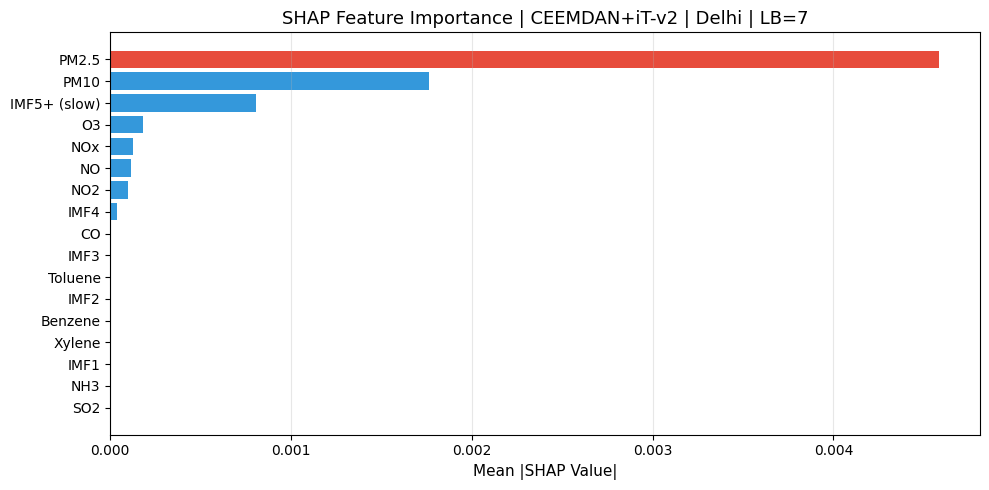

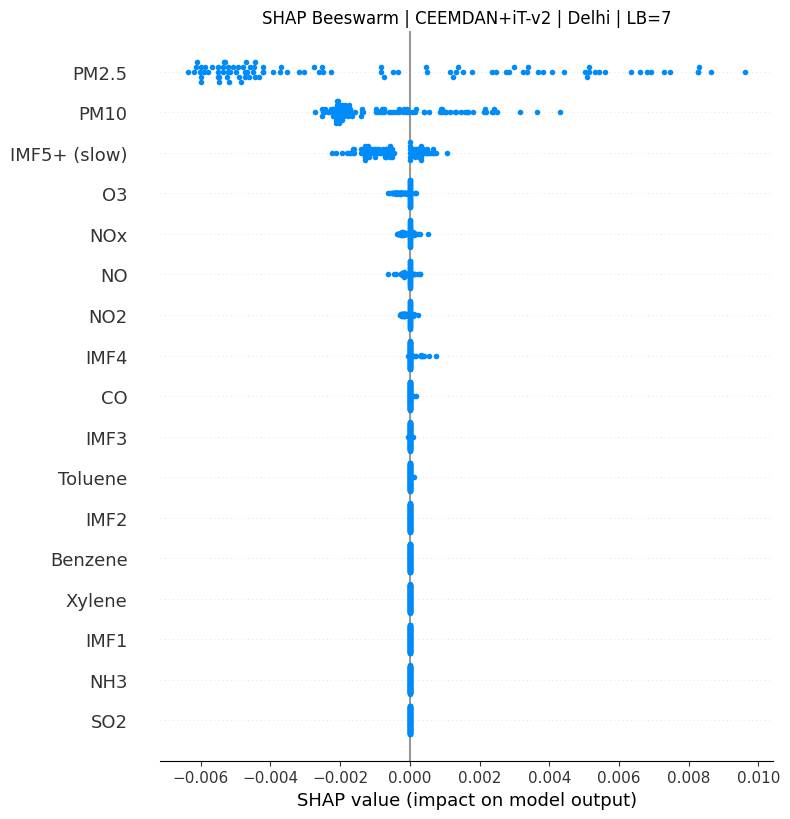

  Delhi top drivers: PM2.5(0.0046), PM10(0.0018), IMF5+ (slow)(0.0008)


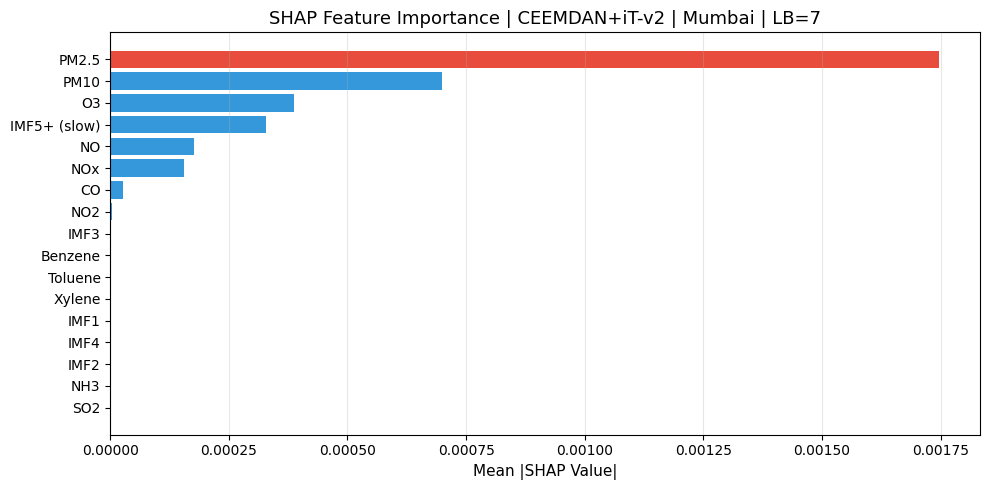

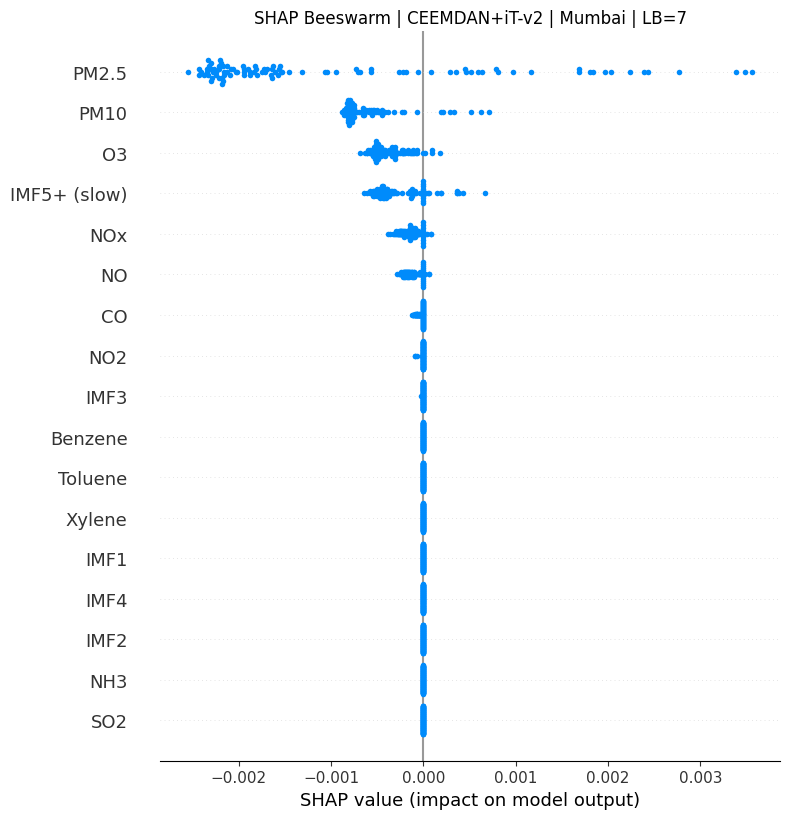

  Mumbai top drivers: PM2.5(0.0017), PM10(0.0007), O3(0.0004)


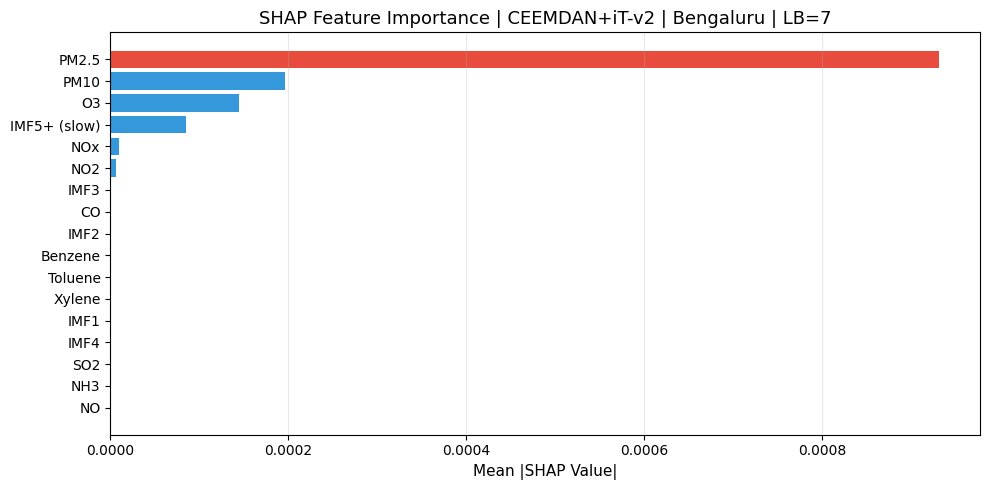

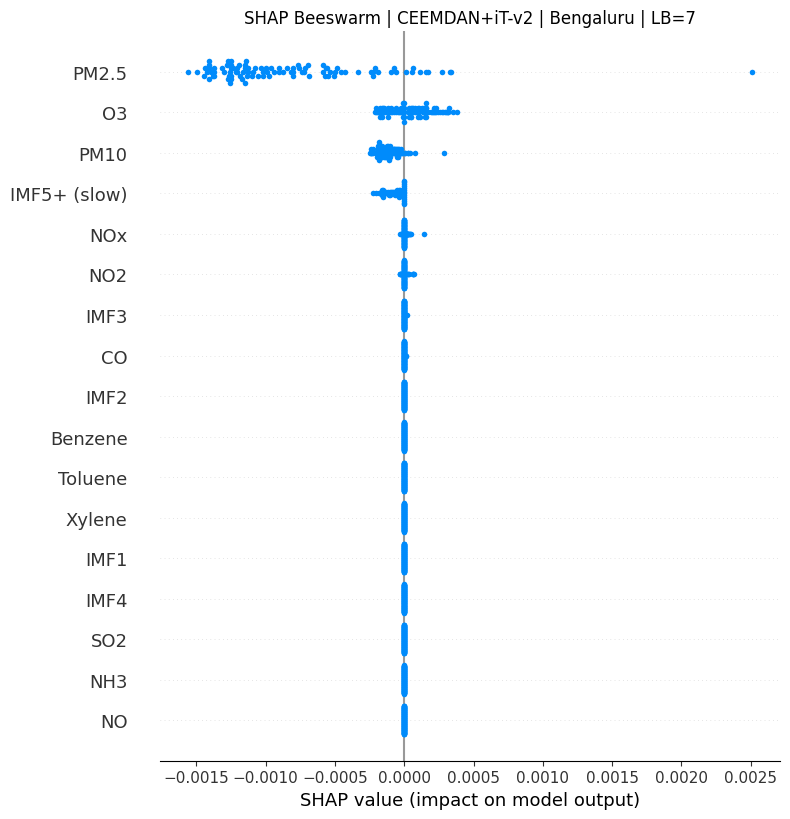

  Bengaluru top drivers: PM2.5(0.0009), PM10(0.0002), O3(0.0001)


In [ ]:
SHAP_LOOKBACK = MAIN_LOOKBACK   # Revision 1: set in Section 8b (R1.16), by validation in step 6 (R1.13)
SHAP_CITIES = ['Delhi', 'Mumbai', 'Bengaluru']
SHAP_N_BACKGROUND = 50
SHAP_MAX_TEST = 100

RUN_SHAP = True  # <-- flip to True to actually run the (slow) SHAP analysis

if RUN_SHAP:
    shap_model_path = get_v2_model_path(SHAP_LOOKBACK)
    shap_scaler_path = get_v2_scalers_path(SHAP_LOOKBACK)
    assert shap_model_path.exists(), (
        f"No trained model at {shap_model_path}. Run the LB={SHAP_LOOKBACK} training in "
        f"Section 6 first (or re-point get_v2_model_path to an existing checkpoint)."
    )

    logger.info(f"Loading v2 model from {shap_model_path}...")
    # Load SHAP model on CPU regardless of training device. KernelSHAP's coalition-
    # sampling loop is CPU-bound (pure Python), so GPU gives no speed benefit here --
    # but moving the full coalition matrix to GPU for each predict_fn call caused a
    # CUDA OOM for Delhi (4.38 GiB allocation attempt) even though Mumbai/Bengaluru
    # succeeded (smaller city datasets). CPU avoids the OOM entirely.
    shap_trainer = CEEMDANFeatureTrainer.load(str(shap_model_path), device=device)

    with open(shap_scaler_path, 'rb') as f:
        shap_saved = pickle.load(f)
    shap_city_to_idx = shap_saved['city_to_idx']

    print(f"\nSHAP Analysis | CEEMDAN+iTransformer v2 | LB={SHAP_LOOKBACK}")
    print("=" * 60)

    city_shap = {}
    for city in SHAP_CITIES:
        try:
            mean_abs = run_shap_for_city(
                city, SHAP_LOOKBACK, shap_trainer, shap_city_to_idx,
                n_background=SHAP_N_BACKGROUND, max_test_samples=SHAP_MAX_TEST,
            )
        except Exception as exc:
            import traceback as _tb
            logger.error(f"  {city}: unhandled exception -- {exc}")
            logger.error(_tb.format_exc())
            mean_abs = None
        if mean_abs is not None:
            city_shap[city] = mean_abs
else:
    city_shap = {}
    print("RUN_SHAP is False -- skipping. Set RUN_SHAP = True and re-run this cell to execute.")

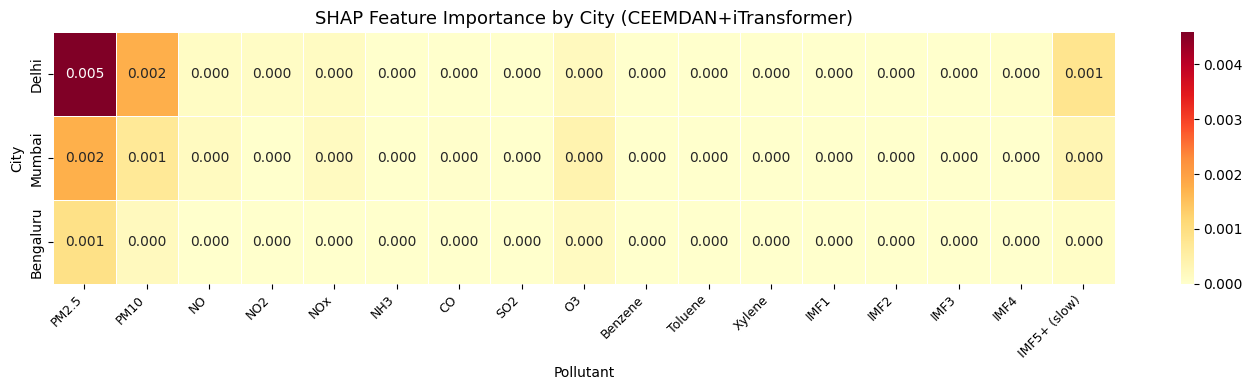


SHAP Summary | LB=7
------------------------------------------------------------
  Delhi: top = PM2.5(0.005), PM10(0.002), IMF5+ (slow)(0.001)  |  IMF share = 11.0%
  Mumbai: top = PM2.5(0.002), PM10(0.001), O3(0.000)  |  IMF share = 9.3%
  Bengaluru: top = PM2.5(0.001), PM10(0.000), O3(0.000)  |  IMF share = 6.2%


In [ ]:

if RUN_SHAP and len(city_shap) > 1:
    heatmap_path = SHAP_PLOTS_DIR / f'shap_v2_city_heatmap_lb{SHAP_LOOKBACK}.png'
    compare_city_shap(city_shap, FEATURE_NAMES_V2, str(heatmap_path))

    attr_path = SHAP_REPORTS_DIR / f'shap_v2_attribution_lb{SHAP_LOOKBACK}.csv'
    rows = [[city] + [f'{v:.6f}' for v in vals] for city, vals in city_shap.items()]
    pd.DataFrame(rows, columns=['city'] + FEATURE_NAMES_V2).to_csv(attr_path, index=False)
    logger.info(f"Multi-city attribution CSV saved to {attr_path}")

    print(f"\nSHAP Summary | LB={SHAP_LOOKBACK}")
    print("-" * 60)
    for city, vals in city_shap.items():
        top_idx = np.argsort(vals)[::-1][:3]
        top_str = ', '.join([f'{FEATURE_NAMES_V2[i]}({vals[i]:.3f})' for i in top_idx])
        imf_share = vals[len(FEATURE_COLUMNS):].sum() / vals.sum() * 100   # the 5 decomposition channels follow the pollutants
        print(f"  {city}: top = {top_str}  |  IMF share = {imf_share:.1f}%")
elif RUN_SHAP:
    print("Fewer than 2 cities produced SHAP results -- skipping cross-city heatmap.")

## 11 -- Reviewer 1 comment R1.13: attribution at the robustness lookback

The SHAP of Section 9 repeated at the robustness lookback (lookback 7, or the next best by validation R² if 7 is the
main lookback), on the same cities and sampled target dates, and compared with the main lookback.

> **Runtime:** about 14 minutes per city on a T4 at lookback 7, longer at longer lookbacks. Needs the model of the
> robustness lookback from Section 6.

In [ ]:
# Variables normally set by Section 9 -- defined here only if Section 9 was skipped.
# Revision 1: the submitted cell set city_shap = {} unconditionally, which in a top-to-bottom run erased Section 9's
# results, so Sections 11, 12 and 14 found nothing to compare or reuse (and Section 14 recomputed the focus cities).
for _name, _default in {'SHAP_CITIES': ['Delhi', 'Mumbai', 'Bengaluru'], 'SHAP_N_BACKGROUND': 50,
                        'SHAP_MAX_TEST': 100, 'city_shap': {}}.items():
    globals().setdefault(_name, _default)


SHAP Analysis | CEEMDAN+iTransformer v2 | LB=30 (robustness check, R1.13)


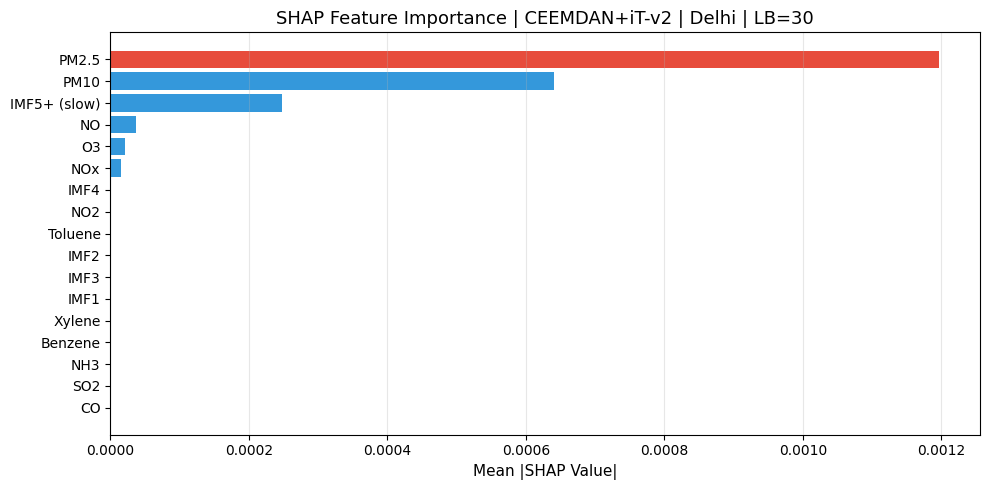

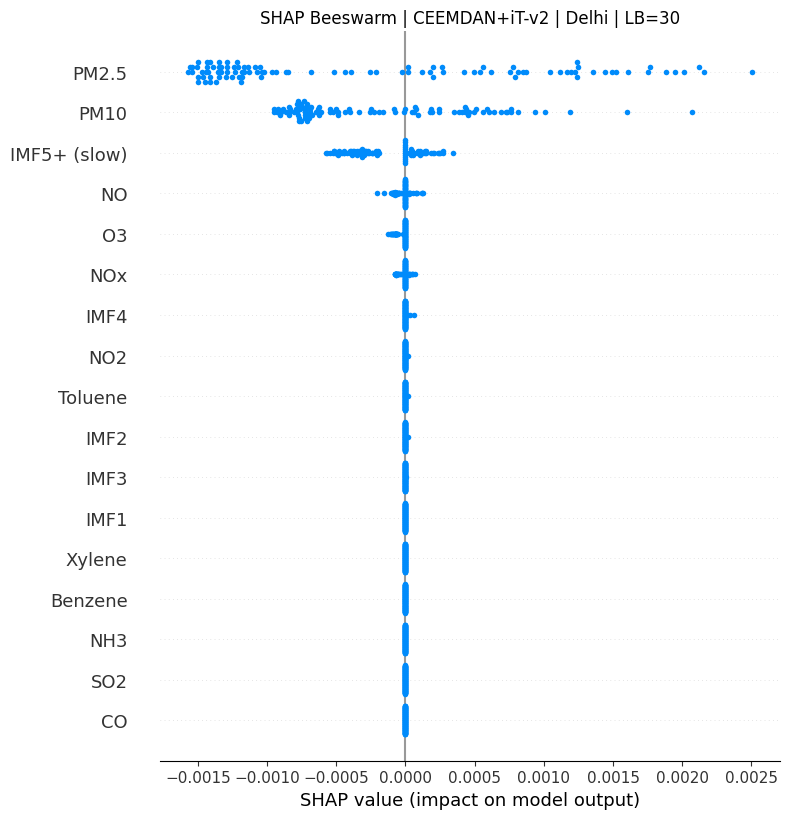

  Delhi top drivers: PM2.5(0.0012), PM10(0.0006), IMF5+ (slow)(0.0002)


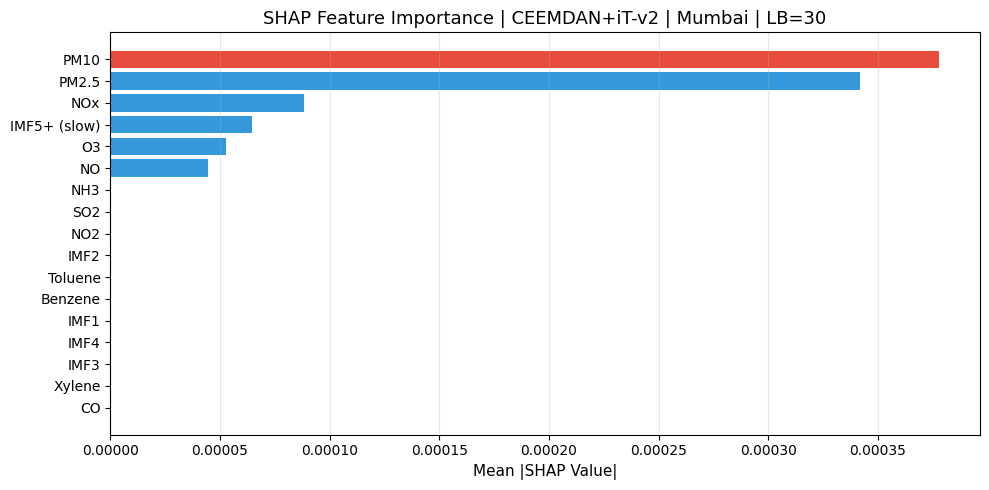

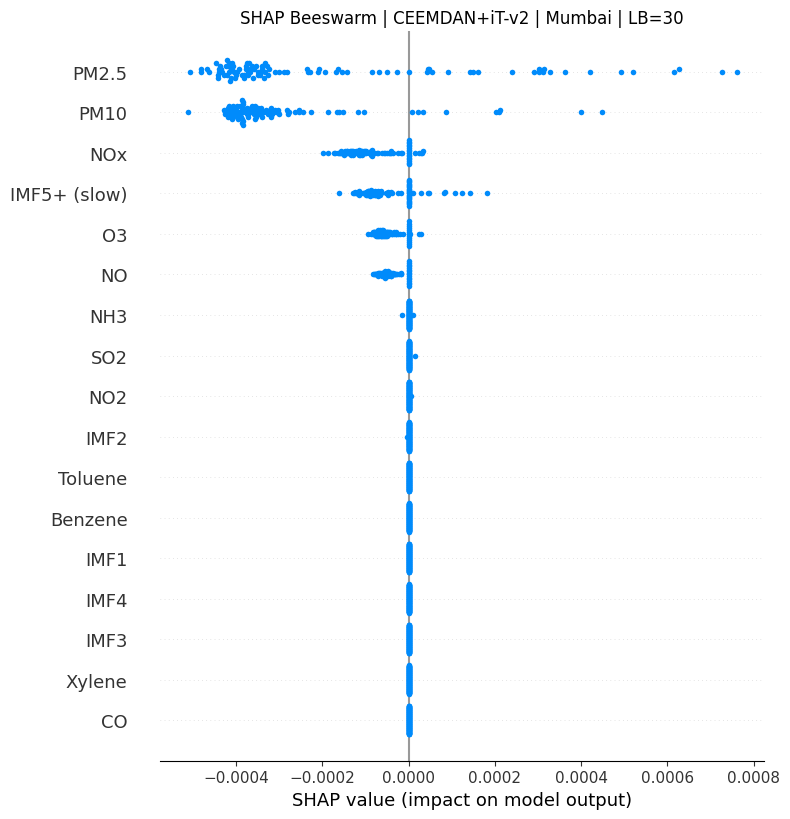

  Mumbai top drivers: PM10(0.0004), PM2.5(0.0003), NOx(0.0001)


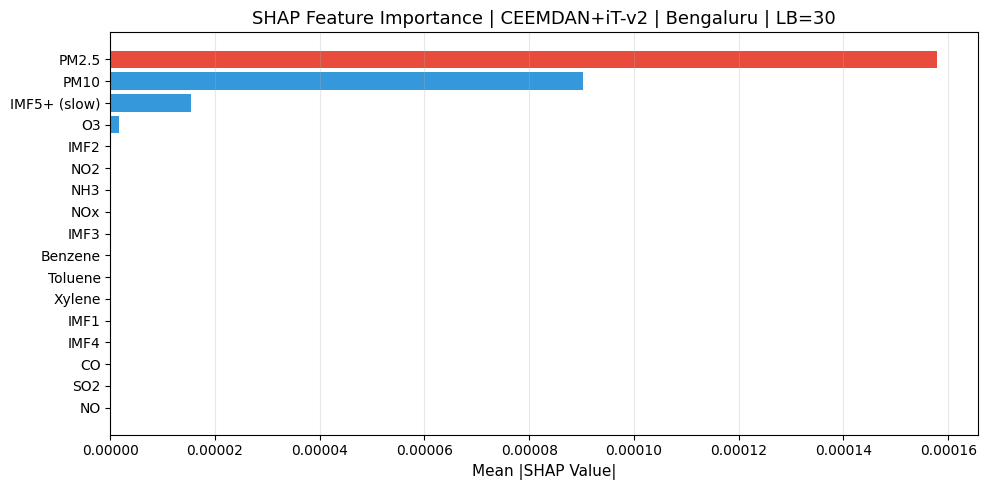

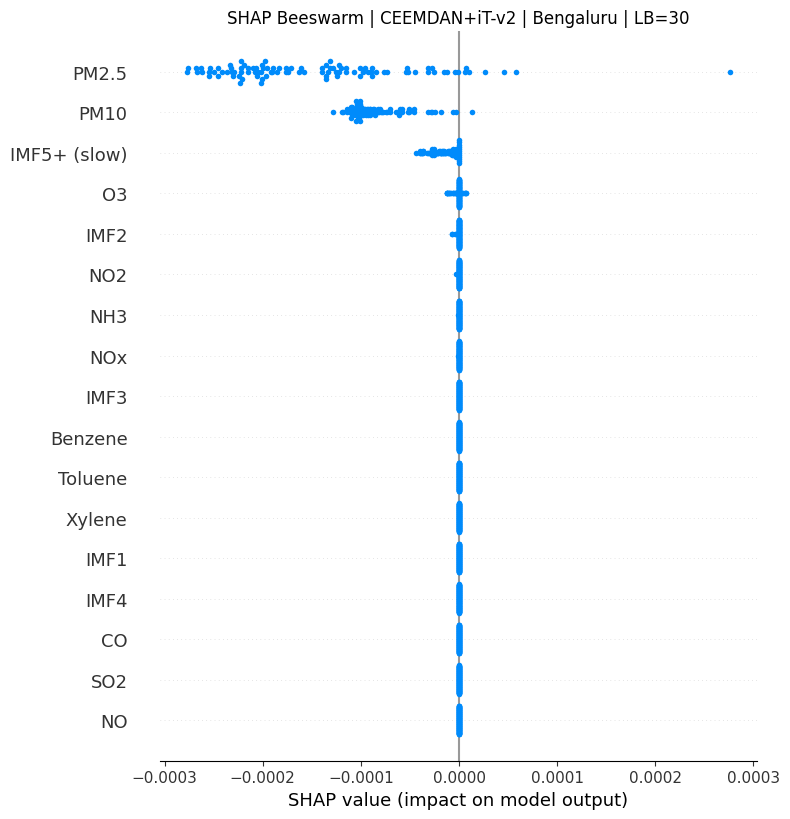

  Bengaluru top drivers: PM2.5(0.0002), PM10(0.0001), IMF5+ (slow)(0.0000)


In [ ]:
# Revision 1, R1.13 (L4): the robustness lookback is 7, or the next best by validation R2 if 7 was selected
# (ROBUST_LOOKBACK, set after Section 6). Submitted: lookback 7 against the attribution lookback 14, by hand.
SHAP_LOOKBACK_ROBUST = ROBUST_LOOKBACK   # reuses SHAP_CITIES / SHAP_N_BACKGROUND / SHAP_MAX_TEST from Section 9

RUN_SHAP_ROBUST = True  # <-- flip to True to actually run the (slow) lookback robustness check

if RUN_SHAP_ROBUST:
    shap_model_path_robust = get_v2_model_path(SHAP_LOOKBACK_ROBUST)
    shap_scaler_path_robust = get_v2_scalers_path(SHAP_LOOKBACK_ROBUST)
    assert shap_model_path_robust.exists(), (
        f"No trained model at {shap_model_path_robust}. Run the LB={SHAP_LOOKBACK_ROBUST} training in "
        f"Section 6 first (LOOKBACK_PERIODS_V2 includes it)."
    )

    logger.info(f"Loading v2 model from {shap_model_path_robust}...")
    trainer_robust = CEEMDANFeatureTrainer.load(str(shap_model_path_robust), device=device)

    with open(shap_scaler_path_robust, 'rb') as f:
        shap_saved_robust = pickle.load(f)
    city_to_idx_robust = shap_saved_robust['city_to_idx']

    print(f"\nSHAP Analysis | CEEMDAN+iTransformer v2 | LB={SHAP_LOOKBACK_ROBUST} (robustness check, R1.13)")
    print("=" * 60)

    city_shap_robust = {}
    for city in SHAP_CITIES:
        try:
            mean_abs = run_shap_for_city(
                city, SHAP_LOOKBACK_ROBUST, trainer_robust, city_to_idx_robust,
                n_background=SHAP_N_BACKGROUND, max_test_samples=SHAP_MAX_TEST,
            )
        except Exception as exc:
            import traceback as _tb
            logger.error(f"  {city}: unhandled exception -- {exc}")
            logger.error(_tb.format_exc())
            mean_abs = None
        if mean_abs is not None:
            city_shap_robust[city] = mean_abs
else:
    city_shap_robust = {}
    print("RUN_SHAP_ROBUST is False -- skipping. Set RUN_SHAP_ROBUST = True and re-run this cell to execute.")


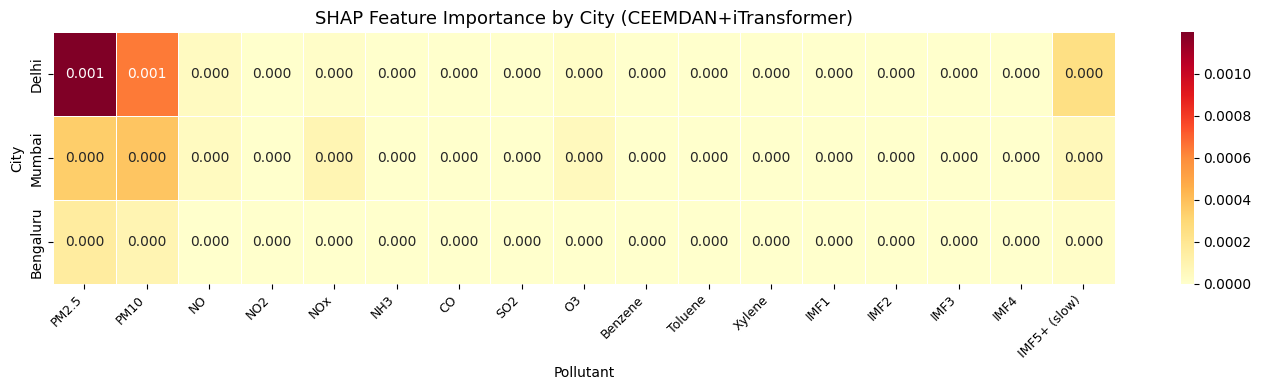


SHAP Summary | LB=30 (robustness check)
------------------------------------------------------------
  Delhi: top = PM2.5(0.001), PM10(0.001), IMF5+ (slow)(0.000)  |  IMF share = 11.6%
  Mumbai: top = PM10(0.000), PM2.5(0.000), NOx(0.000)  |  IMF share = 6.7%
  Bengaluru: top = PM2.5(0.000), PM10(0.000), IMF5+ (slow)(0.000)  |  IMF share = 5.9%


In [ ]:
if RUN_SHAP_ROBUST and len(city_shap_robust) > 1:
    heatmap_path_robust = SHAP_PLOTS_DIR / f'shap_v2_city_heatmap_lb{SHAP_LOOKBACK_ROBUST}.png'
    compare_city_shap(city_shap_robust, FEATURE_NAMES_V2, str(heatmap_path_robust))

    attr_path_robust = SHAP_REPORTS_DIR / f'shap_v2_attribution_lb{SHAP_LOOKBACK_ROBUST}.csv'
    rows = [[city] + [f'{v:.6f}' for v in vals] for city, vals in city_shap_robust.items()]
    pd.DataFrame(rows, columns=['city'] + FEATURE_NAMES_V2).to_csv(attr_path_robust, index=False)
    logger.info(f"Multi-city attribution CSV saved to {attr_path_robust}")

    print(f"\nSHAP Summary | LB={SHAP_LOOKBACK_ROBUST} (robustness check)")
    print("-" * 60)
    for city, vals in city_shap_robust.items():
        top_idx = np.argsort(vals)[::-1][:3]
        top_str = ', '.join([f'{FEATURE_NAMES_V2[i]}({vals[i]:.3f})' for i in top_idx])
        imf_share = vals[len(FEATURE_COLUMNS):].sum() / vals.sum() * 100
        print(f"  {city}: top = {top_str}  |  IMF share = {imf_share:.1f}%")
elif RUN_SHAP_ROBUST:
    print("Fewer than 2 cities produced SHAP results -- skipping cross-city heatmap.")


In [ ]:
# Side-by-side comparison: the main lookback (Section 9, city_shap) vs the robustness lookback (city_shap_robust)
if not city_shap:
    print(f"city_shap is empty -- Section 9's KernelSHAP (RUN_SHAP=True) has not been run in this session, so there is "
          f"no LB={SHAP_LOOKBACK} result to compare the LB={SHAP_LOOKBACK_ROBUST} robustness check against.")
elif not city_shap_robust:
    print("city_shap_robust is empty -- set RUN_SHAP_ROBUST = True above and re-run that cell first.")
else:
    comparison_rows = []
    for city in SHAP_CITIES:
        if city not in city_shap or city not in city_shap_robust:
            print(f"  {city}: missing SHAP result at one of the two lookbacks -- skipping.")
            continue
        vals_main = city_shap[city]
        vals_robust = city_shap_robust[city]

        imf_share_main = vals_main[len(FEATURE_COLUMNS):].sum() / vals_main.sum() * 100
        imf_share_robust = vals_robust[len(FEATURE_COLUMNS):].sum() / vals_robust.sum() * 100

        top3_main = [FEATURE_NAMES_V2[i] for i in np.argsort(vals_main)[::-1][:3]]
        top3_robust = [FEATURE_NAMES_V2[i] for i in np.argsort(vals_robust)[::-1][:3]]

        comparison_rows.append({
            'city': city,
            f'imf_share_lb{SHAP_LOOKBACK}_pct': round(imf_share_main, 1),
            f'imf_share_lb{SHAP_LOOKBACK_ROBUST}_pct': round(imf_share_robust, 1),
            f'top3_lb{SHAP_LOOKBACK}': ', '.join(top3_main),
            f'top3_lb{SHAP_LOOKBACK_ROBUST}': ', '.join(top3_robust),
        })

    df_lb_comparison = pd.DataFrame(comparison_rows)
    print(f"LB={SHAP_LOOKBACK} (Section 9) vs LB={SHAP_LOOKBACK_ROBUST} (robustness check) IMF-attribution share and "
          f"top-3 channels:")
    print(df_lb_comparison.to_string(index=False))

    lb_comparison_csv = SHAP_REPORTS_DIR / f'shap_v2_lb{SHAP_LOOKBACK_ROBUST}_vs_lb{SHAP_LOOKBACK}_comparison.csv'
    df_lb_comparison.to_csv(lb_comparison_csv, index=False)
    logger.info(f"Lookback comparison CSV saved to {lb_comparison_csv}")


LB=7 (Section 9) vs LB=30 (robustness check) IMF-attribution share and top-3 channels:
     city  imf_share_lb7_pct  imf_share_lb30_pct                  top3_lb7                 top3_lb30
    Delhi               11.0                11.6 PM2.5, PM10, IMF5+ (slow) PM2.5, PM10, IMF5+ (slow)
   Mumbai                9.3                 6.7           PM2.5, PM10, O3          PM10, PM2.5, NOx
Bengaluru                6.2                 5.9           PM2.5, PM10, O3 PM2.5, PM10, IMF5+ (slow)


## 12 -- 13-channel autoregressive ablation (R1.3, R3.1)

The decomposition channels are derived from the AQI history, which is strongly autocorrelated. This control model
replaces them with one lagged-AQI channel:

- **Proposed model (Section 6):** 12 pollutant channels + 5 decomposition channels = 17 channels
- **Ablation:** 12 pollutant channels + 1 lagged-AQI channel = 13 channels

It runs at the main lookback with the main model's city term, so it differs from the main model only in its inputs.
Its accuracy is compared with the proposed model's, and its pollutant ranking (KernelSHAP, below) with the proposed
model's ranking from Section 9.

> **Runtime:** one training at the main lookback, then KernelSHAP for 3 cities (about 14 minutes each on a T4).

In [ ]:
def build_ablation_dataset(df, feature_cols, target_col, seq_len=7):
    '''
    13-channel ablation variant of build_augmented_dataset (Comment 2). Same per-city
    sorting/windowing/chronological-split/city_to_idx logic, but instead of computing
    6 CEEMDAN IMF channels, uses the raw per-city AQI array itself as a SINGLE additional
    "AQI_lag" channel (12 pollutants + 1 raw lagged AQI = 13 channels). NEW function --
    does not modify build_augmented_dataset.

    Returns the same dict shape as build_augmented_dataset, but with `scaler_aqi_lag`
    instead of `scaler_imf`, and X arrays of last-dim 13 instead of 18.
    '''
    cities = sorted(df['City'].unique())

    # -- Step 1: Per-city raw data extraction (no CEEMDAN here -- raw AQI is the channel) --
    city_raw = {}
    for city in cities:
        df_c = (df[df['City'] == city]
                .sort_values('Date')
                .reset_index(drop=True))

        # Revision 1, R3.3 D1(b): daily calendar with short gaps filled from past values.
        cal_c, observed, available = d1_calendar_city(df_c, list(feature_cols) + [target_col])
        # Revision 1, R1.9/R1.10 + R1.1: windows after the minimum history, split by common target dates.
        # A city without a training window is not modelled.
        starts, split = r19_city_windows(cal_c['Date'], observed, available, seq_len)
        if split[0] == 0:
            logger.info(f"  [ablation] Skipping {city}: no training window")
            continue
        aqi = cal_c[target_col].values.astype(np.float64)
        feats = n1_pollutant_calendar(cal_c[feature_cols].values.astype(np.float64), observed, available)   # N1

        city_raw[city] = {
            'feats': feats,
            'n1_readings': n1_readings(cal_c[feature_cols].values.astype(np.float64), observed),
            # Revision 1, step 6c: the date of each window's last input day, as in build_augmented_dataset
            'end_dates': pd.to_datetime(cal_c['Date']).to_numpy().astype('datetime64[D]')[starts + seq_len - 1],
            'test_dates': r110_test_dates(cal_c['Date'], starts, split, seq_len),   # Revision 1, R1.9-4
            'aqi':   aqi,   # raw AQI -- reused BOTH as the prediction target and as the single "AQI_lag" input channel
            'n':     len(cal_c),
            'available': available,
            'starts': starts,
            'split': split,
        }

    valid_cities = list(city_raw.keys())
    r19_check_cities(valid_cities, 'build_ablation_dataset')

    city_to_idx = {c: i for i, c in enumerate(valid_cities)}
    logger.info(f"  [ablation] Using {len(valid_cities)}/{len(cities)} cities")

    # -- Step 2: Per-city split indices from the common target dates (identical to build_augmented_dataset) --
    city_splits = {city: city_raw[city]['split'] for city in valid_cities}

    n1_fill_constant(city_raw, 'feats', city_splits, seq_len)   # Revision 1, N1: pooled training constant before the first reading

    # -- Step 3: Collect training rows for scaler fitting --
    train_feats_list, train_aqi_lag_list, train_aqi_list = [], [], []
    for city in valid_cities:   # D1: available days up to the last training target, and the training targets
        train_starts = city_raw[city]['starts'][:city_splits[city][0]]
        rows = d1_train_row_mask(city_raw[city]['n'], train_starts, seq_len, city_raw[city]['available'])
        train_feats_list.append(city_raw[city]['feats'][rows])
        train_aqi_lag_list.append(city_raw[city]['aqi'][rows])
        aqi_slice = city_raw[city]['aqi'][train_starts + seq_len]
        if len(aqi_slice) > 0:
            train_aqi_list.append(aqi_slice)

    all_train_feats = np.vstack(train_feats_list)                       # (total_rows, 12)
    all_train_aqilag = np.concatenate(train_aqi_lag_list).reshape(-1, 1)  # (total_rows, 1)
    all_train_aqi = np.concatenate(train_aqi_list)                       # (total_targets,)

    scaler_X = MinMaxScaler(feature_range=(0, 1)).fit(all_train_feats)
    scaler_aqi_lag = MinMaxScaler(feature_range=(0, 1)).fit(all_train_aqilag)
    scaler_y = MinMaxScaler(feature_range=(0, 1)).fit(all_train_aqi.reshape(-1, 1))

    logger.info(f"  [ablation] Scalers fitted on {len(all_train_feats)} training rows")

    # -- Step 4: Build sequences per city --
    X_train, y_train, city_train = [], [], []
    X_val, y_val, city_val = [], [], []
    X_test, y_test, city_test = [], [], []

    for city in valid_cities:
        d = city_raw[city]
        train_end, val_end, n_seq = city_splits[city]
        city_idx = city_to_idx[city]

        feats_sc = scaler_X.transform(d['feats'])                                  # (n, 12)
        aqi_lag_sc = scaler_aqi_lag.transform(d['aqi'].reshape(-1, 1)).ravel()      # (n,)
        aqi_sc = scaler_y.transform(d['aqi'].reshape(-1, 1)).ravel()                # (n,)

        aug = np.concatenate([feats_sc, aqi_lag_sc.reshape(-1, 1)], axis=1)  # (n, 13)

        for seq_i, raw_i in enumerate(d['starts']):   # D1: usable windows only
            X_win = aug[raw_i: raw_i + seq_len]        # (seq_len, 13)
            y_val_aqi = aqi_sc[raw_i + seq_len]

            if seq_i < train_end:
                X_train.append(X_win)
                y_train.append(y_val_aqi)
                city_train.append(city_idx)
            elif seq_i < val_end:
                X_val.append(X_win)
                y_val.append(y_val_aqi)
                city_val.append(city_idx)
            else:
                X_test.append(X_win)
                y_test.append(y_val_aqi)
                city_test.append(city_idx)

    def _to_arrays(Xl, yl, cl):
        return (
            np.array(Xl, dtype=np.float32),
            np.array(yl, dtype=np.float32),
            np.array(cl, dtype=np.int64),
        )

    X_tr, y_tr, c_tr = _to_arrays(X_train, y_train, city_train)
    X_vl, y_vl, c_vl = _to_arrays(X_val, y_val, city_val)
    X_te, y_te, c_te = _to_arrays(X_test, y_test, city_test)
    for _arr in (X_tr, y_tr, X_vl, y_vl, X_te, y_te):
        assert np.isfinite(_arr).all(), "D1: a window contains an unavailable day"

    logger.info(f"  [ablation] Dataset: train={len(X_tr)}, val={len(X_vl)}, test={len(X_te)}")

    return {
        'X_train': X_tr, 'y_train': y_tr, 'city_train': c_tr,
        'X_val': X_vl, 'y_val': y_vl, 'city_val': c_vl,
        'X_test': X_te, 'y_test': y_te, 'city_test': c_te,
        'scaler_X': scaler_X,
        'scaler_aqi_lag': scaler_aqi_lag,
        'scaler_y': scaler_y,
        'city_to_idx': city_to_idx,
        'valid_cities': valid_cities,
        'n_cities': len(valid_cities),
        # Revision 1, step 6c: per window (train, val, test order) the date of its last input day, saved with the
        # model so its SHAP windows can be matched to the sampled target dates
        'city_end_dates': {c: city_raw[c]['end_dates'] for c in valid_cities},
        'test_dates': np.concatenate([city_raw[c]['test_dates'] for c in valid_cities]),   # Revision 1, R1.9-4
    }

In [ ]:
# New (separate) artifact paths -- never the proposed model's files.
# Revision 1 (R1.13, N6): the ablation runs at the main lookback, so its accuracy and its pollutant ranking are compared
# with the main model at the same lookback (submitted: lookback 7, compared with the main model's SHAP at 14). It takes
# the main model's city term (R1.16), so it differs from the main model only in its inputs.
ABLATION_LOOKBACK = MAIN_LOOKBACK
N_FEATURES_ABLATION = len(FEATURE_COLUMNS) + 1   # 13: the pollutants and the lagged AQI
ABLATION_MODEL_PATH = MODELS_DIR / f'ceemdan_it_ablation13ch_lb{ABLATION_LOOKBACK}.pt'
ABLATION_SCALERS_PATH = MODELS_DIR / f'ceemdan_it_ablation13ch_lb{ABLATION_LOOKBACK}_scalers.pkl'
ABLATION_DATASET_PATH = MODELS_DIR / f'ceemdan_it_ablation13ch_lb{ABLATION_LOOKBACK}_dataset.npz'   # Revision 1, N2

RUN_ABLATION = True  # <-- flip to True to train the 13-channel ablation control model

if RUN_ABLATION:
    logger.info(f"Training 13-channel ablation model (12 pollutants + 1 raw lagged AQI) at LB={ABLATION_LOOKBACK}...")
    set_all_seeds(RANDOM_SEED)  # same seed as the canonical proposed-model run -- controlled comparison

    t0 = time.time()
    ablation_data = build_ablation_dataset(
        df=df,
        feature_cols=FEATURE_COLUMNS,
        target_col=TARGET_COLUMN,
        seq_len=ABLATION_LOOKBACK,
    )

    ablation_trainer = CEEMDANFeatureTrainer(
        seq_len=ABLATION_LOOKBACK,
        n_features=N_FEATURES_ABLATION,
        n_cities=ablation_data['n_cities'],
        warmup_epochs=WARMUP_EPOCHS_V2,
        lr=LEARNING_RATE_V2,
        weight_decay=WEIGHT_DECAY_V2,
        device=device,
        conditioning=MAIN_CONDITIONING,   # Revision 1, R1.16: the main model's city term
        **ITRANSFORMER_V2_PARAMS,   # SAME d_model/nhead/ff_dim/n_layers/dropout as the proposed model -- controlled ablation
    )

    # Revision 1, I-8: saved and reused across sessions (resume helper)
    resume_fit(f'ablation13ch_lb{ABLATION_LOOKBACK}_{MAIN_CONDITIONING}', ablation_trainer,
               (ablation_data['X_train'], ablation_data['y_train'], ablation_data['city_train'],
                ablation_data['X_val'], ablation_data['y_val'], ablation_data['city_val']),
               test_arrays=(ablation_data['X_test'], ablation_data['y_test'], ablation_data['city_test']),
               epochs=EPOCHS_V2, batch_size=BATCH_SIZE_V2, patience=PATIENCE_V2)
    ablation_train_time = time.time() - t0 + ablation_trainer.resume_shift

    y_pred_sc = ablation_trainer.predict(ablation_data['X_test'], ablation_data['city_test'])
    y_pred = ablation_data['scaler_y'].inverse_transform(y_pred_sc.reshape(-1, 1)).flatten()
    y_true = ablation_data['scaler_y'].inverse_transform(ablation_data['y_test'].reshape(-1, 1)).flatten()

    ablation_metrics = Evaluator.evaluate(y_true, y_pred, model_name='CEEMDAN+iT-v2-Ablation13ch')

    ablation_trainer.save(ABLATION_MODEL_PATH)
    with open(ABLATION_SCALERS_PATH, 'wb') as f:
        pickle.dump({
            'scaler_X': ablation_data['scaler_X'],
            'scaler_aqi_lag': ablation_data['scaler_aqi_lag'],
            'scaler_y': ablation_data['scaler_y'],
            'city_to_idx': ablation_data['city_to_idx'],
            'valid_cities': ablation_data['valid_cities'],
            'n_cities': ablation_data['n_cities'],
        }, f)
    logger.info(f"Ablation model saved to {ABLATION_MODEL_PATH} (scalers: {ABLATION_SCALERS_PATH})")
    save_training_dataset(ABLATION_DATASET_PATH, ablation_data, y_pred_sc)   # Revision 1, N2

    ablation_results_13ch = {
        'model': 'CEEMDAN+iT-v2-Ablation13ch (12 pollutants + 1 lagged AQI)',
        'lookback': ABLATION_LOOKBACK,
        'n_cities': ablation_data['n_cities'],
        'train_time_s': round(ablation_train_time, 2),
        'r2': round(ablation_metrics['r2'], 6),
        'rmse': round(ablation_metrics['rmse'], 4),
        'mae': round(ablation_metrics['mae'], 4),
        'mape': round(ablation_metrics['mape'], 4),
        **r110_period_columns(y_true, y_pred, ablation_data['test_dates']),   # Revision 1, R1.9-4
    }
    print(ablation_results_13ch)
else:
    ablation_results_13ch = None
    print("RUN_ABLATION is False -- skipping. Set RUN_ABLATION = True and re-run this cell to train the 13-channel ablation model.")

[CEEMDAN+iT-v2-Ablation13ch] RMSE=43.8424  MAE=23.8814  MAPE=18.91%  R2=0.8484
{'model': 'CEEMDAN+iT-v2-Ablation13ch (12 pollutants + 1 lagged AQI)', 'lookback': 7, 'n_cities': 18, 'train_time_s': 365.27, 'r2': 0.848374, 'rmse': np.float64(43.8424), 'mae': 23.8814, 'mape': np.float32(18.9061), 'n_pre': 4502, 'r2_pre': 0.8652328892115368, 'rmse_pre': 46.19650482743916, 'mae_pre': 25.27592017649545, 'mape_pre': 17.949439754309132, 'n_lock': 1669, 'r2_lock': 0.14386621868117422, 'rmse_lock': 36.74811215451351, 'mae_lock': 20.119793339358466, 'mape_lock': 21.486781141236797}


In [ ]:
# Table 2 addition: 13-channel ablation vs the proposed model, both at the main lookback (Revision 1, R1.13)
if ablation_results_13ch is None:
    print("RUN_ABLATION was False (or the training cell above has not been run yet) -- "
          "no ablation results to compare. Set RUN_ABLATION = True above and rerun first.")
else:
    # MAIN_MODEL_TEST (Section 8b): the test metrics of the main model as installed (R1.16 may have switched it)
    ablation_vs_proposed = pd.DataFrame([
        {
            'model': f"{MAIN_MODEL_TEST['model']} (proposed, {len(FEATURE_NAMES_V2)}ch)", 'lookback': MAIN_LOOKBACK,
            'r2': MAIN_MODEL_TEST['r2'], 'rmse': MAIN_MODEL_TEST['rmse'],
            'mae': MAIN_MODEL_TEST['mae'], 'mape': MAIN_MODEL_TEST['mape'],
            **{c: MAIN_MODEL_TEST[c] for c in R110_COLUMNS},   # Revision 1, R1.9-4
        },
        {
            'model': ablation_results_13ch['model'], 'lookback': ABLATION_LOOKBACK,
            'r2': ablation_results_13ch['r2'], 'rmse': ablation_results_13ch['rmse'],
            'mae': ablation_results_13ch['mae'], 'mape': ablation_results_13ch['mape'],
            **{c: ablation_results_13ch[c] for c in R110_COLUMNS},
        },
    ])
    print(f"Table 2 addition -- 13-channel ablation vs the proposed model (LB={MAIN_LOOKBACK}):")
    print(ablation_vs_proposed.to_string(index=False))

    ablation_comparison_csv = REPORTS_DIR / f'ablation13ch_vs_proposed_lb{MAIN_LOOKBACK}.csv'
    ablation_vs_proposed.to_csv(ablation_comparison_csv, index=False)
    logger.info(f"Ablation-vs-proposed comparison CSV saved to {ablation_comparison_csv}")

Table 2 addition -- 13-channel ablation vs the proposed model (LB=7):
                                                    model  lookback       r2      rmse       mae      mape  n_pre   r2_pre  rmse_pre   mae_pre  mape_pre  n_lock   r2_lock  rmse_lock  mae_lock  mape_lock
                 CEEMDAN+iTransformer-v2 (proposed, 17ch)         7 0.796259 50.821455 33.463252 34.717723 4502.0 0.828564 52.103697 33.210091 30.873681  1669.0 -0.411752  47.189280 34.146135  45.086733
CEEMDAN+iT-v2-Ablation13ch (12 pollutants + 1 lagged AQI)         7 0.848374 43.842400 23.881400 18.906099 4502.0 0.865233 46.196505 25.275920 17.949440  1669.0  0.143866  36.748112 20.119793  21.486781


### Pollutant-ranking check (KernelSHAP on the ablation model)

KernelSHAP on the ablation model, with the same method, cities and sampled dates as Section 9, and the Spearman rank
correlation of the 12 pollutants between the ablation and the proposed model.

In [ ]:
# Feature names for the 13-channel ablation model
FEATURE_NAMES_ABLATION = list(FEATURE_COLUMNS) + ['AQI_lag']   # 13 total


def run_shap_for_city_ablation(city, lookback, trainer, city_to_idx,
                                n_background=50, max_test_samples=100):
    '''
    Ablation-model variant of run_shap_for_city (Comment 2). Mirrors run_shap_for_city's
    body exactly, but calls build_ablation_dataset instead of build_augmented_dataset, and
    uses FEATURE_NAMES_ABLATION instead of FEATURE_NAMES_V2. Reuses compute_kernel_shap /
    plot_shap_bar unchanged. NEW function -- does not modify run_shap_for_city.
    '''
    if city not in city_to_idx:
        logger.error(f"City '{city}' not in training data. Available: {sorted(city_to_idx.keys())}")
        return None

    city_global_idx = city_to_idx[city]
    logger.info(f"\n  [ablation] Processing {city} (global_idx={city_global_idx}, LB={lookback})...")

    # Revision 1, N2 (Q1) + step 6c: the ablation dataset's windows forecasting the sampled dates (the same dates as
    # the main model), never a per-city rebuild
    if lookback != ABLATION_LOOKBACK:
        raise ValueError(f"The ablation model was trained at LB={ABLATION_LOOKBACK}, not LB={lookback}")
    res = shap_explain_city('ablation13ch', city, lookback, trainer, city_to_idx, ABLATION_DATASET_PATH,
                            ABLATION_MODEL_PATH, FEATURE_NAMES_ABLATION, n_background, max_test_samples)
    sv_3d = res['shap_values']                          # (n_test, lookback, 13)
    latency_ms = float(res['latency_ms'])
    mean_abs_shap = np.abs(sv_3d).mean(axis=(0, 1))   # (13,)
    SHAP_PERIOD_ROWS[('ablation13ch', lookback, city)] = shap_period_rows('ablation13ch', city, lookback, res,
                                                                          FEATURE_NAMES_ABLATION, len(FEATURE_COLUMNS))
    shap_write_periods('ablation13ch', lookback)

    logger.info(f"  [ablation] KernelSHAP latency: {latency_ms:.1f}ms/sample")

    bar_path = SHAP_PLOTS_DIR / f'shap_ablation13ch_bar_{city}_lb{lookback}.png'
    plot_shap_bar(
        mean_abs_shap, FEATURE_NAMES_ABLATION,
        title=f'SHAP Feature Importance | Ablation-13ch | {city} | LB={lookback}',
        save_path=str(bar_path),
    )

    csv_path = SHAP_REPORTS_DIR / f'shap_ablation13ch_importance_{city}_lb{lookback}.csv'
    pd.DataFrame({
        'feature': FEATURE_NAMES_ABLATION,
        'mean_abs_shap': mean_abs_shap,
    }).sort_values('mean_abs_shap', ascending=False).to_csv(csv_path, index=False)
    logger.info(f"  [ablation] CSV saved to {csv_path}")

    top_idx = np.argsort(mean_abs_shap)[::-1][:3]
    top_str = ', '.join([f'{FEATURE_NAMES_ABLATION[i]}({mean_abs_shap[i]:.4f})' for i in top_idx])
    print(f"  [ablation] {city} top drivers: {top_str}")

    return mean_abs_shap


SHAP Analysis | CEEMDAN+iT-v2-Ablation13ch | LB=7


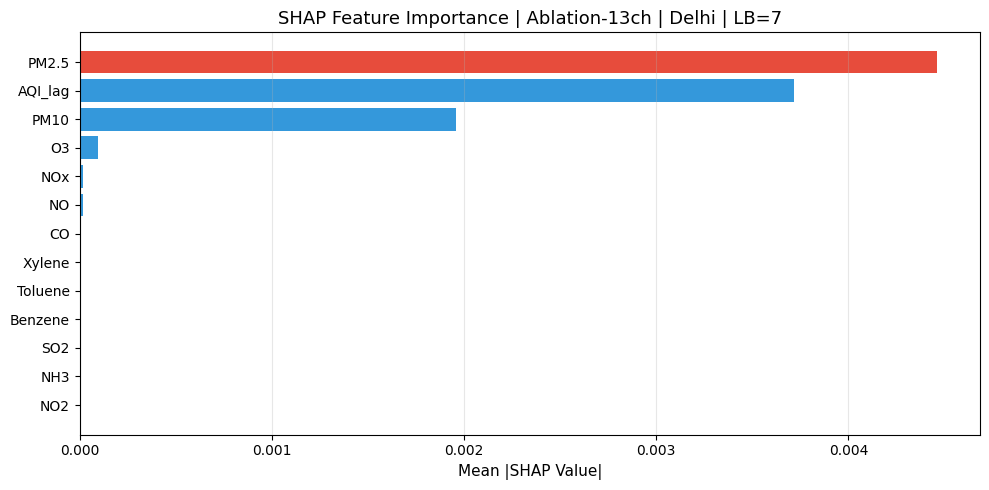

  [ablation] Delhi top drivers: PM2.5(0.0045), AQI_lag(0.0037), PM10(0.0020)


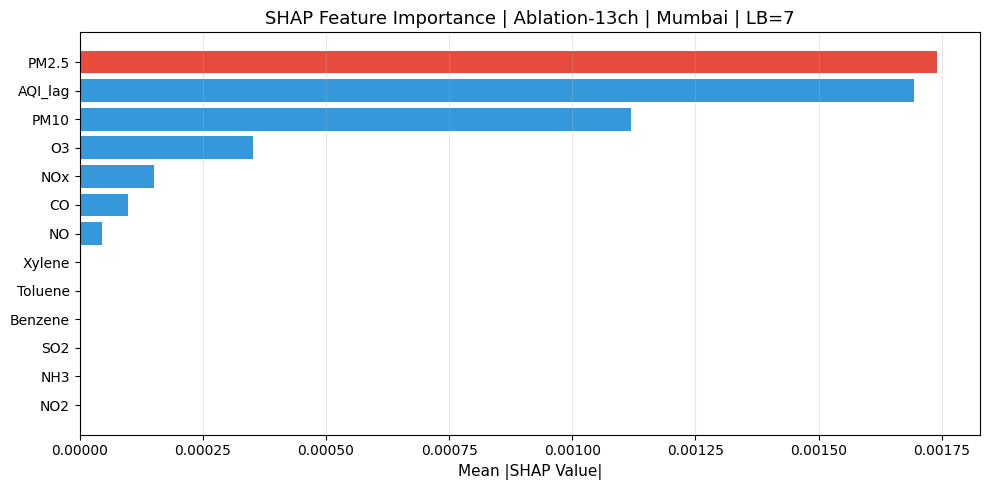

  [ablation] Mumbai top drivers: PM2.5(0.0017), AQI_lag(0.0017), PM10(0.0011)


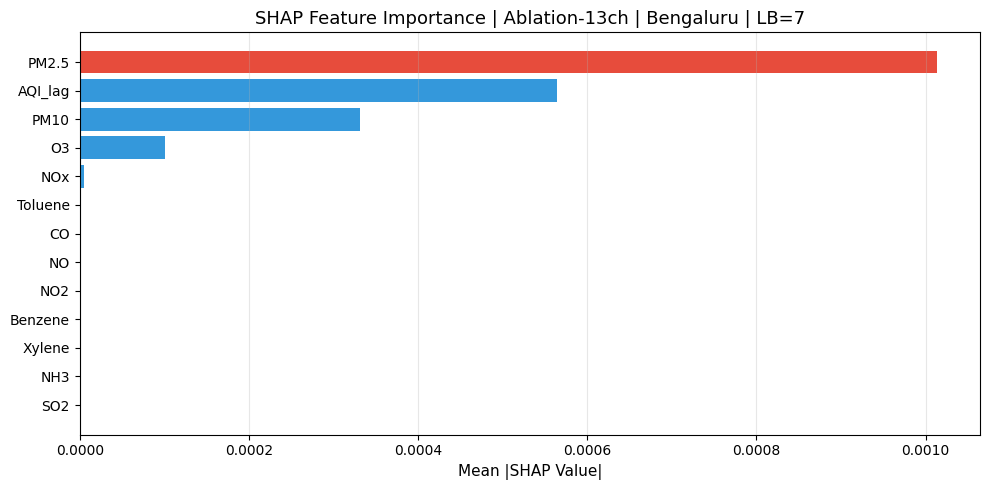

  [ablation] Bengaluru top drivers: PM2.5(0.0010), AQI_lag(0.0006), PM10(0.0003)


In [ ]:
RUN_ABLATION_SHAP = True  # <-- flip to True to run the (slow) KernelSHAP pass on the ablation model

if RUN_ABLATION_SHAP:
    assert ABLATION_MODEL_PATH.exists(), (
        f"No trained ablation model at {ABLATION_MODEL_PATH}. Set RUN_ABLATION = True "
        f"above and run that cell first."
    )

    logger.info(f"Loading ablation model from {ABLATION_MODEL_PATH}...")
    ablation_shap_trainer = CEEMDANFeatureTrainer.load(str(ABLATION_MODEL_PATH), device=device)

    with open(ABLATION_SCALERS_PATH, 'rb') as f:
        ablation_shap_saved = pickle.load(f)
    ablation_city_to_idx = ablation_shap_saved['city_to_idx']

    print(f"\nSHAP Analysis | CEEMDAN+iT-v2-Ablation13ch | LB={ABLATION_LOOKBACK}")
    print("=" * 60)

    city_shap_ablation = {}
    for city in SHAP_CITIES:
        try:
            mean_abs = run_shap_for_city_ablation(
                city, ABLATION_LOOKBACK, ablation_shap_trainer, ablation_city_to_idx,
                n_background=SHAP_N_BACKGROUND, max_test_samples=SHAP_MAX_TEST,
            )
        except Exception as exc:
            import traceback as _tb
            logger.error(f"  {city}: unhandled exception -- {exc}")
            logger.error(_tb.format_exc())
            mean_abs = None
        if mean_abs is not None:
            city_shap_ablation[city] = mean_abs
else:
    city_shap_ablation = {}
    print("RUN_ABLATION_SHAP is False -- skipping. Set RUN_ABLATION_SHAP = True and re-run this cell to execute.")

In [ ]:
import scipy.stats  # not already imported in Section 1 -- needed only for the rank-correlation check below

# Pollutant-ranking comparison: ablation (13ch, 12 pollutants + AQI_lag) vs proposed (17ch, city_shap from Section 9),
# both at the main lookback (Revision 1, R1.13, N6)
if not city_shap:
    print("city_shap (Section 9) is empty -- run Section 9's KernelSHAP (RUN_SHAP=True) first "
          "to compare pollutant rankings against the proposed model.")
elif not city_shap_ablation:
    print("city_shap_ablation is empty -- set RUN_ABLATION_SHAP = True above and re-run that cell first.")
else:
    ranking_rows = []
    for city in SHAP_CITIES:
        if city not in city_shap or city not in city_shap_ablation:
            print(f"  {city}: missing SHAP result in one of the two dicts -- skipping.")
            continue

        # The first len(FEATURE_COLUMNS) entries of each are the pollutant channels (common to both models); after them
        # come the decomposition channels in city_shap and AQI_lag in city_shap_ablation -- excluded here.
        proposed_pollutant_vals = city_shap[city][:len(FEATURE_COLUMNS)]
        ablation_pollutant_vals = city_shap_ablation[city][:len(FEATURE_COLUMNS)]

        rho, pval = scipy.stats.spearmanr(proposed_pollutant_vals, ablation_pollutant_vals)

        proposed_rank = pd.Series(proposed_pollutant_vals, index=FEATURE_COLUMNS).sort_values(ascending=False)
        ablation_rank = pd.Series(ablation_pollutant_vals, index=FEATURE_COLUMNS).sort_values(ascending=False)

        ranking_rows.append({
            'city': city,
            'spearman_rho': round(float(rho), 3),
            'p_value': float(pval),
            'proposed_top5': ', '.join(proposed_rank.index[:5]),
            'ablation_top5': ', '.join(ablation_rank.index[:5]),
        })

    df_ranking_comparison = pd.DataFrame(ranking_rows)
    print(f"Pollutant-ranking comparison -- proposed vs ablation (13ch), LB={MAIN_LOOKBACK}, by city:")
    print(df_ranking_comparison.to_string(index=False))

    ranking_csv = SHAP_REPORTS_DIR / 'ablation13ch_vs_proposed_pollutant_ranking.csv'
    df_ranking_comparison.to_csv(ranking_csv, index=False)
    logger.info(f"Pollutant-ranking comparison CSV saved to {ranking_csv}")

Pollutant-ranking comparison -- proposed vs ablation (13ch), LB=7, by city:
     city  spearman_rho  p_value             proposed_top5                 ablation_top5
    Delhi         0.917 0.000027  PM2.5, PM10, O3, NOx, NO      PM2.5, PM10, O3, NOx, NO
   Mumbai         0.948 0.000003  PM2.5, PM10, O3, NO, NOx      PM2.5, PM10, O3, NOx, CO
Bengaluru         0.851 0.000447 PM2.5, PM10, O3, NOx, NO2 PM2.5, PM10, O3, NOx, Toluene


## 13 -- Multi-seed reruns, mean +/- s.d.

The proposed model, the plain iTransformer and the 13-channel ablation at the main lookback over five model seeds
`SEEDS = [42, 123, 2024, 7, 2025]`, reported as mean +/- s.d., full year and per period. The proposed model's five
seeds are those of Section 8b.

**What the seed varies.** The CEEMDAN decomposition is computed once (seed base 123) and held fixed. Only the model
seed (weight initialisation and mini-batch order) varies. The plain iTransformer uses no decomposition, so this is
the like-for-like source of run-to-run variance for the comparison. The effect of the decomposition seed is measured
separately: the seed-stability check at the end of this section and Section 17 (the whole decomposition repeated with
a second seed).

> **Runtime:** a few trainings per model at the main lookback. Saved trainings are reused.

In [ ]:
# NOTE (Option B): CEEMDAN seed is NOT varied here. The decomposition inside `data` was
# computed ONCE with a fixed seed (see the run cell below) and is reused for every model seed.
# Only set_all_seeds(seed) -- iTransformer weight init + mini-batch shuffle -- varies per run.
def r113_reused_main_runs(lookback):
    """Revision 1: the main model's runs from Section 8b at this lookback, in Section 13's row format (test metrics,
    rounded as train_v2_on_data rounds them). Empty if Section 8b did not run at this lookback."""
    if not (globals().get('RUN_R116') and 'df_r116_runs' in globals()):
        return []
    runs = df_r116_runs[(df_r116_runs['conditioning'] == MAIN_CONDITIONING) & (df_r116_runs['lookback'] == lookback)]
    return [{'model': 'CEEMDAN+iTransformer-v2', 'seed': int(r.seed), 'lookback': int(r.lookback),
             'train_time_s': round(float(r.train_time_s), 2), 'r2': round(r.test_r2, 6), 'rmse': round(r.test_rmse, 4),
             'mae': round(r.test_mae, 4), 'mape': round(r.test_mape, 4), 'source': 'Section 8b',
             **{c: getattr(r, f'test_{c}') for c in R110_COLUMNS}}   # R1.9-4
            for r in runs.itertuples()]


def train_v2_on_data(data, seed, lookback, conditioning='bias', run='ms_v2'):
    """
    Option B multi-seed trainer for the proposed CEEMDAN+iTransformer-v2.
    `data` = a pre-built augmented dataset whose CEEMDAN modes were computed with a FIXED seed.
    This function varies ONLY the model seed (weight init + shuffle); the CEEMDAN decomposition
    is identical across all seeds. Does NOT save -- throwaway variance-estimation runs.
    Revision 1, I-8: the training itself is saved for reuse across sessions; `run` names it (PM2.5: 'ms_v2_pm25').
    """
    set_all_seeds(seed)
    t0 = time.time()
    trainer = CEEMDANFeatureTrainer(
        seq_len=lookback, n_features=data['X_train'].shape[-1], n_cities=data['n_cities'],   # R3.6: 17 AQI, 16 PM2.5
        warmup_epochs=WARMUP_EPOCHS_V2, lr=LEARNING_RATE_V2, weight_decay=WEIGHT_DECAY_V2,
        device=device, conditioning=conditioning, **ITRANSFORMER_V2_PARAMS,   # R1.16
    )
    # Revision 1, I-8: saved and reused across sessions (resume helper)
    resume_fit(f'{run}_lb{lookback}_{conditioning}', trainer,
               (data['X_train'], data['y_train'], data['city_train'], data['X_val'], data['y_val'], data['city_val']),
               test_arrays=(data['X_test'], data['y_test'], data['city_test']),
               epochs=EPOCHS_V2, batch_size=BATCH_SIZE_V2, patience=PATIENCE_V2)
    train_time = time.time() - t0 + trainer.resume_shift
    y_pred_sc = trainer.predict(data['X_test'], data['city_test'])
    y_pred = data['scaler_y'].inverse_transform(y_pred_sc.reshape(-1, 1)).flatten()
    y_true = data['scaler_y'].inverse_transform(data['y_test'].reshape(-1, 1)).flatten()
    metrics = Evaluator.evaluate(y_true, y_pred, model_name=f'CEEMDAN+iTransformer-v2 (seed={seed})')
    return {
        'model': 'CEEMDAN+iTransformer-v2', 'seed': seed, 'lookback': lookback,
        'train_time_s': round(train_time, 2),
        'r2': round(metrics['r2'], 6), 'rmse': round(metrics['rmse'], 4),
        'mae': round(metrics['mae'], 4), 'mape': round(metrics['mape'], 4),
        **r110_period_columns(y_true, y_pred, data['test_dates']),   # Revision 1, R1.9-4: per lockdown period
    }


In [ ]:
def train_itransformer_on_data(data, seed, lookback):
    """
    Option B multi-seed trainer for the plain iTransformer baseline (no CEEMDAN).
    `data` is a fixed, deterministic chronological split (AQIDataLoader); only the model seed
    (weight init + shuffle) varies. Does NOT save -- throwaway variance-estimation runs.
    """
    set_all_seeds(seed)
    trainer = iTransformerTrainer(
        seq_len=lookback, n_features=N_FEATURES_BASELINE, **ITRANSFORMER_PARAMS,
        lr=LEARNING_RATE_BASELINE, weight_decay=WEIGHT_DECAY_BASELINE, device=device,
    )
    t0 = time.time()
    # Revision 1, I-8: saved and reused across sessions (resume helper)
    resume_fit(f'ms_it_lb{lookback}', trainer, (data['X_train'], data['y_train'], data['X_val'], data['y_val']),
               test_arrays=(data['X_test'], data['y_test']),
               epochs=EPOCHS_BASELINE, batch_size=BATCH_SIZE_BASELINE, patience=PATIENCE_BASELINE)
    train_time = time.time() - t0 + trainer.resume_shift
    y_pred_sc = trainer.predict(data['X_test'])
    y_pred = data['scaler_y'].inverse_transform(y_pred_sc.reshape(-1, 1)).flatten()
    y_true = data['scaler_y'].inverse_transform(data['y_test'].reshape(-1, 1)).flatten()
    metrics = Evaluator.evaluate(y_true, y_pred, model_name=f'iTransformer (seed={seed})')
    return {
        'model': 'iTransformer', 'seed': seed, 'lookback': lookback,
        'train_time_s': round(train_time, 2),
        'r2': round(metrics['r2'], 6), 'rmse': round(metrics['rmse'], 4),
        'mae': round(metrics['mae'], 4), 'mape': round(metrics['mape'], 4),
        **r110_period_columns(y_true, y_pred, data['test_dates']),   # Revision 1, R1.9-4: per lockdown period
    }


In [ ]:
def train_ablation_on_data(data, seed, lookback, conditioning='bias'):
    """
    Option B multi-seed trainer for the 13-channel lag ablation (12 pollutants + raw lagged AQI).
    `data` is a fixed, deterministic split (no CEEMDAN involved); only the model seed varies.
    Does NOT save -- throwaway variance-estimation runs.
    """
    set_all_seeds(seed)
    t0 = time.time()
    trainer = CEEMDANFeatureTrainer(
        seq_len=lookback, n_features=data['X_train'].shape[-1], n_cities=data['n_cities'],
        warmup_epochs=WARMUP_EPOCHS_V2, lr=LEARNING_RATE_V2, weight_decay=WEIGHT_DECAY_V2,
        device=device, conditioning=conditioning, **ITRANSFORMER_V2_PARAMS,   # R1.16: the main model's city term
    )
    # Revision 1, I-8: saved and reused across sessions (resume helper)
    resume_fit(f'ms_abl_lb{lookback}_{conditioning}', trainer,
               (data['X_train'], data['y_train'], data['city_train'], data['X_val'], data['y_val'], data['city_val']),
               test_arrays=(data['X_test'], data['y_test'], data['city_test']),
               epochs=EPOCHS_V2, batch_size=BATCH_SIZE_V2, patience=PATIENCE_V2)
    train_time = time.time() - t0 + trainer.resume_shift
    y_pred_sc = trainer.predict(data['X_test'], data['city_test'])
    y_pred = data['scaler_y'].inverse_transform(y_pred_sc.reshape(-1, 1)).flatten()
    y_true = data['scaler_y'].inverse_transform(data['y_test'].reshape(-1, 1)).flatten()
    metrics = Evaluator.evaluate(y_true, y_pred, model_name=f'13ch-ablation (seed={seed})')
    return {
        'model': '13ch-ablation', 'seed': seed, 'lookback': lookback,
        'train_time_s': round(train_time, 2),
        'r2': round(metrics['r2'], 6), 'rmse': round(metrics['rmse'], 4),
        'mae': round(metrics['mae'], 4), 'mape': round(metrics['mape'], 4),
        **r110_period_columns(y_true, y_pred, data['test_dates']),   # Revision 1, R1.9-4: per lockdown period
    }


In [ ]:
SEEDS = [42, 123, 2024, 7, 2025]  # 5 model seeds, reported as mean +/- s.d.

MULTISEED_LOOKBACK = MAIN_LOOKBACK   # Revision 1, R1.13: Table 2's headline lookback (submitted: 7)
CEEMDAN_FIXED_SEED = 123    # Option B: CEEMDAN decomposition is held constant across all runs;
                            # only the iTransformer model seed (above) is varied. See the
                            # Design note markdown above for the full justification.
                            # Revision 1: the decomposition is the saved C5_DECOMP (seeds C5_SEED_BASE + city
                            # index), so it is fixed by construction; this seed now sets the data-loading RNG only.

RUN_MULTISEED = True  # <-- set True to run (builds data ONCE, then 5 seeds x 3 models = 15 fast trainings)

if RUN_MULTISEED:
    # ---- Build each dataset ONCE with a FIXED seed (Option B). Only the model seed varies below. ----
    logger.info(f"Building fixed datasets once (CEEMDAN_FIXED_SEED={CEEMDAN_FIXED_SEED}); "
                f"CEEMDAN runs here and is NOT repeated per model seed...")
    set_all_seeds(CEEMDAN_FIXED_SEED)
    v2_data_fixed = build_augmented_dataset(
        df=df, feature_cols=FEATURE_COLUMNS, target_col=TARGET_COLUMN,
        seq_len=MULTISEED_LOOKBACK, decompositions=C5_DECOMP,   # saved causal decompositions, reused for every model seed
    )
    abl_data_fixed = build_ablation_dataset(
        df=df, feature_cols=FEATURE_COLUMNS, target_col=TARGET_COLUMN,
        seq_len=MULTISEED_LOOKBACK,
    )
    it_loader_fixed = AQIDataLoader(df, random_seed=CEEMDAN_FIXED_SEED)
    it_data_fixed = it_loader_fixed.prepare_data(it_loader_fixed.df, seq_len=MULTISEED_LOOKBACK)
    logger.info("Fixed datasets ready. Starting per-seed model training (decomposition frozen).")

    # Revision 1 (R1.16 step 5, R1.13 step 6): the main model's runs already trained in Section 8b at this lookback are
    # reused, not trained again: the 5 seeds of (ii), or seed RANDOM_SEED of (iii) if R1.16 switched the main model.
    multiseed_results_v2 = r113_reused_main_runs(MULTISEED_LOOKBACK)
    reused_seeds = {r['seed'] for r in multiseed_results_v2}
    multiseed_results_itransformer = []
    multiseed_results_ablation = []
    for seed in SEEDS:
        logger.info(f"\n{'='*60}\n  Model seed={seed}  (CEEMDAN fixed at {CEEMDAN_FIXED_SEED})\n{'='*60}")
        if seed not in reused_seeds:
            try:
                multiseed_results_v2.append(train_v2_on_data(v2_data_fixed, seed, MULTISEED_LOOKBACK, MAIN_CONDITIONING))
            except Exception as e:
                logger.error(f"CEEMDAN+iT-v2 seed={seed} failed: {e}", exc_info=True)
        try:
            multiseed_results_itransformer.append(train_itransformer_on_data(it_data_fixed, seed, MULTISEED_LOOKBACK))
        except Exception as e:
            logger.error(f"iTransformer seed={seed} failed: {e}", exc_info=True)
        try:
            multiseed_results_ablation.append(train_ablation_on_data(abl_data_fixed, seed, MULTISEED_LOOKBACK,
                                                                     MAIN_CONDITIONING))
        except Exception as e:
            logger.error(f"13ch-ablation seed={seed} failed: {e}", exc_info=True)

    multiseed_results_v2 = sorted(multiseed_results_v2, key=lambda r: SEEDS.index(r['seed']))
    df_multiseed_v2 = pd.DataFrame(multiseed_results_v2)
    df_multiseed_itransformer = pd.DataFrame(multiseed_results_itransformer)
    df_multiseed_ablation = pd.DataFrame(multiseed_results_ablation)
    print("CEEMDAN+iT-v2 (proposed) multi-seed results:")
    print(df_multiseed_v2.to_string(index=False))
    print("\niTransformer (plain) multi-seed results:")
    print(df_multiseed_itransformer.to_string(index=False))
    print("\n13-channel ablation (12 pollutants + lagged AQI) multi-seed results:")
    print(df_multiseed_ablation.to_string(index=False))
else:
    multiseed_results_v2 = []
    multiseed_results_itransformer = []
    multiseed_results_ablation = []
    print("RUN_MULTISEED is False -- set True and re-run. Option B: data is built ONCE (CEEMDAN "
          "fixed), then 5 model seeds x 3 models = 15 fast trainings (fits one Colab session).")


[iTransformer (seed=42)] RMSE=50.6597  MAE=34.9892  MAPE=38.54%  R2=0.7976
[13ch-ablation (seed=42)] RMSE=49.8795  MAE=32.6389  MAPE=33.50%  R2=0.8037
[iTransformer (seed=123)] RMSE=46.5142  MAE=27.4288  MAPE=25.68%  R2=0.8293
[13ch-ablation (seed=123)] RMSE=43.8424  MAE=23.8814  MAPE=18.91%  R2=0.8484
[iTransformer (seed=2024)] RMSE=45.1621  MAE=28.6746  MAPE=29.33%  R2=0.8391
[13ch-ablation (seed=2024)] RMSE=45.3761  MAE=25.6241  MAPE=21.92%  R2=0.8376
[iTransformer (seed=7)] RMSE=49.4747  MAE=32.6496  MAPE=35.22%  R2=0.8069
[13ch-ablation (seed=7)] RMSE=44.0899  MAE=24.8626  MAPE=20.80%  R2=0.8467
[iTransformer (seed=2025)] RMSE=47.6884  MAE=27.6405  MAPE=27.16%  R2=0.8206
[13ch-ablation (seed=2025)] RMSE=54.1146  MAE=36.0413  MAPE=38.54%  R2=0.7690
CEEMDAN+iT-v2 (proposed) multi-seed results:
                  model  seed  lookback  train_time_s       r2    rmse     mae    mape     source  n_pre   r2_pre  rmse_pre   mae_pre  mape_pre  n_lock   r2_lock  rmse_lock  mae_lock  mape_loc

In [ ]:
# Summary table: mean +/- s.d. across seeds, formatted for direct use in Table 2
if not multiseed_results_v2 or not multiseed_results_itransformer or not multiseed_results_ablation:
    print("Multi-seed results not available -- set RUN_MULTISEED = True above and rerun first.")
else:
    def _mean_std_row(results, model_label):
        dfres = pd.DataFrame(results)
        row = {'model': model_label, 'n_seeds': len(dfres)}
        # Revision 1, R1.9-4: also per lockdown period. Every seed has the same test windows, so n is one number.
        for c in ('n_pre', 'n_lock'):
            if dfres[c].nunique() != 1:
                raise ValueError(f'{model_label}: the seeds differ in {c}')
            row[c] = int(dfres[c].iloc[0])
        for metric in ['r2', 'rmse', 'mae', 'mape'] + [c for c in R110_COLUMNS if not c.startswith('n_')]:
            mean_v = float(np.mean(dfres[metric]))
            std_v = float(np.std(dfres[metric], ddof=1))  # sample std (ddof=1) -- standard choice for small-n reporting
            row[f'mean_{metric}'] = mean_v
            row[f'std_{metric}'] = std_v
            row[f'{metric}_str'] = f"{mean_v:.3f} \u00b1 {std_v:.3f}"
        return row

    summary_rows = [
        _mean_std_row(multiseed_results_v2, 'CEEMDAN+iTransformer-v2 (proposed)'),
        _mean_std_row(multiseed_results_itransformer, 'iTransformer (plain)'),
        _mean_std_row(multiseed_results_ablation, '13ch ablation (12 pollutants + lagged AQI)'),
    ]
    df_multiseed_summary = pd.DataFrame(summary_rows)

    MULTISEED_SUMMARY_CSV = REPORTS_DIR / f'multiseed_summary_lb{MULTISEED_LOOKBACK}.csv'
    df_multiseed_summary.to_csv(MULTISEED_SUMMARY_CSV, index=False)
    logger.info(f"Multi-seed summary saved to {MULTISEED_SUMMARY_CSV}")

    print(f"Table 2 addition -- mean \u00b1 s.d. across seeds {SEEDS} (lookback={MULTISEED_LOOKBACK}):")
    print(df_multiseed_summary[['model', 'n_seeds', 'r2_str', 'rmse_str', 'mae_str', 'mape_str']].to_string(index=False))
    for _p, _label in (('pre', 'pre-lockdown'), ('lock', 'lockdown/Unlock')):   # Revision 1, R1.9-4
        print(f"\n{_label} (n = {df_multiseed_summary[f'n_{_p}'].iloc[0]} test windows):")
        print(df_multiseed_summary[['model'] + [f'{m}_{_p}_str' for m in ('r2', 'rmse', 'mae', 'mape')]].to_string(index=False))

    # Does the reported R^2 gap (proposed - plain iTransformer) exceed seed-to-seed noise?
    r2_gap = summary_rows[0]['mean_r2'] - summary_rows[1]['mean_r2']
    noisier_std = max(summary_rows[0]['std_r2'], summary_rows[1]['std_r2'])
    ratio = (r2_gap / noisier_std) if noisier_std > 0 else float('inf')
    print(f"\nMean R2 gap (proposed - plain iTransformer) across {len(SEEDS)} seeds: {r2_gap:.4f}")
    print(f"Larger of the two seed-to-seed std devs (r2): {noisier_std:.4f}")
    print(f"Gap / std ratio: {ratio:.2f}x  (>~2x indicates the gap is not pure seed noise)")


Table 2 addition -- mean ± s.d. across seeds [42, 123, 2024, 7, 2025] (lookback=7):
                                     model  n_seeds        r2_str       rmse_str        mae_str       mape_str
        CEEMDAN+iTransformer-v2 (proposed)        5 0.791 ± 0.024 51.360 ± 2.971 32.693 ± 3.504 32.740 ± 5.383
                      iTransformer (plain)        5 0.819 ± 0.017 47.900 ± 2.211 30.277 ± 3.371 31.186 ± 5.485
13ch ablation (12 pollutants + lagged AQI)        5 0.821 ± 0.034 47.461 ± 4.442 28.610 ± 5.403 26.735 ± 8.732

pre-lockdown (n = 4502 test windows):
                                     model    r2_pre_str   rmse_pre_str    mae_pre_str   mape_pre_str
        CEEMDAN+iTransformer-v2 (proposed) 0.823 ± 0.020 52.902 ± 2.954 32.872 ± 3.101 29.132 ± 4.449
                      iTransformer (plain) 0.832 ± 0.013 51.471 ± 2.033 32.057 ± 3.333 29.128 ± 4.914
13ch ablation (12 pollutants + lagged AQI) 0.845 ± 0.026 49.383 ± 4.048 29.300 ± 4.688 24.186 ± 7.137

lockdown/Unlock (n = 166

### CEEMDAN seed stability under the causal decomposition

For Delhi, Mumbai and Bengaluru, six test-period days are decomposed causally with four seed bases (123, 42, 2024,
7). Per day and channel: the period on each seed, the relative spread of the periods, and how much the values a
window sees differ from seed 123 (largest difference as a percentage of the AQI history's s.d., and the lowest
correlation).

In [ ]:
# ── Revision 1: CEEMDAN seed stability under the causal decomposition (re-establishes the l. 516 claim) ──
# Replaces the two submitted stability diagnostics, which used full-record, energy-ranked decompositions.
# For Delhi, Mumbai and Bengaluru, STAB_N_DAYS test-period days (evenly spaced over the test period) are decomposed
# causally (C5 histories, paper settings) with the 4 seed bases of the submission: 123 (used for all results),
# 42, 2024 and 7, each plus the city's index as everywhere else. Per day and channel it reports the period on
# each seed, the relative spread across seeds, (max - min) / median, and two measures of how the channel's last
# C5_KEEP values (what a window sees) differ between seed 123 and the other seeds: the largest absolute difference
# as a percentage of the standard deviation of the AQI history, and the lowest correlation. The correlation alone
# misleads for a near-flat trend (a slope of -0.02 against +0.03 AQI/day correlates at about -1 although the
# values differ by under 1 AQI), so the difference measure is the one to read. Written to
# REPORTS_DIR / c5_seed_stability.csv.
# Cost: 3 cities x STAB_N_DAYS days x 4 seeds decompositions (about 4 CPU-minutes at STAB_N_DAYS = 6).
RUN_C5_STABILITY = True
STAB_SEED_BASES = [123, 42, 2024, 7]
STAB_CITIES = ['Delhi', 'Mumbai', 'Bengaluru']
STAB_N_DAYS = 6
C5_STABILITY_CSV = REPORTS_DIR / 'c5_seed_stability.csv'


def c5_seed_stability(df, cities=STAB_CITIES, seed_bases=STAB_SEED_BASES, n_days=STAB_N_DAYS, **params):
    all_cities = sorted(df['City'].unique())
    rows = []
    for city in cities:
        df_c = df[df['City'] == city].sort_values('Date').reset_index(drop=True)
        cal_c, observed, available = d1_calendar_city(df_c, list(FEATURE_COLUMNS) + [TARGET_COLUMN])
        aqi = cal_c[TARGET_COLUMN].values.astype(np.float64)
        dates = pd.to_datetime(cal_c['Date']).to_numpy().astype('datetime64[D]')
        days = c5_days(available)
        test_days = days[dates[days] >= R19_TEST_START]
        for t in test_days[np.linspace(0, len(test_days) - 1, n_days).astype(int)]:
            hist = c5_history(aqi, available, int(t))
            comps = {b: c5_decompose(hist, b + all_cities.index(city), **params) for b in seed_bases}
            n_comp = {b: len(comps[b]) for b in seed_bases}
            if min(n_comp.values()) < C5_N_CHANNELS:
                rows.append({'city': city, 'date': str(dates[t]), 'channel': 'all',
                             'note': f'fewer than {C5_N_CHANNELS} components on a seed: {n_comp}'})
                continue
            chans = {b: c5_channels(c) for b, c in comps.items()}
            for k, name in enumerate(C5_CHANNEL_NAMES):
                per = np.array([c5_period(chans[b][k]) for b in seed_bases])
                ref = chans[seed_bases[0]][k][-C5_KEEP:]
                corr = min(np.corrcoef(ref, chans[b][k][-C5_KEEP:])[0, 1] for b in seed_bases[1:])
                diff = max(np.abs(chans[b][k][-C5_KEEP:] - ref).max() for b in seed_bases[1:])
                rows.append({'city': city, 'date': str(dates[t]), 'channel': name,
                             **{f'period_seed{b}_d': p for b, p in zip(seed_bases, per)},
                             'spread_pct': 100 * (np.nanmax(per) - np.nanmin(per)) / np.nanmedian(per),
                             'max_diff_pct_of_sd': 100 * diff / np.std(hist),
                             'min_corr_last_values': corr, 'note': ''})
    return pd.DataFrame(rows)


if RUN_C5_STABILITY:
    df_c5_stability = c5_seed_stability(df)
    df_c5_stability.to_csv(C5_STABILITY_CSV, index=False, float_format='%.3f')
    print(f"Seed stability written to {C5_STABILITY_CSV}")
    flagged = df_c5_stability[df_c5_stability['note'] != '']
    if len(flagged):
        print(f"Days left out: {len(flagged)}\n{flagged[['city', 'date', 'note']].to_string(index=False)}")
    ok = df_c5_stability[df_c5_stability['note'] == '']
    print("\nPer channel across cities and days: period spread across seeds (%), largest difference of the values a "
          "window sees (% of the AQI history SD), lowest correlation of those values")
    print(ok.groupby('channel', sort=False).agg(median_spread_pct=('spread_pct', 'median'),
                                                 max_spread_pct=('spread_pct', 'max'),
                                                 median_diff_pct_sd=('max_diff_pct_of_sd', 'median'),
                                                 max_diff_pct_sd=('max_diff_pct_of_sd', 'max'),
                                                 lowest_corr=('min_corr_last_values', 'min')).round(3).to_string())
else:
    print("RUN_C5_STABILITY is False -- skipping the seed-stability check.")

Seed stability written to /content/drive/MyDrive/phase4_v2_results_r1/reports/c5_seed_stability.csv

Per channel across cities and days: period spread across seeds (%), largest difference of the values a window sees (% of the AQI history SD), lowest correlation of those values
              median_spread_pct  max_spread_pct  median_diff_pct_sd  max_diff_pct_sd  lowest_corr
channel                                                                                          
IMF1                      4.402           8.834               8.922           22.420        0.779
IMF2                      6.223          13.250              12.544           30.010        0.638
IMF3                      5.003          11.918               8.429           37.567        0.814
IMF4                      0.000          28.877               6.315           16.575        0.859
IMF5+ (slow)              0.000          16.667               4.602           12.102       -0.991


## 14 -- Eight-city attribution (R1.15)

The attribution of Section 9 extended to eight cities. The set follows a rule fixed on data quality before any
revised attribution existed: cities whose kept windows at lookback 14 are at least 80% of their calendar windows,
then Delhi, Mumbai and Bengaluru plus the five most polluted other passing cities by mean AQI. Cities that fail the
completeness rule are trained and evaluated (accuracy for all 18 cities) but not attributed.

The focus cities are read from Section 9's cache. Each new city is saved when it finishes, and
`MAX_NEW_CITIES_THIS_SESSION` limits the new cities per session, so the work can span sessions (results must be on
Drive).

In [ ]:
# ── Revision 1, R3.3 decision D4 (option c): the 8-city attribution set, derived from the rule in code ──
# Replaces the hand-typed SHAP8_CITIES of the submission. The rule, fixed on data quality before any corrected
# attribution existed (updated 1 Oct 2026 for the common-date split):
#   1. completeness: windows kept at L = 14 under D1(b) (d1_window_starts on the daily calendar, before the R1.1
#      minimum history) as a share of the city's calendar windows, at least D4_MIN_KEPT_PCT;
#   2. among the modelled cities (C5_DECOMP, the R1.9/R1.10 city rule), the focus cities Delhi, Mumbai and
#      Bengaluru plus the D4_N_EXTRA most polluted other passing cities by mean AQI (rows with a valid AQI).
# Cities failing the completeness rule are trained and evaluated, and reported in the SI with a limited-data flag.
D4_MIN_KEPT_PCT = 80.0
D4_LOOKBACK = 14
D4_FOCUS = ['Delhi', 'Mumbai', 'Bengaluru']
D4_N_EXTRA = 5


def d4_completeness(df, cities, lookback=D4_LOOKBACK):
    '''Per city: windows kept under D1(b) as % of calendar windows, and mean AQI over rows with a valid AQI.'''
    rows = []
    for city in cities:
        g = df[df['City'] == city]
        cal_c, observed, available = d1_calendar_city(g, list(FEATURE_COLUMNS) + [TARGET_COLUMN])
        n_calendar = len(cal_c) - lookback
        kept = len(d1_window_starts(observed, available, lookback))
        rows.append({'city': city, 'kept_pct': 100.0 * kept / n_calendar if n_calendar > 0 else np.nan,
                     'mean_aqi': float(g[TARGET_COLUMN].mean())})
    out = pd.DataFrame(rows)
    out['passes'] = out['kept_pct'] >= D4_MIN_KEPT_PCT
    return out


def d4_shap8_cities(df, modelled):
    '''The focus cities plus the D4_N_EXTRA most polluted other modelled cities that pass the completeness rule.'''
    table = d4_completeness(df, modelled)
    failing_focus = table[table['city'].isin(D4_FOCUS) & ~table['passes']]['city'].tolist()
    if failing_focus or not set(D4_FOCUS) <= set(modelled):
        raise ValueError(f'D4: focus cities not modelled or failing the completeness rule: {failing_focus}')
    extra = (table[table['passes'] & ~table['city'].isin(D4_FOCUS)]
             .sort_values('mean_aqi', ascending=False)['city'].tolist()[:D4_N_EXTRA])
    if len(extra) < D4_N_EXTRA:
        raise ValueError(f'D4: only {len(extra)} passing cities besides the focus cities')
    return list(D4_FOCUS) + extra, table


D4_SHAP8_CITIES, df_d4 = d4_shap8_cities(df, list(C5_DECOMP))
print(df_d4.sort_values('mean_aqi', ascending=False).round(2).to_string(index=False))
print(f"\nPassing: {int(df_d4['passes'].sum())} of {len(df_d4)} modelled cities. "
      f"Limited-data flag (SI): {sorted(df_d4.loc[~df_d4['passes'], 'city'])}")
print(f"8-city attribution set (D4): {D4_SHAP8_CITIES}")


              city  kept_pct  mean_aqi  passes
         Ahmedabad     62.68    452.12   False
             Delhi     98.80    259.49    True
             Patna     80.52    240.78    True
          Gurugram     83.08    225.12    True
           Lucknow     96.76    217.97    True
           Talcher     57.03    172.89   False
        Jorapokhar     51.04    159.25   False
      Brajrajnagar     62.83    150.28   False
           Kolkata     91.74    140.57    True
            Jaipur     97.53    133.68    True
          Amritsar     84.25    119.92    True
     Visakhapatnam     75.94    117.27   False
           Chennai     96.60    114.50    True
         Hyderabad     96.43    109.21    True
            Mumbai     94.95    105.35    True
         Amaravati     83.23     95.30    True
         Bengaluru     98.23     94.32    True
Thiruvananthapuram     92.39     75.88    True

Passing: 13 of 18 modelled cities. Limited-data flag (SI): ['Ahmedabad', 'Brajrajnagar', 'Jorapokhar', 'Ta

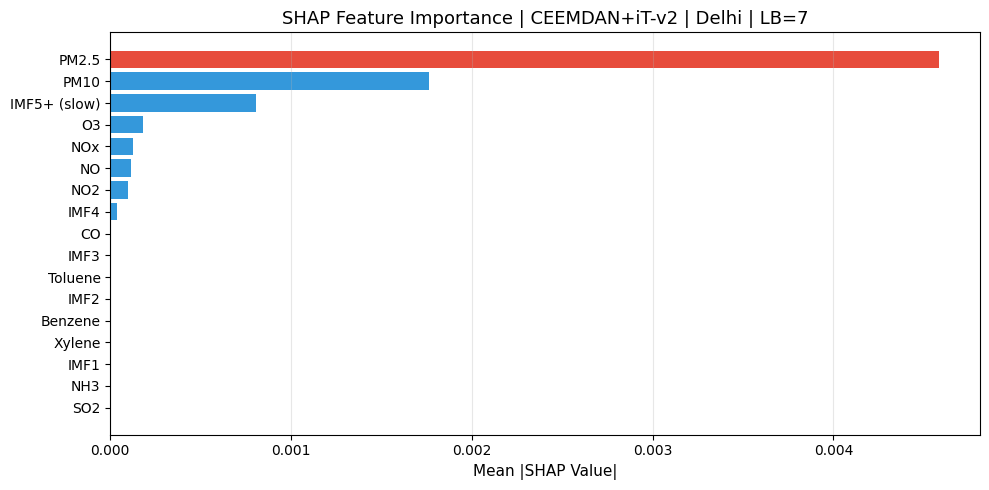

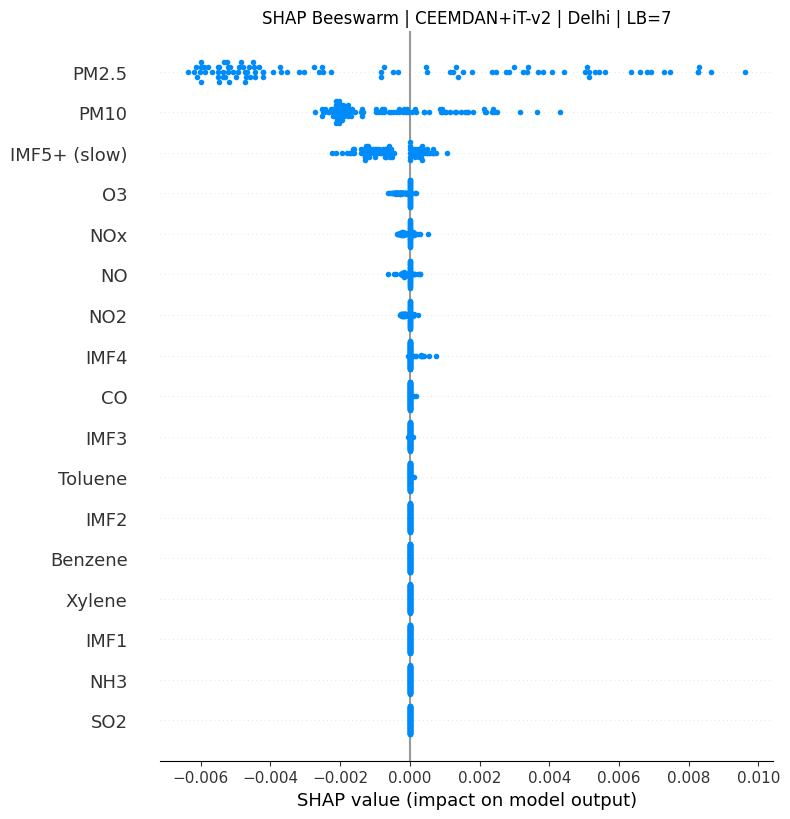

  Delhi top drivers: PM2.5(0.0046), PM10(0.0018), IMF5+ (slow)(0.0008)


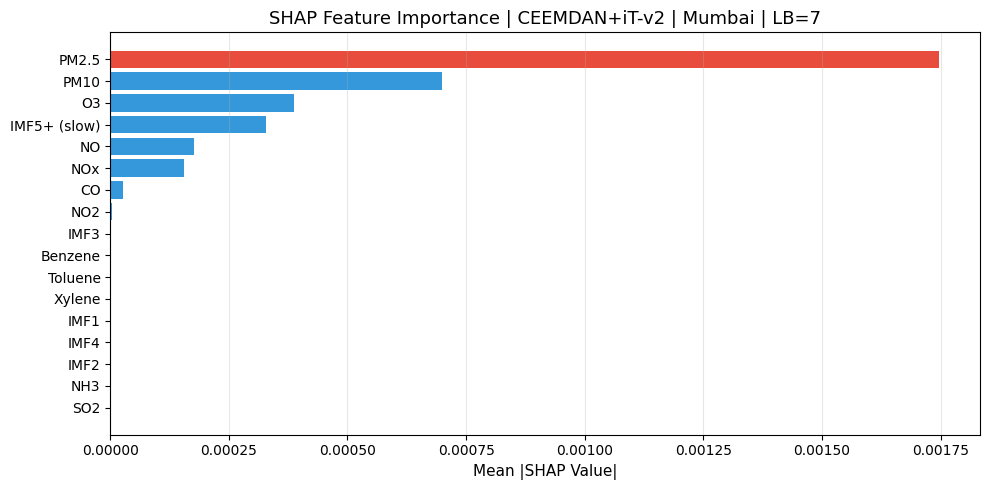

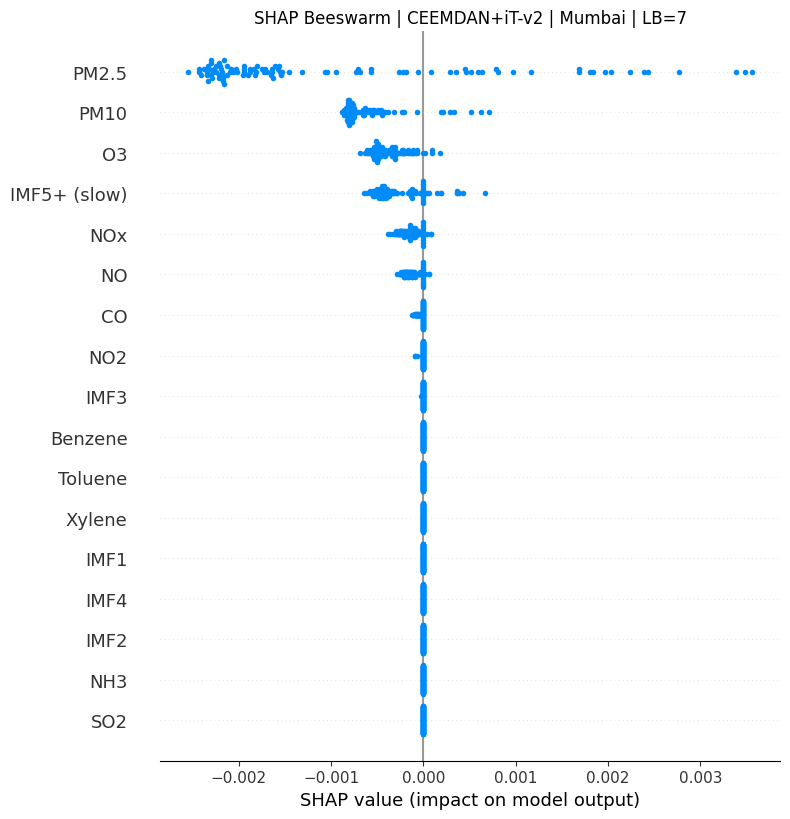

  Mumbai top drivers: PM2.5(0.0017), PM10(0.0007), O3(0.0004)


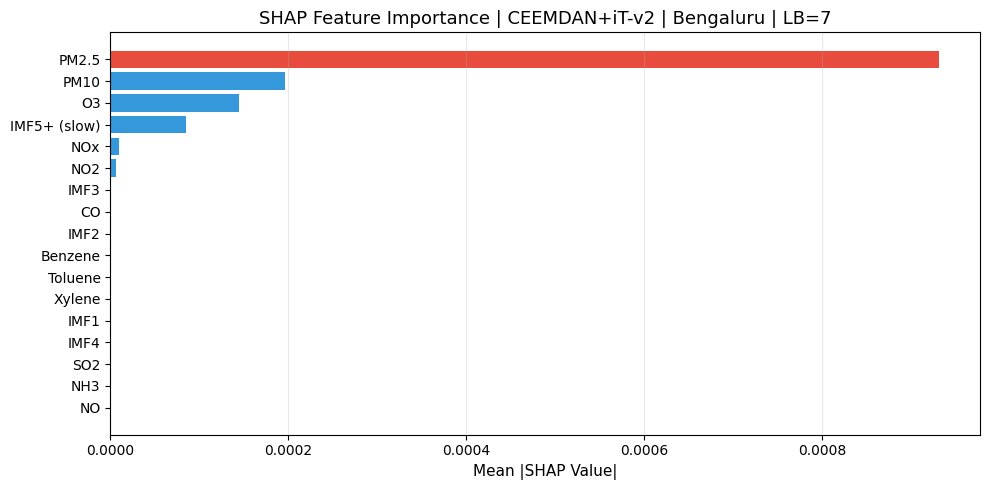

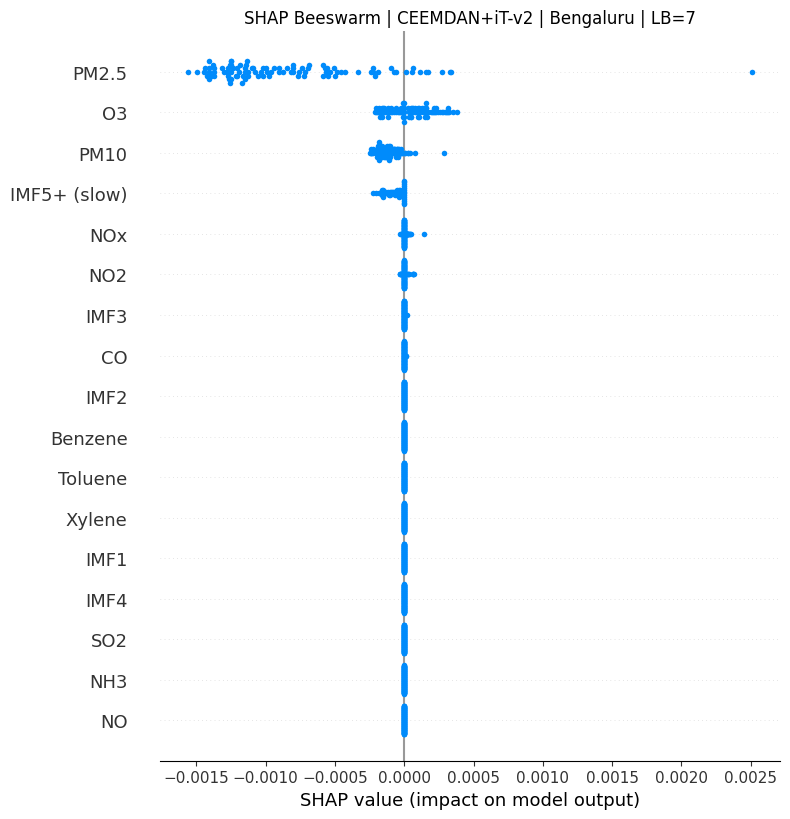

  Bengaluru top drivers: PM2.5(0.0009), PM10(0.0002), O3(0.0001)


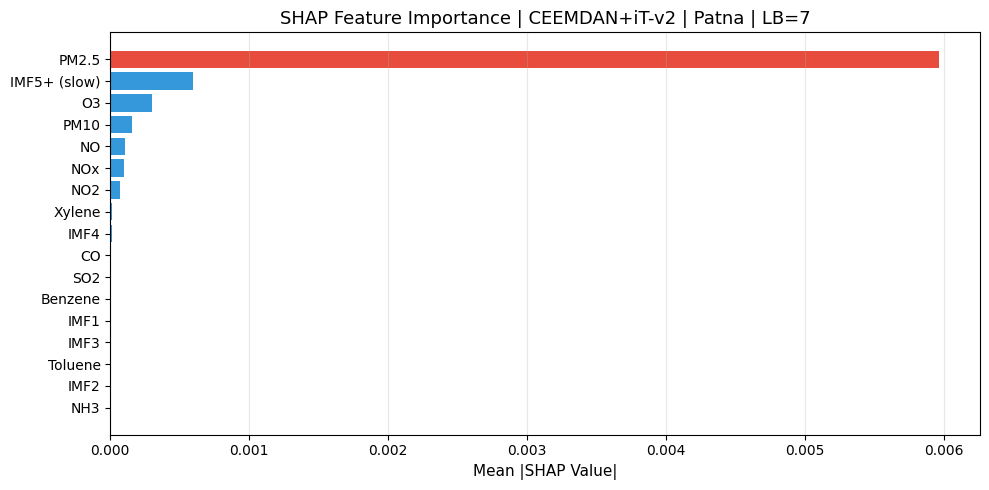

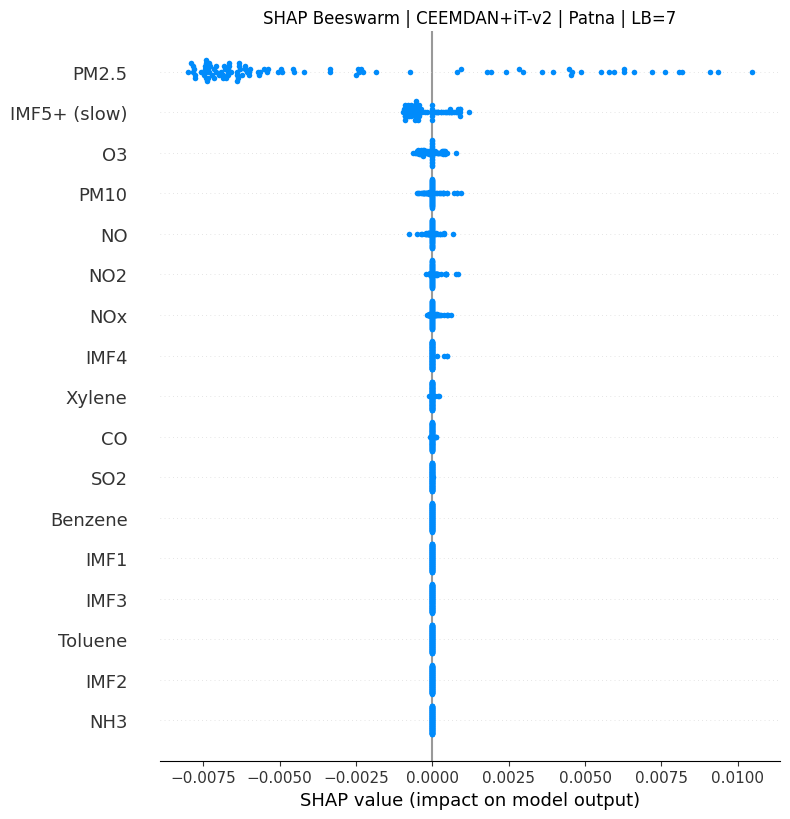

  Patna top drivers: PM2.5(0.0060), IMF5+ (slow)(0.0006), O3(0.0003)


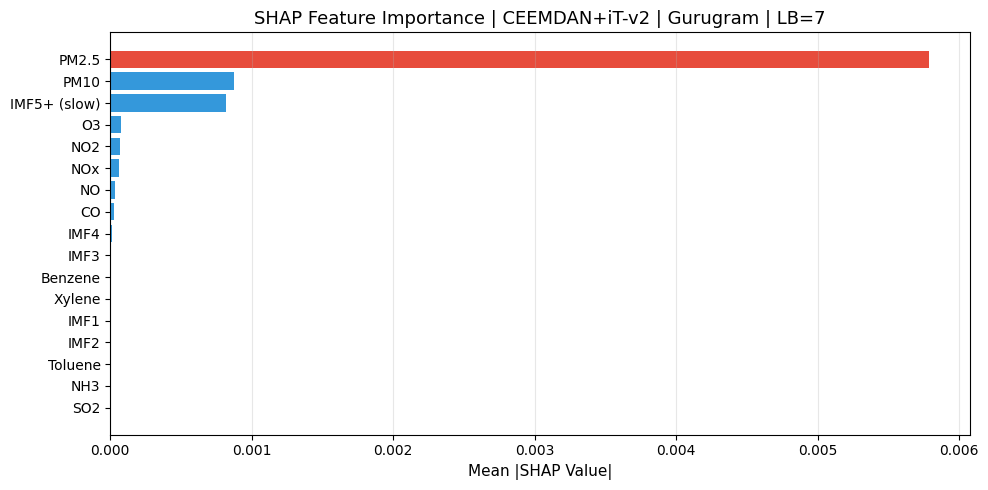

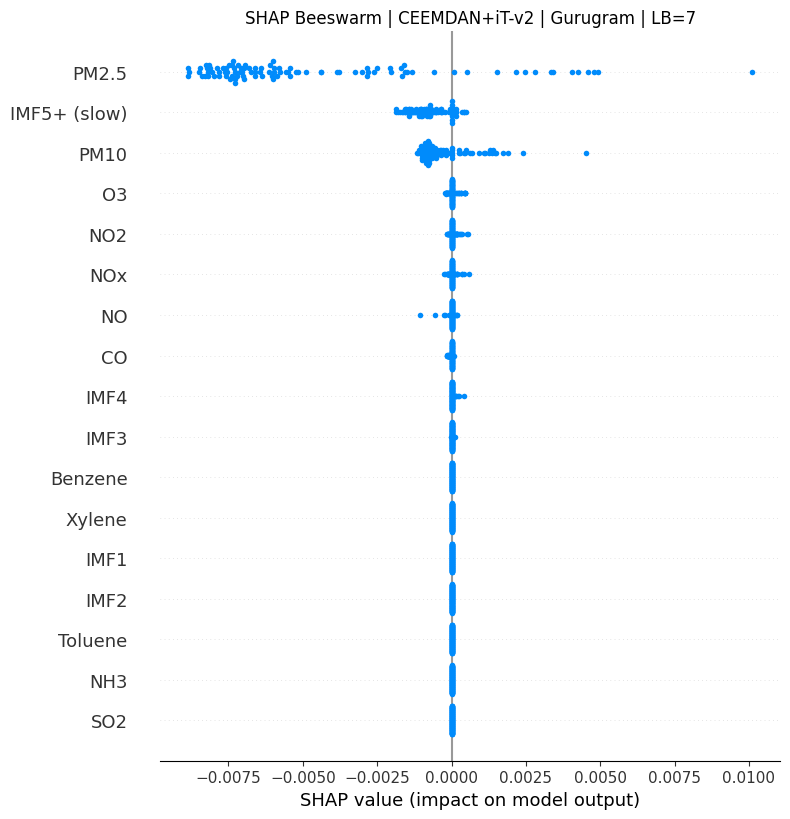

  Gurugram top drivers: PM2.5(0.0058), PM10(0.0009), IMF5+ (slow)(0.0008)


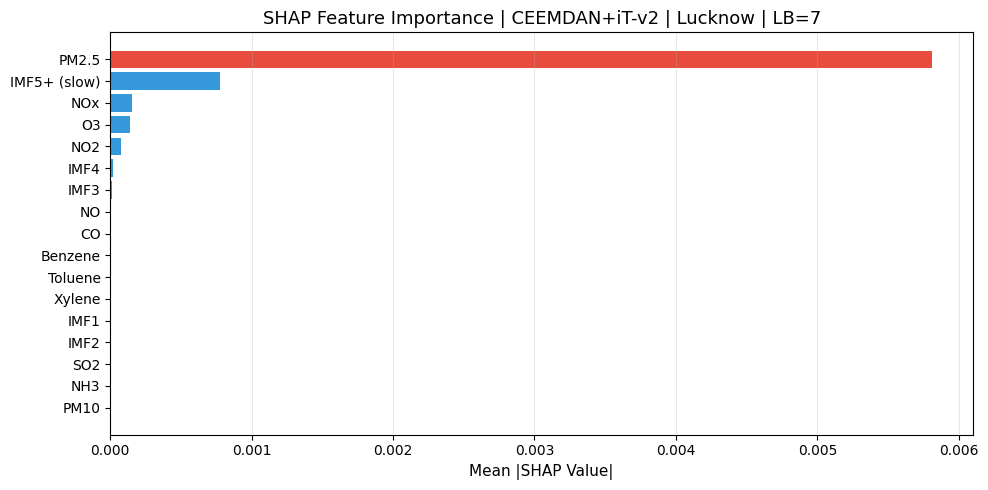

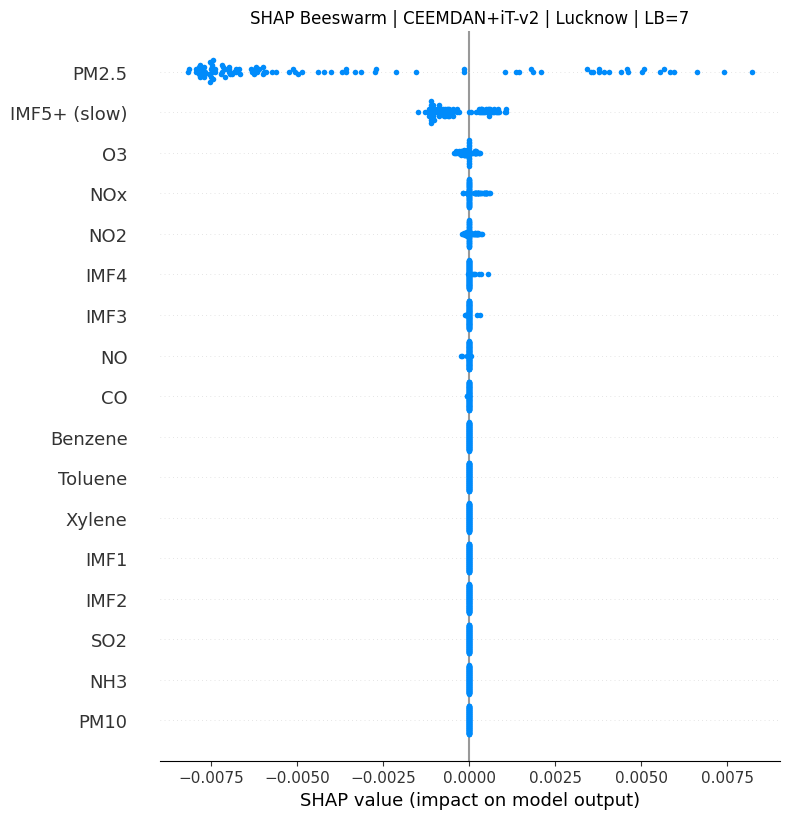

  Lucknow top drivers: PM2.5(0.0058), IMF5+ (slow)(0.0008), NOx(0.0002)


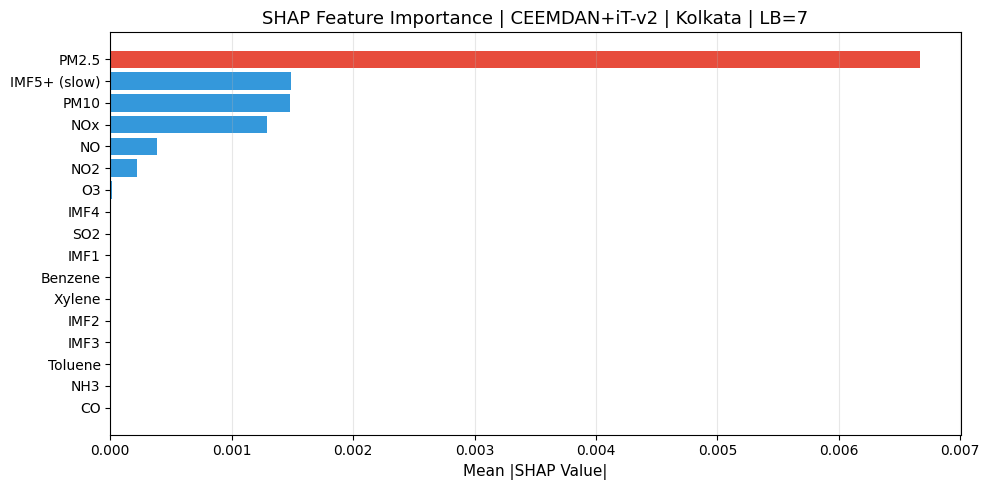

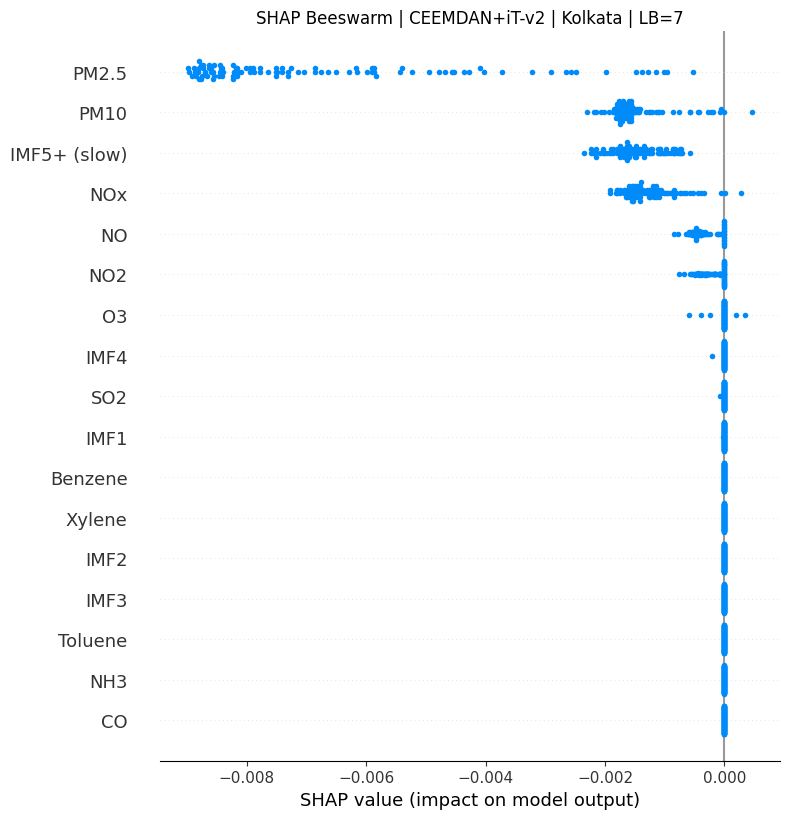

  Kolkata top drivers: PM2.5(0.0067), IMF5+ (slow)(0.0015), PM10(0.0015)


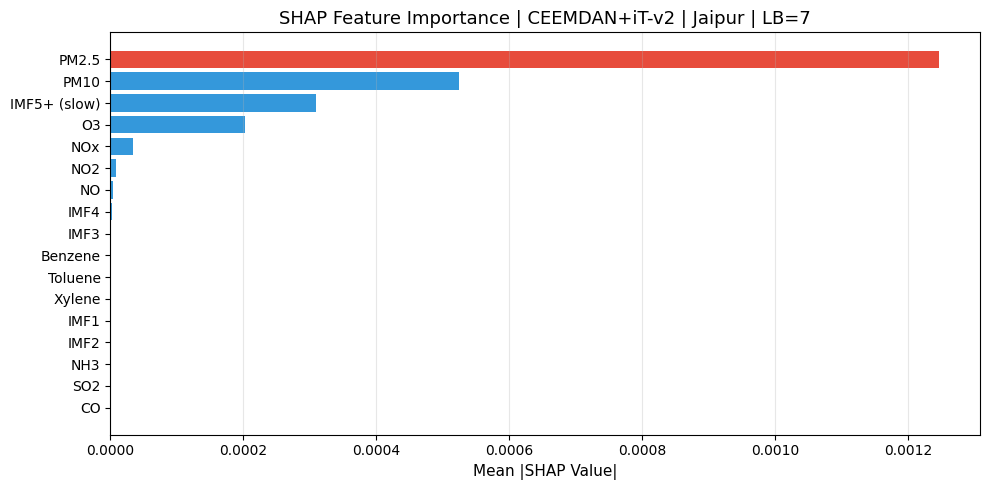

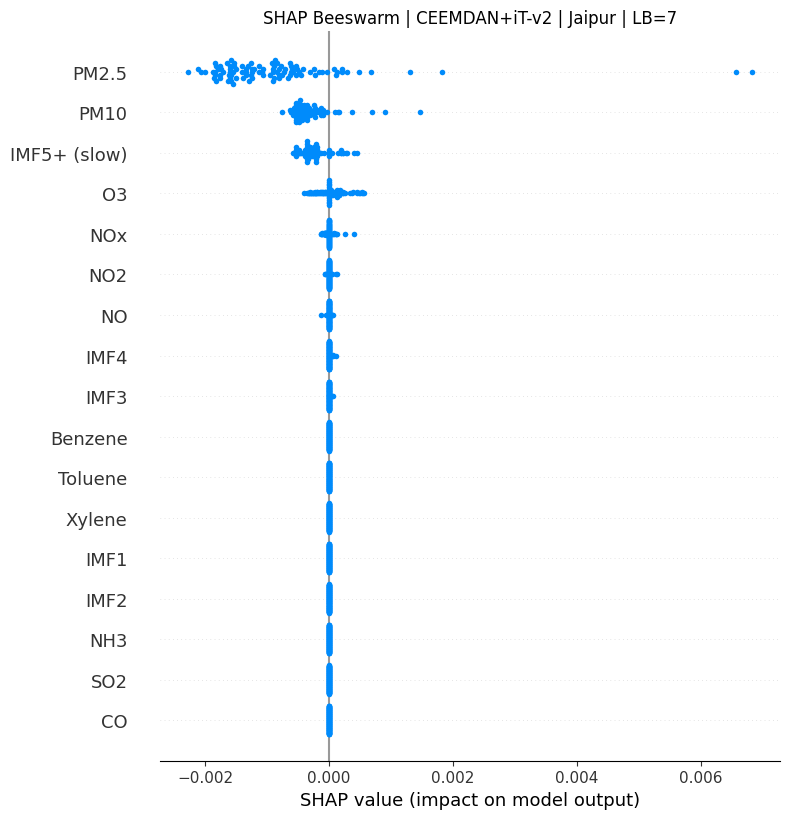

  Jaipur top drivers: PM2.5(0.0012), PM10(0.0005), IMF5+ (slow)(0.0003)
reused: ['Delhi (cache)', 'Mumbai (cache)', 'Bengaluru (cache)', 'Patna (cache)', 'Gurugram (cache)', 'Lucknow (cache)']
computed this session: 2
have results for 8/8 cities: ['Bengaluru', 'Delhi', 'Gurugram', 'Jaipur', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna']
All 8 cities done -- run the next cell for the clustered attribution figure.


In [ ]:
# ---- 8-city SHAP with per-city checkpointing (Editorial 3.1) ----
# Revision 1: the set comes from the D4 rule in code (cell above); lookback and sample sizes are Section 9's.
# Submitted: Ahmedabad and Talcher (fail D4), lookback 14 by hand. Step 6c: every city's result is the shared SHAP
# cache (shap_explain_city), so the focus cities computed in Section 9 are read back, not computed again. Section 14's
# own cache of mean values (shap8_cache, shap8_cache_r1) is no longer used.
SHAP8_CITIES   = list(D4_SHAP8_CITIES)
SHAP8_LOOKBACK = SHAP_LOOKBACK
SHAP8_NBG      = SHAP_N_BACKGROUND
SHAP8_NTEST    = SHAP_MAX_TEST
MAX_NEW_CITIES_THIS_SESSION = 3   # cap NEW cities per session (~5 h each); lower for the free tier

RUN_SHAP8 = True  # <-- set True to run; safe to re-run across sessions (skips cached cities)

if RUN_SHAP8:
    shap8_model_path = get_v2_model_path(SHAP8_LOOKBACK)
    assert shap8_model_path.exists(), (
        f"No trained model at {shap8_model_path}. Run the LB={SHAP8_LOOKBACK} training (Section 6) first."
    )
    shap8_trainer = CEEMDANFeatureTrainer.load(str(shap8_model_path), device=device)
    with open(get_v2_scalers_path(SHAP8_LOOKBACK), 'rb') as f:
        shap8_city_to_idx = pickle.load(f)['city_to_idx']

    city_shap8 = {}
    reused, newly_run = [], 0
    for city in SHAP8_CITIES:
        cached = shap_cache_path('v2', city, SHAP8_LOOKBACK, SHAP8_NTEST, SHAP8_NBG).exists()   # e.g. from Section 9
        if not cached and newly_run >= MAX_NEW_CITIES_THIS_SESSION:   # defer to next session
            continue
        if not cached:
            logger.info(f"\n=== 8-city SHAP: computing {city} (new) ===")
        mean_abs = run_shap_for_city(
            city, SHAP8_LOOKBACK, shap8_trainer, shap8_city_to_idx,
            n_background=SHAP8_NBG, max_test_samples=SHAP8_NTEST,
        )
        if mean_abs is not None:
            city_shap8[city] = np.asarray(mean_abs, dtype=float)
            if cached:
                reused.append(city + ' (cache)')
            else:
                newly_run += 1

    pending = [c for c in SHAP8_CITIES if c not in city_shap8]
    print(f"reused: {reused}")
    print(f"computed this session: {newly_run}")
    print(f"have results for {len(city_shap8)}/{len(SHAP8_CITIES)} cities: {sorted(city_shap8)}")
    if pending:
        print(f"PENDING (re-run this cell in a new session to continue): {pending}")
    else:
        print("All 8 cities done -- run the next cell for the clustered attribution figure.")
else:
    city_shap8 = {}
    print("RUN_SHAP8 is False -- set True and re-run.")


In [ ]:
print("REPORTS_DIR      :", REPORTS_DIR)
print("SHAP cache path  :", SHAP_CACHE_DIR.resolve())   # Revision 1, step 6c: the shared SHAP cache

REPORTS_DIR      : /content/drive/MyDrive/phase4_v2_results_r1/reports
SHAP cache path  : /content/drive/MyDrive/phase4_v2_results_r1/reports/shap/shap_cache_r1


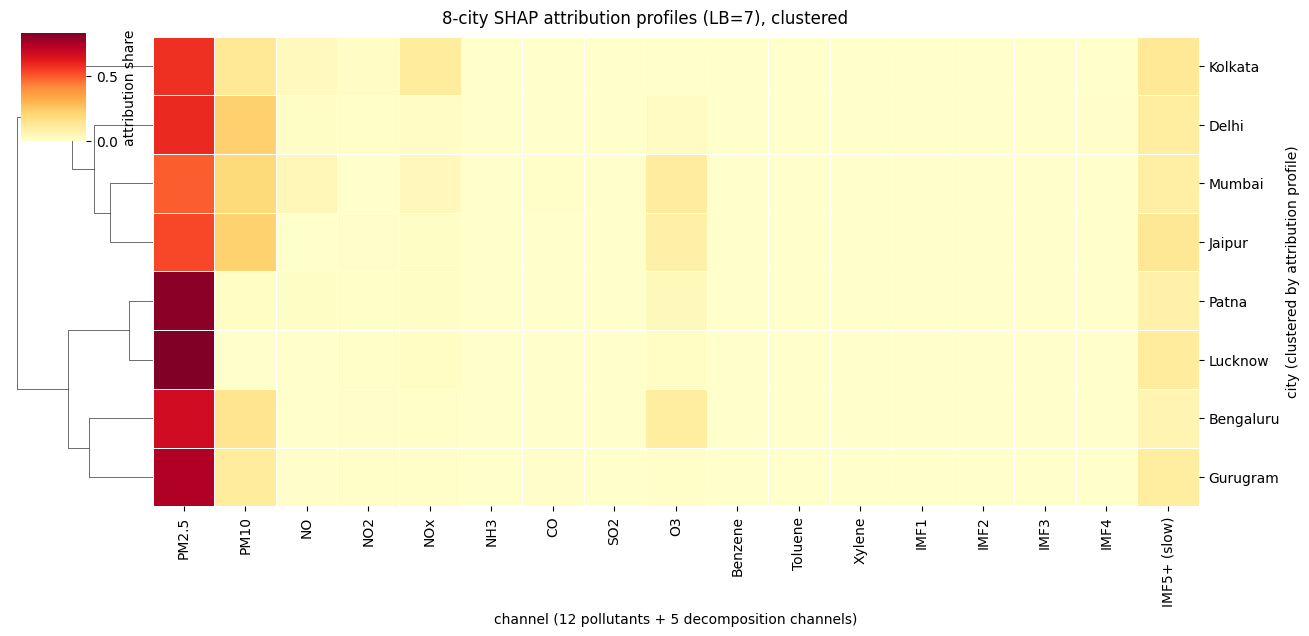


8-city SHAP summary | LB=7
------------------------------------------------------------------
  Delhi       IMF share =  11.0%   top: PM2.5(0.005), PM10(0.002), IMF5+ (slow)(0.001)
  Mumbai      IMF share =   9.3%   top: PM2.5(0.002), PM10(0.001), O3(0.000)
  Bengaluru   IMF share =   6.2%   top: PM2.5(0.001), PM10(0.000), O3(0.000)
  Patna       IMF share =   8.3%   top: PM2.5(0.006), IMF5+ (slow)(0.001), O3(0.000)
  Gurugram    IMF share =  10.7%   top: PM2.5(0.006), PM10(0.001), IMF5+ (slow)(0.001)
  Lucknow     IMF share =  11.5%   top: PM2.5(0.006), IMF5+ (slow)(0.001), NOx(0.000)
  Kolkata     IMF share =  12.9%   top: PM2.5(0.007), IMF5+ (slow)(0.001), PM10(0.001)
  Jaipur      IMF share =  13.4%   top: PM2.5(0.001), PM10(0.001), IMF5+ (slow)(0.000)

(IMF share across the 8 cities of the D4 attribution set.)


In [ ]:
# ---- 8-city clustered attribution matrix + summary (run once all 8 are cached) ----
import seaborn as sns

if len(city_shap8) >= 2:
    # cities x channels (pollutants, then the 5 decomposition channels)
    mat = pd.DataFrame(city_shap8, index=FEATURE_NAMES_V2).T
    mat = mat.loc[[c for c in SHAP8_CITIES if c in mat.index]]   # stable order

    # row-normalise to attribution SHARES so clustering reflects profile shape, not city magnitude
    mat_share = mat.div(mat.sum(axis=1), axis=0)

    # save the raw 8x18 attribution matrix
    matrix_csv = SHAP_REPORTS_DIR / f'shap8_attribution_matrix_lb{SHAP8_LOOKBACK}.csv'
    mat.to_csv(matrix_csv)
    logger.info(f"8-city attribution matrix saved to {matrix_csv}")

    # clustered heatmap: cluster CITIES by profile (rows), keep channel order fixed (cols)
    if len(city_shap8) >= 3:
        g = sns.clustermap(
            mat_share, cmap='YlOrRd', figsize=(13, 6),
            row_cluster=True, col_cluster=False, linewidths=0.4,
            cbar_kws={'label': 'attribution share'},
            dendrogram_ratio=(0.12, 0.0),
        )
        g.ax_heatmap.set_xlabel(f'channel ({len(FEATURE_COLUMNS)} pollutants + {len(IMF_LABELS)} decomposition channels)')
        g.ax_heatmap.set_ylabel('city (clustered by attribution profile)')
        g.fig.suptitle(f'8-city SHAP attribution profiles (LB={SHAP8_LOOKBACK}), clustered', y=1.02)
        fig_path = SHAP_PLOTS_DIR / f'shap8_clustered_lb{SHAP8_LOOKBACK}.png'
        g.savefig(fig_path, dpi=200, bbox_inches='tight')
        plt.show()
        logger.info(f"Clustered 8-city figure saved to {fig_path}")

    # per-city summary: top-3 channels + share of the decomposition channels
    print(f"\n8-city SHAP summary | LB={SHAP8_LOOKBACK}")
    print("-" * 66)
    summ = []
    for city in mat.index:
        vals = mat.loc[city].values
        top_idx = np.argsort(vals)[::-1][:3]
        top_str = ', '.join(f'{FEATURE_NAMES_V2[i]}({vals[i]:.3f})' for i in top_idx)
        imf_share = vals[len(FEATURE_COLUMNS):].sum() / vals.sum() * 100
        summ.append({'city': city, 'IMF_share_%': round(imf_share, 1), 'top3': top_str})
        print(f"  {city:<11} IMF share = {imf_share:5.1f}%   top: {top_str}")
    pd.DataFrame(summ).to_csv(SHAP_REPORTS_DIR / f'shap8_summary_lb{SHAP8_LOOKBACK}.csv', index=False)
    print(f"\n(IMF share across the {len(mat)} cities of the D4 attribution set.)")
else:
    print(f"Only {len(city_shap8)} city result(s) so far -- finish the sweep above first.")


## 15 -- Revision 1, Reviewer 3 comment R3.6: PM2.5 as the target (additional experiment)

The main model is trained with next-day **PM2.5** as the target instead of AQI. Everything else is the AQI pipeline:
the inputs are the 11 other pollutants and 5 channels decomposed causally from PM2.5's own history, with the same
daily calendar, fill, decomposition settings and city seeds, common-date split and city rule. Only the main model is
run (decision T2, 2 Oct 2026). Its accuracy is reported over the 5 model seeds, and its SHAP attribution for Delhi,
Mumbai and Bengaluru is added with the stratified SHAP sample (step 6 of the rebuild).

> **Runtime:** about 17.5 CPU-hours for the PM2.5 decompositions (saved per city, reused on rerun), then 6 trainings.

In [ ]:
# ── Revision 1, R3.6 (decision T2): PM2.5 as the target, an additional experiment ──
# Same pipeline as the AQI main model, only the target changes: next-day PM2.5 from the 11 other pollutants and 5
# channels decomposed causally from PM2.5's own history (raw PM2.5 is not an input, as raw AQI is not one in the
# main model). Same rules: D1 (the calendar's days are the days with a PM2.5 value, and targets are never filled),
# N1 fill, C5 decomposition with the same city seeds (C5_SEED_BASE + index in C5_ALL_CITIES), common-date split,
# one city rule. Cities: those with a PM2.5 training window (measured 2 Oct 2026: 17, the 18 AQI cities minus
# Jorapokhar). Decided 2 Oct 2026: main model only, in this section of the same run,
# 5 model seeds.
# Cost: about 17.5 CPU-hours of decomposition (19,636 city-days), saved per city in its own cache folder.
RUN_PM25 = True
PM25_TARGET = 'PM2.5'
PM25_FEATURES = [c for c in FEATURE_COLUMNS if c != PM25_TARGET]   # the 11 other pollutants
PM25_LOOKBACK = SHAP_LOOKBACK   # the main AQI attribution lookback (R3.6 T2); step 6 sets it by validation
PM25_TAG = '_pm25'
C5_CACHE_DIR_PM25 = MODELS_DIR / 'c5_decompositions_pm25'

if RUN_PM25:
    df_pm25 = load_clean_data(DATA_FILE, target_col=PM25_TARGET)
    C5_DECOMP_PM25 = c5_decompose_all(df_pm25, PM25_FEATURES, PM25_TARGET, C5_CACHE_DIR_PM25)
else:
    print("RUN_PM25 is False -- skipping the PM2.5 check.")


In [ ]:
# ── Revision 1, R3.6 (T2): PM2.5 main model, accuracy over the 5 model seeds ──
# The RANDOM_SEED model is trained and saved as in Section 6, with its dataset (N2), for the PM2.5 SHAP. Then the
# 5 model seeds of Section 13 train on the same dataset (decomposition fixed, only the model seed varies), so the
# PM2.5 accuracy is reported as mean +/- s.d. like the AQI main model.
PM25_METRICS_CSV = REPORTS_DIR / f'v2{PM25_TAG}_metrics_lb{PM25_LOOKBACK}.csv'
PM25_MULTISEED_CSV = REPORTS_DIR / f'multiseed{PM25_TAG}_lb{PM25_LOOKBACK}.csv'

if RUN_PM25:
    res_pm25 = train_one_lookback_v2(PM25_LOOKBACK, df_pm25, feature_cols=PM25_FEATURES, target_col=PM25_TARGET,
                                     decompositions=C5_DECOMP_PM25, tag=PM25_TAG,
                                     conditioning=MAIN_CONDITIONING)   # R1.16: the main model's city term
    pd.DataFrame([res_pm25]).to_csv(PM25_METRICS_CSV, index=False)
    print(res_pm25)

    set_all_seeds(CEEMDAN_FIXED_SEED)
    pm25_data = build_augmented_dataset(df_pm25, PM25_FEATURES, PM25_TARGET, seq_len=PM25_LOOKBACK,
                                        decompositions=C5_DECOMP_PM25)
    df_multiseed_pm25 = pd.DataFrame([train_v2_on_data(pm25_data, s, PM25_LOOKBACK, MAIN_CONDITIONING, run='ms_v2_pm25')
                                      for s in SEEDS])
    df_multiseed_pm25['model'] = res_pm25['model']
    df_multiseed_pm25.to_csv(PM25_MULTISEED_CSV, index=False)
    print(df_multiseed_pm25.to_string(index=False))
    print(f"\nPM2.5, {len(SEEDS)} model seeds {SEEDS}, lookback {PM25_LOOKBACK}: mean +/- s.d. (ddof=1)")
    for m in ['r2', 'rmse', 'mae', 'mape'] + [c for c in R110_COLUMNS if not c.startswith('n_')]:   # R1.9-4
        print(f"  {m}: {df_multiseed_pm25[m].mean():.3f} +/- {df_multiseed_pm25[m].std(ddof=1):.3f}")
else:
    print("RUN_PM25 is False -- skipping the PM2.5 check.")


{'model': 'CEEMDAN+iTransformer-v2 (PM2.5)', 'lookback': 7, 'n_cities': 17, 'train_time_s': 824.38, 'r2': 0.800184, 'rmse': np.float64(20.9747), 'mae': 12.5131, 'mape': np.float32(36.4613), 'val_r2': 0.694875, 'val_rmse': np.float64(15.8705), 'val_mae': 10.379, 'val_mape': np.float32(24.9806), 'n_pre': 4411, 'r2_pre': 0.7956327782303433, 'rmse_pre': 23.392979132479734, 'mae_pre': 14.01902149918837, 'mape_pre': 36.86870267605358, 'n_lock': 1590, 'r2_lock': 0.5603060760355933, 'rmse_lock': 11.928114657767782, 'mae_lock': 8.335537880621617, 'mape_lock': 35.33101945828291}
[CEEMDAN+iTransformer-v2 (seed=42)] RMSE=21.8285  MAE=13.3318  MAPE=40.37%  R2=0.7836
[CEEMDAN+iTransformer-v2 (seed=123)] RMSE=20.9747  MAE=12.5131  MAPE=36.46%  R2=0.8002
[CEEMDAN+iTransformer-v2 (seed=2024)] RMSE=21.6220  MAE=13.5660  MAPE=48.82%  R2=0.7877
[CEEMDAN+iTransformer-v2 (seed=7)] RMSE=22.1996  MAE=13.3593  MAPE=43.59%  R2=0.7762
[CEEMDAN+iTransformer-v2 (seed=2025)] RMSE=21.6099  MAE=12.8292  MAPE=40.60%  


SHAP Analysis | CEEMDAN+iTransformer v2, PM2.5 target | LB=7


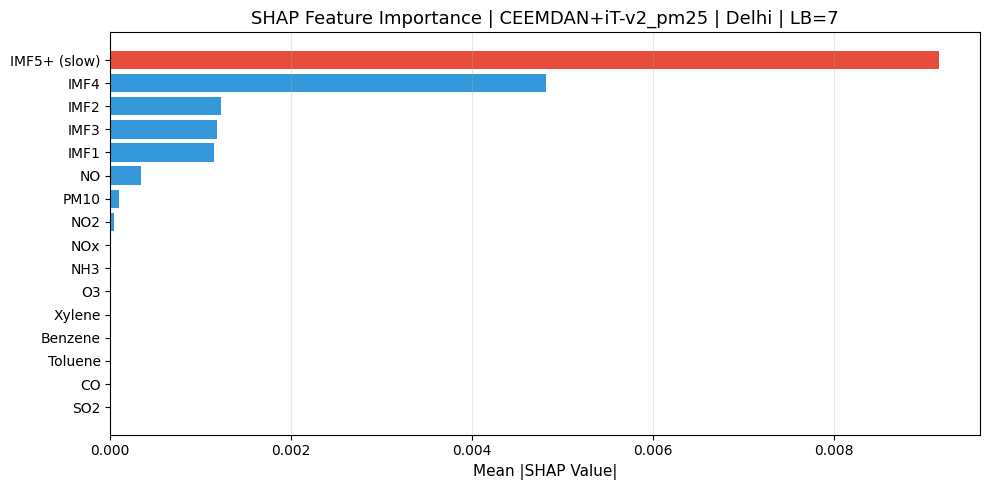

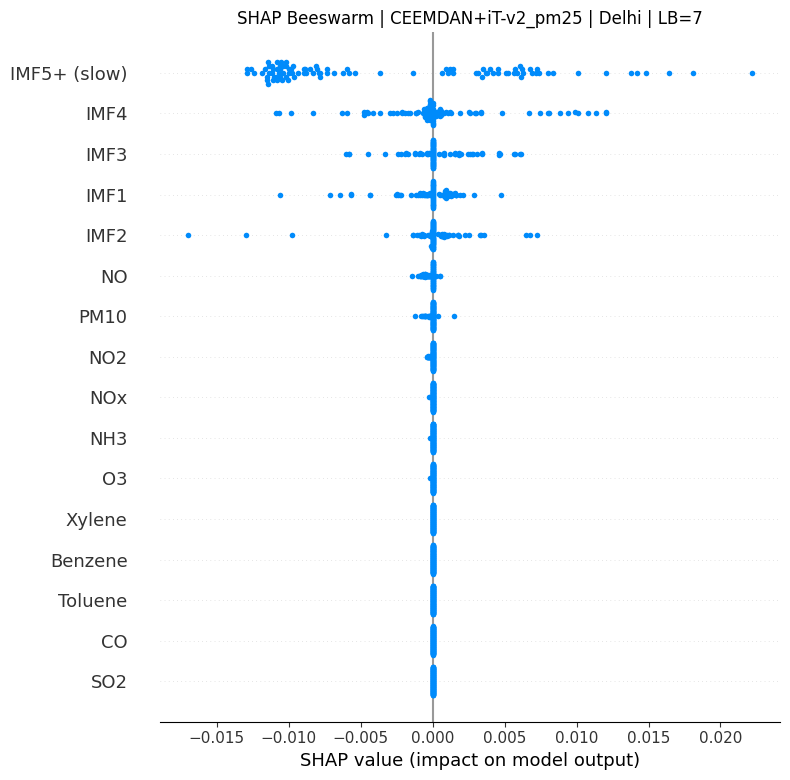

  Delhi top drivers: IMF5+ (slow)(0.0092), IMF4(0.0048), IMF2(0.0012)


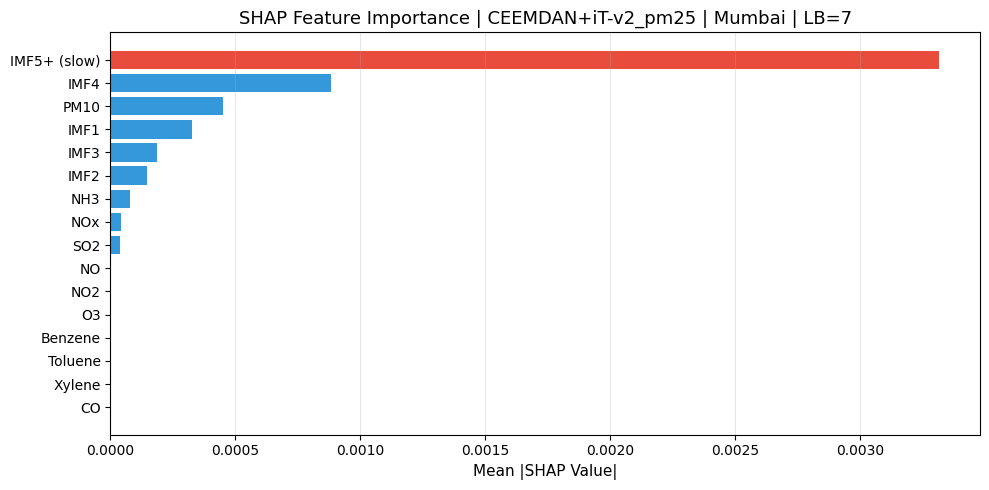

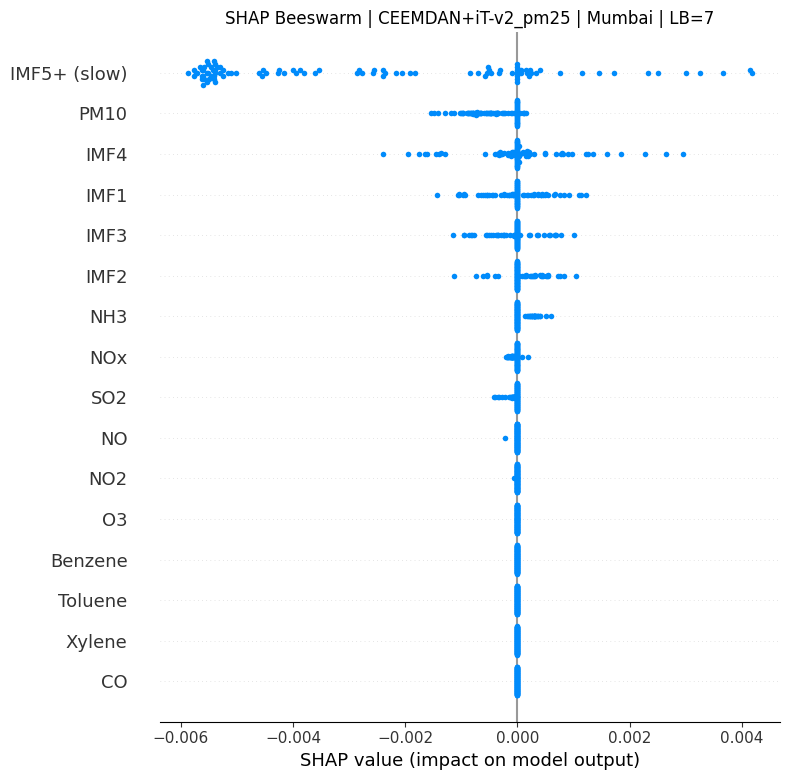

  Mumbai top drivers: IMF5+ (slow)(0.0033), IMF4(0.0009), PM10(0.0005)


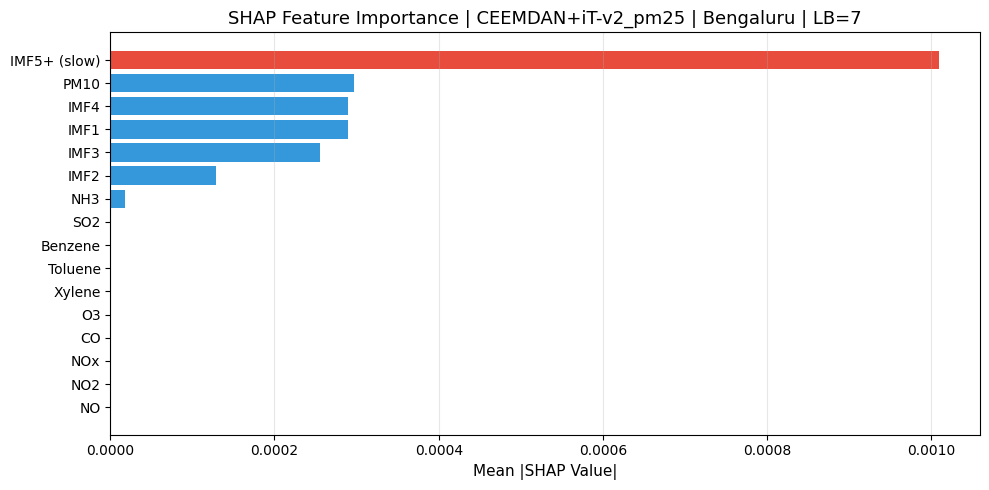

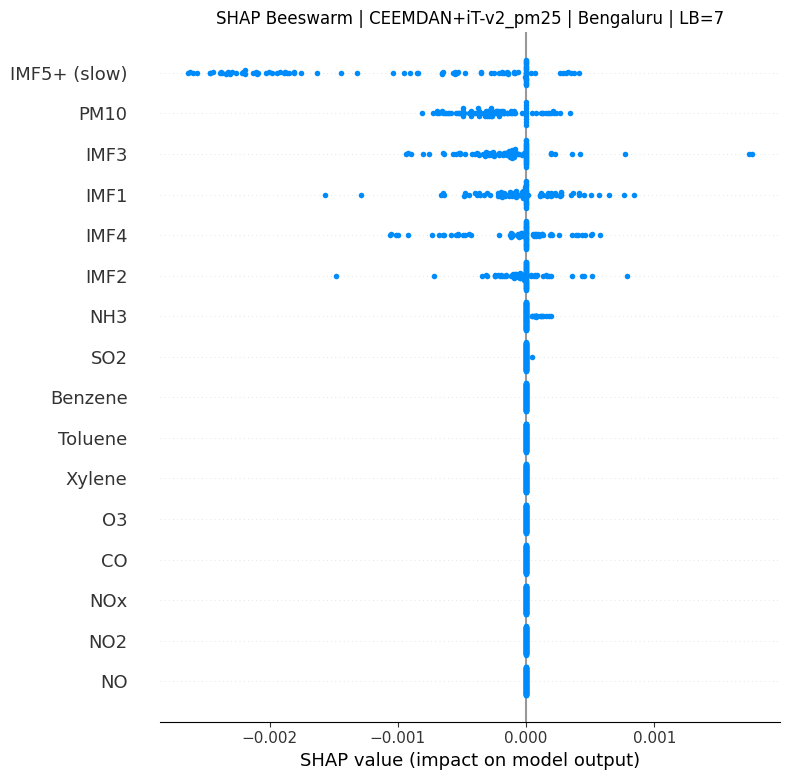

  Bengaluru top drivers: IMF5+ (slow)(0.0010), PM10(0.0003), IMF4(0.0003)

PM2.5 vs AQI attribution, LB=7: decomposition-channel share and top 3 channels
     city  imf_share_pm25_pct                top3_pm25  imf_share_aqi_pct                  top3_aqi
    Delhi                97.3 IMF5+ (slow), IMF4, IMF2               11.0 PM2.5, PM10, IMF5+ (slow)
   Mumbai                88.7 IMF5+ (slow), IMF4, PM10                9.3           PM2.5, PM10, O3
Bengaluru                86.2 IMF5+ (slow), PM10, IMF4                6.2           PM2.5, PM10, O3

Written: shap_v2_pm25_attribution_lb7.csv, shap_v2_pm25_vs_aqi_lb7.csv, shap_periods_v2_pm25_lb7.csv


In [ ]:
# ── Revision 1, R3.6 (T2): PM2.5 attribution for Delhi, Mumbai and Bengaluru ──
# The seed-123 PM2.5 model (saved above with its dataset, N2) at the AQI attribution lookback, explained on the same
# sampled test and background target dates as the AQI SHAP (R1.13, step 6c). Dates without a PM2.5 window are counted.
# Outputs (decided 3 Oct 2026): the attribution table, the per-period summary, and beside the AQI
# attribution (Section 9) each city's decomposition-channel share and top 3 channels, as in Section 11. No rank
# statistic between the AQI and PM2.5 rankings was decided (their pollutant sets differ: 11 against 12).
RUN_PM25_SHAP = True
FEATURE_NAMES_PM25 = list(PM25_FEATURES) + IMF_LABELS   # 16 total

if RUN_PM25 and RUN_PM25_SHAP:
    pm25_shap_trainer = CEEMDANFeatureTrainer.load(str(get_v2_model_path(PM25_LOOKBACK, PM25_TAG)), device=device)
    with open(get_v2_scalers_path(PM25_LOOKBACK, PM25_TAG), 'rb') as f:
        pm25_city_to_idx = pickle.load(f)['city_to_idx']

    print(f"\nSHAP Analysis | CEEMDAN+iTransformer v2, PM2.5 target | LB={PM25_LOOKBACK}")
    print("=" * 60)
    city_shap_pm25 = {}
    for city in SHAP_CITIES:
        try:
            mean_abs = run_shap_for_city(
                city, PM25_LOOKBACK, pm25_shap_trainer, pm25_city_to_idx,
                n_background=SHAP_N_BACKGROUND, max_test_samples=SHAP_MAX_TEST,
                tag=PM25_TAG, feature_names=FEATURE_NAMES_PM25,
            )
        except Exception as exc:
            import traceback as _tb
            logger.error(f"  {city}: unhandled exception -- {exc}")
            logger.error(_tb.format_exc())
            mean_abs = None
        if mean_abs is not None:
            city_shap_pm25[city] = mean_abs

    if city_shap_pm25:
        attr_path_pm25 = SHAP_REPORTS_DIR / f'shap_v2{PM25_TAG}_attribution_lb{PM25_LOOKBACK}.csv'
        rows = [[city] + [f'{v:.6f}' for v in vals] for city, vals in city_shap_pm25.items()]
        pd.DataFrame(rows, columns=['city'] + FEATURE_NAMES_PM25).to_csv(attr_path_pm25, index=False)

        comparison_rows = []
        for city, vals in city_shap_pm25.items():
            row = {'city': city,
                   'imf_share_pm25_pct': round(vals[len(PM25_FEATURES):].sum() / vals.sum() * 100, 1),
                   'top3_pm25': ', '.join(FEATURE_NAMES_PM25[i] for i in np.argsort(vals)[::-1][:3])}
            if city in city_shap:   # Section 9, AQI at the same lookback (PM25_LOOKBACK is set to SHAP_LOOKBACK)
                vals_aqi = city_shap[city]
                row.update({'imf_share_aqi_pct': round(vals_aqi[len(FEATURE_COLUMNS):].sum() / vals_aqi.sum() * 100, 1),
                            'top3_aqi': ', '.join(FEATURE_NAMES_V2[i] for i in np.argsort(vals_aqi)[::-1][:3])})
            comparison_rows.append(row)
        df_pm25_vs_aqi = pd.DataFrame(comparison_rows)
        pm25_vs_aqi_csv = SHAP_REPORTS_DIR / f'shap_v2{PM25_TAG}_vs_aqi_lb{PM25_LOOKBACK}.csv'
        df_pm25_vs_aqi.to_csv(pm25_vs_aqi_csv, index=False)
        print(f"\nPM2.5 vs AQI attribution, LB={PM25_LOOKBACK}: decomposition-channel share and top 3 channels")
        print(df_pm25_vs_aqi.to_string(index=False))
        print(f"\nWritten: {attr_path_pm25.name}, {pm25_vs_aqi_csv.name}, shap_periods_v2{PM25_TAG}_lb{PM25_LOOKBACK}.csv")
    else:
        print("No PM2.5 SHAP result -- see the errors above.")
else:
    city_shap_pm25 = {}
    print("RUN_PM25 or RUN_PM25_SHAP is False -- skipping the PM2.5 attribution.")


## 16 -- Reviewer 3 comment R3.3 (decision D3): S2, does the window construction change accuracy?

Accuracy-only sensitivity arms (decided 30 Sep and 3 Oct 2026). The main model is retrained with only the window
construction changed:

- **D1(b)**, the main pipeline: a daily calendar with gaps of at most 3 days filled from the last observed day (the Section 6 and 8b runs, not retrained).
- **D1(a)**, exclude: nothing filled, so every input day and target is observed.
- **Observation steps**, the submitted procedure: L consecutive observed rows, whatever calendar gaps lie between them.

D1(a) and observation steps share one extra causal decomposition of the observed days only (about 17.5 CPU-hours, cached per city). Each arm is scored on its own test windows and on the test targets all three arms share, pooled, per city and with the five D4-flagged cities pooled separately.

In [ ]:
# ── Revision 1, R3.3 D3 S2 (step 6e): causal decomposition of the observed days only (I-6) ──
# Shared by the D1(a) and observation-steps arms: the same C5 settings and city seeds as the main run, on a calendar
# with nothing filled (max_fill_days=0), saved per city in its own cache folder.
# Measured 3 Oct 2026: 19,585 city-days for the 18 modelled cities, about 17.5 CPU-hours (main run: 20,070).
RUN_S2 = True
C5_CACHE_DIR_OBS = MODELS_DIR / 'c5_decompositions_observed'

if RUN_S2:
    C5_DECOMP_OBS = c5_decompose_all(df, FEATURE_COLUMNS, TARGET_COLUMN, C5_CACHE_DIR_OBS, max_fill_days=0)
else:
    print("RUN_S2 is False -- skipping the S2 sensitivity arms.")


In [ ]:
# ── Revision 1, R3.3 D3 S2 (step 6e): does the window construction change accuracy? ──
# Arms (S2 helper cell): D1(b) the main pipeline, D1(a) exclude, observation steps (the submitted procedure). Every
# arm uses the main model with the scalar-bias city term, as the Section 6 runs do. Accuracy only. Decided 30 Sep and
# 3 Oct 2026 (D3 and S2 details):
#   D1(b)  nothing retrained: Section 6's saved runs (seed RANDOM_SEED) at the other lookbacks, and Section 8b's
#          scalar-bias seeds R116_SEEDS at MAIN_LOOKBACK (their test predictions are saved by Section 8b)
#   D1(a), steps  seed RANDOM_SEED at every lookback (saved with the tags _s2d1a and _s2steps), and the other seeds of
#          R116_SEEDS at MAIN_LOOKBACK: 16 trainings
# Every run is scored on its own test windows and on the test targets (city, date) that all three arms share at that
# lookback; the observed AQI on a shared target must be the same in every arm. Per city at seed RANDOM_SEED, with
# the five D4-flagged cities marked and pooled separately. Period columns as in R1.9-4.
S2_NEW_ARMS = ('d1a', 'steps')
S2_TAGS = {'d1a': '_s2d1a', 'steps': '_s2steps'}
S2_RUNS_CSV = REPORTS_DIR / 's2_runs.csv'
S2_CITY_CSV = REPORTS_DIR / 's2_city.csv'
S2_SUMMARY_CSV = REPORTS_DIR / f's2_summary_lb{MAIN_LOOKBACK}.csv'


def s2_saved_run(dataset_path, scalers_path):
    '''Test targets and predictions (AQI units), city and target date of each test window of a saved model (N2).'''
    with open(scalers_path, 'rb') as f:
        scaler_y = pickle.load(f)['scaler_y']
    with np.load(dataset_path, allow_pickle=False) as z:
        cities = np.array([str(c) for c in z['valid_cities']])
        return {'y': scaler_y.inverse_transform(z['y_test'].reshape(-1, 1)).ravel(),
                'p': scaler_y.inverse_transform(z['y_pred_test_sc'].reshape(-1, 1)).ravel(),
                'city': cities[z['city_test']], 'dates': z['test_dates']}


def s2_keys(run):
    '''One key per test window: "city|target date".'''
    return np.char.add(np.char.add(run['city'].astype(str), '|'), run['dates'].astype(str))


def s2_scores(run, m):
    '''Metrics and period columns of the selected test windows.'''
    return {**r110_metrics(run['y'][m], run['p'][m]), **r110_period_columns(run['y'][m], run['p'][m], run['dates'][m])}


def s2_common_targets(runs):
    '''Per lookback, the test targets (city|date) that all three arms have (from the seed RANDOM_SEED runs).'''
    return {L: np.array(sorted(set.intersection(*[set(s2_keys(runs[(a, L, RANDOM_SEED)])) for a in S2_ARMS])))
            for L in sorted({L for (_, L, _) in runs})}


def s2_tables(runs, common, flagged):
    '''Run rows (own and shared test targets) and city rows (seed RANDOM_SEED, D4-flagged cities pooled apart).
    Raises if an arm has other observed AQI than D1(b) on a shared target.'''
    run_rows, city_rows = [], []
    for (arm, L, s), run in runs.items():
        keys = s2_keys(run)
        shared = np.isin(keys, common[L])
        ref = runs[('d1b', L, RANDOM_SEED)]
        ref_y = dict(zip(s2_keys(ref), ref['y']))
        if not np.allclose(run['y'][shared], [ref_y[k] for k in keys[shared]], rtol=1e-5, atol=1e-2):
            raise ValueError(f'S2: {arm} at LB={L} has other observed AQI than D1(b) on shared test targets')
        run_rows.append({'arm': arm, 'lookback': L, 'seed': s, **s2_scores(run, np.ones(len(keys), dtype=bool)),
                         **{f'common_{k}': v for k, v in s2_scores(run, shared).items()}})
        if s == RANDOM_SEED:
            in_flagged = np.isin(run['city'], flagged)
            for name, m in ([(c, run['city'] == c) for c in sorted(set(run['city']))]
                            + [('D4-flagged cities', in_flagged), ('other cities', ~in_flagged)]):
                city_rows.append({'arm': arm, 'lookback': L, 'city': name, 'd4_flagged': name in flagged,
                                  **r110_metrics(run['y'][m], run['p'][m]),
                                  **{f'common_{k}': v for k, v in
                                     r110_metrics(run['y'][m & shared], run['p'][m & shared]).items()}})
    return (pd.DataFrame(run_rows).sort_values(['lookback', 'arm', 'seed']).reset_index(drop=True),
            pd.DataFrame(city_rows).sort_values(['lookback', 'arm', 'city']).reset_index(drop=True))


if RUN_S2:
    if not (globals().get('RUN_R116') and R116_PRED_NPZ.exists()):
        raise ValueError(f'S2: the D1(b) seeds at LB={MAIN_LOOKBACK} come from Section 8b, run it first '
                         f'({R116_PRED_NPZ.name} missing)')
    s2_runs = {}   # (arm, lookback, seed) -> run
    with np.load(R116_PRED_NPZ, allow_pickle=False) as z:
        cities = np.array([str(c) for c in z['valid_cities']])
        for s in R116_SEEDS:
            s2_runs[('d1b', MAIN_LOOKBACK, s)] = {'y': z['y_test'], 'p': z[f'pred__bias__{s}'],
                                                  'city': cities[z['city_test']], 'dates': z['test_dates']}
    for L in LOOKBACK_PERIODS_V2:
        if L != MAIN_LOOKBACK:   # Section 6, scalar bias (only MAIN_LOOKBACK's file may hold a (iii) model, R1.16)
            s2_runs[('d1b', L, RANDOM_SEED)] = s2_saved_run(get_v2_dataset_path(L), get_v2_scalers_path(L))

    for arm in S2_NEW_ARMS:
        for L in LOOKBACK_PERIODS_V2:
            train_one_lookback_v2(L, df, decompositions=C5_DECOMP_OBS, tag=S2_TAGS[arm], gap_arm=arm)
            s2_runs[(arm, L, RANDOM_SEED)] = s2_saved_run(get_v2_dataset_path(L, S2_TAGS[arm]),
                                                          get_v2_scalers_path(L, S2_TAGS[arm]))
        set_all_seeds(RANDOM_SEED)
        s2_data = build_augmented_dataset(df, FEATURE_COLUMNS, TARGET_COLUMN, seq_len=MAIN_LOOKBACK,
                                          decompositions=C5_DECOMP_OBS, gap_arm=arm)
        names = np.array(s2_data['valid_cities'])
        for s in R116_SEEDS:
            if s != RANDOM_SEED:   # same settings as train_v2_on_data (Section 8b, r116_fit)
                y, p, cid = r116_raw(r116_fit(s2_data, 'bias', s, MAIN_LOOKBACK, run=f's2{arm}'), s2_data, 'test')
                s2_runs[(arm, MAIN_LOOKBACK, s)] = {'y': y, 'p': p, 'city': names[cid], 'dates': s2_data['test_dates']}

    s2_common = s2_common_targets(s2_runs)
    s2_flagged = sorted(df_d4.loc[~df_d4['passes'], 'city'])   # D4 (R3.3)
    df_s2_runs, df_s2_city = s2_tables(s2_runs, s2_common, s2_flagged)
    df_s2_runs.to_csv(S2_RUNS_CSV, index=False)
    df_s2_city.to_csv(S2_CITY_CSV, index=False)

    summary_rows = []
    for arm in S2_ARMS:   # MAIN_LOOKBACK: mean +/- s.d. over the seeds (ddof=1)
        g = df_s2_runs[(df_s2_runs['arm'] == arm) & (df_s2_runs['lookback'] == MAIN_LOOKBACK)]
        row = {'arm': arm, 'n_seeds': len(g), 'n': int(g['n'].iloc[0]), 'common_n': int(g['common_n'].iloc[0])}
        for m in ('r2', 'rmse', 'mae', 'mape', 'common_r2', 'common_rmse', 'common_mae', 'common_mape'):
            row[f'mean_{m}'], row[f'std_{m}'] = float(g[m].mean()), float(g[m].std(ddof=1))
        summary_rows.append(row)
    df_s2_summary = pd.DataFrame(summary_rows)
    df_s2_summary.to_csv(S2_SUMMARY_CSV, index=False)

    print(f"S2 at LB={MAIN_LOOKBACK}, mean +/- s.d. over seeds {list(R116_SEEDS)}: own test windows, then the "
          f"{len(s2_common[MAIN_LOOKBACK])} shared test targets")
    for r in summary_rows:
        print(f"  {r['arm']:5s} own n={r['n']}: R2 {r['mean_r2']:.3f} +/- {r['std_r2']:.3f}, MAE {r['mean_mae']:.2f} "
              f"+/- {r['std_mae']:.2f} | shared: R2 {r['mean_common_r2']:.3f} +/- {r['std_common_r2']:.3f}, "
              f"MAE {r['mean_common_mae']:.2f} +/- {r['std_common_mae']:.2f}")
    print(df_s2_runs[df_s2_runs['seed'] == RANDOM_SEED][['lookback', 'arm', 'n', 'r2', 'mae', 'common_n', 'common_r2',
                                                         'common_mae']].round(4).to_string(index=False))
    print(f"\nWritten: {S2_RUNS_CSV.name}, {S2_CITY_CSV.name}, {S2_SUMMARY_CSV.name}")
else:
    print("RUN_S2 is False -- skipping the S2 sensitivity arms.")


S2 at LB=7, mean +/- s.d. over seeds [42, 123, 2024, 7, 2025]: own test windows, then the 5828 shared test targets
  d1b   own n=6171: R2 0.791 +/- 0.024, MAE 32.69 +/- 3.50 | shared: R2 0.800 +/- 0.026, MAE 31.76 +/- 3.56
  d1a   own n=5828: R2 0.803 +/- 0.015, MAE 31.43 +/- 3.17 | shared: R2 0.803 +/- 0.015, MAE 31.43 +/- 3.17
  steps own n=6310: R2 0.795 +/- 0.020, MAE 32.04 +/- 3.23 | shared: R2 0.804 +/- 0.019, MAE 30.86 +/- 3.24
 lookback   arm    n     r2     mae  common_n  common_r2  common_mae
        7   d1a 5828 0.8149 28.7531      5828     0.8149     28.7531
        7   d1b 6171 0.7963 33.4633      5828     0.8051     32.5981
        7 steps 6310 0.8176 27.9200      5828     0.8275     26.7805
       14   d1a 5449 0.8057 29.6295      5449     0.8057     29.6295
       14   d1b 6040 0.7996 30.6438      5449     0.8224     28.2770
       14 steps 6310 0.7851 34.0206      5449     0.8009     32.1542
       21   d1a 5143 0.8121 26.5135      5143     0.8121     26.5135
       21

## 17 -- Reviewer 1 comment R1.1 (decision R1.1-7): does the decomposition seed change the results?

Every other result uses one decomposition seed base (123) and varies only the model seed (Section 13). Here the whole causal decomposition is repeated with the seed base 42 (about 18 CPU-hours, cached per city), and the main model is retrained on it at the main lookback with model seed 123 and the main model's city term:

- **Accuracy:** both models on the same test windows, with the difference set against the spread of the main model over its 5 model seeds (Section 13).
- **Attribution:** KernelSHAP for Delhi, Mumbai and Bengaluru on Section 9's sampled dates. Per city and period: Spearman rho over all inputs and over the pollutants, the top-3 and top-5 inputs, and each decomposition channel's share of the attribution under each seed.

In [ ]:
# ── Revision 1, R1.1-7 (option C, step 6f): causal decomposition with a second seed base ──
# The same C5 settings, calendar (D1(b)) and days as the main run (Section 4). Only the city seeds differ:
# R117_SEED_BASE + the city's index in C5_ALL_CITIES. Saved per city in its own cache folder.
# Decided 3 Oct 2026 (decision R1.1-7): seed base 42.
# Cost: 20,070 city-days for the 18 modelled cities, about 18 CPU-hours.
RUN_R117 = True
R117_SEED_BASE = 42
C5_CACHE_DIR_SEED2 = MODELS_DIR / f'c5_decompositions_seed{R117_SEED_BASE}'

if RUN_R117:
    C5_DECOMP_SEED2 = c5_decompose_all(df, FEATURE_COLUMNS, TARGET_COLUMN, C5_CACHE_DIR_SEED2, seed_base=R117_SEED_BASE)
    if list(C5_DECOMP_SEED2) != list(C5_DECOMP) or any(
            not np.array_equal(C5_DECOMP_SEED2[c]['days'], C5_DECOMP[c]['days']) for c in C5_DECOMP):
        raise ValueError('R1.1-7: the second decomposition covers other cities or days than the main one')
else:
    print("RUN_R117 is False -- skipping the decomposition-seed check.")


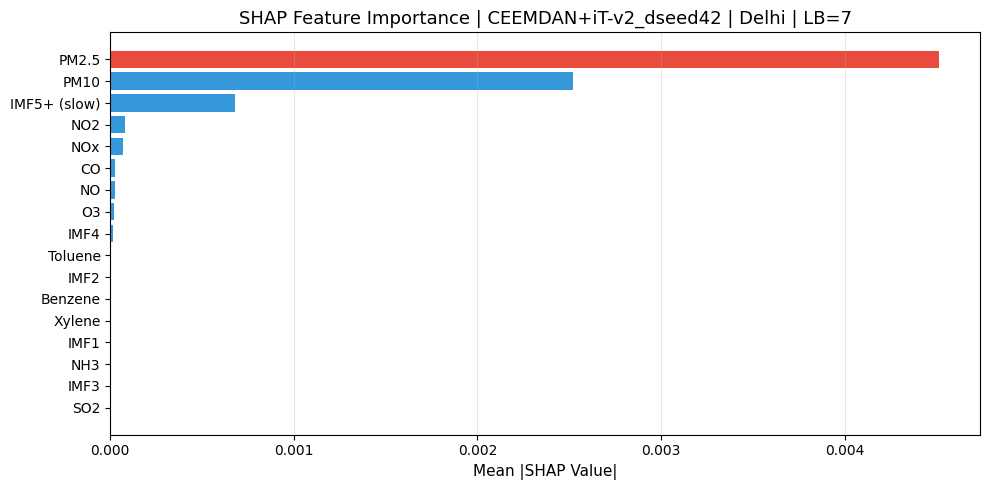

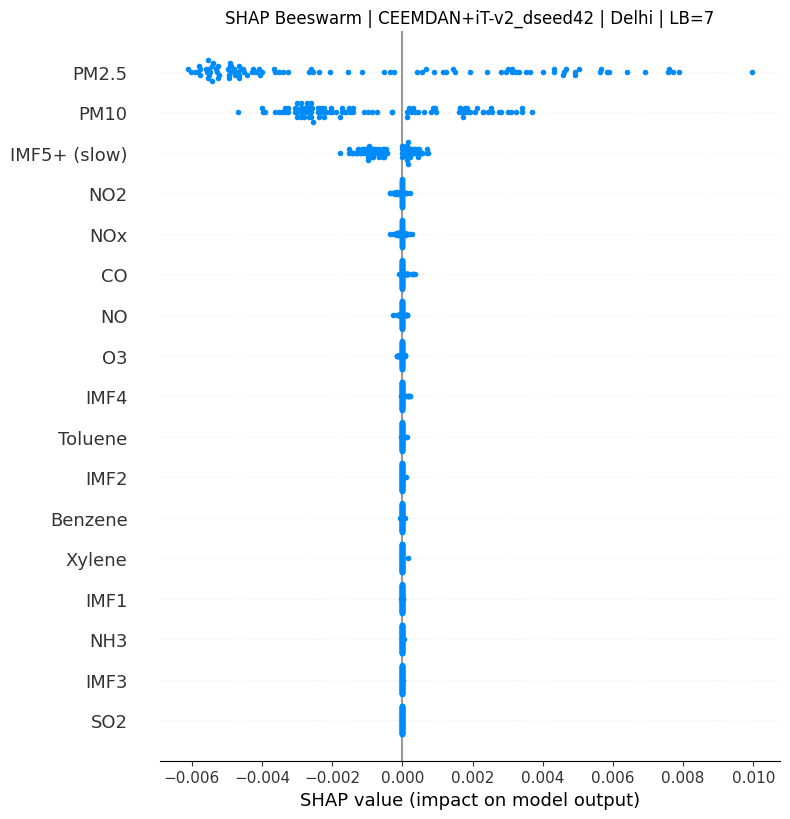

  Delhi top drivers: PM2.5(0.0045), PM10(0.0025), IMF5+ (slow)(0.0007)


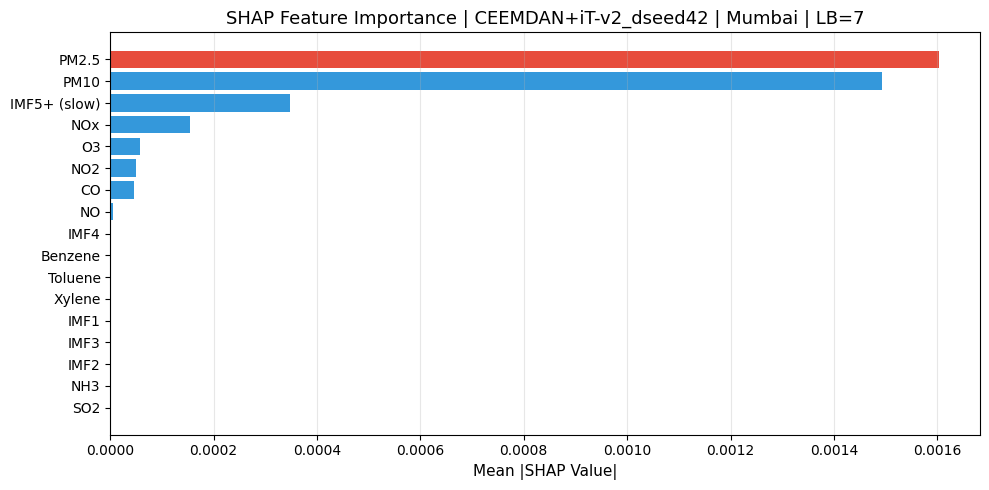

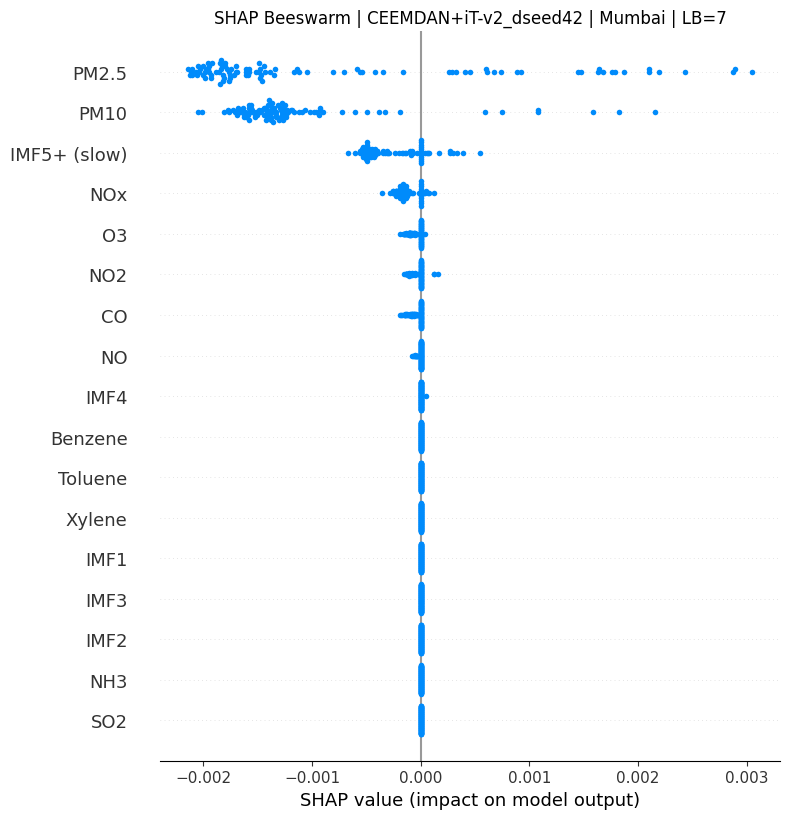

  Mumbai top drivers: PM2.5(0.0016), PM10(0.0015), IMF5+ (slow)(0.0003)


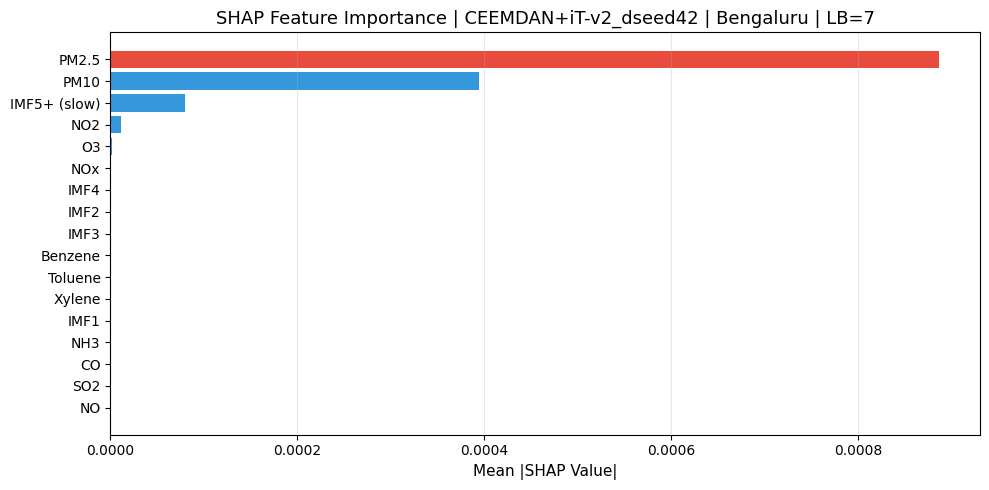

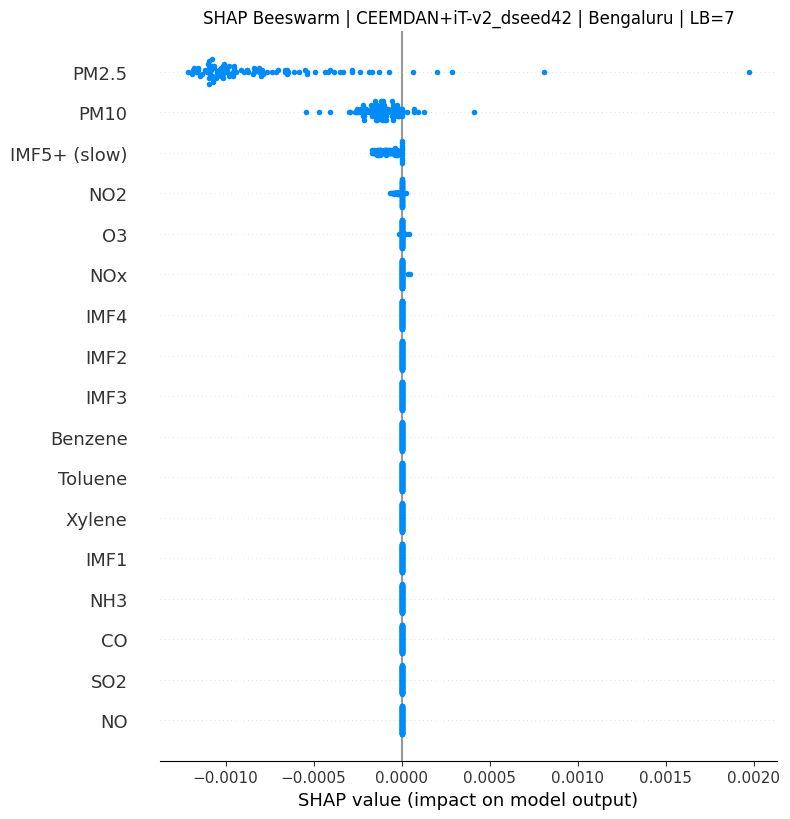

  Bengaluru top drivers: PM2.5(0.0009), PM10(0.0004), IMF5+ (slow)(0.0001)
R1.1-7 at LB=7 (bias, model seed 123): decomposition seed base 123 (main) against 42, on the same 6171 test windows; spread over the main model's model seeds [7, 42, 123, 2024, 2025]
   metric    n  main_dseed123  dseed42  difference  model_seeds_n  model_seeds_mean  model_seeds_sd  model_seeds_min  model_seeds_max  within_model_seed_range  difference_in_model_seed_sd
       r2 6171         0.7963   0.8071      0.0108              5            0.7914          0.0244           0.7547           0.8131                     True                       0.4432
     rmse 6171        50.8215  49.4529     -1.3686              5           51.3597          2.9715          48.6801          55.7660                     True                      -0.4606
      mae 6171        33.4633  30.0716     -3.3917              5           32.6931          3.5043          28.3768          37.3158                     True                    

In [ ]:
# ── Revision 1, R1.1-7 (option C, step 6f): do accuracy and attribution depend on the decomposition seed? ──
# Decided 2 and 3 Oct 2026 (decision R1.1-7):
#   Accuracy  the main model (city term MAIN_CONDITIONING, model seed RANDOM_SEED) retrained at MAIN_LOOKBACK on the
#             second decomposition (files tagged R117_TAG), compared with the main model on the same test windows:
#             test metrics and period columns of both, their difference, and the main model's 5 model seeds
#             (Section 13) as the spread to read it against (inside their range, and the difference in s.d. units).
#   SHAP      KernelSHAP for SHAP_CITIES on the same sampled dates as Section 9, compared per city and period
#             (6c summaries): Spearman rho and p over all inputs and over the pollutants, top-3 and top-5 inputs,
#             each decomposition channel's share of the total mean |SHAP| and the total channel share under each
#             seed, and their differences. No rank statistic over the 5 channels alone.
# Needs Section 8b (the installed main model), Section 9 (its SHAP rows, from the cache) and Section 13.
import scipy.stats

R117_TAG = f'_dseed{R117_SEED_BASE}'
R117_RUN = f'v2{R117_TAG}'   # run_shap_for_city's name for the SHAP run of the second decomposition
R117_ACC_CSV = REPORTS_DIR / f'r117_decomp_seed_accuracy_lb{MAIN_LOOKBACK}.csv'
R117_SHAP_CSV = SHAP_REPORTS_DIR / f'r117_decomp_seed_shap_lb{MAIN_LOOKBACK}.csv'
R117_METRICS = ['r2', 'rmse', 'mae', 'mape'] + [c for c in R110_COLUMNS if not c.startswith('n_')]
R117_A, R117_B = f'dseed{C5_SEED_BASE}', f'dseed{R117_SEED_BASE}'   # column suffixes: main and second decomposition


def r117_accuracy(main, other, seeds):
    '''One row per metric: the main model and the second-decomposition model on the same test windows, their
    difference, and the spread of the main model over its model seeds (rows of Section 13).'''
    a = s2_scores(main, np.ones(len(main['y']), dtype=bool))
    b = s2_scores(other, np.ones(len(other['y']), dtype=bool))
    rows = []
    for m in R117_METRICS:
        v = seeds[m].to_numpy(dtype=np.float64)
        sd, diff = float(np.std(v, ddof=1)), b[m] - a[m]
        finite = bool(np.isfinite(b[m]) and np.isfinite(v).all())
        rows.append({'metric': m, 'n': a['n' if '_' not in m else 'n_' + m.split('_')[1]],
                     f'main_{R117_A}': a[m], R117_B: b[m], 'difference': diff,
                     'model_seeds_n': len(v), 'model_seeds_mean': float(np.mean(v)), 'model_seeds_sd': sd,
                     'model_seeds_min': float(np.min(v)), 'model_seeds_max': float(np.max(v)),
                     'within_model_seed_range': bool(v.min() <= b[m] <= v.max()) if finite else np.nan,
                     'difference_in_model_seed_sd': diff / sd if finite and sd > 0 else np.nan})
    return pd.DataFrame(rows)


def r117_cached_dates(run, city):
    '''The explained test and background target dates of one SHAP run, from its checked cache file.'''
    with np.load(shap_cache_path(run, city, MAIN_LOOKBACK, SHAP_MAX_TEST, SHAP_N_BACKGROUND), allow_pickle=False) as z:
        return z['test_dates'], z['background_dates']


def r117_shap_rows(city, rows_a, rows_b, feature_names, n_pollutants):
    '''Per period: the decided ranking measures between the SHAP rows of the two decompositions.'''
    names = list(feature_names)
    by_period = {r['period']: r for r in rows_b}
    out = []
    for ra in rows_a:
        rb = by_period[ra['period']]
        if ra['n_windows'] != rb['n_windows']:
            raise ValueError(f"R1.1-7: {city}, {ra['period']}: {ra['n_windows']} against {rb['n_windows']} windows")
        row = {'city': city, 'period': ra['period'], 'n_windows': ra['n_windows']}
        if ra['n_windows'] > 0:
            a = np.array([ra[f] for f in names], dtype=np.float64)
            b = np.array([rb[f] for f in names], dtype=np.float64)
            rho, p = scipy.stats.spearmanr(a, b)
            rho_pol, p_pol = scipy.stats.spearmanr(a[:n_pollutants], b[:n_pollutants])
            row.update({'spearman_rho_all': float(rho), 'p_value_all': float(p),
                        'spearman_rho_pollutants': float(rho_pol), 'p_value_pollutants': float(p_pol)})
            for k in (3, 5):
                row[f'top{k}_{R117_A}'] = ', '.join(names[i] for i in np.argsort(a)[::-1][:k])
                row[f'top{k}_{R117_B}'] = ', '.join(names[i] for i in np.argsort(b)[::-1][:k])
            sa, sb = 100 * a / a.sum(), 100 * b / b.sum()
            row.update({f'channel_share_pct_{R117_A}': float(sa[n_pollutants:].sum()),
                        f'channel_share_pct_{R117_B}': float(sb[n_pollutants:].sum()),
                        'channel_share_difference_pp': float(sb[n_pollutants:].sum() - sa[n_pollutants:].sum())})
            for i in range(n_pollutants, len(names)):
                row.update({f'{names[i]}_share_pct_{R117_A}': float(sa[i]), f'{names[i]}_share_pct_{R117_B}': float(sb[i]),
                            f'{names[i]}_share_difference_pp': float(sb[i] - sa[i])})
        out.append(row)
    return out


if RUN_R117:
    if not (globals().get('RUN_MULTISEED') and globals().get('multiseed_results_v2')):
        raise ValueError("R1.1-7: the main model's model-seed spread comes from Section 13, run it first")
    r117_seeds = pd.DataFrame(multiseed_results_v2)
    if sorted(r117_seeds['seed']) != sorted(SEEDS) or set(r117_seeds['lookback']) != {MAIN_LOOKBACK}:
        raise ValueError(f"R1.1-7: Section 13 has seeds {sorted(r117_seeds['seed'])} at lookbacks "
                         f"{sorted(set(r117_seeds['lookback']))}, not {sorted(SEEDS)} at LB={MAIN_LOOKBACK}")
    missing = [c for c in SHAP_CITIES if ('v2', MAIN_LOOKBACK, c) not in SHAP_PERIOD_ROWS]
    if SHAP_LOOKBACK != MAIN_LOOKBACK or missing:
        raise ValueError(f"R1.1-7: no Section 9 SHAP rows at LB={MAIN_LOOKBACK} for {missing}; run Section 9 first "
                         f"(it reloads its checked cache)")

    # Accuracy
    r117_result = train_one_lookback_v2(MAIN_LOOKBACK, df, decompositions=C5_DECOMP_SEED2, tag=R117_TAG,
                                        conditioning=MAIN_CONDITIONING)
    r117_main = s2_saved_run(get_v2_dataset_path(MAIN_LOOKBACK), get_v2_scalers_path(MAIN_LOOKBACK))
    r117_other = s2_saved_run(get_v2_dataset_path(MAIN_LOOKBACK, R117_TAG), get_v2_scalers_path(MAIN_LOOKBACK, R117_TAG))
    if not (np.array_equal(s2_keys(r117_main), s2_keys(r117_other)) and np.array_equal(r117_main['y'], r117_other['y'])):
        raise ValueError('R1.1-7: the two models have other test windows or observed AQI')
    r117_full = r110_metrics(r117_main['y'], r117_main['p'])   # the installed main model (as in the R1.10 cell)
    if not all(np.isclose(r117_full[k], MAIN_MODEL_TEST[k], rtol=1e-3, atol=1e-3) for k in ('r2', 'rmse', 'mae', 'mape')):
        raise ValueError(f"R1.1-7: the saved main-model predictions give {r117_full}, not MAIN_MODEL_TEST {MAIN_MODEL_TEST}")
    df_r117_acc = r117_accuracy(r117_main, r117_other, r117_seeds)
    df_r117_acc.to_csv(R117_ACC_CSV, index=False)

    # SHAP on the sampled dates of Section 9
    r117_trainer = CEEMDANFeatureTrainer.load(str(get_v2_model_path(MAIN_LOOKBACK, R117_TAG)), device=device)
    with open(get_v2_scalers_path(MAIN_LOOKBACK, R117_TAG), 'rb') as f:
        r117_city_to_idx = pickle.load(f)['city_to_idx']
    r117_rows, r117_failed = [], []
    for city in SHAP_CITIES:
        try:
            if run_shap_for_city(city, MAIN_LOOKBACK, r117_trainer, r117_city_to_idx, n_background=SHAP_N_BACKGROUND,
                                 max_test_samples=SHAP_MAX_TEST, tag=R117_TAG) is None:
                raise ValueError(f'{city} is not in the model')
            for x, y in zip(r117_cached_dates('v2', city), r117_cached_dates(R117_RUN, city)):
                if not np.array_equal(x, y):
                    raise ValueError(f'R1.1-7: {city}: the two SHAP runs explain other dates')
            r117_rows += r117_shap_rows(city, SHAP_PERIOD_ROWS[('v2', MAIN_LOOKBACK, city)],
                                        SHAP_PERIOD_ROWS[(R117_RUN, MAIN_LOOKBACK, city)], FEATURE_NAMES_V2,
                                        len(FEATURE_COLUMNS))
        except Exception as exc:
            import traceback as _tb
            logger.error(f"  {city}: unhandled exception -- {exc}")
            logger.error(_tb.format_exc())
            r117_failed.append(city)
    df_r117_shap = pd.DataFrame(r117_rows)
    df_r117_shap.to_csv(R117_SHAP_CSV, index=False)

    print(f"R1.1-7 at LB={MAIN_LOOKBACK} ({MAIN_CONDITIONING}, model seed {RANDOM_SEED}): decomposition seed base "
          f"{C5_SEED_BASE} (main) against {R117_SEED_BASE}, on the same {len(r117_main['y'])} test windows; spread over "
          f"the main model's model seeds {sorted(SEEDS)}")
    print(df_r117_acc.round(4).to_string(index=False))
    if len(df_r117_shap):
        print(f"\nSHAP, decomposition seed base {C5_SEED_BASE} against {R117_SEED_BASE}:")
        print(df_r117_shap[['city', 'period', 'n_windows', 'spearman_rho_all', 'spearman_rho_pollutants',
                            f'top3_{R117_A}', f'top3_{R117_B}', f'channel_share_pct_{R117_A}',
                            f'channel_share_pct_{R117_B}']].round(3).to_string(index=False))
    if r117_failed:
        print(f"\nNo SHAP comparison for: {r117_failed} (see the log)")
    print(f"\nWritten: {R117_ACC_CSV.name}, {R117_SHAP_CSV.name}")
else:
    print("RUN_R117 is False -- skipping the decomposition-seed check.")


## 18 -- Decision I-13: KernelSHAP without the 10-value limit (diagnostic)

In Section 9 every explained window kept exactly 10 non-zero SHAP values, because shap 0.51.0's default
`l1_reg='num_features(10)'` was in effect (Section 9 does not set it). The manuscript describes one Shapley value per
channel, while Section 9 explains each (day, channel) input. This section repeats Section 9's attribution for Delhi,
Mumbai and Bengaluru at the main lookback, on the same model, windows, background and seeds, without the limit:

- **flat_nocap:** the same (day, channel) inputs as Section 9, `l1_reg=False`.
- **channel_nocap:** grouped KernelSHAP, the lookback days of each channel replaced together, one value per channel, `l1_reg=False`.

Section 9's values are read from its cache and nothing earlier changes. channel_nocap is the method of every
attribution in notebook 02 _r1_ext.

In [80]:
# ── Revision 1, I-13 (step 6h): KernelSHAP without the 10-input cap, per input and per channel (diagnostic) ──
# Decided 5 Oct 2026 (I-13). Found in the run of record:
# compute_kernel_shap calls shap_values without l1_reg, and shap 0.51.0's default l1_reg='num_features(10)' keeps 10
# non-zero values per explained window (10 of 119 (day, channel) inputs at lookback 7). Methods say each channel
# receives one Shapley value, the code explains each (day, channel) input. Two methods, both with the cap off:
#   flat_nocap      the same (day, channel) inputs as Section 9, l1_reg=False; summarised like Section 9 (mean |value|
#                   over windows and days)
#   channel_nocap   grouped KernelSHAP: the lookback days of a channel are replaced together, one value per channel
#                   (shap.utils._legacy.DenseData with one group per channel), l1_reg=False; mean |value| over windows
# Same main model, cities (SHAP_CITIES), windows, background, city seed and nsamples ('auto') as Section 9, whose
# capped values are read from its cache for the comparison. Nothing earlier is changed or recomputed. Each method is
# cached per city in SHAP_CACHE_DIR (prefix i13_), checked on loading like Section 9's cache.
import scipy.stats
from shap.utils._legacy import DenseData

RUN_I13 = True
I13_METHODS = ('flat_nocap', 'channel_nocap')
I13_CSV = SHAP_REPORTS_DIR / f'i13_shap_cap_comparison_lb{MAIN_LOOKBACK}.csv'


def i13_kernel_shap(predict_fn, X_bg, X_t, method, seed):
    '''KernelSHAP of the windows X_t (n, L, F) against the background windows X_bg, cap off. Returns the values,
    (n, L, F) for flat_nocap or (n, F) for channel_nocap, the expected value, the predictions of X_t and the latency.'''
    import shap

    n_days, n_feat = X_t.shape[1:]

    def flat_predict(X_flat):
        out = [predict_fn(X_flat[j:j + 64].reshape(-1, n_days, n_feat)) for j in range(0, len(X_flat), 64)]
        return np.concatenate(out)

    bg, xt = X_bg.reshape(len(X_bg), -1), X_t.reshape(len(X_t), -1)
    if method == 'flat_nocap':
        data = bg
    elif method == 'channel_nocap':   # input (day d, channel j) sits at d * n_feat + j in a flattened window
        data = DenseData(bg, [f'channel_{j}' for j in range(n_feat)],
                         [np.arange(n_feat * n_days).reshape(n_days, n_feat)[:, j] for j in range(n_feat)])
    else:
        raise ValueError(f'I-13: unknown method {method}')
    np.random.seed(seed)   # as compute_kernel_shap: KernelSHAP samples from numpy's global state (shap 0.51.0)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        explainer = shap.KernelExplainer(flat_predict, data)
        start = time.time()
        values = np.vstack([explainer.shap_values(xt[i:i + 10], nsamples='auto', l1_reg=False, silent=True)
                            for i in range(0, len(xt), 10)])
        latency_ms = (time.time() - start) * 1000 / max(len(xt), 1)
    if method == 'flat_nocap':
        values = values.reshape(-1, n_days, n_feat)
    return values, float(np.ravel(explainer.expected_value)[0]), flat_predict(xt), latency_ms


def i13_explain_city(method, city, trainer, city_to_idx):
    '''One method for one city on Section 9's windows, cached and checked like shap_explain_city.'''
    model_path, dataset_path = get_v2_model_path(MAIN_LOOKBACK), get_v2_dataset_path(MAIN_LOOKBACK)
    sample_test, sample_bg = shap_sample(city, SHAP_MAX_TEST, SHAP_N_BACKGROUND)
    settings = {'run': f'i13_{method}', 'city': city, 'lookback': MAIN_LOOKBACK, 'seed': shap_city_seed(city),
                'feature_names': np.array(FEATURE_NAMES_V2), 'model_sha256': shap_file_sha256(model_path),
                'sample_test_dates': sample_test, 'sample_background_dates': sample_bg,
                'l1_reg': np.array('False'), 'nsamples': np.array('auto')}
    path = shap_cache_path(f'i13_{method}', city, MAIN_LOOKBACK, SHAP_MAX_TEST, SHAP_N_BACKGROUND)
    if path.exists():
        with np.load(path, allow_pickle=False) as z:
            for k, v in settings.items():
                if not np.array_equal(z[k], v):
                    raise ValueError(f'SHAP cache {path.name}: {k} differs from this run. Delete the file to recompute.')
            logger.info(f'  {city}, {method}: SHAP values from the cache ({path.name})')
            return {k: z[k] for k in z.files if k not in settings}

    X_train_c, X_test_c = load_city_windows(dataset_path, city, city_to_idx, trainer)   # N2 guard
    train_dates, test_dates = shap_window_dates(dataset_path, city)
    in_test, in_bg = np.isin(test_dates, sample_test), np.isin(train_dates, sample_bg)
    city_idx = city_to_idx[city]
    values, expected, fx, latency_ms = i13_kernel_shap(
        lambda X: trainer.predict(X, np.full(len(X), city_idx, dtype=np.int64)),
        X_train_c[in_bg], X_test_c[in_test], method, shap_city_seed(city))
    total = values.reshape(len(values), -1).sum(axis=1)
    result = {'shap_values': values, 'test_dates': test_dates[in_test], 'background_dates': train_dates[in_bg],
              'missing_test': np.int64(len(sample_test) - in_test.sum()),
              'missing_background': np.int64(len(sample_bg) - in_bg.sum()),
              'expected_value': np.float64(expected), 'prediction': fx,
              'efficiency_max_abs_error': np.float64(np.max(np.abs(total + expected - fx))),
              'latency_ms': np.float64(latency_ms)}
    np.savez_compressed(path, **settings, **result)
    logger.info(f'  {city}, {method}: SHAP values cached ({path.name})')
    return result


def i13_summary(city, method, res, ref_rows=None):
    '''Per period: mean |value| per channel and the measures of the comparison, against Section 9 (cap on).'''
    names, n_pol = list(FEATURE_NAMES_V2), len(FEATURE_NAMES_V2) - C5_N_CHANNELS
    sv = res['shap_values'] if res['shap_values'].ndim == 3 else res['shap_values'][:, None, :]
    rows = shap_period_rows(f'i13_{method}' if method != 'cap_on' else 'v2', city, MAIN_LOOKBACK,
                            {**res, 'shap_values': sv}, names, n_pol)
    ref = {r['period']: r for r in ref_rows} if ref_rows is not None else None
    lock = res['test_dates'] >= R110_LOCKDOWN_START
    out = []
    for r in rows:
        m = {'all': np.ones_like(lock), 'pre_lockdown': ~lock, 'lockdown_unlock': lock}[r['period']]
        row = {'city': city, 'method': method, 'period': r['period'], 'n_windows': r['n_windows'],
               'nonzero_per_window_mean': float((sv[m].reshape(int(m.sum()), -1) != 0).sum(axis=1).mean()) if m.any() else np.nan,
               'inputs_per_window': int(sv.shape[1] * sv.shape[2]),
               'efficiency_max_abs_error': float(res['efficiency_max_abs_error']) if 'efficiency_max_abs_error' in res else np.nan,
               'latency_ms': float(res['latency_ms'])}
        if r['n_windows'] > 0:
            v = np.array([r[f] for f in names], dtype=np.float64)
            dec, slow = v[n_pol:].sum(), v[names.index(C5_CHANNEL_NAMES[-1])]
            row.update({'channel_share_pct': 100 * dec / v.sum(), 'slow_share_of_channels_pct': 100 * slow / dec if dec > 0 else np.nan,
                        'imf1_4_share_pct': 100 * (dec - slow) / v.sum(),
                        'top3': ', '.join(sorted(names, key=lambda n: -v[names.index(n)])[:3])})
            if ref is not None:
                a = np.array([ref[r['period']][f] for f in names], dtype=np.float64)
                rho, p = scipy.stats.spearmanr(a, v)
                row.update({'spearman_rho_vs_cap_on': rho, 'p_value_vs_cap_on': p})
        out.append({**row, **{f: r[f] for f in names}})
    return out


if RUN_I13:
    i13_trainer = CEEMDANFeatureTrainer.load(str(get_v2_model_path(MAIN_LOOKBACK)), device=device)
    with open(get_v2_scalers_path(MAIN_LOOKBACK), 'rb') as f:
        i13_city_to_idx = pickle.load(f)['city_to_idx']
    i13_rows = []
    for city in SHAP_CITIES:
        cap_on = shap_explain_city('v2', city, MAIN_LOOKBACK, i13_trainer, i13_city_to_idx,
                                   get_v2_dataset_path(MAIN_LOOKBACK), get_v2_model_path(MAIN_LOOKBACK),
                                   FEATURE_NAMES_V2, SHAP_N_BACKGROUND, SHAP_MAX_TEST)   # Section 9, from the cache
        ref_rows = i13_summary(city, 'cap_on', cap_on)
        i13_rows += ref_rows
        for method in I13_METHODS:
            res = i13_explain_city(method, city, i13_trainer, i13_city_to_idx)
            for k in ('test_dates', 'background_dates'):
                if not np.array_equal(res[k], cap_on[k]):
                    raise ValueError(f'I-13: {city}, {method} explains other {k} than Section 9')
            i13_rows += i13_summary(city, method, res, ref_rows)
    df_i13 = pd.DataFrame(i13_rows)
    df_i13.to_csv(I13_CSV, index=False)
    show = ['city', 'method', 'nonzero_per_window_mean', 'inputs_per_window', 'channel_share_pct',
            'slow_share_of_channels_pct', 'imf1_4_share_pct', 'top3', 'spearman_rho_vs_cap_on', 'efficiency_max_abs_error']
    print(f'I-13 at LB={MAIN_LOOKBACK}: Section 9 (cap on) against the cap off per input and per channel, all windows')
    print(df_i13[df_i13['period'] == 'all'][show].to_string(index=False, float_format=lambda x: f'{x:.3f}'))
    print(f'\nWritten: {I13_CSV.name}')

I-13 at LB=7: Section 9 (cap on) against the cap off per input and per channel, all windows
     city        method  nonzero_per_window_mean  inputs_per_window  channel_share_pct  slow_share_of_channels_pct  imf1_4_share_pct                      top3  spearman_rho_vs_cap_on  efficiency_max_abs_error
    Delhi        cap_on                   10.000                119             11.003                      95.089             0.540 PM2.5, PM10, IMF5+ (slow)                     NaN                       NaN
    Delhi    flat_nocap                  119.000                119             14.563                      68.072             4.650 PM2.5, PM10, IMF5+ (slow)                   0.986                     0.000
    Delhi channel_nocap                   17.000                 17             14.642                      91.633             1.225 PM2.5, PM10, IMF5+ (slow)                   0.917                     0.000
   Mumbai        cap_on                   10.000                119     

In [81]:
import sys, importlib.metadata as m
print(sys.version)
for p in ['numpy','pandas','scipy','scikit-learn','seaborn','matplotlib','torch','shap','EMD-signal']:
    print(p, m.version(p))

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
numpy 2.1.3
pandas 2.2.3
scipy 1.16.3
scikit-learn 1.6.1
seaborn 0.13.2
matplotlib 3.10.0
torch 2.11.0+cu130
shap 0.51.0
EMD-signal 1.9.0


## 19 -- Decision I-14: causal decomposition with a boundary extension (diagnostic)

Every window reads the last values of a causal decomposition, where CEEMDAN is least reliable (end effect). Here each history is extended by 30 values forecast from the history alone (an AR model fitted on it), decomposed, and the extension is discarded. Nothing after a window's last day is used.

- **Chosen before this run** (training dates only, no model, no attribution): the AR extension lowers the boundary error of IMF1 to IMF4 by 18.0%, a mirror extension by 4.2%.
- **Here:** the decomposition of all 18 cities with that extension, the main model retrained on it (model seed 123, main lookback), accuracy against the main model, and Section 18's two SHAP methods without the limit for Delhi, Mumbai and Bengaluru.
- **Adoption rule, fixed before the run, attribution excluded:** the boundary-error reduction (at least 10%) and a validation R² not lower than the main model's by more than the 5-seed validation s.d. Every result is reported whether or not attribution changes.

The rule was met, and the extended decompositions saved here are the main decomposition of notebook 02 _r1_ext.

In [84]:
# ── Revision 1, R1.1 (decision C5) and R1.2 (decision a1): causal CEEMDAN with sifting-order channels ──
# Replaces the full-record, energy-ranked decomposition (extract_city_imf_features).
# For every available day t of a city with at least C5_MIN_HISTORY available days so far, CEEMDAN runs on the
# last min(C5_W_MAX, available days so far) available AQI values up to and including t, joined across longer
# gaps (D2 = G1). Nothing after t enters. A window whose last input day is t takes all its channel values from
# the decomposition at t (its last L values).
# Each decomposition uses a fresh CEEMDAN instance seeded with the city's seed, so a result does not depend on
# which other days were decomposed, in which order, or on how many processes ran.
# Channels (a1): IMF1 to IMF4 in sifting order, plus one slow channel = IMF5 onwards + the residue.
# Saved per city and day: the last C5_KEEP values of every component (a1 channels and CEEMDAN+LSTM groups are
# derived from them), the number of components, the history length and each channel's zero-crossing period
# over the history (I-5). The noise amplitude is passed as `epsilon`, the argument PyEMD reads. The submitted
# code passed `noise_std`, which PyEMD ignores, so the submitted runs used PyEMD's default of 0.005.
# Revision 1, I-14 (step 6i): optional end-effect correction. With extension 'mirror' or 'ar' the history is extended
# by ext_days values computed from the history alone, decomposed, and the components are cut back to the history.
# The default 'none' is C5 as run of record (its saved settings, and so every existing cache, are unchanged).
import hashlib
import os

C5_W_MAX = 365                      # history cap, available days
C5_MIN_HISTORY = R11_MIN_HISTORY_DAYS   # 180, from the R1.9 helper cell
C5_TRIALS = 100
C5_EPSILON = 0.2                    # noise amplitude, as stated in Methods
C5_MAX_IMF = 8                      # PyEMD max_imf: at most max_imf + 1 IMFs plus the residue
C5_SEED_BASE = 123                  # city seed = C5_SEED_BASE + index of the city among all cities in the data
C5_KEEP = 30                        # values kept per decomposition: the longest lookback
C5_N_CHANNELS = 5
C5_MAX_COMPONENTS = C5_MAX_IMF + 2
C5_CHANNEL_NAMES = ['IMF1', 'IMF2', 'IMF3', 'IMF4', 'IMF5+ (slow)']
C5_EXTENSIONS = ('none', 'mirror', 'ar')   # I-14
C5_EXT_DAYS = 30                    # I-14: extension length, the longest lookback
C5_AR_MAX_ORDER = 14                # I-14: largest AR order tried for the 'ar' extension


def c5_params(trials=C5_TRIALS, epsilon=C5_EPSILON, max_imf=C5_MAX_IMF, w_max=C5_W_MAX,
              min_history=C5_MIN_HISTORY, keep=C5_KEEP, extension='none', ext_days=C5_EXT_DAYS):
    '''Every setting that determines a saved decomposition. A saved file must match these exactly.
    I-14: the extension settings are recorded only when an extension is used, so 'none' keeps the C5 record.'''
    import PyEMD
    if extension not in C5_EXTENSIONS:
        raise ValueError(f'C5: unknown extension {extension!r}')
    p = {'trials': int(trials), 'epsilon': float(epsilon), 'max_imf': int(max_imf), 'w_max': int(w_max),
         'min_history': int(min_history), 'keep': int(keep), 'pyemd': str(PyEMD.__version__)}
    if extension != 'none':
        p.update({'extension': str(extension), 'ext_days': int(ext_days), 'ar_max_order': C5_AR_MAX_ORDER})
    return p


def c5_ar_forecast(x, n_ahead, max_order=C5_AR_MAX_ORDER):
    '''I-14: n_ahead values continuing x by an AR(p) model with intercept, fitted by least squares on x only.
    p in 1..max_order minimises AIC, every order fitted on the same targets x[max_order:]. Forecast recursively.'''
    x = np.asarray(x, dtype=np.float64)
    n = len(x) - max_order
    if n <= 2 * max_order + 2:
        raise ValueError(f'C5: history of {len(x)} values is too short for an AR({max_order}) extension')
    y = x[max_order:]
    best = None
    for p in range(1, max_order + 1):
        X = np.column_stack([np.ones(n)] + [x[max_order - k:len(x) - k] for k in range(1, p + 1)])
        coef, *_ = np.linalg.lstsq(X, y, rcond=None)
        rss = float(np.sum((y - X @ coef) ** 2))
        aic = n * np.log(max(rss, 1e-300) / n) + 2 * (p + 1)
        if best is None or aic < best[0]:
            best = (aic, p, coef)
    _, p, coef = best
    buf = list(x[-p:])
    out = np.empty(n_ahead)
    for i in range(n_ahead):
        out[i] = coef[0] + sum(coef[k] * buf[-k] for k in range(1, p + 1))
        buf.append(out[i])
    return out


def c5_extend(x, extension='none', ext_days=C5_EXT_DAYS):
    '''I-14: the history x followed by ext_days values computed from x alone ('none': x unchanged).
    'mirror': x[n-2], x[n-3], ..., x[n-1-ext_days] (even symmetry about the last day). 'ar': c5_ar_forecast.'''
    x = np.asarray(x, dtype=np.float64)
    if extension == 'none':
        return x
    if extension == 'mirror':
        if len(x) < ext_days + 2:
            raise ValueError(f'C5: history of {len(x)} values is too short for a {ext_days}-day mirror')
        return np.concatenate([x, x[-2:-ext_days - 2:-1]])
    if extension == 'ar':
        return np.concatenate([x, c5_ar_forecast(x, ext_days)])
    raise ValueError(f'C5: unknown extension {extension!r}')


def c5_decompose(history, seed, trials=C5_TRIALS, epsilon=C5_EPSILON, max_imf=C5_MAX_IMF, extension='none',
                 ext_days=C5_EXT_DAYS):
    '''CEEMDAN components of one history, in sifting order (last row = residue). No fallback: errors raise.
    I-14: with an extension, the extended history is decomposed and the components are cut back to the history.

    Fewer than C5_N_CHANNELS components is allowed here and recorded, so a long run is never lost. Such a day
    cannot give a1 channels: c5_channels raises when a window needs it (decision for the authors).
    '''
    from PyEMD import CEEMDAN
    x = np.asarray(history, dtype=np.float64)
    comps = CEEMDAN(trials=trials, epsilon=epsilon, max_imf=max_imf, seed=seed, parallel=False)(
        c5_extend(x, extension, ext_days))[:, :len(x)]
    if not np.allclose(comps.sum(axis=0), x, rtol=0, atol=1e-6 * max(1.0, float(np.abs(x).max()))):
        raise ValueError('C5: CEEMDAN components do not reconstruct the history')
    if len(comps) > C5_MAX_COMPONENTS:
        raise ValueError(f'C5: {len(comps)} components, more than the {C5_MAX_COMPONENTS} that max_imf allows')
    return comps


def c5_channels(comps):
    '''a1 channels (5, n) from components (K, n): IMF1..IMF4, and the sum of IMF5 onwards and the residue.'''
    comps = np.asarray(comps, dtype=np.float64)
    if len(comps) < C5_N_CHANNELS:
        raise ValueError(f'C5: {len(comps)} components, a1 needs at least {C5_N_CHANNELS}')
    return np.vstack([comps[:C5_N_CHANNELS - 1], comps[C5_N_CHANNELS - 1:].sum(axis=0, keepdims=True)])


def c5_period(x):
    '''Zero-crossing period in days (as period_zero_crossing in the submitted notebook). NaN below 2 crossings.'''
    x = np.asarray(x, dtype=np.float64) - np.mean(x)
    s = np.sign(x)
    s[s == 0] = 1
    n = int(np.sum(s[:-1] != s[1:]))
    return 2.0 * (len(x) - 1) / n if n >= 2 else np.nan


def c5_days(available, min_history=C5_MIN_HISTORY):
    '''Calendar days decomposed: available days with at least min_history available days up to and including them.'''
    available = np.asarray(available, dtype=bool)
    return np.flatnonzero(available & (np.cumsum(available) >= min_history))


def c5_history(aqi, available, t, w_max=C5_W_MAX):
    '''The last min(w_max, available days so far) available AQI values up to and including day t (gaps joined).'''
    idx = np.flatnonzero(np.asarray(available, dtype=bool)[:t + 1])[-w_max:]
    return np.asarray(aqi, dtype=np.float64)[idx]


def _c5_job(args):
    '''One decomposition. Top-level so that worker processes can run it.'''
    history, seed, trials, epsilon, max_imf, keep = args[:6]
    extension, ext_days = args[6:8] if len(args) > 6 else ('none', C5_EXT_DAYS)   # I-14
    comps = c5_decompose(history, seed, trials, epsilon, max_imf, extension, ext_days)
    tail = np.full((C5_MAX_COMPONENTS, keep), np.nan)
    tail[:len(comps)] = comps[:, -keep:]
    periods = (np.array([c5_period(ch) for ch in c5_channels(comps)]) if len(comps) >= C5_N_CHANNELS
               else np.full(C5_N_CHANNELS, np.nan))
    return tail, len(comps), periods


def c5_decompose_city(aqi, available, seed, n_jobs=1, trials=C5_TRIALS, epsilon=C5_EPSILON,
                      max_imf=C5_MAX_IMF, w_max=C5_W_MAX, min_history=C5_MIN_HISTORY, keep=C5_KEEP,
                      extension='none', ext_days=C5_EXT_DAYS):
    '''Causal decompositions of one city on its D1 calendar (aqi, available from d1_calendar_city).

    Returns {'days', 'tail' (n, C5_MAX_COMPONENTS, keep), 'n_components', 'periods' (n, 5), 'history_len'}.
    '''
    days = c5_days(available, min_history)
    jobs = [(c5_history(aqi, available, t, w_max), seed, trials, epsilon, max_imf, keep, extension, ext_days)
            for t in days]
    if n_jobs > 1:
        from multiprocessing import Pool
        with Pool(n_jobs) as pool:
            out = pool.map(_c5_job, jobs, chunksize=max(1, len(jobs) // (8 * n_jobs)))
    else:
        out = [_c5_job(j) for j in jobs]
    return {'days': days.astype(np.int64),
            'tail': np.stack([o[0] for o in out]) if out else np.empty((0, C5_MAX_COMPONENTS, keep)),
            'n_components': np.array([o[1] for o in out], dtype=np.int64),
            'periods': np.stack([o[2] for o in out]) if out else np.empty((0, C5_N_CHANNELS)),
            'history_len': np.array([len(j[0]) for j in jobs], dtype=np.int64)}


def c5_fingerprint(dates, aqi, available, seed):
    '''Identifies the input of a city's decompositions: calendar, available days, AQI on them, seed.'''
    available = np.asarray(available, dtype=bool)
    h = hashlib.sha256()
    h.update(pd.to_datetime(pd.Series(dates)).dt.strftime('%Y-%m-%d').str.cat(sep=',').encode())
    h.update(available.tobytes())
    h.update(np.asarray(aqi, dtype=np.float64)[available].tobytes())
    h.update(str(int(seed)).encode())
    return h.hexdigest()


def c5_load_or_compute(city, dates, aqi, available, seed, cache_dir, n_jobs=None, **params):
    '''Decompositions of one city, from cache_dir/c5_<city>.npz if it was made with the same settings and input,
    otherwise computed and saved. A file made with other settings or other input raises instead of being reused
    or silently overwritten: delete it to recompute.'''
    expected = c5_params(**params)
    fp = c5_fingerprint(dates, aqi, available, seed)
    path = Path(cache_dir) / f'c5_{city}.npz'
    if path.exists():
        saved = np.load(path, allow_pickle=False)
        meta = json.loads(str(saved['meta']))
        if meta['params'] != expected or meta['fingerprint'] != fp:
            raise ValueError(f'C5: {path} was made with other settings or input ({meta["params"]}); delete it to recompute')
        return {k: saved[k] for k in ('days', 'tail', 'n_components', 'periods', 'history_len')}
    n_jobs = n_jobs or os.cpu_count() or 1
    dec = c5_decompose_city(aqi, available, seed, n_jobs=n_jobs, **params)
    short = int((dec['n_components'] < C5_N_CHANNELS).sum())
    if short:
        logger.warning(f'C5: {city}: {short} of {len(dec["days"])} days have fewer than {C5_N_CHANNELS} components; '
                       f'windows ending on them cannot be built (decision needed)')
    Path(cache_dir).mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.stem + '.partial.npz')
    np.savez_compressed(tmp, meta=json.dumps({'city': city, 'params': expected, 'fingerprint': fp}), **dec)
    os.replace(tmp, path)
    return dec


def c5_spot_check(dec, aqi, available, seed, n_check=3, rng_seed=0, **params):
    '''Recompute n_check saved days one at a time and require exact equality (checks a parallel run).'''
    p = c5_params(**params)
    rng = np.random.default_rng(rng_seed)
    for r in rng.choice(len(dec['days']), size=min(n_check, len(dec['days'])), replace=False):
        h = c5_history(aqi, available, int(dec['days'][r]), p['w_max'])
        tail, n_comp, periods = _c5_job((h, seed, p['trials'], p['epsilon'], p['max_imf'], p['keep'],
                                         p.get('extension', 'none'), p.get('ext_days', C5_EXT_DAYS)))
        if not (n_comp == dec['n_components'][r] and np.array_equal(tail, dec['tail'][r], equal_nan=True)
                and np.array_equal(periods, dec['periods'][r], equal_nan=True)):
            raise ValueError(f'C5: saved decomposition of day {int(dec["days"][r])} is not reproduced')


def c5_rows(dec, days):
    '''Row of each calendar day in dec. Raises if a day was not decomposed.'''
    days = np.asarray(days, dtype=np.int64)
    rows = np.searchsorted(dec['days'], days)
    if len(days) and (rows.max() >= len(dec['days']) or not np.array_equal(dec['days'][rows], days)):
        raise ValueError('C5: a requested day has no decomposition (history shorter than the minimum?)')
    return rows


def c5_window_channels(dec, starts, seq_len):
    '''a1 channel values of each window, from the decomposition at its last input day: (n, seq_len, 5).'''
    out = np.empty((len(starts), seq_len, C5_N_CHANNELS))
    for i, r in enumerate(c5_rows(dec, np.asarray(starts) + seq_len - 1)):
        k = int(dec['n_components'][r])
        if k < C5_N_CHANNELS:
            raise ValueError(f'C5: the decomposition of day {int(dec["days"][r])} has {k} components, '
                             f'a1 needs {C5_N_CHANNELS} (decision needed)')
        out[i] = c5_channels(dec['tail'][r, :k, -seq_len:]).T
    return out


In [85]:
# ── Revision 1, I-13 (step 6h): KernelSHAP without the 10-input cap, per input and per channel (diagnostic) ──
# Decided 5 Oct 2026 (I-13). Found in the run of record:
# compute_kernel_shap calls shap_values without l1_reg, and shap 0.51.0's default l1_reg='num_features(10)' keeps 10
# non-zero values per explained window (10 of 119 (day, channel) inputs at lookback 7). Methods say each channel
# receives one Shapley value, the code explains each (day, channel) input. Two methods, both with the cap off:
#   flat_nocap      the same (day, channel) inputs as Section 9, l1_reg=False; summarised like Section 9 (mean |value|
#                   over windows and days)
#   channel_nocap   grouped KernelSHAP: the lookback days of a channel are replaced together, one value per channel
#                   (shap.utils._legacy.DenseData with one group per channel), l1_reg=False; mean |value| over windows
# Same main model, cities (SHAP_CITIES), windows, background, city seed and nsamples ('auto') as Section 9, whose
# capped values are read from its cache for the comparison. Nothing earlier is changed or recomputed. Each method is
# cached per city in SHAP_CACHE_DIR (prefix i13_), checked on loading like Section 9's cache.
import scipy.stats
from shap.utils._legacy import DenseData

RUN_I13 = True
I13_METHODS = ('flat_nocap', 'channel_nocap')
I13_CSV = SHAP_REPORTS_DIR / f'i13_shap_cap_comparison_lb{MAIN_LOOKBACK}.csv'


def i13_kernel_shap(predict_fn, X_bg, X_t, method, seed):
    '''KernelSHAP of the windows X_t (n, L, F) against the background windows X_bg, cap off. Returns the values,
    (n, L, F) for flat_nocap or (n, F) for channel_nocap, the expected value, the predictions of X_t and the latency.'''
    import shap

    n_days, n_feat = X_t.shape[1:]

    def flat_predict(X_flat):
        out = [predict_fn(X_flat[j:j + 64].reshape(-1, n_days, n_feat)) for j in range(0, len(X_flat), 64)]
        return np.concatenate(out)

    bg, xt = X_bg.reshape(len(X_bg), -1), X_t.reshape(len(X_t), -1)
    if method == 'flat_nocap':
        data = bg
    elif method == 'channel_nocap':   # input (day d, channel j) sits at d * n_feat + j in a flattened window
        data = DenseData(bg, [f'channel_{j}' for j in range(n_feat)],
                         [np.arange(n_feat * n_days).reshape(n_days, n_feat)[:, j] for j in range(n_feat)])
    else:
        raise ValueError(f'I-13: unknown method {method}')
    np.random.seed(seed)   # as compute_kernel_shap: KernelSHAP samples from numpy's global state (shap 0.51.0)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        explainer = shap.KernelExplainer(flat_predict, data)
        start = time.time()
        values = np.vstack([explainer.shap_values(xt[i:i + 10], nsamples='auto', l1_reg=False, silent=True)
                            for i in range(0, len(xt), 10)])
        latency_ms = (time.time() - start) * 1000 / max(len(xt), 1)
    if method == 'flat_nocap':
        values = values.reshape(-1, n_days, n_feat)
    return values, float(np.ravel(explainer.expected_value)[0]), flat_predict(xt), latency_ms


def i13_explain_city(method, city, trainer, city_to_idx, tag=''):
    '''One method for one city on Section 9's windows, cached and checked like shap_explain_city.
    I-14 (step 6i): `tag` selects another model of the main lookback (its files and its own cache name).'''
    model_path, dataset_path = get_v2_model_path(MAIN_LOOKBACK, tag), get_v2_dataset_path(MAIN_LOOKBACK, tag)
    sample_test, sample_bg = shap_sample(city, SHAP_MAX_TEST, SHAP_N_BACKGROUND)
    settings = {'run': f'i13{tag}_{method}', 'city': city, 'lookback': MAIN_LOOKBACK, 'seed': shap_city_seed(city),
                'feature_names': np.array(FEATURE_NAMES_V2), 'model_sha256': shap_file_sha256(model_path),
                'sample_test_dates': sample_test, 'sample_background_dates': sample_bg,
                'l1_reg': np.array('False'), 'nsamples': np.array('auto')}
    path = shap_cache_path(f'i13{tag}_{method}', city, MAIN_LOOKBACK, SHAP_MAX_TEST, SHAP_N_BACKGROUND)
    if path.exists():
        with np.load(path, allow_pickle=False) as z:
            for k, v in settings.items():
                if not np.array_equal(z[k], v):
                    raise ValueError(f'SHAP cache {path.name}: {k} differs from this run. Delete the file to recompute.')
            logger.info(f'  {city}, {method}: SHAP values from the cache ({path.name})')
            return {k: z[k] for k in z.files if k not in settings}

    X_train_c, X_test_c = load_city_windows(dataset_path, city, city_to_idx, trainer)   # N2 guard
    train_dates, test_dates = shap_window_dates(dataset_path, city)
    in_test, in_bg = np.isin(test_dates, sample_test), np.isin(train_dates, sample_bg)
    city_idx = city_to_idx[city]
    values, expected, fx, latency_ms = i13_kernel_shap(
        lambda X: trainer.predict(X, np.full(len(X), city_idx, dtype=np.int64)),
        X_train_c[in_bg], X_test_c[in_test], method, shap_city_seed(city))
    total = values.reshape(len(values), -1).sum(axis=1)
    result = {'shap_values': values, 'test_dates': test_dates[in_test], 'background_dates': train_dates[in_bg],
              'missing_test': np.int64(len(sample_test) - in_test.sum()),
              'missing_background': np.int64(len(sample_bg) - in_bg.sum()),
              'expected_value': np.float64(expected), 'prediction': fx,
              'efficiency_max_abs_error': np.float64(np.max(np.abs(total + expected - fx))),
              'latency_ms': np.float64(latency_ms)}
    np.savez_compressed(path, **settings, **result)
    logger.info(f'  {city}, {method}: SHAP values cached ({path.name})')
    return result


def i13_summary(city, method, res, ref_rows=None):
    '''Per period: mean |value| per channel and the measures of the comparison, against Section 9 (cap on).'''
    names, n_pol = list(FEATURE_NAMES_V2), len(FEATURE_NAMES_V2) - C5_N_CHANNELS
    sv = res['shap_values'] if res['shap_values'].ndim == 3 else res['shap_values'][:, None, :]
    rows = shap_period_rows(f'i13_{method}' if method != 'cap_on' else 'v2', city, MAIN_LOOKBACK,
                            {**res, 'shap_values': sv}, names, n_pol)
    ref = {r['period']: r for r in ref_rows} if ref_rows is not None else None
    lock = res['test_dates'] >= R110_LOCKDOWN_START
    out = []
    for r in rows:
        m = {'all': np.ones_like(lock), 'pre_lockdown': ~lock, 'lockdown_unlock': lock}[r['period']]
        row = {'city': city, 'method': method, 'period': r['period'], 'n_windows': r['n_windows'],
               'nonzero_per_window_mean': float((sv[m].reshape(int(m.sum()), -1) != 0).sum(axis=1).mean()) if m.any() else np.nan,
               'inputs_per_window': int(sv.shape[1] * sv.shape[2]),
               'efficiency_max_abs_error': float(res['efficiency_max_abs_error']) if 'efficiency_max_abs_error' in res else np.nan,
               'latency_ms': float(res['latency_ms'])}
        if r['n_windows'] > 0:
            v = np.array([r[f] for f in names], dtype=np.float64)
            dec, slow = v[n_pol:].sum(), v[names.index(C5_CHANNEL_NAMES[-1])]
            row.update({'channel_share_pct': 100 * dec / v.sum(), 'slow_share_of_channels_pct': 100 * slow / dec if dec > 0 else np.nan,
                        'imf1_4_share_pct': 100 * (dec - slow) / v.sum(),
                        'top3': ', '.join(sorted(names, key=lambda n: -v[names.index(n)])[:3])})
            if ref is not None:
                a = np.array([ref[r['period']][f] for f in names], dtype=np.float64)
                rho, p = scipy.stats.spearmanr(a, v)
                row.update({'spearman_rho_vs_cap_on': rho, 'p_value_vs_cap_on': p})
        out.append({**row, **{f: r[f] for f in names}})
    return out


if RUN_I13:
    i13_trainer = CEEMDANFeatureTrainer.load(str(get_v2_model_path(MAIN_LOOKBACK)), device=device)
    with open(get_v2_scalers_path(MAIN_LOOKBACK), 'rb') as f:
        i13_city_to_idx = pickle.load(f)['city_to_idx']
    i13_rows = []
    for city in SHAP_CITIES:
        cap_on = shap_explain_city('v2', city, MAIN_LOOKBACK, i13_trainer, i13_city_to_idx,
                                   get_v2_dataset_path(MAIN_LOOKBACK), get_v2_model_path(MAIN_LOOKBACK),
                                   FEATURE_NAMES_V2, SHAP_N_BACKGROUND, SHAP_MAX_TEST)   # Section 9, from the cache
        ref_rows = i13_summary(city, 'cap_on', cap_on)
        i13_rows += ref_rows
        for method in I13_METHODS:
            res = i13_explain_city(method, city, i13_trainer, i13_city_to_idx)
            for k in ('test_dates', 'background_dates'):
                if not np.array_equal(res[k], cap_on[k]):
                    raise ValueError(f'I-13: {city}, {method} explains other {k} than Section 9')
            i13_rows += i13_summary(city, method, res, ref_rows)
    df_i13 = pd.DataFrame(i13_rows)
    df_i13.to_csv(I13_CSV, index=False)
    show = ['city', 'method', 'nonzero_per_window_mean', 'inputs_per_window', 'channel_share_pct',
            'slow_share_of_channels_pct', 'imf1_4_share_pct', 'top3', 'spearman_rho_vs_cap_on', 'efficiency_max_abs_error']
    print(f'I-13 at LB={MAIN_LOOKBACK}: Section 9 (cap on) against the cap off per input and per channel, all windows')
    print(df_i13[df_i13['period'] == 'all'][show].to_string(index=False, float_format=lambda x: f'{x:.3f}'))
    print(f'\nWritten: {I13_CSV.name}')


I-13 at LB=7: Section 9 (cap on) against the cap off per input and per channel, all windows
     city        method  nonzero_per_window_mean  inputs_per_window  channel_share_pct  slow_share_of_channels_pct  imf1_4_share_pct                      top3  spearman_rho_vs_cap_on  efficiency_max_abs_error
    Delhi        cap_on                   10.000                119             11.003                      95.089             0.540 PM2.5, PM10, IMF5+ (slow)                     NaN                       NaN
    Delhi    flat_nocap                  119.000                119             14.563                      68.072             4.650 PM2.5, PM10, IMF5+ (slow)                   0.986                     0.000
    Delhi channel_nocap                   17.000                 17             14.642                      91.633             1.225 PM2.5, PM10, IMF5+ (slow)                   0.917                     0.000
   Mumbai        cap_on                   10.000                119     

In [86]:
# ── Revision 1, I-14 (step 6i): causal decomposition with the end-effect correction chosen in step 0 ──
# Decided 5 Oct 2026 (I-14, diagnostic). Each history is extended by
# 30 values forecast from the history alone (AR(p), least squares, p up to 14 by AIC), decomposed, and the components
# are cut back to the history (c5_extend in the C5 helper). Step 0 chose 'ar' before this run, on training dates only
# and without any model or attribution (boundary-error comparison): the boundary error of IMF1 to IMF4 is 18.0%
# below no extension, mirror 4.2%. Everything else as Section 4: calendar, days, city seeds. Own cache folder.
# Cost: about as Section 4 (20,070 city-days, histories 30 values longer).
RUN_I14 = True
I14_EXTENSION = 'ar'
I14_TAG = f'_ext{I14_EXTENSION}'
C5_CACHE_DIR_EXT = MODELS_DIR / f'c5_decompositions_ext_{I14_EXTENSION}'

if RUN_I14:
    C5_DECOMP_EXT = c5_decompose_all(df, FEATURE_COLUMNS, TARGET_COLUMN, C5_CACHE_DIR_EXT, extension=I14_EXTENSION)
    if list(C5_DECOMP_EXT) != list(C5_DECOMP) or any(
            not np.array_equal(C5_DECOMP_EXT[c]['days'], C5_DECOMP[c]['days']) for c in C5_DECOMP):
        raise ValueError('I-14: the extended decomposition covers other cities or days than the main one')
else:
    print("RUN_I14 is False -- skipping the end-effect correction.")


In [87]:
# ── Revision 1, I-14 (step 6i): the main model on the end-corrected decomposition, accuracy, rule and SHAP ──
# Decided 5 Oct 2026 (I-14). The main model (MAIN_CONDITIONING, model seed RANDOM_SEED,
# MAIN_LOOKBACK) retrained on C5_DECOMP_EXT (files tagged I14_TAG), compared with the main model on the same windows
# (Section 17's r117_accuracy, read against Section 13's 5 model seeds). Adoption rule, fixed before the run and
# blind to attribution: the step 0 reduction (done) and a validation R2 not lower than the main model's by more than
# the 5-seed validation s.d. of Section 8b. SHAP: Section 18's two methods (cap off, per input and per channel) for
# SHAP_CITIES on Section 9's dates, both models, compared per city, method and period.
# Needs Sections 8b, 13, 17 (r117_accuracy) and 18 (the main model's cap-off caches) run before.
I14_ACC_CSV = REPORTS_DIR / f'i14_ext_accuracy_lb{MAIN_LOOKBACK}.csv'
I14_SHAP_CSV = SHAP_REPORTS_DIR / f'i14_ext_shap_lb{MAIN_LOOKBACK}.csv'
I14_STEP0_REDUCTION_PCT = 18.0   # boundary-error comparison on training dates, verdict 'choose ar' (5 Oct 2026)

if RUN_I14:
    for name, section in (('r117_accuracy', 17), ('i13_explain_city', 18), ('i13_trainer', 18), ('multiseed_results_v2', 13)):
        if not globals().get(name):
            raise ValueError(f'I-14: {name} is missing, run Section {section} first')
    i14_seeds = pd.DataFrame(multiseed_results_v2)
    with open(REPORTS_DIR / 'r113_lookback_selection.json') as f:
        i14_val_main = float(json.load(f)['val_r2'][str(MAIN_LOOKBACK)])
    with open(REPORTS_DIR / f'r116_rule_lb{MAIN_LOOKBACK}.json') as f:
        i14_val_sd = float(json.load(f)['sd_val_r2_ii_5_seeds'])

    # Accuracy and the adoption rule
    i14_result = train_one_lookback_v2(MAIN_LOOKBACK, df, decompositions=C5_DECOMP_EXT, tag=I14_TAG,
                                       conditioning=MAIN_CONDITIONING)
    i14_main = s2_saved_run(get_v2_dataset_path(MAIN_LOOKBACK), get_v2_scalers_path(MAIN_LOOKBACK))
    i14_other = s2_saved_run(get_v2_dataset_path(MAIN_LOOKBACK, I14_TAG), get_v2_scalers_path(MAIN_LOOKBACK, I14_TAG))
    if not (np.array_equal(s2_keys(i14_main), s2_keys(i14_other)) and np.array_equal(i14_main['y'], i14_other['y'])):
        raise ValueError('I-14: the two models have other test windows or observed AQI')
    df_i14_acc = r117_accuracy(i14_main, i14_other, i14_seeds).rename(
        columns={f'main_{R117_A}': 'main', R117_B: f'ext_{I14_EXTENSION}'})
    df_i14_acc.to_csv(I14_ACC_CSV, index=False)
    i14_val_ext = float(i14_result['val_r2'])
    i14_adopt = i14_val_ext >= i14_val_main - i14_val_sd

    # SHAP, cap off, both models, the same dates
    i14_trainer = CEEMDANFeatureTrainer.load(str(get_v2_model_path(MAIN_LOOKBACK, I14_TAG)), device=device)
    with open(get_v2_scalers_path(MAIN_LOOKBACK, I14_TAG), 'rb') as f:
        i14_city_to_idx = pickle.load(f)['city_to_idx']
    i14_rows = []
    for city in SHAP_CITIES:
        for method in I13_METHODS:
            main_res = i13_explain_city(method, city, i13_trainer, i13_city_to_idx)   # Section 18's cache
            ext_res = i13_explain_city(method, city, i14_trainer, i14_city_to_idx, tag=I14_TAG)
            for k in ('test_dates', 'background_dates'):
                if not np.array_equal(main_res[k], ext_res[k]):
                    raise ValueError(f'I-14: {city}, {method}: the two models explain other {k}')
            main_rows = i13_summary(city, method, main_res)
            i14_rows += [{**r, 'model': 'main'} for r in main_rows]
            i14_rows += [{**r, 'model': f'ext_{I14_EXTENSION}'} for r in i13_summary(city, method, ext_res, main_rows)]
    df_i14_shap = pd.DataFrame(i14_rows).rename(columns={'spearman_rho_vs_cap_on': 'spearman_rho_vs_main',
                                                         'p_value_vs_cap_on': 'p_value_vs_main'})
    df_i14_shap.to_csv(I14_SHAP_CSV, index=False)

    print(f"I-14 at LB={MAIN_LOOKBACK}: main model against the '{I14_EXTENSION}' end-corrected decomposition, "
          f"same {len(i14_main['y'])} test windows, spread over the main model's model seeds {sorted(SEEDS)}")
    print(df_i14_acc.round(4).to_string(index=False))
    print(f"\nAdoption rule (fixed before the run, attribution excluded): step 0 boundary error -"
          f"{I14_STEP0_REDUCTION_PCT}% (needed 10%), validation R2 {i14_val_ext:.4f} against the main model's "
          f"{i14_val_main:.4f} - {i14_val_sd:.4f} = {i14_val_main - i14_val_sd:.4f} -> "
          f"{'ADOPT' if i14_adopt else 'DO NOT ADOPT'}")
    show = ['city', 'method', 'model', 'channel_share_pct', 'slow_share_of_channels_pct', 'imf1_4_share_pct', 'top3',
            'spearman_rho_vs_main']
    print(f"\nSHAP, cap off, all windows:")
    print(df_i14_shap[df_i14_shap['period'] == 'all'][show].to_string(index=False, float_format=lambda x: f'{x:.3f}'))
    print(f"\nWritten: {I14_ACC_CSV.name}, {I14_SHAP_CSV.name}")
else:
    print("RUN_I14 is False -- skipping the end-effect correction.")


I-14 at LB=7: main model against the 'ar' end-corrected decomposition, same 6171 test windows, spread over the main model's model seeds [7, 42, 123, 2024, 2025]
   metric    n    main  ext_ar  difference  model_seeds_n  model_seeds_mean  model_seeds_sd  model_seeds_min  model_seeds_max  within_model_seed_range  difference_in_model_seed_sd
       r2 6171  0.7963  0.8326      0.0364              5            0.7914          0.0244           0.7547           0.8131                    False                       1.4891
     rmse 6171 50.8215 46.0619     -4.7596              5           51.3597          2.9715          48.6801          55.7660                    False                      -1.6017
      mae 6171 33.4633 27.9804     -5.4828              5           32.6931          3.5043          28.3768          37.3158                    False                      -1.5646
     mape 6171 34.7177 27.4481     -7.2697              5           32.7401          5.3833          26.5444          3